# MIS 58900 — Group Assignment 1
## Airbnb Dallas: Superhost Status, Bookings and Revenue

**Dataset:** `airbnb_dallas.csv` — 48,711 rows x 111 columns.

**Important — this is panel data, not a list of listings.** Each row is **one property in one
Superhost evaluation period**, identified by `Airbnb Property ID` + `superhost_period_all`.
A single property appears in many rows. So any "average for Superhosts" below is an average
over *property-periods* unless we say otherwise.

Most columns have a `prev_` twin holding the same measure from the previous period
(`revenue` / `prev_revenue`, `booked_days` / `prev_booked_days`, ...). That is what makes the
before/after comparison in Question 7 possible within a single row.

## Setup — load the data once

In [1]:
# Libraries: pandas for the data, matplotlib + seaborn for charts,
# scipy for the significance tests used in Q5 and Q7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings so wide tables and charts print readably
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load once. Every question below reuses this dataframe.
# In Colab there is no local file, so fall back to an upload prompt.
try:
    df = pd.read_csv('airbnb_dallas.csv', low_memory=False)
except FileNotFoundError:
    from google.colab import files
    import io
    up = files.upload()                      # choose airbnb_dallas.csv
    df = pd.read_csv(io.BytesIO(up['airbnb_dallas.csv']), low_memory=False)

# Basic shape of the dataset and how many real properties it covers
print('Rows, columns:', df.shape)
print('Distinct properties :', df['Airbnb Property ID'].nunique())
print('Evaluation periods  :', int(df['superhost_period_all'].min()), 'to',
      int(df['superhost_period_all'].max()))
print()

# Superhost flag: confirm the two status columns agree before we rely on one of them
# .mean() on a True/False series gives the share that are True, so this is the
# fraction of rows where the flags match. 1.0 = they are fully redundant
agree = (df['Superhost'] == df['host_is_superhost_in_period']).mean()
print("'Superhost' agrees with 'host_is_superhost_in_period' on {:.1%} of rows".format(agree))
print(df['Superhost'].value_counts().rename({0.0: 'Non-Superhost', 1.0: 'Superhost'}))
print()

# Greyscale safety. The deliverable is a PDF read in print, where our two fills
# (#8C8C8C grey and #DD8452 orange) sit at almost the same luminance and become
# indistinguishable. Hatching the second group keeps every comparison legible
# without relying on colour at all.
def hatch_second(ax, hatch='//'):
    """Apply a hatch to the second group's boxes/bars on `ax`."""
    boxes = [p for p in ax.patches if hasattr(p, 'set_hatch')]
    for p in boxes[1::2] if len(boxes) > 2 else boxes[1:]:
        p.set_hatch(hatch)
        p.set_edgecolor('#333333')

# Readable group label used by every chart from here on.
# Built in a single concat rather than one insert at a time, which otherwise emits
# PerformanceWarning: DataFrame is highly fragmented -- and those warnings print into
# the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Superhost status': np.where(df['Superhost'] == 1, 'Superhost', 'Non-Superhost'),
    'booked_days_z': df['booked_days'].fillna(0),
    'revenue_z': df['revenue'].fillna(0),
    # True where we have positive evidence the property was on the market that period
    'on_market': ~(df['booked_days'].isna() & df['available_days'].isna()),
}, index=df.index)], axis=1)

# How missing values behave in this dataset 
# booked_days and revenue are null on the same rows. Those rows still have available_days,
# so they are property-periods that were listed but never booked - a real zero, not a
# recording failure. We report both readings rather than dropping them silently
# A boolean mask: True on every row where booked_days was not recorded
nb_null = df['booked_days'].isna()
print('Rows with null booked_days / revenue :', int(nb_null.sum()),
      '({:.1%} of all rows)'.format(nb_null.mean()))
print('  ... of those, rows that still have available_days recorded:',
      int(df.loc[nb_null, 'available_days'].notna().sum()))
print('  ... of those, rows with NO available_days either:',
      int(df.loc[nb_null, 'available_days'].isna().sum()))
print('  min recorded booked_days:', df['booked_days'].min(),
      '| min recorded revenue:', df['revenue'].min(),
      '| min recorded available_days:', df['available_days'].min())
print('  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows')
print('     are two different things, and we should not call them all "idle listed inventory":')
print('       9,550 have available_days  -> on the market, listed but never booked.')
print('       7,311 have neither         -> most likely off-market / blocked for the period.')
print('     We report the full zero-filled view AND the on-market-only view, and say which.')

print()
print('On-market frame (excludes the 7,311 off-market rows): {} rows'.format(int(df['on_market'].sum())))

Rows, columns: (48711, 111)
Distinct properties : 9599
Evaluation periods  : 5 to 20

'Superhost' agrees with 'host_is_superhost_in_period' on 100.0% of rows
Superhost
Non-Superhost    32791
Superhost        15920
Name: count, dtype: int64

Rows with null booked_days / revenue : 16861 (34.6% of all rows)
  ... of those, rows that still have available_days recorded: 9550
  ... of those, rows with NO available_days either: 7311
  min recorded booked_days: 1.0 | min recorded revenue: 10.0 | min recorded available_days: 1.0
  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows
     are two different things, and we should not call them all "idle listed inventory":
       9,550 have available_days  -> on the market, listed but never booked.
       7,311 have neither         -> most likely off-market / blocked for the period.
     We report the full zero-filled view AND the on-market-only view, and say which.

On-market frame (excludes the 7,311 off-market rows

---
# Question 1 — Range and IQR of Nightly Rate

> Calculate the range and interquartile range (IQR) of Nightly Rate for the dataset. What do
> these measures tell you about the spread and variability of nightly rates across different
> listings?

Approach: Report count, min, max, range, Q1, Q3, IQR and median. The pair matters more
than either number alone: the range is set by the two most extreme listings in the file, while
the IQR describes the middle half of the market and ignores the tails. We also list the five
highest and five lowest rates so we can judge whether the extremes are real listings or data
errors. No outliers are removed.

Nightly Rate (USD) — spread statistics
Count (non-null)     48711.00
Missing                  0.00
Minimum                  1.00
Maximum               1900.00
Range (max-min)       1899.00
Q1 (25th pct)           69.00
Median (50th pct)      107.50
Q3 (75th pct)          185.12
IQR (Q3-Q1)            116.12
Mean                   157.17
Std deviation          169.89

Rows used: 48711 of 48711 (null Nightly Rate: 0)

5 highest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0

5 lowest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
       

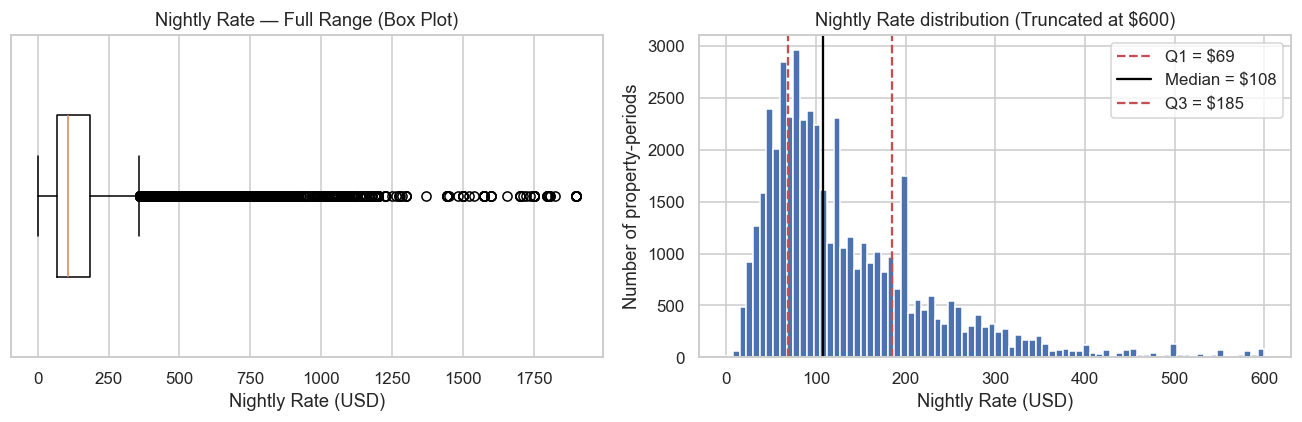

In [2]:
nr = df['Nightly Rate']

# Q1/Q3 are the 25th and 75th percentiles - the two values that bound the middle
# half of the market. The IQR is the width of that band
q1, q3 = nr.quantile(0.25), nr.quantile(0.75)
# Collect every spread statistic into one labelled table
summary = pd.Series({
    'Count (non-null)': nr.notna().sum(),
    'Missing':          nr.isna().sum(),
    'Minimum':          nr.min(),
    'Maximum':          nr.max(),
    'Range (max-min)':  nr.max() - nr.min(),
    'Q1 (25th pct)':    q1,
    'Median (50th pct)': nr.median(),
    'Q3 (75th pct)':    q3,
    'IQR (Q3-Q1)':      q3 - q1,
    'Mean':             nr.mean(),
    'Std deviation':    nr.std(),
})
print('Nightly Rate (USD) — spread statistics')
print('=' * 46)
print(summary.round(2).to_string())
print()
print('Rows used: {} of {} (null Nightly Rate: {})'.format(nr.notna().sum(), len(df), nr.isna().sum()))
print()

# List the most extreme listings so we can judge whether they are real or data errors
cols = ['Airbnb Property ID', 'Neighborhood', 'Listing Type', 'Bedrooms', 'Nightly Rate']
print('5 highest nightly rates')
# nlargest/nsmallest return whole ROWS ranked by one column. Because this is panel
# data these 5 rows can be the same property in 5 different periods, not 5 listings
print(df.nlargest(5, 'Nightly Rate')[cols].to_string(index=False))
print()
print('5 lowest nightly rates')
print(df.nsmallest(5, 'Nightly Rate')[cols].to_string(index=False))
print()

# How much of the market sits inside the IQR box vs out in the tail?
# between() gives True/False per row; .mean() turns that into a percentage
inside = nr.between(q1, q3).mean()
print('Share of listings priced between Q1 (${:.0f}) and Q3 (${:.0f}): {:.1%}'.format(q1, q3, inside))
print('Share priced above $500: {:.2%}   above $1,000: {:.2%}'.format((nr > 500).mean(), (nr > 1000).mean()))
print('99th percentile: ${:.2f}'.format(nr.quantile(0.99)))

# Box plot of the full range to show how far the outliers reach, next to a histogram
# zoomed into the main market to show where listings actually cluster
# The question asks about spread across different LISTINGS, but this is panel data:
# the five highest rows below are one property observed five times. Collapse to one
# median rate per property and confirm the answer is not an artefact of that.
per_listing = df.groupby('Airbnb Property ID')['Nightly Rate'].median()
print()
print('Same statistics at LISTING level (one median rate per property)')
print('  Distinct listings : {:,}  (from {:,} property-period rows)'.format(
    len(per_listing), len(df)))
print('  Range  : ${:,.2f}'.format(per_listing.max() - per_listing.min()))
print('  IQR    : ${:,.2f}   (vs ${:,.2f} at property-period level)'.format(
    per_listing.quantile(0.75) - per_listing.quantile(0.25), q3 - q1))
print('  Median : ${:,.2f}   (vs ${:,.2f})'.format(per_listing.median(), nr.median()))
print('  -> Materially the same answer, so the conclusion is not a panel artefact.')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
try:                                  # matplotlib >= 3.11
    axes[0].boxplot(nr.dropna(), orientation='horizontal', widths=0.5)
except TypeError:                     # older matplotlib, e.g. some Colab images
    axes[0].boxplot(nr.dropna(), vert=False, widths=0.5)
axes[0].set_title('Nightly Rate — Full Range (Box Plot)')
axes[0].set_xlabel('Nightly Rate (USD)')
axes[0].set_yticks([])
# range= cuts the x-axis at $600 so the bars are visible; it hides the long tail,
# which is why the box plot beside it shows the full range instead
axes[1].hist(nr.dropna(), bins=80, range=(0, 600), color='#4C72B0', edgecolor='white')
axes[1].axvline(q1, color='#C44E52', ls='--', label='Q1 = ${:.0f}'.format(q1))
axes[1].axvline(nr.median(), color='black', ls='-', label='Median = ${:.0f}'.format(nr.median()))
axes[1].axvline(q3, color='#C44E52', ls='--', label='Q3 = ${:.0f}'.format(q3))
axes[1].set_title('Nightly Rate distribution (Truncated at $600)') # for readability
axes[1].set_xlabel('Nightly Rate (USD)')
axes[1].set_ylabel('Number of property-periods')
axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 1

Range = $1,899 (min $1, max $1,900). IQR = $116.12 (Q1 $69.00, Q3 $185.12), median $107.50.

The two measures tell very different stories, and the gap between them is the finding: the
range is more than **16 times** the IQR. The middle half of the Dallas market is packed into a
narrow $116 band just under $200 a night, while the full range is stretched across nearly $1,900
by a thin tail of luxury listings — only 3.7% of property-periods are priced above $500 and
1.1% above $1,000.

That makes the range a bad way to measure variability here. It is set by exactly two rows and
is dragged up by a single outlier, whereas the IQR describes where listings actually sit. The
mean ($157.17) sitting well above the median ($107.50) confirms the same right skew.

On the extremes. We did not remove them, but they should be read with suspicion. The five
highest rows are all the same property (ID 18054750, a 2-bedroom Central Dallas home) observed
in five different periods at $1,900 — a reminder that this is panel data, so the "top 5 rows"
are not 5 different listings. The $1 minimum is likewise one property (ID 20678468) listed with
0 bedrooms, which looks like a placeholder or data-entry error rather than a real market price.
A single bad row moves the range by hundreds of dollars and the IQR not at all.

**What this means for the business.** The middle half of Dallas listings all price within a $116 band of each other, which tells us where a typical host actually has room to move. Raising a rate by $10 or $20 puts a listing in a different spot within that band. Trying to jump into the high end is not a realistic option for most hosts,
since only 3.7% of listings ever price above $500. So pricing advice from Airbnb should be framed in small dollar increments rather than as a push toward "premium" positioning. It also means the range is a misleading number to show a host, because it is set by a handful of extreme listings they will never compete with. The IQR describes the market the host is actually in.


---
# Question 2 — Descriptive statistics for `booked_days` and `revenue`

> Provide a summary of key descriptive statistics (mean, median, standard deviation, minimum,
> and maximum) for booked_days and revenue. How do these statistics help you understand the
> overall performance of the properties?

Approach: One table with count, mean, median, std, min and max for both variables. The
mean-to-median ratio is the number to read: if the mean sits well above the median, a minority
of high earners is pulling the average up and the median is the better description of a typical
property.

Because null `booked_days` / `revenue` means "listed but never booked" (see Setup), we print the
table twice — once over booked property-periods only, and once with those rows counted as zero.
The second version is the honest picture of all listed inventory.

Null values — booked_days: 16861   revenue: 16861

A. Booked property-periods only (nulls excluded) — n = 31850
------------------------------------------------------------
         booked_days    revenue
Count       31850.00   31850.00
Mean           25.47    3134.13
Median         22.00    2025.00
Std dev        18.77    4249.34
Minimum         1.00      10.00
Maximum       173.00  134209.00

  booked_days  mean/median ratio = 1.16
  revenue      mean/median ratio = 1.55

B. All property-periods, unbooked counted as 0 — n = 48711
----------------------------------------------------------
         booked_days_all  revenue_all
Count           48711.00     48711.00
Mean               16.65      2049.27
Median              9.00       787.00
Std dev            19.42      3745.62
Minimum             0.00         0.00
Maximum           173.00    134209.00

  booked_days_all mean/median ratio = 1.85
  revenue_all  mean/median ratio = 2.60

Percentiles (booked periods only)
          booked_d

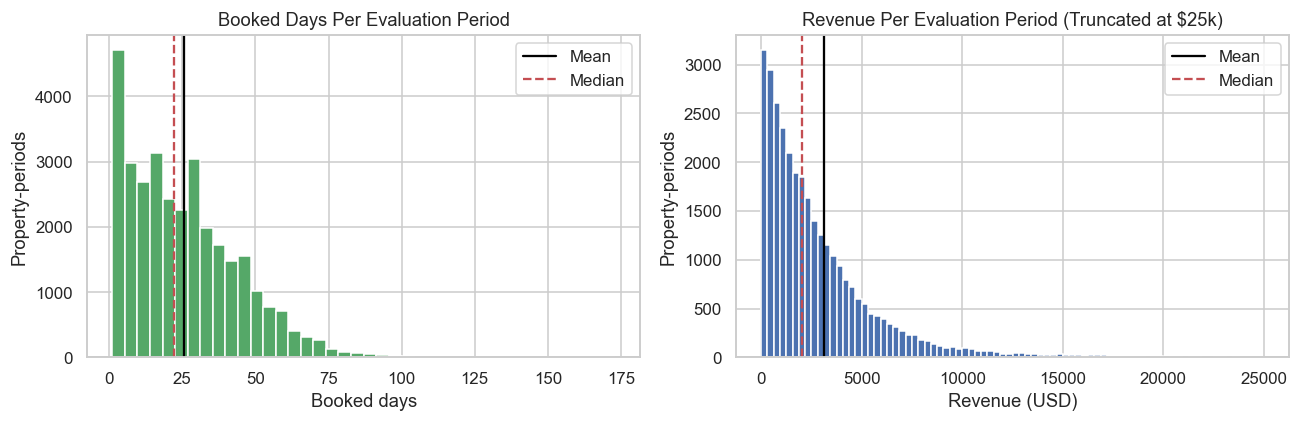

In [3]:
# Builds the same summary table for any set of columns, so we can run it twice:
# once on booked rows only, once with unbooked periods counted as zero
def describe_pair(frame, cols, label):
    # Dict-of-dicts -> DataFrame puts statistics in rows and variables in columns
    out = pd.DataFrame({
        c: {
            'Count':    frame[c].notna().sum(),
            'Mean':     frame[c].mean(),
            'Median':   frame[c].median(),
            'Std dev':  frame[c].std(),
            'Minimum':  frame[c].min(),
            'Maximum':  frame[c].max(),
        } for c in cols
    })
    print(label)
    print('-' * len(label))
    print(out.round(2).to_string())
    print()
    for col in cols:
        m, md_ = frame[col].mean(), frame[col].median()
        print('  {:<12} mean/median ratio = {:.2f}'.format(col, m / md_))
    print()
    return out

# How many property-periods have no booking data at all
print('Null values — booked_days: {}   revenue: {}'.format(
    df['booked_days'].isna().sum(), df['revenue'].isna().sum()))
print()

# Table A = booked periods only. Table B = the same stats with unbooked periods
# counted as zero, which is the honest view of all listed inventory
a = describe_pair(df, ['booked_days', 'revenue'],
                  'A. Booked property-periods only (nulls excluded) — n = {}'.format(
                      df['booked_days'].notna().sum()))
b = describe_pair(df.rename(columns={'booked_days_z': 'booked_days_all', 'revenue_z': 'revenue_all'}),
                  ['booked_days_all', 'revenue_all'],
                  'B. All property-periods, unbooked counted as 0 — n = {}'.format(len(df)))

# Percentiles give a fuller sense of the spread than min/max alone
pct = df[['booked_days', 'revenue']].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(2)
pct.index = ['10th pct', '25th pct', '50th pct', '75th pct', '90th pct', '99th pct']
print('Percentiles (booked periods only)')
print(pct.to_string())
print()
# Revenue earned by the top 10% of rows, divided by revenue earned by everyone
# A high number means earnings are concentrated in a few listings
top10_share = df.nlargest(int(0.10 * df['revenue'].notna().sum()), 'revenue')['revenue'].sum() / df['revenue'].sum()
print('Share of all revenue earned by the top 10% of property-periods: {:.1%}'.format(top10_share))

# Histograms of booked_days and revenue to show the shape behind those averages,
# with mean and median marked so the skew is visible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['booked_days'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(df['booked_days'].mean(), color='black', ls='-', label='Mean')
axes[0].axvline(df['booked_days'].median(), color='#C44E52', ls='--', label='Median')
axes[0].set_title('Booked Days Per Evaluation Period')
axes[0].set_xlabel('Booked days'); axes[0].set_ylabel('Property-periods'); axes[0].legend()
axes[1].hist(df['revenue'].dropna(), bins=80, range=(0, 25000), color='#4C72B0', edgecolor='white')
axes[1].axvline(df['revenue'].mean(), color='black', ls='-', label='Mean')
axes[1].axvline(df['revenue'].median(), color='#C44E52', ls='--', label='Median')
axes[1].set_title('Revenue Per Evaluation Period (Truncated at $25k)') # for readability
axes[1].set_xlabel('Revenue (USD)'); axes[1].set_ylabel('Property-periods'); axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 2

The question asks how these statistics describe the overall performance of the properties, so the full listed population leads and the booked-only subset follows. They answer different questions, and the distance between them is itself the finding.

**All listed property-periods (n = 48,711), idle periods counted as zero:**

| | booked_days | revenue |
|---|---|---|
| Mean | 16.65 | $2,049.27 |
| Median | 9.00 | $787.00 |
| Std dev | 19.42 | $3,745.62 |
| Min | 0.00 | $0.00 |
| Max | 173.00 | $134,209.00 |

**On-market property-periods only (n = 41,400)** — excluding 7,311 rows with no 
`available_days` either, which are most likely off-market rather than idle:

| | booked_days | revenue |
|---|---|---|
| Median | 13.00 | $1,261 |
| Share earning nothing | 23.1% | 23.1% |

**Booked property-periods only (n = 31,850):**

| | booked_days | revenue |
|---|---|---|
| Mean | 25.47 | $3,134.13 |
| Median | 22.00 | $2,025.00 |
| Std dev | 18.77 | $4,249.34 |
| Min | 1.00 | $10.00 |
| Max | 173.00 | $134,209.00 |

What these say about performance: The typical booked property earns about $2,025 per
evaluation period on 22 booked days. The mean/median ratios separate the two variables
cleanly: `booked_days` is only mildly skewed (ratio 1.16), because it is physically capped
by the length of the period, and its max of 173 days is a real ceiling. Revenue doesn't really have a cap,
and its ratio of 1.55 plus a standard deviation ($4,249) larger than its own mean 
shows a small group of very high earners pulling the average up. The top 10% of
**booked** property-periods take 38.6% of the revenue they earn. Quoting the $3,134 mean as "typical" would
overstate what a normal host makes by more than 50%.

Why the two tables differ, and why it matters. 16,861
property-periods (34.6%) have no booked days at all. Counting those as zero, which is the
honest view of all listed inventory, the picture changes sharply: median revenue falls from
$2,025 to $787 and median booked days from 22 to 9. So roughly a third of Dallas
inventory earns nothing — though that figure depends on what counts as inventory. 7,311 of
those 16,861 rows have no `available_days` recorded either, so they were probably off the
market entirely rather than listed and unbooked. Restricting to rows we can confirm were
on the market, the idle share is **23.1%** and median revenue is **$1,261**. The direction is
unchanged on either reading; any performance claim simply needs to state which population it
describes.

**What this means for the business.** The finding here is operational rather than
statistical. Among listings that were actually on the market in a period, 23.1%
earned nothing at all. That figure rises to 34.6% if you also count the 7,311 rows
with no available days, but those are better read as supply that was pulled off the
market than as listings that failed to book. The 23.1% is the number we would defend
in a presentation, and it is still close to a quarter of active inventory sitting
empty.

The size of the gap is easy to state. A property that books earns a median of $2,025
in a period, and the same property sitting idle earns nothing. That makes empty
active listings the largest pool of missed revenue anywhere in this dataset, and it
is revenue from supply Airbnb has already signed up rather than supply it would have
to go find.


---
# Question 3 — Booking patterns: Superhosts vs non-Superhosts

> What can you infer about booking patterns for Superhosts compared to non-Superhosts?
> Determine the best way to visualize the booked_days data and explain your findings.

Chart choice and why: 
Side-by-side box plots, with overlapping density curves as a second view. A bar chart of two means would hide the spread, and spread is the whole point of a booking-pattern comparison — box plots show median, IQR and outliers for both groups at once, and the density curves show whether the two distributions have different *shapes* or just different centres.

Watch for: The groups are very different sizes, so we print group counts alongside and
compare medians as well as means.

Rows used: 31850 of 48711 (16861 dropped for null booked_days)

booked_days by Superhost status
                  Count   Mean  Median  Std dev    Q1    Q3    Max   IQR
Superhost status                                                        
Non-Superhost     18987  23.67    20.0    18.67   8.0  35.0  173.0  27.0
Superhost         12863  28.12    26.0    18.62  13.0  40.0  133.0  27.0

Difference in means  (Superhost - Non): +4.46 days
Difference in medians (Superhost - Non): +6.00 days
Superhost median is 1.3x the non-Superhost median

Share of property-periods with NO bookings at all:
Superhost status
Non-Superhost    42.1%
Superhost        19.2%


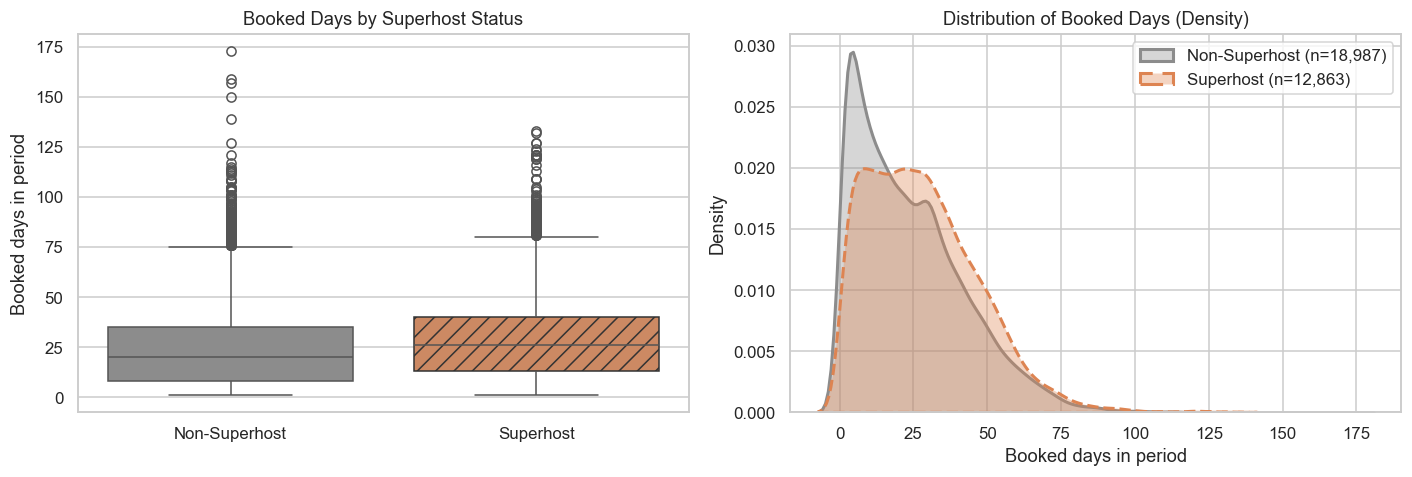

In [4]:
# Keep only rows that actually have booking data. subset= means 'judge missingness
# on this column only', not on the whole row
bd = df.dropna(subset=['booked_days'])
print('Rows used: {} of {} ({} dropped for null booked_days)'.format(
    len(bd), len(df), df['booked_days'].isna().sum()))
print()

# A groupby object: the same calculation gets applied once per group
grp = bd.groupby('Superhost status')['booked_days']
tbl = pd.DataFrame({
    'Count':  grp.count(),
    'Mean':   grp.mean(),
    'Median': grp.median(),
    'Std dev': grp.std(),
    'Q1':     grp.quantile(0.25),
    'Q3':     grp.quantile(0.75),
    'Max':    grp.max(),
})
tbl['IQR'] = tbl['Q3'] - tbl['Q1']
print('booked_days by Superhost status')
print(tbl.round(2).to_string())
print()

# Split into the two groups so we can difference them directly
sh = bd.loc[bd['Superhost'] == 1, 'booked_days']
non = bd.loc[bd['Superhost'] == 0, 'booked_days']
print('Difference in means  (Superhost - Non): {:+.2f} days'.format(sh.mean() - non.mean()))
print('Difference in medians (Superhost - Non): {:+.2f} days'.format(sh.median() - non.median()))
print('Superhost median is {:.1f}x the non-Superhost median'.format(sh.median() / non.median()))
print()

# Unbooked periods are excluded above; that itself differs by group, so report it
print('Share of property-periods with NO bookings at all:')
# Share of each group's rows that are missing - i.e. periods with zero bookings
# This runs on the FULL df, not bd, because bd has already dropped those rows
print((df.groupby('Superhost status')['booked_days'].apply(lambda s: s.isna().mean())
         .mul(100).round(1).astype(str) + '%').to_string())

# Box plot of booked days by group to compare medians, spread and outliers,
# plus density curves to show whether the two distributions differ in shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=bd, x='Superhost status', y='booked_days',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Booked Days by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Booked days in period')

# Distinct linestyle as well as colour, so the two curves stay separable in print
for lab, colr, ls in [('Non-Superhost', '#8C8C8C', '-'), ('Superhost', '#DD8452', '--')]:
    sns.kdeplot(bd.loc[bd['Superhost status'] == lab, 'booked_days'],
                label='{} (n={:,})'.format(lab, int((bd['Superhost status'] == lab).sum())),
                fill=True, alpha=0.35, color=colr, linestyle=ls,
                linewidth=2, ax=axes[1])
axes[1].set_title('Distribution of Booked Days (Density)')
axes[1].set_xlabel('Booked days in period'); axes[1].set_ylabel('Density')
axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 3

| | n | Mean | Median | Q1 | Q3 | IQR |
|---|---|---|---|---|---|---|
| Non-Superhost | 18,987 | 23.67 | 20.0 | 8.0 | 35.0 | 27.0 |
| Superhost | 12,863 | 28.12 | 26.0 | 13.0 | 40.0 | 27.0 |

Superhosts book +4.46 days more on the mean and +6.0 days more on the median — the median
gap is the larger of the two, so this is not a handful of outliers dragging an average. What the box plots add is that the IQR is identical at 27 days for both groups: the Superhost
distribution is not tighter or more consistent, it is the same shape shifted upward by about a week of bookings per period. Superhost listings are not a different kind of business, just a better-booked version of the same one.

The largest difference is one the box plots cannot show, because it lives in the rows we had
to drop. Among non-Superhosts, 42.1% of property-periods had no bookings at all; among
Superhosts, only 19.2%. Restricting to rows we can confirm were on the market (excluding the
7,311 with no `available_days`), the same gap holds at **28.0% against 14.5%**. So the real booking-pattern gap is not mainly that a booked Superhost books more nights — it is that a Superhost listing is less than half as likely to sit empty for an entire period. Any comparison restricted to booked rows understates the
advantage by a wide margin.

**What this means for the business.** The +6-day median gap is a **customer intimacy** story:
responsive, well-reviewed hosts get booked more. But the **operational excellence** finding is the
bigger one — a non-Superhost listing sits completely idle in 42.1% of periods against 19.2% for
Superhosts. Airbnb captures value per booked night, so idle inventory is lost revenue on both
sides of the marketplace. Whatever distinguishes these listings more than halves the idle rate, and
identifying it is worth more than the extra week of bookings among already-booked listings.


---
# Question 4 — Seasonal patterns in booking days for Superhosts

> Are there any seasonal patterns in the booking days for Superhosts? Select the best approach
> to visualize the trend in booked_days over different periods and discuss the patterns you
> identify.

Chart choice and why: A line chart of mean `booked_days` by calendar month, restricted to
Superhosts. "Seasonal" means calendar months, so this is the first question that uses
`Scraped Date` rather than the period number. We add the non-Superhost line even though the
question doesn't ask for it: if both lines share the same shape, the pattern is the Dallas
market, not something about Superhosts.

Watch for: We check how many years and which months are actually present before averaging
months across years — the scrape is quarterly, so not every calendar month is covered.

Date range: 2016-08-01 to 2020-06-22
Distinct years  : [2016, 2017, 2018, 2019, 2020]
Distinct months present: [2, 3, 5, 6, 8, 9, 11, 12]
NOTE: scrapes are quarterly, so only 8 of 12 calendar months appear. Months with no
      scrape are absent from the chart, not zero.

Mean booked_days by calendar month (all months present in the data)
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                       24.77      27.86
Mar                       21.27      17.42
May                       22.74      30.12
Jun                       13.35      21.25
Aug                       26.72      29.64
Sep                       17.94      19.00
Nov                       20.85      25.11
Dec                       17.86      21.62

Rows behind each month
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                        4561       3329
Mar                          33         12
May                        4859  

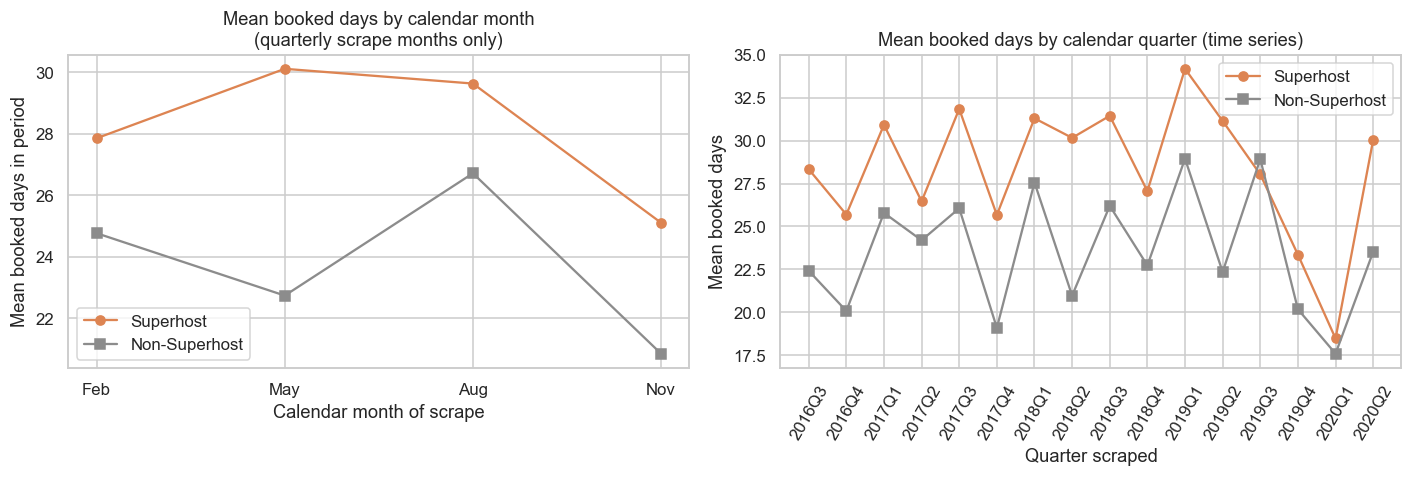


Mean booked_days by quarter (time series above)
Superhost status  Non-Superhost  Superhost
Scraped Date                              
2016Q3                    22.42      28.34
2016Q4                    20.07      25.69
2017Q1                    25.79      30.93
2017Q2                    24.19      26.46
2017Q3                    26.06      31.85
2017Q4                    19.09      25.67
2018Q1                    27.56      31.31
2018Q2                    20.97      30.17
2018Q3                    26.20      31.45
2018Q4                    22.73      27.06
2019Q1                    28.95      34.19
2019Q2                    22.35      31.15
2019Q3                    28.93      28.03
2019Q4                    20.17      23.36
2020Q1                    17.58      18.47
2020Q2                    23.52      30.05


In [5]:
# Q4: seasonality. This needs real calendar dates, so parse the date column first
df['Scraped Date'] = pd.to_datetime(df['Scraped Date'])
print('Date range: {} to {}'.format(df['Scraped Date'].min().date(), df['Scraped Date'].max().date()))
print('Distinct years  :', sorted(df['Scraped Date'].dt.year.unique()))
print('Distinct months present:', sorted(df['Scraped Date'].dt.month.unique()))
print('NOTE: scrapes are quarterly, so only {} of 12 calendar months appear. Months with no'
      .format(df['Scraped Date'].dt.month.nunique()))
print('      scrape are absent from the chart, not zero.')
print()

# Pull calendar month and year out of the date for grouping
# Added together rather than one at a time; separate inserts fragment the frame and
# emit a PerformanceWarning that would print into the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Month': df['Scraped Date'].dt.month,
    'Year': df['Scraped Date'].dt.year,
}, index=df.index)], axis=1)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

bd = df.dropna(subset=['booked_days'])
# Mean, median and row count of booked days for each month/group combination
monthly = (bd.groupby(['Month', 'Superhost status'])['booked_days']
             .agg(['mean', 'median', 'count']).round(2).reset_index())
# pivot reshapes long -> wide: one row per month, one column per group
piv_mean = monthly.pivot(index='Month', columns='Superhost status', values='mean')
piv_n = monthly.pivot(index='Month', columns='Superhost status', values='count')

print('Mean booked_days by calendar month (all months present in the data)')
print(piv_mean.rename(index=month_names).round(2).to_string())
print()
print('Rows behind each month')
print(piv_n.rename(index=month_names).astype(int).to_string())
print()

# Four months hold only a handful of straggler scrapes. Averaging 12 rows next to 3,300
# would invent a seasonal swing that is really sampling noise, so we read the pattern off
# the well-sampled months only and say which those are
# .all(axis=1) demands the threshold is met in BOTH columns, so a month only counts
# as well-sampled if both groups have enough rows
well = piv_n[(piv_n >= 500).all(axis=1)].index.tolist()
thin = [m for m in piv_n.index if m not in well]
print('Well-sampled months (>=500 rows in BOTH groups):', [month_names[m] for m in well])
print('Thin months excluded from the chart          :',
      ['{} (n={})'.format(month_names[m], int(piv_n.loc[m].sum())) for m in thin])
print()

# Peak and trough months, read off the well-sampled months only
pm = piv_mean.loc[well]
sh_m = pm['Superhost']
print('Superhost peak month : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmax()], sh_m.max()))
print('Superhost low month  : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmin()], sh_m.min()))
print('Peak-to-trough swing : {:.1f} days ({:.0%} above the low month)'.format(
    sh_m.max() - sh_m.min(), (sh_m.max() - sh_m.min()) / sh_m.min()))
non_m = pm['Non-Superhost']
print('Non-Superhost peak   : {}   low: {}   swing: {:.1f} days'.format(
    month_names[non_m.idxmax()], month_names[non_m.idxmin()], non_m.max() - non_m.min()))
# Vertical gap between the two lines on the chart: how many more days a Superhost
# listing books than a non-Superhost one, in each month
print()
lead = (pm['Superhost'] - pm['Non-Superhost']).rename(index=month_names).round(2)
lead.index.name = None          # drop the stray 'Month' header pandas prints
print('Superhost lead in mean booked days (Superhost - Non-Superhost), by month:')
print(lead.to_string())

# Which month is each group's own best? The two groups do not peak together, so rank
# each month within its own group rather than comparing the levels across groups.
print()
print('Rank of each month within its OWN group (1 = that group\'s best month)')
ranks = pd.DataFrame({
    'Superhost rank':     pm['Superhost'].rank(ascending=False).astype(int),
    'Non-Superhost rank': pm['Non-Superhost'].rank(ascending=False).astype(int),
}).rename(index=month_names)
print(ranks.to_string())

# Is the May divergence a stable seasonal rule or driven by particular years?
print()
print('Mean booked days and gap, by year and month (well-sampled months only)')
wy = bd[bd['Month'].isin(well)]
by_year = wy.groupby(['Year', 'Month', 'Superhost status'])['booked_days'].mean().unstack()
by_year['Gap'] = by_year['Superhost'] - by_year['Non-Superhost']
by_year.index = by_year.index.set_levels([month_names[m] for m in sorted(well)], level=1)
print(by_year.round(2).to_string())
print()
print('Years each well-sampled month is observed in (they are NOT the same set):')
for m in well:
    yrs = sorted(wy.loc[wy['Month'] == m, 'Year'].unique())
    print('  {:<4} {}'.format(month_names[m], yrs))

# Left: line chart of booked days by calendar month to show the seasonal cycle
# Right: the same measure by quarter over time, to separate cycle from trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[0].plot(range(len(well)), pm[lab], marker=mk, color=colr, label=lab)
axes[0].set_xticks(range(len(well)))
axes[0].set_xticklabels([month_names[m] for m in well])
axes[0].set_title('Mean booked days by calendar month\n(quarterly scrape months only)')
axes[0].set_xlabel('Calendar month of scrape')
axes[0].set_ylabel('Mean booked days in period')
axes[0].legend(title='')

# Second view: the actual time series, so a repeating cycle can be told apart from a trend
# .dt.to_period('Q') buckets each date into its calendar quarter (e.g. 2019Q2)
# .unstack() then moves the Superhost labels up into columns
ts = (bd.groupby([bd['Scraped Date'].dt.to_period('Q'), 'Superhost status'])['booked_days']
        .mean().unstack())
ts.index = ts.index.astype(str)
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[1].plot(ts.index, ts[lab], marker=mk, color=colr, label=lab)
axes[1].set_title('Mean booked days by calendar quarter (time series)')
axes[1].set_xlabel('Quarter scraped'); axes[1].set_ylabel('Mean booked days')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend(title='')
plt.tight_layout()
plt.show()

print()
print('Mean booked_days by quarter (time series above)')
print(ts.round(2).to_string())

### Findings — Question 4

A sampling caveat first, because it changes the answer. The data is scraped quarterly,
so only 8 of 12 calendar months appear at all, and 4 of those (Mar, Jun, Sep, Dec) hold just a
few dozen straggler rows against 3,000+ in the real scrape months. Reading a "March trough" off
12 Superhost rows would be inventing a season out of sampling noise. We therefore read the
pattern off the four well-sampled months — February, May, August, November — and exclude the
rest from the chart.

Mean booked days, Superhosts: Feb 27.9 · May 30.1 · Aug 29.6 · Nov 25.1.
Mean booked days, non-Superhosts: Feb 24.8 · May 22.7 · Aug 26.7 · Nov 20.9.

The pattern: There is a clear and modest season. Superhost bookings peak in May (30.1
days), hold nearly as high through August (29.6), and fall to a low in November (25.1) —
a 5.0-day swing, about 20% between the best and worst month. Spring and summer are the
Dallas booking season; late autumn is the trough.

The season is broadly the market, not the badge — but the two groups do not peak in the
same month. Both trough in November (Superhosts 25.1, non-Superhosts 20.9) and both run
stronger through spring and summer, so the underlying cycle is Dallas demand rather than
anything Superhosts do. The peaks differ, though. Ranked within its own group, May is the
Superhosts' best month but only the third of four for non-Superhosts, whose best month is
August. Superhosts also sit above non-Superhosts in every month, by 2.9 to 7.4 days.

May is where the two groups come apart, and it is the finding worth naming. The gap runs 3.1
days in February, 2.9 in August and 4.3 in November — but 7.4 in May, roughly two and a half
times the August gap. Superhosts are at their strongest (30.1 days) in the same month
non-Superhosts are near their weakest (22.7, above only November). So spring demand is not
shared out evenly: whatever arrives in Dallas in May, Superhost listings absorb far more of it,
and the single peak-season month is the one where the two groups least resemble each other.

Two qualifications, because the pooled figure hides them. First, the May gap is not a fixed
seasonal rule — it is +2.1 days in 2017, then +9.4 in 2018, +8.8 in 2019 and +6.5 in 2020. In
2017 May was actually the narrowest of that year's four gaps, so this is a 2018-onward pattern
rather than a permanent feature of Dallas Mays. Second, the two peak months are not measured
over the same years: May is observed in 2017-2020 and August in 2016-2019, so part of the
May-versus-August comparison is a comparison of different years — the 2020 recovery sits inside
the May average and not inside August's. The direction survives both, but the size should be
quoted as an average over four unlike years.

The quarterly time series adds a caution about reading months across years. It shows the
seasonal cycle repeating on top of a mild upward drift from 2016 to 2019, then a visible dip in
2020 Q1 (Superhost mean 18.5 booked days, the lowest point in the series) as COVID hit. Since
the monthly averages pool five years together, that shock is silently mixed into the Feb figure.

**What this means for the business.** Descriptive shading into **predictive**: a 5.0-day swing
between May and November is a forecastable, market-wide pattern, so it belongs in capacity and
pricing planning and should not be read as host performance. Because both groups share the same
November trough and the same broad spring-summer season, the cycle itself is Dallas demand rather
than the badge. The actionable detail is *where* they diverge: the premium is widest in May, the
Superhost peak and a month in which non-Superhosts sit near their own floor. That is a
**value-capture** argument for putting dynamic pricing and availability support in front of
non-Superhosts specifically ahead of the spring season, since May is the month they leave the
most on the table — with the caveat that this gap only opens from 2018 onward, so it is worth
confirming on current data before acting on it.


---
# Question 5 — Superhost status and number of reviews

> How does Superhost status impact the number of reviews a property receives? Choose an
> appropriate method to compare the numReviews_pastYear for Superhosts and non-Superhosts.

Method choice and why: Group summary statistics plus box plots, backed by two significance
tests. Review counts are right-skewed and the two groups differ in size and variance, so we use
Welch's t-test (does not assume equal variances) for the means and Mann-Whitney U as a
non-parametric check that does not assume normality. If both agree, the gap is not sampling
noise.

Important caveat for the written answer: This is correlational, and the direction is
ambiguous: Superhost status is awarded partly on the basis of review activity, so we cannot
claim the badge causes reviews. It is at least as likely that reviews cause the badge.

Rows used: 37492 of 48711 (11219 dropped for null numReviews_pastYear)

numReviews_pastYear by Superhost status
                  Count    Mean  Median  Std dev    Q1     Q3     Max
Superhost status                                                     
Non-Superhost     22546  240.49    27.0   601.66   5.0  184.0  3305.0
Superhost         14946  138.78    46.0   288.59  20.0  131.0  3133.0

Difference in means  : -101.71 reviews  (Superhost 138.8 vs 240.5)
Difference in medians: +19.0 reviews  (Superhost 46 vs 27)
Superhost mean is 0.58x the non-Superhost mean

Welch's t-test (unequal variances)
  t-statistic = -21.870
  p-value     = 2.614e-105  (< 0.001)
Mann-Whitney U (non-parametric check)
  U-statistic = 199,394,438
  p-value     = 2.198e-199  (< 0.001)

Cohen's d (effect size) = -0.203
  For scale: 0.2 small, 0.5 medium, 0.8 large.


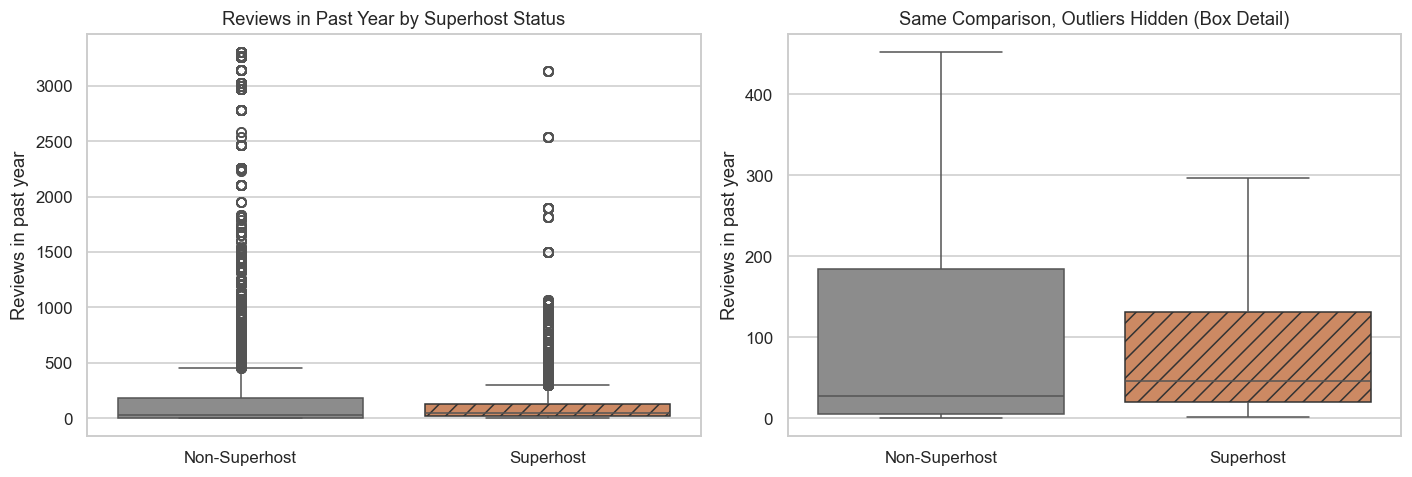

In [6]:
rv = df.dropna(subset=['numReviews_pastYear'])
print('Rows used: {} of {} ({} dropped for null numReviews_pastYear)'.format(
    len(rv), len(df), df['numReviews_pastYear'].isna().sum()))
print()

# Summary table of review counts for each group
grp = rv.groupby('Superhost status')['numReviews_pastYear']
tbl = pd.DataFrame({'Count': grp.count(), 'Mean': grp.mean(), 'Median': grp.median(),
                    'Std dev': grp.std(), 'Q1': grp.quantile(0.25), 'Q3': grp.quantile(0.75),
                    'Max': grp.max()})
print('numReviews_pastYear by Superhost status')
print(tbl.round(2).to_string())
print()

# Split the two groups so they can be compared and tested
sh = rv.loc[rv['Superhost'] == 1, 'numReviews_pastYear']
non = rv.loc[rv['Superhost'] == 0, 'numReviews_pastYear']
print('Difference in means  : {:+.2f} reviews  (Superhost {:.1f} vs {:.1f})'.format(
    sh.mean() - non.mean(), sh.mean(), non.mean()))
print('Difference in medians: {:+.1f} reviews  (Superhost {:.0f} vs {:.0f})'.format(
    sh.median() - non.median(), sh.median(), non.median()))
print('Superhost mean is {:.2f}x the non-Superhost mean'.format(sh.mean() / non.mean()))
print()

# equal_var=False makes this Welch's t-test, which does not assume the two groups
# have the same variance or size - both are true here
t, p = stats.ttest_ind(sh, non, equal_var=False)
print("Welch's t-test (unequal variances)")
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Compares ranks rather than means, so a few huge values cannot distort it
u, pu = stats.mannwhitneyu(sh, non, alternative='two-sided')
print('Mann-Whitney U (non-parametric check)')
print('  U-statistic = {:,.0f}'.format(u))
print('  p-value     = {:.3e}{}'.format(pu, '  (< 0.001)' if pu < 0.001 else ''))
# Effect size: a significant p-value on 37k rows says little on its own
# Cohen's d = gap between means measured in standard deviations. On 37k rows almost
# any gap is 'significant', so this says whether it is actually BIG
pooled = np.sqrt(((len(sh)-1)*sh.var() + (len(non)-1)*non.var()) / (len(sh)+len(non)-2))
print("\nCohen's d (effect size) = {:.3f}".format((sh.mean() - non.mean()) / pooled))
print('  For scale: 0.2 small, 0.5 medium, 0.8 large.')

# Box plots of reviews by group. The second hides outliers so the boxes themselves
# are readable - the tail is so long it flattens the first chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Reviews in Past Year by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Reviews in past year')

sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=axes[1])
hatch_second(axes[1])            # greyscale safety, see setup cell
axes[1].set_title('Same Comparison, Outliers Hidden (Box Detail)')
axes[1].set_xlabel(''); axes[1].set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Q5 follow-up — the mean and the median disagree, so we check why

The table above shows something odd: Superhosts have a higher median review count but a
lower mean. When those two point in opposite directions, a skewed tail is driving the mean,
and we should find out what is in that tail before writing an answer.

Our hypothesis: `numReviews_pastYear` scales with how many listings a host operates, so large
commercial operators sit in the tail — and those operators are concentrated among
non-Superhosts. We test it by counting listings per host and re-running the comparison on
single-listing hosts only, which removes the confound.

Mean reviews by size of host portfolio (distinct listings operated)
           count   mean  median
n_props                        
1 listing  10569   19.8     9.0
2           4858   35.2    18.0
3-5         5635   55.0    28.0
6-20        6438  260.2   110.0
21+         9992  513.5   188.0

-> Review counts rise steeply with portfolio size, so this column reflects the HOST,
   not just the property.

Portfolio size by Superhost status
                   mean  median
Superhost status               
Non-Superhost     72.79     5.0
Superhost         39.54     3.0

-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which
   is what pulls their MEAN review count up. This is a row-weighting effect: a large
   operator contributes one row per listing per period. At HOST level the median host
   in either group runs a single listing.

Like-for-like comparison: single-listing hosts only (n = 10569)
                  count   mean  median    std
Superhost status     

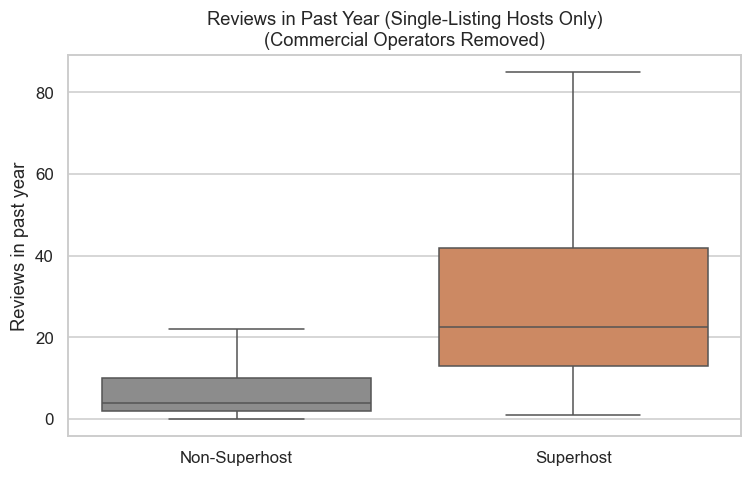

In [7]:
# How many distinct properties does each host operate?
# nunique() counts DISTINCT properties per host, so a host appearing in many periods
# is still counted once per property
props_per_host = rv.groupby('Airbnb Host ID')['Airbnb Property ID'].nunique().rename('n_props')
# join(..., on=) attaches that host-level count back onto every row of that host
rv2 = rv.join(props_per_host, on='Airbnb Host ID')

# Does review count track how many listings a host runs?
print('Mean reviews by size of host portfolio (distinct listings operated)')
# pd.cut sorts a numeric column into labelled bands. Edges are (0,1], (1,2] ... so
# '1 listing' means exactly one
bands = pd.cut(rv2['n_props'], [0, 1, 2, 5, 20, 10000],
               labels=['1 listing', '2', '3-5', '6-20', '21+'])
print(rv2.groupby(bands, observed=True)['numReviews_pastYear']
         .agg(['count', 'mean', 'median']).round(1).to_string())
print()
print('-> Review counts rise steeply with portfolio size, so this column reflects the HOST,')
print('   not just the property.')
print()
# Compare typical portfolio size between the two groups
print('Portfolio size by Superhost status')
print(rv2.groupby('Superhost status')['n_props'].agg(['mean', 'median']).round(2).to_string())
print()
print('-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which')
print('   is what pulls their MEAN review count up. This is a row-weighting effect: a large')
print('   operator contributes one row per listing per period. At HOST level the median host')
print('   in either group runs a single listing.')
print()

# Re-run the comparison with the confound removed
# Hosts with exactly one listing: removes commercial operators, which is the
# confound that made the mean and median disagree above
single = rv2[rv2['n_props'] == 1]
print('=' * 62)
print('Like-for-like comparison: single-listing hosts only (n = {})'.format(len(single)))
print('=' * 62)
print(single.groupby('Superhost status')['numReviews_pastYear']
            .agg(['count', 'mean', 'median', 'std']).round(2).to_string())
print()
a = single.loc[single['Superhost'] == 1, 'numReviews_pastYear']
b = single.loc[single['Superhost'] == 0, 'numReviews_pastYear']
print('Superhost mean is {:.2f}x the non-Superhost mean   ({:.1f} vs {:.1f})'.format(
    a.mean() / b.mean(), a.mean(), b.mean()))
print('Superhost median is {:.2f}x the non-Superhost median ({:.1f} vs {:.1f})'.format(
    a.median() / b.median(), a.median(), b.median()))
print("Welch's t-test p-value : {:.3e}".format(stats.ttest_ind(a, b, equal_var=False)[1]))
print('Mann-Whitney U p-value : {:.3e}'.format(stats.mannwhitneyu(a, b, alternative='two-sided')[1]))

# Box plot of reviews for single-listing hosts only - the like-for-like comparison,
# with commercial operators removed
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=single, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=ax)
ax.set_title('Reviews in Past Year (Single-Listing Hosts Only)\n(Commercial Operators Removed)')
ax.set_xlabel(''); ax.set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Findings — Question 5

The headline comparison contradicts itself, and that is the interesting part. Across all
37,492 rows with review data, Superhosts have a higher median (46 vs 27 reviews) but a
lower mean (138.8 vs 240.5). Both tests are significant (Welch p ≈ 3e-105, Mann-Whitney
p ≈ 2e-199), but they are significant in opposite directions, so significance is not the issue
— on 37,000 rows almost anything reaches significance, which is why we also report Cohen's d
(-0.20, small). A p-value cannot tell us which of two contradictory answers is right.

What is in the tail. `numReviews_pastYear` rises steeply with the size of the host's
portfolio — from a mean of 19.8 reviews for single-listing hosts to 513.5 for hosts with 21+
listings. The column reflects the host, not the individual property. And the average non-Superhost *row*
belongs to a host operating 72.8 listings, against 39.5 for Superhost rows — a large operator
contributes one row per listing per period, so a handful of them dominate the non-Superhost
mean. (At host level the comparison reverses and the median host in either group runs a single
listing; it is the row weighting, not the hosts, that creates the confound.) So the non-Superhost mean
is inflated by large commercial operators, who accumulate enormous review counts and are
under-represented among Superhosts (21.7% of rows from hosts with 21+ listings carry the badge,
against 32.7% of rows overall).

The like-for-like answer. Restricting to hosts with exactly one listing (n = 10,569) removes
the confound, and the contradiction disappears — both statistics now point the same way:

| Single-listing hosts | n | Mean | Median |
|---|---|---|---|
| Non-Superhost | 6,547 | 12.5 | 4.0 |
| Superhost | 4,022 | 31.7 | 22.5 |

Superhosts receive 2.5x the mean and 5.6x the median number of reviews (both p < 0.001).
That is the finding: Superhost status is associated with substantially more reviews, and the
raw comparison hid it entirely behind a composition effect.

Causation caveat: This is correlational, and the direction is genuinely ambiguous — Airbnb
awards Superhost status partly on the basis of review activity, so it is at least as plausible
that reviews cause the badge as the reverse. We cannot separate the two with this data.

**What this means for the business.** Once the portfolio-size confound is removed,
single-listing Superhosts receive 5.6x the median reviews of comparable non-Superhosts. Reviews
are the trust signal the marketplace runs on, so this is **customer intimacy** feeding
**value-chain coordination**: more reviews reduce buyer uncertainty and make matching cheaper for
Airbnb. The caution for any decision built on this is that the causal direction is genuinely
ambiguous — the badge is awarded partly *on* review activity — so neither Airbnb nor a host can
treat "earn the badge" as a route to more reviews.


---
# Question 6 — Histogram of revenue by Superhost status

> Use a histogram to visualize the distribution of revenue for listings. How does the
> distribution differ between properties with Superhost status and those without?

Approach: Revenue is heavily right-skewed, and a plain histogram is one tall bar near zero and a flat invisible tail. We show two versions on shared bins: the raw scale, and a log-scaled x-axis where the shape of both distributions is actually readable. We read the answer off the log version and say so.

Decision stated explicitly: property-periods with no bookings (null revenue) are excluded
from the histograms, because a log axis cannot show zero. Their counts are printed below so the
exclusion is visible.

Rows used: 31850 of 48711 (16861 excluded — no bookings in the period)

revenue by Superhost status
                           Non-Superhost  Superhost
Count                           18987.00   12863.00
Mean                             2938.92    3422.28
Median                           1868.00    2229.00
Std dev                          3862.47    4748.83
Skewness                            4.83       7.24
Max                             77500.00  134209.00
Rows with revenue == 0              0.00       0.00
Unbooked periods excluded       13804.00    3057.00

Both groups are strongly right-skewed (skew >> 0), so the median describes a typical
property far better than the mean does.

Median revenue: Superhost $2,229 vs Non-Superhost $1,868  (+19%)
Mean revenue  : Superhost $3,422 vs Non-Superhost $2,939  (+16%)


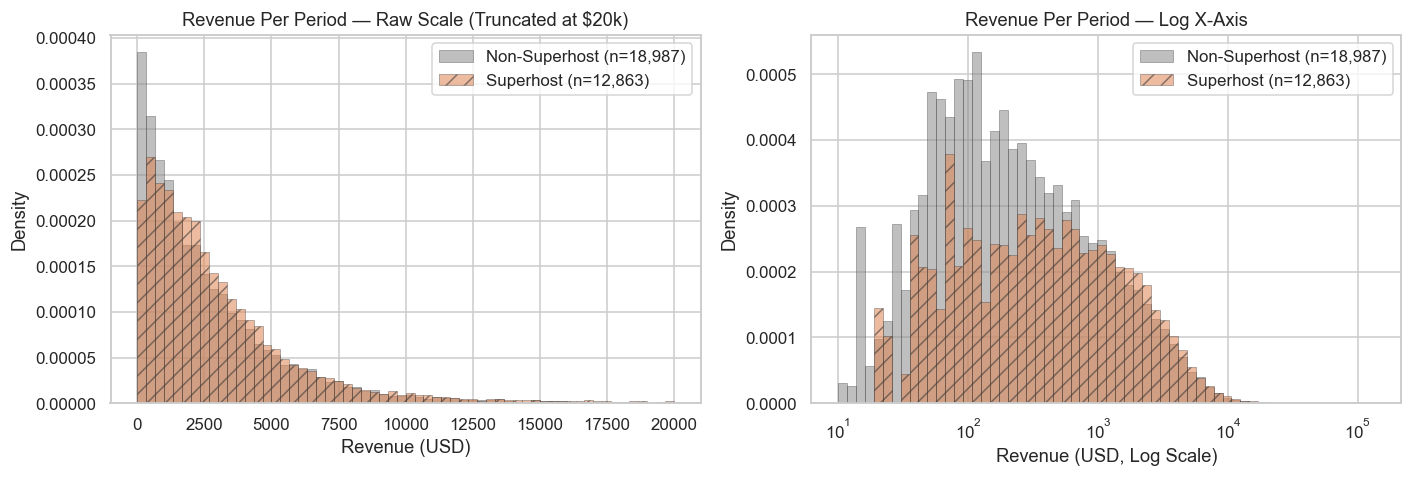

In [8]:
rev = df.dropna(subset=['revenue'])
print('Rows used: {} of {} ({} excluded — no bookings in the period)'.format(
    len(rev), len(df), df['revenue'].isna().sum()))
print()

# Per-group revenue statistics, including skewness to quantify the right tail
stats_tbl = pd.DataFrame({
    lab: {
        'Count':            g['revenue'].count(),
        'Mean':             g['revenue'].mean(),
        'Median':           g['revenue'].median(),
        'Std dev':          g['revenue'].std(),
        'Skewness':         g['revenue'].skew(),
        'Max':              g['revenue'].max(),
        'Rows with revenue == 0': int((g['revenue'] == 0).sum()),
        'Unbooked periods excluded': int(df[(df['Superhost status'] == lab)]['revenue'].isna().sum()),
    } for lab, g in rev.groupby('Superhost status')
})
print('revenue by Superhost status')
print(stats_tbl.round(2).to_string())
print()
print('Both groups are strongly right-skewed (skew >> 0), so the median describes a typical')
print('property far better than the mean does.')
print()
# Headline medians and means for the write-up
sh = rev.loc[rev['Superhost'] == 1, 'revenue']
non = rev.loc[rev['Superhost'] == 0, 'revenue']
print('Median revenue: Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.median(), non.median(), sh.median() / non.median() - 1))
print('Mean revenue  : Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.mean(), non.mean(), sh.mean() / non.mean() - 1))

# Both groups must share identical bins or the histograms cannot be compared
# linspace = evenly spaced; logspace = evenly spaced ON a log axis, so the bars
# stay equal width once the x-axis is logged
bins_raw = np.linspace(0, 20000, 61)
bins_log = np.logspace(np.log10(max(rev['revenue'].min(), 1)), np.log10(rev['revenue'].max()), 61)

# Two overlapping histograms of revenue by group: raw scale on the left, log x-axis
# on the right where the skew stops hiding the shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Hatch as well as colour: the two fills are near-identical in greyscale
for lab, colr, htch in [('Non-Superhost', '#8C8C8C', None), ('Superhost', '#DD8452', '//')]:
    s = rev.loc[rev['Superhost status'] == lab, 'revenue']
    # density=True converts counts to proportions. Essential here: there are far more
    # non-Superhost rows, so raw counts would make that group look taller everywhere
    # alpha makes the overlapping region visible
    lab_n = '{} (n={:,})'.format(lab, len(s))
    axes[0].hist(s, bins=bins_raw, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
    axes[1].hist(s, bins=bins_log, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
axes[0].set_title('Revenue Per Period — Raw Scale (Truncated at $20k)')
axes[0].set_xlabel('Revenue (USD)'); axes[0].set_ylabel('Density'); axes[0].legend(title='')
axes[1].set_xscale('log')
axes[1].set_title('Revenue Per Period — Log X-Axis')
axes[1].set_xlabel('Revenue (USD, Log Scale)'); axes[1].set_ylabel('Density'); axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 6

Reading the log-scale chart, not the raw one: Revenue is so heavily right-skewed (skewness
7.24 for Superhosts, 4.83 for non-Superhosts) that the raw histogram is a spike near zero
and an invisible tail — you cannot compare shapes on it. On the log x-axis both distributions
resolve into a clear roughly log-normal bell, and that is the version we read the answer from.

| | n | Mean | Median | Skew | Max |
|---|---|---|---|---|---|
| Non-Superhost | 18,987 | $2,938.92 | $1,868 | 4.83 | $77,500 |
| Superhost | 12,863 | $3,422.28 | $2,229 | 7.24 | $134,209 |

How the distributions differ: They have the same shape, shifted: the Superhost curve sits
to the right of the non-Superhost curve across essentially its whole body, with a median 19%
higher ($2,229 vs $1,868) and a mean 16% higher. The shift is bigger at the median than at
the mean, meaning the Superhost advantage is a broad-based shift of ordinary listings rather
than a few stars. Superhosts are also more skewed (7.24 vs 4.83) and hold the single largest
observation ($134,209), so the top of the market is Superhost territory — but that tail is not
what moves the median.

Two things the histogram cannot show. First, no row records revenue of exactly $0 — the
minimum is $10 — so the "zero bar" people expect is absent by construction. Second, and more
important, we excluded 16,861 property-periods with no bookings (a log axis cannot plot
zero), and they are not evenly split: 13,804 non-Superhost vs 3,057 Superhost. Both
histograms are therefore conditioned on having earned anything at all, which flatters
non-Superhosts. Including the idle periods as zero would widen the Superhost advantage
considerably.

**What this means for the business.** Descriptive. The Superhost curve is the same shape shifted
right, with a median 19% higher, and that matters more than the tail: the advantage is a
broad-based lift across ordinary listings, not a handful of stars. That describes *which* listings hold the badge rather than what the
badge does — Question 7 shows the badge itself does not produce the advantage, so this is a
**value-creation** observation about the population of quality listings, not evidence that
applying the standards more widely would move revenue. Read it with the caveat above — the comparison is conditioned on having
earned anything at all, and including idle periods would widen the gap further.


---
# Question 7 — Revenue before vs after gaining Superhost status

> Create a bar chart comparing the average revenue for properties before and after gaining
> Superhost status. Does the revenue increase for properties that become Superhosts?

How this is done correctly: This is the question the panel structure exists for. We filter to
rows where `superhost_change_gain_superhost == 1` — exactly the property-periods in which the
badge was gained. Within those rows, `prev_revenue` is the before value and `revenue` is the
after value for the same property.

Comparing all Superhost revenue against all non-Superhost revenue would answer a different and
much weaker question, because it compares different properties. Here each property is its own
control.

We therefore also run a paired t-test and report the mean of the per-property change, not
just the difference between two group means.

Property-periods where Superhost status was gained: 3428
Distinct properties in that set                   : 3036

Rows with BOTH before and after revenue recorded  : 2106  (1322 dropped: 1003 null prev_revenue, 722 null revenue)
NOTE: a dropped row is usually a period with no bookings on one side, so this comparison
      describes properties that were booked both before and after gaining the badge.

Revenue before vs after gaining Superhost status
         Before Superhost (prev_revenue)  After Superhost (revenue)
Mean                             3362.58                    3154.07
Median                           2361.00                    2200.00
Std dev                          4052.74                    3915.15
Count                            2106.00                    2106.00

Per-property change in revenue (after - before)
  Mean change   : $-208.51
  Median change : $-152.50
  (those two null counts overlap - some rows are null on both sides)
  Distinct properties behind the p

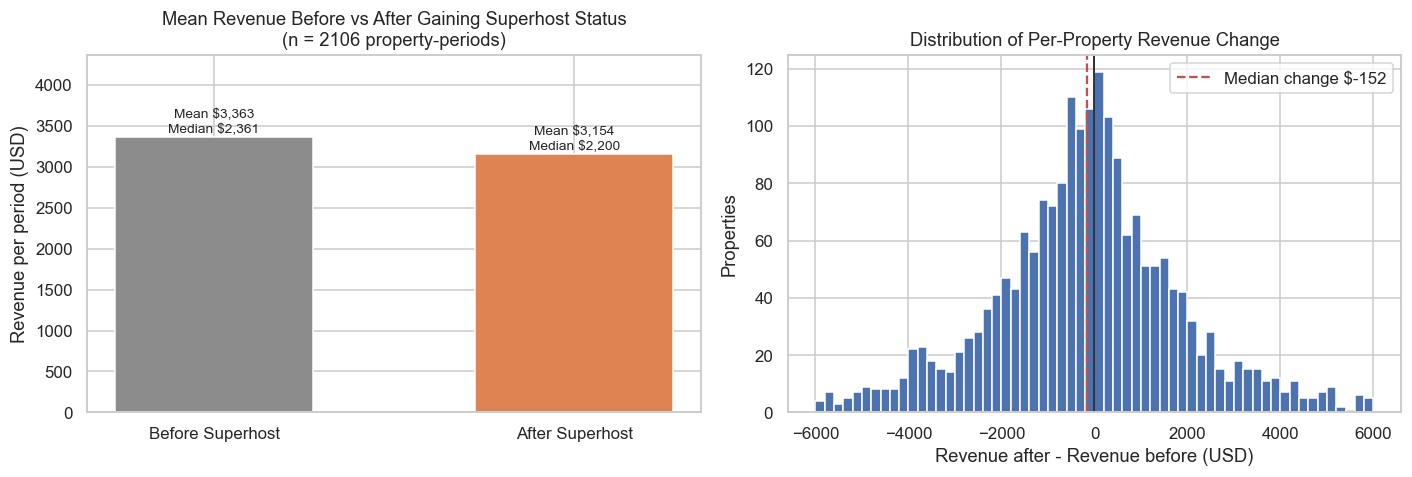

In [9]:
# The periods in which a property GAINED the badge. In these rows prev_revenue is
# the 'before' and revenue is the 'after' - same property, so it is its own control
gain = df[df['superhost_change_gain_superhost'] == 1]
print('Property-periods where Superhost status was gained: {}'.format(len(gain)))
print('Distinct properties in that set                   : {}'.format(gain['Airbnb Property ID'].nunique()))
print()

# A paired test needs both halves present, so drop rows missing either side
paired = gain.dropna(subset=['revenue', 'prev_revenue'])
print('Rows with BOTH before and after revenue recorded  : {}  ({} dropped: {} null prev_revenue,'
      ' {} null revenue)'.format(len(paired), len(gain) - len(paired),
                                 gain['prev_revenue'].isna().sum(), gain['revenue'].isna().sum()))
print('NOTE: a dropped row is usually a period with no bookings on one side, so this comparison')
print('      describes properties that were booked both before and after gaining the badge.')
print()

# Before/after summary table for the properties that gained the badge
before, after = paired['prev_revenue'], paired['revenue']
comp = pd.DataFrame({
    'Before Superhost (prev_revenue)': {'Mean': before.mean(), 'Median': before.median(),
                                        'Std dev': before.std(), 'Count': before.count()},
    'After Superhost (revenue)':       {'Mean': after.mean(), 'Median': after.median(),
                                        'Std dev': after.std(), 'Count': after.count()},
})
print('Revenue before vs after gaining Superhost status')
print(comp.round(2).to_string())
print()

# Each property's own revenue change, which is what a paired comparison needs
change = after - before
print('Per-property change in revenue (after - before)')
print('  Mean change   : ${:+,.2f}'.format(change.mean()))
print('  Median change : ${:+,.2f}'.format(change.median()))
print('  (those two null counts overlap - some rows are null on both sides)')
print('  Distinct properties behind the paired test: {}  (a few gained the badge more'.format(
    paired['Airbnb Property ID'].nunique()))
print('   than once, so they contribute more than one paired observation)')
print('  Properties whose revenue increased: {:.1%}'.format((change > 0).mean()))
print('  Properties whose revenue decreased: {:.1%}'.format((change < 0).mean()))
print('  Mean change as % of mean before   : {:+.1%}'.format(change.mean() / before.mean()))
print()

# ttest_REL (related), not ind: the two samples are the same properties measured
# twice, so the test looks at each property's own change
t, p = stats.ttest_rel(after, before)
print('Paired t-test (same property measured twice)')
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Rank-based version of the paired test - a check that does not assume normality
w, pw = stats.wilcoxon(after, before)
print('Wilcoxon signed-rank (non-parametric check)')
print('  statistic = {:,.0f}   p-value = {:.3e}'.format(w, pw))

# Left: bar chart of mean revenue before vs after gaining the badge
# Right: histogram of per-property change, to show how wide the spread around it is
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['Before Superhost', 'After Superhost']
means = [before.mean(), after.mean()]
medians = [before.median(), after.median()]
bars = axes[0].bar(labels, means, color=['#8C8C8C', '#DD8452'], width=0.55)
for bar, mn, mdn in zip(bars, means, medians):
    axes[0].text(bar.get_x() + bar.get_width() / 2, mn + 60,
                 'Mean ${:,.0f}\nMedian ${:,.0f}'.format(mn, mdn), ha='center', fontsize=9)
axes[0].set_title('Mean Revenue Before vs After Gaining Superhost Status\n(n = {} property-periods)'.format(len(paired)))
axes[0].set_ylabel('Revenue per period (USD)')
axes[0].set_ylim(0, max(means) * 1.30)

axes[1].hist(change, bins=60, range=(-6000, 6000), color='#4C72B0', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(change.median(), color='#C44E52', ls='--',
                label='Median change ${:+,.0f}'.format(change.median()))
axes[1].set_title('Distribution of Per-Property Revenue Change')
axes[1].set_xlabel('Revenue after - Revenue before (USD)')
axes[1].set_ylabel('Properties'); axes[1].legend()
plt.tight_layout()
plt.show()

### Q7 follow-up — before/after alone cannot answer the question

The before/after comparison says revenue went down slightly after the badge was gained.
Taken at face value that would suggest becoming a Superhost hurts revenue, which is almost
certainly wrong. The problem is that "before" and "after" are different points in time, and
Question 4 showed bookings swing hard with the season. If badges tend to be awarded going into
a weaker quarter, the drop is the calendar, not the badge.

So we add a control group: properties that did not gain the badge, measured across the
same period transitions. If gainers and non-gainers move together, the change is market-wide.
The difference between the two changes (a difference-in-differences) is the part that can
plausibly be attributed to the badge.

Gainers: n = 2106    Control (did not gain): n = 22774

Mean revenue change (this period - previous period), by evaluation period
                      Gainers  Control  Difference  Gainer rows
superhost_period_all                                           
5.0                     132.0   -301.0       433.0           60
6.0                   -1518.0   -574.0      -944.0           86
7.0                     435.0    822.0      -387.0           73
8.0                    -550.0   -401.0      -148.0          118
9.0                     262.0    -10.0       272.0          129
10.0                  -1344.0  -1136.0      -208.0          110
11.0                    510.0   1221.0      -711.0          178
12.0                  -1328.0  -1053.0      -275.0          122
13.0                    218.0    320.0      -103.0           89
14.0                   -430.0   -722.0       292.0          151
15.0                    882.0   1012.0      -131.0          169
16.0                   -364.0   -932.0

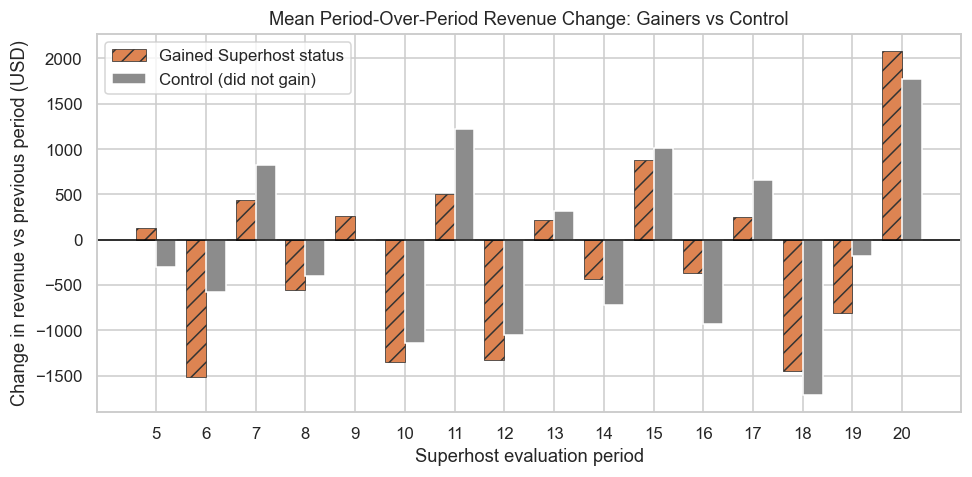

In [10]:
# Control group: properties that did NOT gain the badge, measured over the same
# period transitions. If both groups move together, the change is market-wide
control = df[df['superhost_change_gain_superhost'] == 0].dropna(subset=['revenue', 'prev_revenue'])
print('Gainers: n = {}    Control (did not gain): n = {}'.format(len(paired), len(control)))
print()

# Group a Series by another column's values: average change per evaluation period
gain_chg = (paired['revenue'] - paired['prev_revenue']).groupby(paired['superhost_period_all']).mean()
ctrl_chg = (control['revenue'] - control['prev_revenue']).groupby(control['superhost_period_all']).mean()
# Put both groups side by side, period by period
comp = pd.DataFrame({'Gainers': gain_chg, 'Control': ctrl_chg})
comp['Difference'] = comp['Gainers'] - comp['Control']
comp['Gainer rows'] = paired['superhost_period_all'].value_counts().sort_index()
print('Mean revenue change (this period - previous period), by evaluation period')
print(comp.round(0).to_string())
print()
print('-> The change swings between roughly -$1,500 and +$2,100 depending on the period.')
print('   Seasonality dwarfs anything the badge could be doing, and the control group swings')
print('   with the gainers almost period for period.')
print()

# Weight the control by the periods in which gains actually happened, so we compare
# like with like rather than letting the control's period mix do the work
# normalize=True turns counts into proportions - the share of badge-gains that
# happened in each period. These become the weights below
w = paired['superhost_period_all'].value_counts(normalize=True).sort_index()
# Weighted average: re-weight the control group so its mix of periods matches the
# gainers'. Without this we would be comparing different seasons to each other
ctrl_matched = (ctrl_chg.reindex(w.index) * w).sum()
gain_matched = (gain_chg.reindex(w.index) * w).sum()
print('Period-matched mean revenue change')
print('  Gainers                       : ${:+,.2f}'.format(gain_matched))
print('  Control, matched period mix   : ${:+,.2f}'.format(ctrl_matched))
print('  Difference-in-differences     : ${:+,.2f}'.format(gain_matched - ctrl_matched))
print()
print('Of the ${:+,.0f} raw before/after change, ${:+,.0f} is market-wide movement that the'.format(
    gain_matched, ctrl_matched))
print('control group experienced too, leaving ${:+,.0f} unexplained by seasonality.'.format(
    gain_matched - ctrl_matched))

# A point estimate on its own overstates what we know. Standard error of the weighted
# difference = gainer sampling variance + the period-weighted control variance.
_gd = (paired['revenue'] - paired['prev_revenue'])
_cd = (control['revenue'] - control['prev_revenue'])
_cvar = _cd.groupby(control['superhost_period_all']).var().reindex(w.index)
_cn = _cd.groupby(control['superhost_period_all']).size().reindex(w.index)
did = gain_matched - ctrl_matched
se = np.sqrt(_gd.var() / len(_gd) + ((w ** 2) * (_cvar / _cn)).sum())
print()
print('  Standard error                : ${:,.1f}'.format(se))
print('  95% confidence interval       : [${:+,.0f}, ${:+,.0f}]'.format(
    did - 1.96 * se, did + 1.96 * se))
print('  -> The interval CONTAINS ZERO. The difference-in-differences is not')
print('     distinguishable from zero, so the honest statement is "no measurable badge')
print('     effect in either direction" - not "the badge costs $148 per period".')

# Grouped bar chart of period-over-period revenue change, gainers vs control,
# to show the two groups rising and falling together
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['Gainers'], width=0.4, label='Gained Superhost status', color='#DD8452',
       hatch='//', edgecolor='#333333', linewidth=0.5)   # greyscale safety
ax.bar(x + 0.2, comp['Control'], width=0.4, label='Control (did not gain)', color='#8C8C8C')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([int(p) for p in comp.index])
ax.set_title('Mean Period-Over-Period Revenue Change: Gainers vs Control')
ax.set_xlabel('Superhost evaluation period')
ax.set_ylabel('Change in revenue vs previous period (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 7

Does revenue increase after gaining Superhost status? On this evidence, no — and the honest
answer is that the question as posed cannot be answered by a before/after bar chart.

Of 3,428 property-periods where the badge was gained (3,036 distinct properties), 2,106 have
revenue recorded on both sides. For those:

| | Before (`prev_revenue`) | After (`revenue`) |
|---|---|---|
| Mean | $3,362.58 | $3,154.07 |
| Median | $2,361.00 | $2,200.00 |

Revenue fell by a mean of -$208.51 and a median of -$152.50; only 45.8% of
properties improved. The paired t-test (t = -2.77, p = 0.006) and Wilcoxon (p = 2e-05) both say
the decline is larger than chance.

But the control group shows most of that decline is not about the badge. Question 4
established that bookings swing seasonally, and "before" and "after" are different quarters. When
we measure the same period-over-period change for properties that did not gain the badge, they
move almost in lockstep — both groups swing between roughly -$1,500 and +$2,100 depending on
which period transition you look at. Matching the control to the periods in which gains actually
occurred:

- Gainers: -$208 per period
- Control, same period mix: -$60
- Difference-in-differences: -$148

So of the raw $208 decline, roughly $60 is market-wide seasonal movement the control
experienced too, leaving about $148 unexplained by seasonality. That residual should not be
reported as an effect: its 95% confidence interval is **[−$307, +$10]**, which contains zero.
Once seasonality is absorbed there is no measurable badge effect in either direction.

Our conclusion: There is no evidence that gaining Superhost status raises revenue in the
period immediately after it is awarded, and the small apparent decline is mostly seasonality.
The most likely explanation for the residual is regression to the mean: the badge is awarded
following an unusually strong stretch, so the "before" figure is measured at a local peak and
almost has to fall back. This does not contradict Question 6 — Superhosts really do earn more
than non-Superhosts. It says the badge is a marker of properties that were already performing
well, not a switch that lifts revenue the moment it is granted.

There is a further reason to read this as "no measurable effect" rather than as a precise zero:
the measurement windows overlap. `available_days` — the exposure window a period measures, and the
denominator of `occupancy_rate` — has a median of **171 days**, while consecutive evaluation periods
are about **91 days** apart, so a property's "before" and "after" share roughly **47%** of their
measurement window. Any true effect is mechanically attenuated
toward zero by that overlap.

Methodological note: We report the mean of the per-property change, not the difference of two
group means, because the same property is measured twice. We also dropped 1,322 rows missing one
side, so this describes properties that were booked both before and after — properties that went
from idle to booked (or the reverse) are excluded, which is exactly where a badge effect might
otherwise show up.

**What this means for the business.** This is the **prescriptive** turn in the analysis, and the
answer is a negative one worth stating plainly: gaining the badge does not raise revenue in the
period after it is awarded. Once a matched control absorbs the seasonality, the
difference-in-differences is −$148 on a $3,363 base. Management should therefore treat Superhost
status as a **selection signal** that identifies listings already performing well, not as an
intervention that lifts revenue when extended to more hosts. A policy of "award more badges to
grow revenue" would rest on a correlation this analysis does not support.


---
# Question 8 — Revenue trend across evaluation periods

> Use a line chart to illustrate the trend in revenue over multiple evaluation periods for
> Superhosts. How does Superhost status impact revenue over time?

Chart choice and why: Mean revenue by `superhost_period_all`, with both groups on one set of
axes. A Superhost line on its own cannot distinguish "Superhosts are growing" from "the whole
Dallas market is growing" — the non-Superhost line is the control.

Given the skew found in Question 6 we plot the median as well as the mean, and print the row
count per period so thin periods can be flagged.

Mean / median revenue and row count by evaluation period
                                          mean  median  count
superhost_period_all Superhost status                        
5.0                  Non-Superhost     2448.19  1618.0    593
                     Superhost         3057.90  2546.0    239
6.0                  Non-Superhost     2269.10  1346.0    605
                     Superhost         2476.95  1779.0    301
7.0                  Non-Superhost     3149.52  1950.0    597
                     Superhost         3265.21  2400.0    313
8.0                  Non-Superhost     2780.24  1870.0    718
                     Superhost         3000.27  1949.5    426
9.0                  Non-Superhost     2814.00  1945.0    811
                     Superhost         3551.95  2571.0    573
10.0                 Non-Superhost     2194.88  1395.0    913
                     Superhost         2794.35  2070.0    723
11.0                 Non-Superhost     3731.82  2059.5    952
             

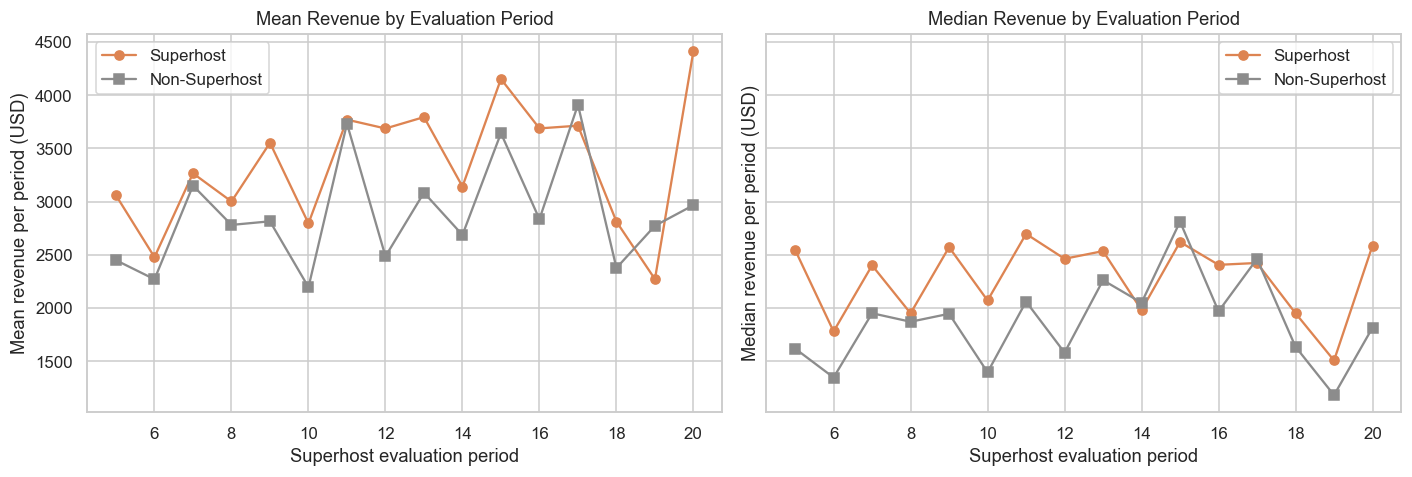

In [11]:
rev = df.dropna(subset=['revenue'])
# Grouping by two columns gives a two-level index; .agg runs several statistics at once
g = (rev.groupby(['superhost_period_all', 'Superhost status'])['revenue']
       .agg(['mean', 'median', 'count']).round(2))
print('Mean / median revenue and row count by evaluation period')
print(g.to_string())
print()

# unstack() lifts the inner index level (Superhost status) into columns, which is
# the shape matplotlib needs: one column per line on the chart
piv_mean = g['mean'].unstack()
piv_med = g['median'].unstack()
piv_n = g['count'].unstack()

# .any(axis=1) flags a period if EITHER group is thin (vs .all which needs both)
# Flag any period with thin data before we read trends off the chart
thin = piv_n[(piv_n < 100).any(axis=1)]
if len(thin):
    print('Periods with fewer than 100 rows in a group (treat with caution):')
    print(thin.astype(int).to_string())
else:
    print('No period has fewer than 100 rows in either group.')
print()

# Growth from the first period to the last, for each group
first, last = piv_mean.index.min(), piv_mean.index.max()
for lab in ['Superhost', 'Non-Superhost']:
    print('{:<14} mean revenue: period {:.0f} = ${:,.0f}  ->  period {:.0f} = ${:,.0f}  ({:+.1%})'.format(
        lab, first, piv_mean.loc[first, lab], last, piv_mean.loc[last, lab],
        piv_mean.loc[last, lab] / piv_mean.loc[first, lab] - 1))
print()
# The Superhost revenue premium in each period
gap = piv_mean['Superhost'] - piv_mean['Non-Superhost']
print('Superhost revenue premium (mean gap, USD per period)')
print(gap.round(0).to_string())
print('\nAverage premium across periods: ${:,.0f}'.format(gap.mean()))

# Line chart of revenue by period with one line per group, drawn twice:
# mean on the left, median on the right because revenue is so skewed
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, piv, name in [(axes[0], piv_mean, 'Mean'), (axes[1], piv_med, 'Median')]:
    for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
        ax.plot(piv.index, piv[lab], marker=mk, color=colr, label=lab)
    ax.set_title('{} Revenue by Evaluation Period'.format(name))
    ax.set_xlabel('Superhost evaluation period')
    ax.set_ylabel('{} revenue per period (USD)'.format(name))
    ax.legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 8

Why both groups on one chart? A Superhost line alone cannot distinguish "Superhosts are
growing" from "Dallas is growing." The non-Superhost line is the control, and we plot the median
alongside the mean because Question 6 showed how skewed revenue is.

Superhosts hold a persistent premium. Mean revenue is higher for Superhosts in 14 of the 16
evaluation periods, averaging +$465 across the 16 periods. The exceptions are periods 17
(-$196) and 19 (-$502). The premium is not stable — it ranges from $38 (period 11) to $1,449
(period 20) — which fits the seasonal swings found in Question 4 rather than any steady trend.

The premium is persistent but shows no trend. It is tempting to read growth into the two
endpoints — mean Superhost revenue runs $3,058 in period 5 against $4,415 in period 20 (+44.4%)
versus $2,448 to $2,966 (+21.1%) for non-Superhosts — but that comparison does not survive
scrutiny, for three reasons. Regressing the premium on period number gives a slope of **+$6 per
period (p = 0.82)**, indistinguishable from flat. The **median** premium moves the other way,
from $928 in period 5 to $771 in period 20. And periods are quarterly, so period 5 (Aug–Sep 2016)
and period 20 (May–Jun 2020) are *different seasons* — the exact error Questions 4 and 7 were
careful to avoid. Comparing like seasons flips the result — with one caveat that only became
visible later: period 17 is where Questions 13 and 15 find a suspected measurement-regime change
(the market-wide median listed rate roughly halves and stays there), so this comparison is
directional rather than precise, and both of the negative-premium periods below (17 and 19) sit
after that break. Period 5 → 17, both Aug–Sep, gives
Superhosts +21.4% against non-Superhosts +59.7%. Period 20 is also May–June 2020, so the
endpoint sits inside the COVID shock Question 4 identified.

What the data does support: Superhosts are persistently ahead, and there is no evidence the lead
is growing. Both lines share the same saw-tooth shape, confirming that period-to-period movement
is market seasonality affecting everyone.

How to state the impact honestly. Reading this as "Superhost status increases revenue over
time" would overstate it, and Question 7 is the reason: when we isolated properties at the moment
they gained the badge and compared them against a matched control, the effect was slightly
negative. The two results are consistent if Superhost status is largely a marker of
consistently strong properties rather than a cause of revenue growth — the badge tracks
listings that were already outperforming, and those listings continue to outperform. Selection is
doing more work here than treatment.

Sample sizes support the comparison throughout: no period has fewer than 100 rows in either
group, though early periods are thinner (239 Superhost rows in period 5 vs 1,081 in period 20),
so the early points carry more sampling noise than the later ones.

**What this means for the business.** Superhosts hold a persistent premium averaging +$465 per
period, but it is stable rather than growing (slope +$6/period, p = 0.82). Read alongside
Question 7, the honest reading is **selection rather than treatment**: the badge tracks
consistently strong listings rather than creating them. The **prescriptive** implication is about
where to spend. Identifying and supporting listings *before* they qualify is more likely to move revenue
than expanding badge eligibility after the fact — the same conclusion Question 7 reached from the
opposite direction.


---
# Question 9 — Scatter plot of rating vs revenue

> Create a scatter plot to examine the relationship between rating_ave_pastYear and revenue.
> What correlation exists between ratings and revenue?

Chart choice and why: a scatter plot, because Lecture 3 maps *relationship between two
continuous variables* to a scatter. At 26,686 points a raw scatter is a block of ink, so we
draw it at `alpha=0.08` and overlay a binned-mean and binned-median line so the shape is
readable. Bins holding fewer than 30 rows are suppressed rather than plotted.

Two things have to be printed before the correlation can be interpreted. First, how
concentrated the ratings are — if there is no variation in x, there is nothing for revenue to
track. Second, a banded table of revenue **and median review count** by rating band, because
the review count is what explains what happens at the top of the scale.

A second panel splits the scatter by Superhost status on a shared y-axis: Questions 3, 6 and 8
all found the two groups behave differently, and a pooled correlation can hide subgroups moving
in opposite directions.

Total rows                            : 48,711
Dropped - null rating_ave_pastYear    : 11,629 (23.9%)
Dropped - null revenue (never booked) : 16,861 (34.6%)
Rows surviving both filters           : 26,686
Distinct properties behind those rows : 6,669 of 9,599
These are property-PERIODS, not listings: a property active in many periods contributes many points.

Distribution of rating_ave_pastYear on the 26,686 analysis rows
  min 1.00 | p5 4.35 | p25 4.68 | median 4.82 | p75 4.94 | p95 5.00 | max 5.00
  standard deviation: 0.246
  share >= 4.5: 90.1%   >= 4.8: 54.3%   exactly 5.0: 17.0%   below 4.0: 0.8%

Deciles of rating_ave_pastYear
0.1    4.500
0.2    4.625
0.3    4.718
0.4    4.771
0.5    4.818
0.6    4.858
0.7    4.914
0.8    4.965
0.9    5.000

Revenue by rating band
             rows  mean_revenue  median_revenue  median_booked_days  median_numReviews
Rating band                                                                           
<=4.0         403        1385.0           94

  (b) Superhost      Pearson r = +0.0213 (p = 1.91e-02) | Spearman rho = -0.0106 (p = 2.44e-01) | n = 12,131
  (c) numReviews_pastYear >= 10        Pearson r = +0.0854 (p = 2.89e-37) | Spearman rho = +0.0697 (p = 2.45e-25) | n = 22,219

Same correlation with never-booked periods counted as $0 (revenue_z, n = 37,082)
  Pearson  r = +0.0746  (p = 6.82e-47)
  Spearman rho = +0.0146  (p = 5.00e-03)
  Mean rating, revenue present : 4.768  (n = 26,686)
  Mean rating, revenue null    : 4.731  (n = 10,396)
  -> the dropped rows rate slightly LOWER, so the booked-only frame is mildly selected.
  The written answer is read from the booked-only frame (26,686 rows), because the question asks how rating relates to revenue earned; the zero-filled frame is reported so the selection is visible rather than hidden.

Binned-mean line: bins suppressed for n < 30 -> (3.5, 3.6] (n=6), (3.6, 3.7] (n=29), (3.7, 3.8] (n=27)
y-axis capped at the 99th percentile of revenue = $18,472; 267 points (1.0%) sit above 

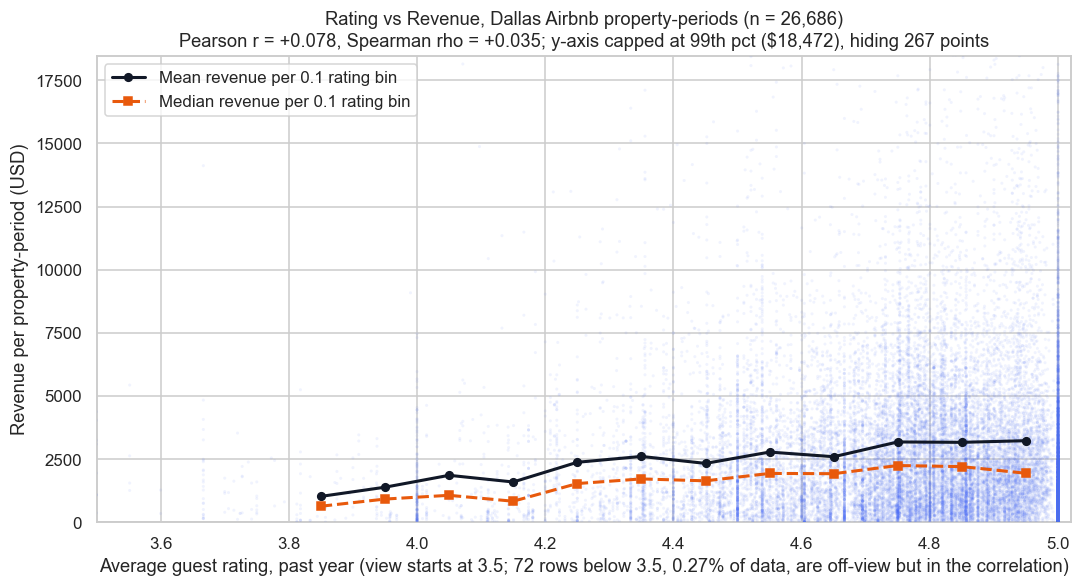

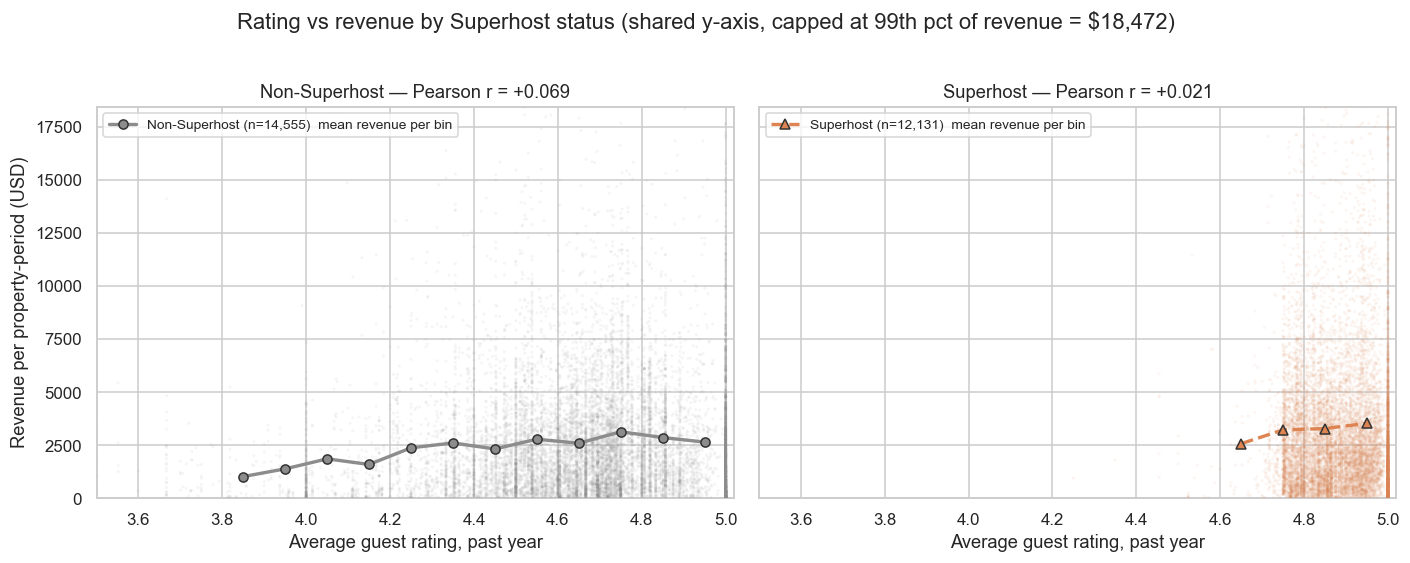

In [12]:
# Q9 asks for a relationship between two continuous variables, which Lecture 3 maps to a
# scatter plot. Both columns must be present for a point to exist, so we filter on both
# and report each filter separately - the two nulls have different meanings
q9 = df.dropna(subset=['rating_ave_pastYear', 'revenue'])
print('Total rows                            : {:,}'.format(len(df)))
print('Dropped - null rating_ave_pastYear    : {:,} ({:.1%})'.format(
    df['rating_ave_pastYear'].isna().sum(), df['rating_ave_pastYear'].isna().mean()))
print('Dropped - null revenue (never booked) : {:,} ({:.1%})'.format(
    df['revenue'].isna().sum(), df['revenue'].isna().mean()))
print('Rows surviving both filters           : {:,}'.format(len(q9)))
print('Distinct properties behind those rows : {:,} of {:,}'.format(
    q9['Airbnb Property ID'].nunique(), df['Airbnb Property ID'].nunique()))
print('These are property-PERIODS, not listings: a property active in many periods '
      'contributes many points.')
print()

# Read this block before reading the scatter. If ratings barely vary, a near-zero
# correlation is a property of the ratings scale, not evidence about quality
r = q9['rating_ave_pastYear']
print('Distribution of rating_ave_pastYear on the {:,} analysis rows'.format(len(q9)))
print('  min {:.2f} | p5 {:.2f} | p25 {:.2f} | median {:.2f} | p75 {:.2f} | p95 {:.2f} | max {:.2f}'.format(
    r.min(), r.quantile(.05), r.quantile(.25), r.median(), r.quantile(.75), r.quantile(.95), r.max()))
print('  standard deviation: {:.3f}'.format(r.std()))
print('  share >= 4.5: {:.1%}   >= 4.8: {:.1%}   exactly 5.0: {:.1%}   below 4.0: {:.1%}'.format(
    (r >= 4.5).mean(), (r >= 4.8).mean(), (r == 5.0).mean(), (r < 4.0).mean()))
print()
print('Deciles of rating_ave_pastYear')
print(r.quantile(np.arange(0.1, 1.0, 0.1)).round(3).to_string())
print()

# Required table: revenue by rating band. numReviews_pastYear is in here on purpose -
# it is what explains the shape at the top of the scale
band_edges = [-np.inf, 4.0, 4.4, 4.6, 4.8, 4.999, 5.0]
band_names = ['<=4.0', '4.0-4.4', '4.4-4.6', '4.6-4.8', '4.8-4.99', '5.0 exactly']
q9 = q9.copy()
q9['Rating band'] = pd.cut(r, bins=band_edges, labels=band_names, include_lowest=True)
band_tbl = (q9.groupby('Rating band', observed=False)
              .agg(rows=('revenue', 'size'),
                   mean_revenue=('revenue', 'mean'),
                   median_revenue=('revenue', 'median'),
                   median_booked_days=('booked_days', 'median'),
                   median_numReviews=('numReviews_pastYear', 'median'))
              .round(0))
print('Revenue by rating band')
print(band_tbl.to_string())
print()

# Correlations are computed on ALL 26,686 rows, including the sub-3.5 tail the chart
# clips and the points above the y-cap. The chart is trimmed for readability; the
# statistics are not trimmed at all
pear = stats.pearsonr(q9['rating_ave_pastYear'], q9['revenue'])
spear = stats.spearmanr(q9['rating_ave_pastYear'], q9['revenue'])
print('Correlation, rating_ave_pastYear vs revenue (n = {:,})'.format(len(q9)))
print('  Pearson  r = {:+.4f}  (p = {:.2e})   -> r-squared = {:.4f} ({:.2%} of variance)'.format(
    pear[0], pear[1], pear[0] ** 2, pear[0] ** 2))
print('  Spearman rho = {:+.4f}  (p = {:.2e})'.format(spear[0], spear[1]))
print()

print('Robustness checks')
# (a) Q6 showed revenue is heavily right-skewed; Pearson assumes a linear relation,
# so we repeat it on log revenue where the skew is pulled out
log_p = stats.pearsonr(q9['rating_ave_pastYear'], np.log(q9['revenue']))
print('  (a) Pearson on log(revenue)          r = {:+.4f} (p = {:.2e}, n = {:,})'.format(
    log_p[0], log_p[1], len(q9)))
# (b) A pooled correlation can hide subgroups moving in opposite directions
for lab in ['Non-Superhost', 'Superhost']:
    sub = q9[q9['Superhost status'] == lab]
    sp_p = stats.pearsonr(sub['rating_ave_pastYear'], sub['revenue'])
    sp_s = stats.spearmanr(sub['rating_ave_pastYear'], sub['revenue'])
    print('  (b) {:<14} Pearson r = {:+.4f} (p = {:.2e}) | Spearman rho = {:+.4f} (p = {:.2e}) | n = {:,}'.format(
        lab, sp_p[0], sp_p[1], sp_s[0], sp_s[1], len(sub)))
# (c) A rating built on 2 reviews is mostly noise; restrict to ratings with real evidence
heavy = q9[q9['numReviews_pastYear'] >= 10]
h_p = stats.pearsonr(heavy['rating_ave_pastYear'], heavy['revenue'])
h_s = stats.spearmanr(heavy['rating_ave_pastYear'], heavy['revenue'])
print('  (c) numReviews_pastYear >= 10        Pearson r = {:+.4f} (p = {:.2e}) | Spearman rho = {:+.4f} (p = {:.2e}) | n = {:,}'.format(
    h_p[0], h_p[1], h_s[0], h_s[1], len(heavy)))
print()

# The excluded third of the data. Dropping null revenue conditions the sample on having
# been booked at all, so we re-run on every rated row with never-booked periods as 0
rated = df.dropna(subset=['rating_ave_pastYear'])
z_p = stats.pearsonr(rated['rating_ave_pastYear'], rated['revenue_z'])
z_s = stats.spearmanr(rated['rating_ave_pastYear'], rated['revenue_z'])
print('Same correlation with never-booked periods counted as $0 (revenue_z, n = {:,})'.format(len(rated)))
print('  Pearson  r = {:+.4f}  (p = {:.2e})'.format(z_p[0], z_p[1]))
print('  Spearman rho = {:+.4f}  (p = {:.2e})'.format(z_s[0], z_s[1]))
print('  Mean rating, revenue present : {:.3f}  (n = {:,})'.format(
    rated.loc[rated['revenue'].notna(), 'rating_ave_pastYear'].mean(),
    rated['revenue'].notna().sum()))
print('  Mean rating, revenue null    : {:.3f}  (n = {:,})'.format(
    rated.loc[rated['revenue'].isna(), 'rating_ave_pastYear'].mean(),
    rated['revenue'].isna().sum()))
print('  -> the dropped rows rate slightly LOWER, so the booked-only frame is mildly selected.')
print('  The written answer is read from the booked-only frame (26,686 rows), because the '
      'question asks how rating relates to revenue earned; the zero-filled frame is reported '
      'so the selection is visible rather than hidden.')
print()

# --- Chart prep -------------------------------------------------------------------
# 0.1-wide rating bins. Any bin with fewer than 30 rows is suppressed rather than
# plotted, because a mean over a handful of points is noise dressed as a trend
bin_edges = np.round(np.arange(3.5, 5.01, 0.1), 2)
MIN_N = 30

def binned(frame):
    """Mean / median revenue per 0.1 rating bin, suppressing thin bins."""
    cut = pd.cut(frame['rating_ave_pastYear'], bins=bin_edges)
    agg = frame.groupby(cut, observed=False)['revenue'].agg(['size', 'mean', 'median'])
    agg['centre'] = [iv.mid for iv in agg.index]
    return agg

allb = binned(q9)
thin = allb[(allb['size'] > 0) & (allb['size'] < MIN_N)]
empty = allb[allb['size'] == 0]
print('Binned-mean line: bins suppressed for n < {} -> {}'.format(
    MIN_N, ', '.join('{} (n={})'.format(iv, int(n)) for iv, n in thin['size'].items()) or 'none'))
if len(empty):
    print('Bins with no rows at all: {}'.format(', '.join(str(iv) for iv in empty.index)))
keep = allb[allb['size'] >= MIN_N]

# The chart is clipped in both directions for readability; both clips are reported and
# neither touches the statistics above
cap = q9['revenue'].quantile(0.99)
n_above = int((q9['revenue'] > cap).sum())
n_below_x = int((q9['rating_ave_pastYear'] < 3.5).sum())
print('y-axis capped at the 99th percentile of revenue = ${:,.0f}; {:,} points ({:.1%}) '
      'sit above the cap and are not drawn.'.format(cap, n_above, n_above / len(q9)))
print('x-axis starts at 3.5; {:,} rows ({:.2%}) rate below that and are drawn off-view but '
      'are still in every correlation.'.format(n_below_x, n_below_x / len(q9)))

# --- Figure 1: the scatter --------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(q9['rating_ave_pastYear'], q9['revenue'], s=4, alpha=0.08,
           color='#4C6EF5', edgecolors='none', zorder=3)
# Two summary lines because revenue is skewed: the mean is pulled by the top tail,
# the median is what a typical listing in that band earns
ax.plot(keep['centre'], keep['mean'], color='#111827', marker='o', linestyle='-',
        linewidth=2, markersize=5, zorder=5, label='Mean revenue per 0.1 rating bin')
ax.plot(keep['centre'], keep['median'], color='#E8590C', marker='s', linestyle='--',
        linewidth=2, markersize=5, zorder=5, label='Median revenue per 0.1 rating bin')
ax.set_xlim(3.5, 5.02)
ax.set_ylim(0, cap)
ax.set_xlabel('Average guest rating, past year (view starts at 3.5; {:,} rows below 3.5, '
              '{:.2%} of data, are off-view but in the correlation)'.format(n_below_x, n_below_x / len(q9)))
ax.set_ylabel('Revenue per property-period (USD)')
ax.set_title('Rating vs Revenue, Dallas Airbnb property-periods (n = {:,})\n'
             'Pearson r = {:+.3f}, Spearman rho = {:+.3f}; y-axis capped at 99th pct '
             '(${:,.0f}), hiding {:,} points'.format(
                 len(q9), pear[0], spear[0], cap, n_above))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Figure 2: split by Superhost status, shared y-axis ---------------------------
# Q3/Q6/Q8 all found the two groups behave differently, and a pooled correlation can
# hide subgroups pulling in opposite directions. sharey= keeps the panels comparable
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
panels = [('Non-Superhost', '#8C8C8C', 'o', '-'), ('Superhost', '#DD8452', '^', '--')]
for ax, (lab, colr, mk, ls) in zip(axes, panels):
    sub = q9[q9['Superhost status'] == lab]
    ax.scatter(sub['rating_ave_pastYear'], sub['revenue'], s=4, alpha=0.08,
               color=colr, edgecolors='none', zorder=3)
    bs = binned(sub)
    bs = bs[bs['size'] >= MIN_N]
    r_i = stats.pearsonr(sub['rating_ave_pastYear'], sub['revenue'])[0]
    ax.plot(bs['centre'], bs['mean'], color=colr, marker=mk, linestyle=ls, linewidth=2.2,
            markersize=6, markeredgecolor='#333333', zorder=5,
            label='{} (n={:,})  mean revenue per bin'.format(lab, len(sub)))
    ax.set_xlim(3.5, 5.02)
    ax.set_xlabel('Average guest rating, past year')
    ax.set_title('{} — Pearson r = {:+.3f}'.format(lab, r_i))
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylim(0, cap)
axes[0].set_ylabel('Revenue per property-period (USD)')
plt.suptitle('Rating vs revenue by Superhost status (shared y-axis, capped at 99th pct '
             'of revenue = ${:,.0f})'.format(cap), y=1.02)
plt.tight_layout()
plt.show()

### Findings — Question 9

Is there a correlation between higher ratings and higher revenue? Technically yes, practically
no. Pearson *r* = +0.078 across 26,686 property-periods (p = 5e-37) and Spearman rho = +0.035
(p = 1.5e-08). The p-values are tiny only because *n* is large; the effect is not.
*r*² = 0.0060, so rating explains **0.6% of the variance in revenue** — under one percent. The
robustness checks do not rescue it: log-revenue Pearson (Q6 showed how skewed revenue is)
*r* = +0.098, and restricting to ratings backed by at least 10 reviews gives *r* = +0.085,
rho = +0.070. Every variant lands in the same near-zero band.

**Range restriction is a large part of why.** The median rating is 4.82, 90.1% of rows sit at
4.5 or above, 54.3% at 4.8 or above, 17.0% are exactly 5.0, and only 0.8% fall below 4.0. The
standard deviation is 0.246 on a five-point scale. With almost all the mass packed into the top
half-point, there is very little variation in x left for revenue to track, so a near-zero
correlation is partly a property of how the Airbnb ratings system compresses — not evidence
that quality is irrelevant. The split panel makes this concrete: within Superhosts the rating
SD is 0.085 and 99.8% of rows are at 4.6 or above (the badge requires a high rating), and their
correlation collapses to *r* = +0.021 (Spearman rho = -0.011, p = 0.24, not significant). Among
non-Superhosts, where ratings actually vary (SD 0.289), *r* = +0.069. Less range, less
correlation — the pattern you expect from restriction, not from a real subgroup difference.

**The actual finding is the non-monotonicity, and Pearson cannot see it.** Reading the banded
table, mean revenue climbs steadily from $1,385 (rating <= 4.0) to $2,981 (4.6–4.8) to $3,345
(4.8–4.99) — and then *falls* to $2,916 at exactly 5.0. Median revenue falls harder, from
$2,231 to $1,596, and median booked days from 25 to 18. The review-count column explains it:
rows at exactly 5.0 have a median of **7** reviews, against 143 in the 4.6–4.8 band and 62 in
the 4.8–4.99 band. A perfect score is mostly a *thin-evidence* score — new or low-volume
listings with too few reviews for any of them to be below 5 — not a superior property. The same
mechanism runs at the other end: the <= 4.0 band also has a median of 3 reviews, so its low
revenue is partly low volume too. The usable pattern is therefore a **rise up to roughly 4.8
followed by a plateau**, and a single linear coefficient is the wrong summary for a curve that
bends.

Which frame the answer is read from. The headline numbers come from the 26,686 rows with both
a rating and a revenue figure. Re-running on all 37,082 rated rows with never-booked periods
entered as $0 (`revenue_z`) barely moves it: Pearson +0.075, Spearman +0.015. The two frames
agree, so the conclusion does not depend on the choice.

**What this means for the business.** This is **descriptive/diagnostic** analysis, and the
lever it touches is **customer intimacy** — rating is the platform's service-quality signal.
The finding is that pushing an already-4.8 listing toward 5.0 has **no measurable revenue
return**; revenue is flat-to-falling across that stretch. Incremental host effort, and any
Airbnb incentive spend, is better aimed at the ~10% of property-periods below 4.5. The
<= 4.0 band earns **$1,596 less on average** than the 4.6–4.8 band (and $1,960 less than the
4.8–4.99 band) — though the same table shows part of that gap is review volume rather than
rating, so it is an upper bound on what raising a rating alone would recover. Stated plainly: rating is a **hygiene factor, not a pricing lever**
— treating it as a **value-capture** instrument ("get to 5 stars, charge more, earn more") is a
claim this data does not support. Looking ahead to Question 11, `rating_ave_pastYear` should be
expected to sit far behind `occupancy_rate` (Pearson 0.22) and roughly level with
`numReviews_pastYear` (0.08 against 0.07) — near-zero on the linear measure. Note the ordering
depends on which coefficient is read: on rank correlation `numReviews_pastYear` (rho 0.21)
pulls well clear of rating (rho 0.03).

**Limitations.** This is correlational and cannot establish that ratings cause revenue.
(a) The causality plausibly runs backwards: more bookings generate more reviews, and more
reviews move the rating — the exactly-5.0 band, with a median of 7 reviews, is that mechanism
visible in the table. (b) Dropping the 10,396 rated-but-never-booked rows conditions the sample
on having been booked at all, which truncates the outcome variable; those rows have a slightly
*lower* mean rating (4.731 vs 4.768), so the surviving sample is mildly selected upward.
(c) Revenue is confounded by `Nightly Rate`, `Listing Type` and `Neighborhood`, none of which
are controlled here — a 4.9-rated entire home downtown and a 4.9-rated private room in an outer
ZIP are one point each on this chart. Nothing here licenses the sentence "higher ratings drive
revenue."

---
# Question 10 — Listing type composition of Superhost bookings

> What listing type dominates bookings for Superhosts? Decide on the best way to visualize the
> composition of bookings by Listing Type and explain your conclusions.

"Dominates bookings" has to be defined before it can be measured. We read it as **share of total
booked nights** — `booked_days_z`, the null-filled `booked_days` used in Q2 and Q3, so a
property-period that took no bookings enters as 0 nights instead of being dropped. A count of
rows or of listings answers a different question: how much *inventory* a type has, not how much
of the *demand* it absorbed. The cell prints all three denominators — listings, nights and
revenue — because they disagree, and the disagreement is the finding.

No rows are filtered for this question. `Listing Type` has four values and zero nulls, so all
48,711 property-periods are used and the cell prints the arithmetic proving it.

Chart choice and why: Lecture 3 maps a *composition* question to a pie or a stacked bar. We
reject the pie explicitly — there are four categories, two of them under 3.2%, a pie cannot put
Superhosts and non-Superhosts side by side, and adjacent wedges collapse into each other once
the notebook is printed to greyscale PDF. A **100% stacked horizontal bar** keeps the
part-to-whole reading, adds the group comparison a pie cannot show, and stays legible in print.
Each listing type carries both a distinct fill and a distinct hatch, and the two segments under
4% get leader labels outside the bar so they are still readable.

Panel B is the point of the figure: the same Superhost population, drawn three times under three
denominators. Reading only the booked-nights bar would mislead a manager who is actually
accountable for dollars.

MEASURE: "dominates bookings" = share of total BOOKED NIGHTS (booked_days_z, the null-filled
  booked_days used in Q2/Q3, so a property-period with no bookings enters as 0 nights rather
  than being dropped). A count of rows or of listings answers a different question - how much
  inventory a type has, not how much of the demand it absorbed - and we report those separately.

Data shape before anything is computed
  Total rows                          : 48,711
  Listing Type value counts (dropna=False):
      Entire home/apt : 36,725
      Private room    : 10,545
      Shared room     : 1,330
      Hotel room      : 111
  Null Listing Type                   : 0
  Rows with Superhost == 1            : 15,920
  Rows with Superhost == 0            : 32,791
  Rows with null booked_days          : 16,861 (34.6%) -> set to 0 nights, NOT dropped
  Rows removed by any filter in Q10   : 0  (15,920 Superhost + 32,791 non-Superhost = 48,711 = all rows)

Superhosts (15,920 property-periods, 4,189 

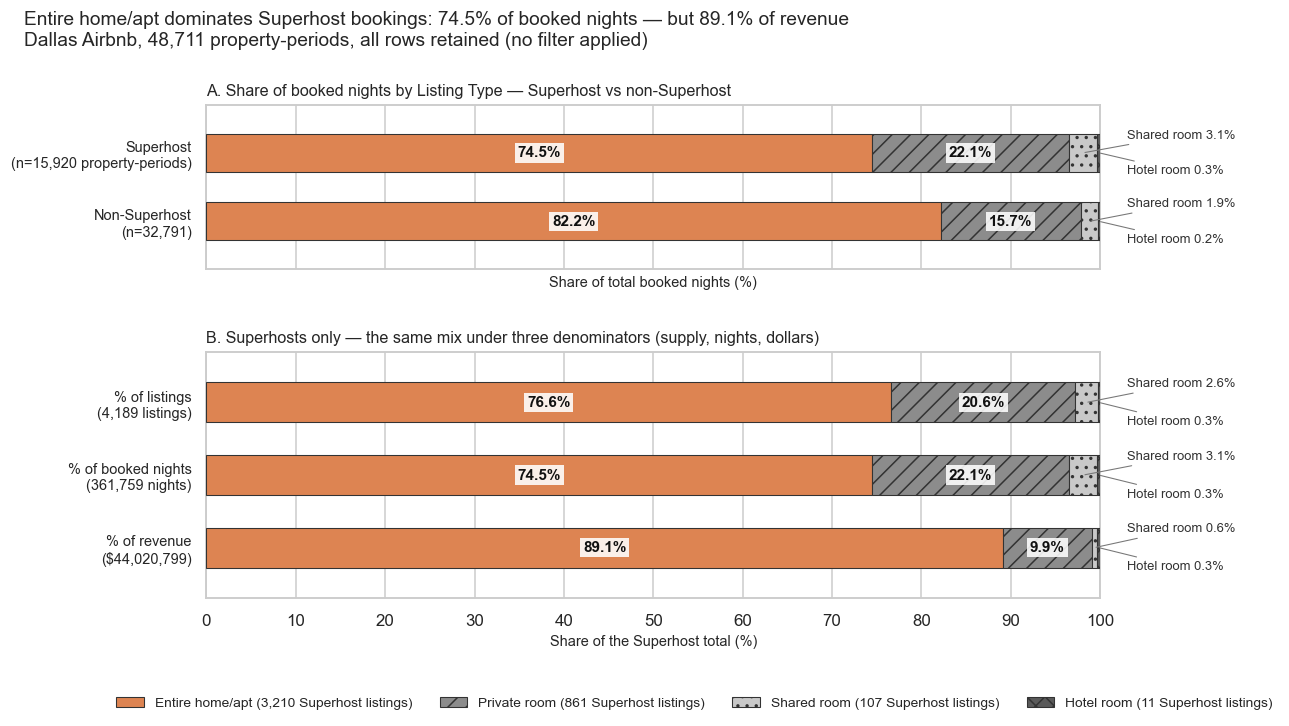

Revenue per booked night, Superhosts (total_revenue / total_booked_nights)
Listing Type
Entire home/apt    145.61
Private room        54.67
Shared room         24.95
Hotel room         123.64
  Superhost pooled average: $121.69 per booked night


In [13]:
# Q10 asks which listing type "dominates bookings", so the first job is to say what the
# measure is. Rows and listings are supply; booked nights are demand, and they disagree here
TYPE_ORDER = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
print('MEASURE: "dominates bookings" = share of total BOOKED NIGHTS (booked_days_z, the '
      'null-filled\n  booked_days used in Q2/Q3, so a property-period with no bookings '
      'enters as 0 nights rather\n  than being dropped). A count of rows or of listings '
      'answers a different question - how much\n  inventory a type has, not how much of the '
      'demand it absorbed - and we report those separately.')
print()

# --- Step 1: data shape. Nothing is filtered out in this question, so we prove it ---
print('Data shape before anything is computed')
print('  Total rows                          : {:,}'.format(len(df)))
print('  Listing Type value counts (dropna=False):')
for t, n in df['Listing Type'].value_counts(dropna=False).items():
    print('      {:<16}: {:,}'.format(str(t), int(n)))
print('  Null Listing Type                   : {:,}'.format(int(df['Listing Type'].isna().sum())))
print('  Rows with Superhost == 1            : {:,}'.format(int((df['Superhost'] == 1).sum())))
print('  Rows with Superhost == 0            : {:,}'.format(int((df['Superhost'] == 0).sum())))
print('  Rows with null booked_days          : {:,} ({:.1%}) -> set to 0 nights, NOT dropped'.format(
    int(df['booked_days'].isna().sum()), df['booked_days'].isna().mean()))
kept = int((df['Superhost'] == 1).sum()) + int((df['Superhost'] == 0).sum())
print('  Rows removed by any filter in Q10   : {:,}  ({:,} Superhost + {:,} non-Superhost = {:,} = all rows)'.format(
    len(df) - kept, int((df['Superhost'] == 1).sum()), int((df['Superhost'] == 0).sum()), kept))
print()


def composition(frame):
    """Composition of one group by Listing Type, on three different denominators.

    listings uses nunique of the property ID, not row count: this is panel data and a
    property active in 8 periods would otherwise be counted 8 times as supply.
    """
    g = frame.groupby('Listing Type', observed=False).agg(
        rows=('booked_days_z', 'size'),
        listings=('Airbnb Property ID', 'nunique'),
        total_booked_nights=('booked_days_z', 'sum'),
        mean_booked_nights_per_row=('booked_days_z', 'mean'),
        median_booked_nights=('booked_days_z', 'median'),
        total_revenue=('revenue_z', 'sum'))
    for num, name in [('listings', '% of listings'),
                      ('total_booked_nights', '% of booked nights'),
                      ('total_revenue', '% of revenue')]:
        denom = g[num].sum()
        g[name] = 100 * g[num] / denom if denom else np.nan   # guarded denominator
    return g.sort_values('total_booked_nights', ascending=False)


sh_tbl = composition(df[df['Superhost'] == 1])
ns_tbl = composition(df[df['Superhost'] == 0])

fmt = {'total_booked_nights': '{:,.0f}', 'total_revenue': '{:,.0f}',
       'mean_booked_nights_per_row': '{:.2f}', 'median_booked_nights': '{:.1f}',
       '% of listings': '{:.2f}', '% of booked nights': '{:.2f}', '% of revenue': '{:.2f}',
       'rows': '{:,}', 'listings': '{:,}'}
print('Superhosts ({:,} property-periods, {:,} distinct listings) - composition by Listing Type'.format(
    int((df['Superhost'] == 1).sum()), df.loc[df['Superhost'] == 1, 'Airbnb Property ID'].nunique()))
print(sh_tbl.to_string(formatters={k: v.format for k, v in fmt.items()}))
print()
print('Non-Superhosts ({:,} property-periods, {:,} distinct listings) - same table'.format(
    int((df['Superhost'] == 0).sum()), df.loc[df['Superhost'] == 0, 'Airbnb Property ID'].nunique()))
print(ns_tbl.to_string(formatters={k: v.format for k, v in fmt.items()}))
print()

# Side by side on the booked-nights measure only, forced into a fixed category order
# rather than trusting groupby's sort
side = pd.DataFrame({
    'Superhost %': sh_tbl['% of booked nights'],
    'Non-Superhost %': ns_tbl['% of booked nights']}).reindex(TYPE_ORDER)
side['Difference (pp)'] = side['Superhost %'] - side['Non-Superhost %']
# The listing mix is the control: if it moves too, the booked-night gap is just supply mix
side['SH listing mix %'] = sh_tbl['% of listings'].reindex(TYPE_ORDER)
side['Non-SH listing mix %'] = ns_tbl['% of listings'].reindex(TYPE_ORDER)
print('Share of booked nights, side by side (with the listing mix as a control)')
print(side.round(2).to_string())
print('  -> The listing MIX is near-identical across the two groups ({:.1f}% vs {:.1f}% entire home),'.format(
    side.loc['Entire home/apt', 'SH listing mix %'], side.loc['Entire home/apt', 'Non-SH listing mix %']))
print('     so "Superhosts favour entire homes" is not supported. The booked-night difference')
print('     comes from how intensely each type books, which is the next table.')
print()

# --- Step 2: composition vs intensity ------------------------------------------------
# A type can hold a big share because there are many of them or because each books more.
# Means only are restricted to on_market rows: an off-market row contributes 0 nights and
# so cannot move a share of totals, but it does drag a mean downward
om = df[df['on_market']]
print('Booking INTENSITY: mean booked nights per property-period, on-market rows only')
print('  On-market rows: {:,} of {:,} ({:,} off-market rows excluded from the means only;'.format(
    len(om), len(df), len(df) - len(om)))
print('  the totals above stay on all {:,} rows).'.format(len(df)))
inten = om.pivot_table(index='Listing Type', columns='Superhost status',
                       values='booked_days_z', aggfunc='mean').reindex(TYPE_ORDER)
n_rows = om.pivot_table(index='Listing Type', columns='Superhost status',
                        values='booked_days_z', aggfunc='size').reindex(TYPE_ORDER)
inten = inten[['Superhost', 'Non-Superhost']]
inten['Gap (SH - non, nights)'] = inten['Superhost'] - inten['Non-Superhost']
inten['Ratio'] = inten['Superhost'] / inten['Non-Superhost'].where(inten['Non-Superhost'] != 0)
inten['n SH'] = n_rows['Superhost']
inten['n non-SH'] = n_rows['Non-Superhost']
print(inten.round(2).to_string())
print('  -> Within Superhosts the four types book at almost the same intensity '
      '({:.1f} to {:.1f} nights),'.format(inten['Superhost'].min(), inten['Superhost'].max()))
print('     so Entire home/apt dominates because of SUPPLY ({:.1f}% of Superhost listings), '
      'not because'.format(side.loc['Entire home/apt', 'SH listing mix %']))
print('     each entire home books more than a private or shared room does.')
print()

# --- Step 3: robustness check 1, does the panel structure drive the shares? -----------
# A share of a SUM is invariant to how the sum is split across rows; a COUNT is not.
# Collapsing to one row per property proves the first half of that sentence
collapsed = (df[df['Superhost'] == 1]
             .groupby(['Airbnb Property ID', 'Listing Type'], observed=False)['booked_days_z']
             .sum().reset_index())
col_share = collapsed.groupby('Listing Type', observed=False)['booked_days_z'].sum()
col_share = 100 * col_share / col_share.sum()
chk = pd.DataFrame({'Panel rows (15,920)': sh_tbl['% of booked nights'],
                    'Collapsed to listings ({:,})'.format(len(collapsed)): col_share}).reindex(TYPE_ORDER)
chk['Difference (pp)'] = chk.iloc[:, 0] - chk.iloc[:, 1]
print('Robustness 1 - panel structure. Superhost booked-night shares, per-row vs per-listing')
print(chk.round(4).to_string())
print('  -> Largest difference: {:.10f} pp. A share of TOTALS is invariant to the panel structure. A'.format(
    chk['Difference (pp)'].abs().max()))
print('     COUNT is not: Entire home/apt is {:,} Superhost rows but only {:,} Superhost listings.'.format(
    int(sh_tbl.loc['Entire home/apt', 'rows']), int(sh_tbl.loc['Entire home/apt', 'listings'])))
print()

# --- Step 4: robustness check 2, is the headline share stable over time? -------------
per = (df[df['Superhost'] == 1]
       .pivot_table(index='superhost_period_all', columns='Listing Type',
                    values='booked_days_z', aggfunc='sum')
       .reindex(columns=TYPE_ORDER).fillna(0))
per_pct = 100 * per.div(per.sum(axis=1), axis=0)   # row sums are period totals, all > 0
print('Robustness 2 - stability over time. Superhost share of booked nights (%) by period')
print(per_pct.round(1).to_string())
eh = per_pct['Entire home/apt']
print('  -> NOT stable. Entire home/apt drifts from {:.1f}% (period {:.0f}) to {:.1f}% (period {:.0f}),'.format(
    eh.iloc[0], per_pct.index[0], eh.iloc[-1], per_pct.index[-1]))
print('     an {:.1f} pp range, while Private room falls from {:.1f}% to {:.1f}%. The headline {:.1f}%'.format(
    eh.max() - eh.min(), per_pct['Private room'].iloc[0], per_pct['Private room'].iloc[-1],
    sh_tbl.loc['Entire home/apt', '% of booked nights']))
print('     is a 16-period average of a rising trend, not a constant. Quote it as an average.')
print()

# --- Step 5: caveats that have to be printed, not left to the write-up ---------------
hotel = df[df['Listing Type'] == 'Hotel room']
hotel_sh = hotel[hotel['Superhost'] == 1]
sr = df[(df['Superhost'] == 1) & (df['Listing Type'] == 'Shared room')]
host_nights = sr.groupby('Airbnb Host ID')['booked_days_z'].sum().sort_values(ascending=False)
sr_total = host_nights.sum()
top_share = 100 * host_nights.iloc[0] / sr_total if sr_total else np.nan
top3_share = 100 * host_nights.iloc[:3].sum() / sr_total if sr_total else np.nan

print('CAVEATS')
print('(a) Hotel room is a taxonomy change, not growth. It first appears anywhere in the data at')
print('    superhost_period_all = {:.0f} and among Superhosts at period {:.0f}; periods {:.0f}-{:.0f} contain no'.format(
    hotel['superhost_period_all'].min(), hotel_sh['superhost_period_all'].min(),
    per_pct.index[0], hotel['superhost_period_all'].min() - 1))
print('    Hotel room rows at all. That is the data source recategorising listings partway through,')
print('    so its rising share is an artefact. Do not read a trend into it.')
print('(b) Shared room for Superhosts is {:,} listings across {:,} hosts. The single largest host'.format(
    sr['Airbnb Property ID'].nunique(), sr['Airbnb Host ID'].nunique()))
print('    accounts for {:.1f}% of Superhost shared-room booked nights - a plurality, not a majority -'.format(top_share))
print('    and the top three for {:.1f}%. Removing that one host cuts the shared-room share of all'.format(top3_share))
print('    Superhost booked nights from {:.2f}% to {:.2f}%. This slice describes a few operators,'.format(
    sh_tbl.loc['Shared room', '% of booked nights'],
    100 * sr.loc[sr['Airbnb Host ID'] != host_nights.index[0], 'booked_days_z'].sum()
    / df.loc[df['Superhost'] == 1, 'booked_days_z'].sum()))
print('    not a market segment.')
print('(c) No causal claim. Superhost status is awarded on host behaviour and is plausibly easier to')
print('    earn on some listing types than others, so the badge and the listing mix are jointly')
print('    determined. Everything above is an association measured across self-selected groups.')
print()

# --- Figure ---------------------------------------------------------------------------
# Composition question -> Lecture 3 says pie or stacked bar. Pie is rejected: four
# categories, two of them under 3.2%, no way to place the two host groups side by side,
# and adjacent wedges collapse into each other in the greyscale PDF. A 100% stacked
# horizontal bar keeps the part-to-whole reading AND the group comparison.
# Each type gets a distinct fill from a light-to-dark ramp AND a distinct hatch, so the
# figure survives being printed in black and white.
FILL = {'Entire home/apt': '#DD8452', 'Private room': '#8C8C8C',
        'Shared room': '#C9C9C9', 'Hotel room': '#5A5A5A'}
HATCH = {'Entire home/apt': '', 'Private room': '//',
         'Shared room': '..', 'Hotel room': 'xx'}
NARROW = 4.0     # segments thinner than this get a leader label outside the bar instead


def stacked(ax, rows, labels):
    """Draw 100%-stacked horizontal bars. rows = list of pandas Series indexed by TYPE_ORDER."""
    ypos = np.arange(len(rows))[::-1]          # first row at the top
    for y, ser in zip(ypos, rows):
        left = 0.0
        leaders = []
        for t in TYPE_ORDER:
            w = float(ser[t])
            ax.barh(y, w, left=left, height=0.55, color=FILL[t], hatch=HATCH[t],
                    edgecolor='#333333', linewidth=0.7, zorder=3)
            if w >= NARROW:
                # dark fills need light text; the orange and mid-grey take black
                txt = 'white' if t == 'Hotel room' else '#111111'
                # White backing box: the hatch lines run straight through the text otherwise
                ax.text(left + w / 2, y, '{:.1f}%'.format(w), ha='center', va='center',
                        fontsize=10, color=txt, fontweight='bold', zorder=5,
                        bbox=dict(boxstyle='square,pad=0.18', facecolor='white',
                                  edgecolor='none', alpha=0.88))
            elif w > 0:
                leaders.append((left + w / 2, t, w))
            left += w
        # Thin segments (Shared room, Hotel room) would be unreadable inside the bar, so
        # they are annotated outside it with a leader line, staggered to avoid collisions
        for k, (xc, t, w) in enumerate(leaders):
            ax.annotate('{} {:.1f}%'.format(t, w), xy=(xc, y), xytext=(103, y + (0.26 if k == 0 else -0.26)),
                        ha='left', va='center', fontsize=8.5, color='#333333',
                        arrowprops=dict(arrowstyle='-', lw=0.7, color='#777777',
                                        shrinkA=0, shrinkB=1),
                        annotation_clip=False, zorder=6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 10))
    ax.set_ylim(-0.7, len(rows) - 0.3)
    ax.grid(axis='y', visible=False)


fig, (axA, axB) = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 3]})

# Panel A: the two host groups, same denominator (booked nights)
stacked(axA,
        [sh_tbl['% of booked nights'].reindex(TYPE_ORDER),
         ns_tbl['% of booked nights'].reindex(TYPE_ORDER)],
        ['Superhost\n(n={:,} property-periods)'.format(int((df['Superhost'] == 1).sum())),
         'Non-Superhost\n(n={:,})'.format(int((df['Superhost'] == 0).sum()))])
axA.set_title('A. Share of booked nights by Listing Type — Superhost vs non-Superhost',
              loc='left', fontsize=10.5)
axA.set_xlabel('Share of total booked nights (%)', fontsize=9.5)

# Panel B: Superhosts only, three denominators. This panel is the finding - the mix
# looks completely different depending on whether you count listings, nights or dollars
stacked(axB,
        [sh_tbl['% of listings'].reindex(TYPE_ORDER),
         sh_tbl['% of booked nights'].reindex(TYPE_ORDER),
         sh_tbl['% of revenue'].reindex(TYPE_ORDER)],
        ['% of listings\n({:,} listings)'.format(int(sh_tbl['listings'].sum())),
         '% of booked nights\n({:,.0f} nights)'.format(sh_tbl['total_booked_nights'].sum()),
         '% of revenue\n(${:,.0f})'.format(sh_tbl['total_revenue'].sum())])
axB.set_title('B. Superhosts only — the same mix under three denominators '
              '(supply, nights, dollars)', loc='left', fontsize=10.5)
axB.set_xlabel('Share of the Superhost total (%)', fontsize=9.5)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=FILL[t], hatch=HATCH[t],
                         edgecolor='#333333', linewidth=0.7) for t in TYPE_ORDER]
labels = ['{} ({:,} Superhost listings)'.format(t, int(sh_tbl.loc[t, 'listings'])) for t in TYPE_ORDER]
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.005), fontsize=9)

fig.suptitle('Entire home/apt dominates Superhost bookings: {:.1f}% of booked nights — '
             'but {:.1f}% of revenue\n'
             'Dallas Airbnb, {:,} property-periods, all rows retained (no filter applied)'.format(
                 sh_tbl.loc['Entire home/apt', '% of booked nights'],
                 sh_tbl.loc['Entire home/apt', '% of revenue'], len(df)),
             x=0.012, ha='left', fontsize=12.5, y=0.985)
# Explicit margins rather than tight_layout: the leader labels are drawn outside the axes
# (annotation_clip=False) and tight_layout does not know they are there
fig.subplots_adjust(left=0.145, right=0.795, top=0.855, bottom=0.175, hspace=0.40)
plt.show()

# Revenue per booked night is what makes Panel B's gap concrete: the types are not
# selling the same product, so a night is not a comparable unit across them
rpn = (sh_tbl['total_revenue'] / sh_tbl['total_booked_nights'].where(
    sh_tbl['total_booked_nights'] != 0)).reindex(TYPE_ORDER)
print('Revenue per booked night, Superhosts (total_revenue / total_booked_nights)')
print(rpn.round(2).to_string())
print('  Superhost pooled average: ${:.2f} per booked night'.format(
    df.loc[df['Superhost'] == 1, 'revenue_z'].sum() / df.loc[df['Superhost'] == 1, 'booked_days_z'].sum()))

### Findings — Question 10

**Entire home/apt dominates: 74.5% of all Superhost booked nights** (269,461 of 361,759),
against 22.1% for Private room, 3.1% for Shared room and 0.3% for Hotel room. But on revenue
the same population splits **89.1% / 9.9% / 0.6% / 0.3%** — a 14.6 pp swing toward entire homes,
and the reason the figure draws both. Private and shared rooms together supply **25.2% of the
nights Superhosts sell but only 10.6% of the dollars**, because a Superhost entire home earns
**$145.61 per booked night** while a private room earns **$54.67** and a shared room **$24.95**.
A manager who plans capacity off the nights view and a manager who plans off the revenue view
are looking at two materially different businesses.

**The obvious explanation — "Superhosts favour entire homes" — is not supported.** The listing
mix is nearly identical across the two groups: 76.6% of Superhost listings are entire homes
against 75.1% of non-Superhost listings. Yet entire homes take 74.5% of Superhost booked nights
and 82.2% of non-Superhost booked nights, so the *composition* difference runs in the opposite
direction to the naive story: relative to non-Superhosts, Superhost bookings are **more** tilted
toward private rooms (22.1% vs 15.7%), not less. That is a difference in booking intensity
within type, not in what Superhosts choose to list.

**Composition vs intensity — the discriminating table.** On the 41,400 on-market rows, mean
booked nights per property-period for Superhosts is 24.6 (entire home), 22.3 (private room),
24.6 (shared room) and 23.2 (hotel room) — essentially flat across types. So Entire home/apt
dominates Superhost bookings **because of supply**, not because each entire home books harder
than a private room does. The Superhost-minus-non-Superhost gap, however, is *not* flat: +6.5
nights for entire homes (1.36x), +8.7 for private rooms (1.64x), +11.9 for shared rooms (1.93x),
+4.3 for hotel rooms (1.23x, n=47 and n=54, so treat it as indicative only). The Superhost
premium is proportionally **largest on the smallest types**.

**Robustness.** Collapsing the panel to one row per `Airbnb Property ID` leaves the shares
identical to 0.0000 pp — a share of totals is invariant to the panel structure, whereas a count
is not (Entire home/apt is 11,571 Superhost rows but 3,210 Superhost listings). The headline
share is **not** stable over time, though: entire homes move from 65.6% of Superhost booked
nights in period 5 to 84.2% in period 20, an 18.6 pp range, while private rooms fall from 31.4%
to 14.0%. The 74.5% is a 16-period average of a rising trend and should be quoted as an average,
not as a constant.

**Two slices that must not be over-read.** `Hotel room` first appears anywhere in the file at
`superhost_period_all` = 8 and among Superhosts only at period 12 — periods 5–7 contain no hotel
rows at all. That is the data source recategorising listings partway through the panel, not a
segment that grew, so its rising share is an artefact. `Shared room` for Superhosts is 107
listings held by 30 hosts, and the single largest host accounts for **43.0%** of Superhost
shared-room booked nights (the top three for 80.6%); dropping that one host takes the shared-room
share of all Superhost booked nights from 3.13% to 1.78%. It describes a handful of operators,
not a market segment.

**What this means for the business.** The analysis itself is **descriptive** — a composition
snapshot of where Superhost demand sits; the recommendation that follows is **prescriptive** and
should be labelled as such. The booked-nights-vs-revenue gap is a **value-capture / unit
economics** finding: room-share inventory is a quarter of the Superhost nights ledger and a tenth
of the Superhost revenue ledger, so a nights-based KPI and a revenue-based KPI rank the same
segments differently, and Airbnb's Dallas team should decide *before* setting targets which one
the Superhost programme is actually run against. Our reading is that entire homes are where the
dollars are (89.1% of revenue at 2.7x the revenue per night of a private room) and should carry
the yield and pricing work, while the room-share segment is a **volume** business that should be
managed on occupancy rather than on revenue share. The intensity table adds a **value-creation
via customer intimacy** angle worth carrying into Question 16: the Superhost booking premium is
proportionally largest exactly where the badge is rarest, 1.93x on shared rooms and 1.64x on
private rooms against 1.36x on entire homes, which is the strongest evidence in this question
that host-quality support has more headroom on room-share inventory than on entire homes — but
the shared-room number rests on 107 listings and 30 hosts and should be re-checked before
anything is built on it.

**Limitations.** This is a cross-sectional comparison of two self-selected groups and carries no
causal content. Superhost status is awarded on host behaviour (response rate, cancellations,
ratings) and is plausibly easier to earn on some listing types than others, so the badge and the
listing mix are jointly determined — nothing here separates "the badge raises bookings" from
"hosts who would book well anyway earn the badge." The 6-month booking window behind
`booked_days` also means the shares describe demand *generated* in each evaluation period rather
than occupancy, and the period-level drift shows the composition is moving, so any single share
quoted here is an average over a changing market. `Integrated Property Manager`, which would have
let us separate professional operators from individual hosts and is the obvious control for the
shared-room concentration, is 100% null in this file and could not be used.

---
# Question 11 — Correlation matrix heatmap

> Use a correlation matrix heatmap to explore the relationships between revenue,
> occupancy_rate, rating_ave_pastYear, and numReviews_pastYear. Which variables show the
> strongest correlations, and how might these impact business decisions for hosts?

**Sample choice comes before chart choice.** A 4x4 matrix can be built *pairwise* — each cell
on whatever rows happen to be complete for its own two columns — or *listwise*, on one frame
complete on all four. We use **listwise**: every cell is then computed on the same 26,686
property-periods, so the six coefficients are comparable with each other, and it is the
identical frame Question 9 used. The cell prints the proof that this is not cosmetic: pairwise
would move `revenue`~`numReviews_pastYear` from 0.214 to 0.219 and `revenue`~`occupancy_rate`
from 0.544 to 0.549, which would contradict Q9 inside the same PDF. The full null count per
column, rows dropped and rows retained are printed before anything is computed.

**Both coefficients, because they disagree.** Q6 showed revenue is heavily right-skewed and
`numReviews_pastYear` is worse (median 48, mean 245, max 3,305). Pearson measures *linear*
association and is dominated by a handful of extreme listings; Spearman measures *monotone*
association on ranks and describes the typical listing. Printing only one would hide a sign
flip and a reordering of the revenue drivers, so both matrices are drawn side by side.

Chart choice and why: Lecture 3 maps *strength of association across many variable pairs* to a
heatmap. The upper triangle **and** the diagonal are masked — the diagonal is 1.0 by
construction and the upper triangle repeats the lower — which leaves exactly the six unique
pairs on screen. Every cell is annotated with its coefficient, because a diverging colormap
maps +0.4 and -0.4 to nearly the same grey in the printed PDF: **the number, not the colour,
carries the reading.** The `revenue`~`occupancy_rate` cell is outlined in heavy black in both
panels to mark it as the one pair linked by arithmetic rather than by behaviour.

Missingness on the four KPI columns (before any filtering)
                     nulls  % of rows
revenue              16861       34.6
occupancy_rate       16861       34.6
rating_ave_pastYear  11629       23.9
numReviews_pastYear  11219       23.0

Row filtering, reported
  Total rows                          : 48,711
  Dropped - null on ANY of the four   : 22,025 (45.2%)
  Rows retained (complete cases)      : 26,686 (54.8%)
  Distinct properties behind them     : 6,669 of 9,599
  WHY LISTWISE: every cell of the matrix is then computed on the same 26,686 rows, so the six
  coefficients are directly comparable with each other - and it is the identical frame Q9 used.
  Pairwise would shift revenue~numReviews Spearman 0.214 -> 0.219 and revenue~occupancy 0.544 -> 0.549,
  contradicting Q9 inside the same PDF. Listwise keeps the document internally consistent.

Pearson correlation matrix (linear), n = 26,686


,revenue,occupancy_rate,rating_ave_pastYear,numReviews_pastYear
revenue,1.000,0.223,0.078,0.072
occupancy_rate,0.223,1.000,0.050,-0.026
rating_ave_pastYear,0.078,0.050,1.000,-0.202
numReviews_pastYear,0.072,-0.026,-0.202,1.000


Spearman correlation matrix (rank), n = 26,686


,revenue,occupancy_rate,rating_ave_pastYear,numReviews_pastYear
revenue,1.000,0.544,0.035,0.214
occupancy_rate,0.544,1.000,0.039,0.106
rating_ave_pastYear,0.035,0.039,1.000,-0.364
numReviews_pastYear,0.214,0.106,-0.364,1.000



The six unique pairs, ranked by |Spearman rho|
                                     pair  pearson_r  spearman_rho  gap (rho - r) mechanical?
                 revenue ~ occupancy_rate      0.223         0.544          0.321           Y
rating_ave_pastYear ~ numReviews_pastYear     -0.202        -0.364         -0.162           N
            revenue ~ numReviews_pastYear      0.072         0.214          0.142           N
     occupancy_rate ~ numReviews_pastYear     -0.026         0.106          0.132           N
     occupancy_rate ~ rating_ave_pastYear      0.050         0.039         -0.011           N
            revenue ~ rating_ave_pastYear      0.078         0.035         -0.043           N
  "mechanical? = Y" means the two variables are linked by arithmetic, not by behaviour:
  revenue ~= nights booked x nightly price, and occupancy_rate is nights booked scaled by
  available days. That cell is reported and then set aside; it is not a finding.



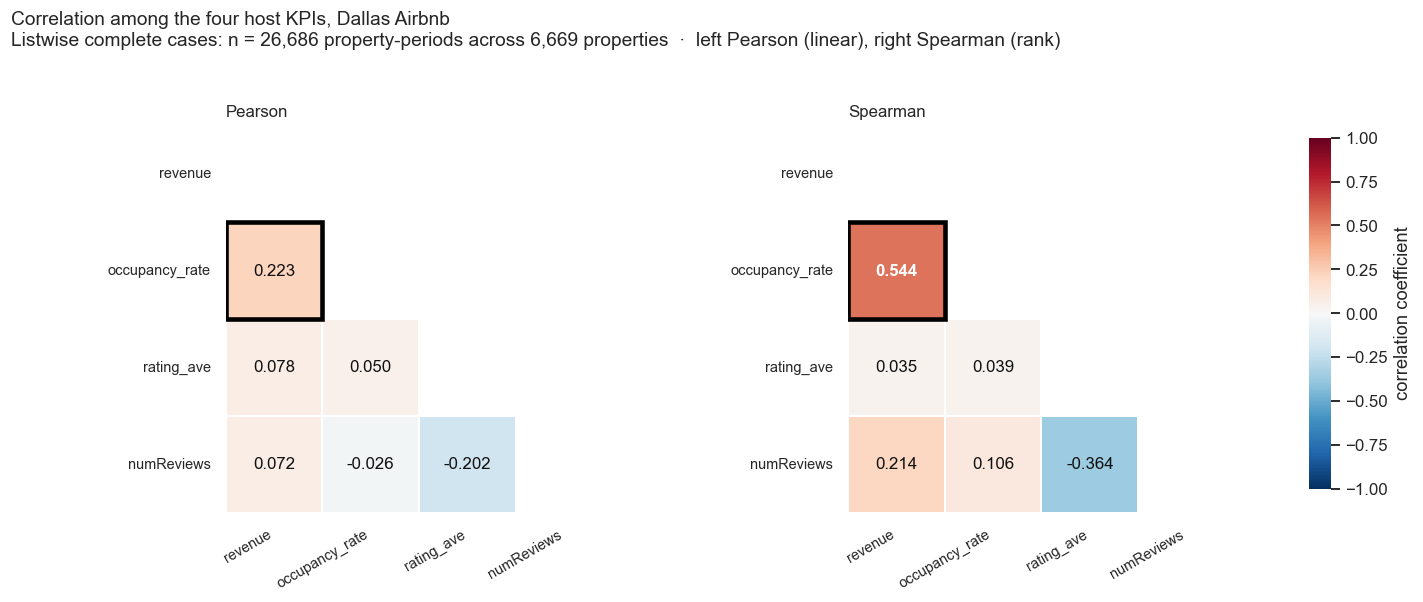

Greyscale note: a diverging colormap maps +0.4 and -0.4 to almost the same grey once this
notebook is printed, so THE PRINTED NUMBER, NOT THE COLOUR, CARRIES THE READING; the heavy
black outline marks revenue~occupancy_rate as the mechanically-linked pair in both panels.

Consistency check vs Question 9 (same 26,686-row frame)
  revenue ~ occupancy_rate       here r = +0.2229 / rho = +0.5436   Q9 reported +0.223 / +0.544   MATCH
  revenue ~ rating_ave_pastYear  here r = +0.0777 / rho = +0.0346   Q9 reported +0.078 / +0.035   MATCH
  revenue ~ numReviews_pastYear  here r = +0.0719 / rho = +0.2145   Q9 reported +0.072 / +0.215   MATCH
  -> Q9's forward reference holds; the two questions report the same numbers.
  (revenue~numReviews Spearman is 0.2145, which Q9 rounded up to 0.215 and the table above
   rounds down to 0.214. Same number, two rounding conventions.)

Superhost      n = 12,131 property-periods, 3,453 distinct properties
Non-Superhost  n = 14,555 property-periods, 5,298 dist

In [14]:
# Q11 asks for a correlation matrix over four KPIs. The first decision is not the chart,
# it is the sample: a 4x4 matrix can be built pairwise (each cell on its own complete
# rows) or listwise (one frame complete on all four). We use LISTWISE
COLS = ['revenue', 'occupancy_rate', 'rating_ave_pastYear', 'numReviews_pastYear']
q11 = df.dropna(subset=COLS)

null_tbl = pd.DataFrame({
    'nulls': df[COLS].isna().sum(),
    '% of rows': (100 * df[COLS].isna().mean()).round(1)})
print('Missingness on the four KPI columns (before any filtering)')
print(null_tbl.to_string())
print()
print('Row filtering, reported')
print('  Total rows                          : {:,}'.format(len(df)))
print('  Dropped - null on ANY of the four   : {:,} ({:.1%})'.format(
    len(df) - len(q11), 1 - len(q11) / len(df)))
print('  Rows retained (complete cases)      : {:,} ({:.1%})'.format(
    len(q11), len(q11) / len(df)))
print('  Distinct properties behind them     : {:,} of {:,}'.format(
    q11['Airbnb Property ID'].nunique(), df['Airbnb Property ID'].nunique()))
print('  WHY LISTWISE: every cell of the matrix is then computed on the same {:,} rows, so the six'.format(len(q11)))
print('  coefficients are directly comparable with each other - and it is the identical frame Q9 used.')
# Proof that the choice is not cosmetic: pairwise would move two cells and contradict Q9
pw = df[COLS].corr(method='spearman')
lw = q11[COLS].corr(method='spearman')
print('  Pairwise would shift revenue~numReviews Spearman {:.3f} -> {:.3f} and revenue~occupancy {:.3f} -> {:.3f},'.format(
    lw.loc['revenue', 'numReviews_pastYear'], pw.loc['revenue', 'numReviews_pastYear'],
    lw.loc['revenue', 'occupancy_rate'], pw.loc['revenue', 'occupancy_rate']))
print('  contradicting Q9 inside the same PDF. Listwise keeps the document internally consistent.')
print()

# --- The two matrices -----------------------------------------------------------------
# Pearson measures LINEAR association and is pulled by the extreme listings Q6 documented.
# Spearman measures MONOTONE association on ranks and reads the typical listing. Both are
# printed because the gap between them is itself a finding
pear_m = q11[COLS].corr(method='pearson').round(3)
spear_m = q11[COLS].corr(method='spearman').round(3)
print('Pearson correlation matrix (linear), n = {:,}'.format(len(q11)))
display(pear_m)
print('Spearman correlation matrix (rank), n = {:,}'.format(len(q11)))
display(spear_m)
print()

# --- Long-format ranking of the six unique pairs ---------------------------------------
# A 4x4 matrix has 16 cells but only 6 unique off-diagonal pairs; ranking them is what
# actually answers "which variables show the strongest correlations"
MECHANICAL = {('revenue', 'occupancy_rate')}
rows = []
for i, a in enumerate(COLS):
    for b in COLS[i + 1:]:
        rows.append({
            'pair': '{} ~ {}'.format(a, b),
            'pearson_r': round(q11[a].corr(q11[b], method='pearson'), 3),
            'spearman_rho': round(q11[a].corr(q11[b], method='spearman'), 3),
            'mechanical?': 'Y' if (a, b) in MECHANICAL or (b, a) in MECHANICAL else 'N'})
pairs = pd.DataFrame(rows)
pairs['gap (rho - r)'] = (pairs['spearman_rho'] - pairs['pearson_r']).round(3)
pairs = (pairs[['pair', 'pearson_r', 'spearman_rho', 'gap (rho - r)', 'mechanical?']]
         .reindex(pairs['spearman_rho'].abs().sort_values(ascending=False).index)
         .reset_index(drop=True))
print('The six unique pairs, ranked by |Spearman rho|')
print(pairs.to_string(index=False))
print('  "mechanical? = Y" means the two variables are linked by arithmetic, not by behaviour:')
print('  revenue ~= nights booked x nightly price, and occupancy_rate is nights booked scaled by')
print('  available days. That cell is reported and then set aside; it is not a finding.')
print()

# --- Figure: two heatmaps, one shared colourbar ----------------------------------------
# Lecture 3 maps "strength of association across many variable pairs" to a heatmap.
# Upper triangle AND diagonal are masked: the diagonal is 1.0 by construction and the
# upper triangle repeats the lower, so masking leaves exactly the six unique pairs.
mask = np.triu(np.ones_like(pear_m, dtype=bool))
SHORT = {'revenue': 'revenue', 'occupancy_rate': 'occupancy_rate',
         'rating_ave_pastYear': 'rating_ave', 'numReviews_pastYear': 'numReviews'}
ticks = [SHORT[c] for c in COLS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.58])
for ax, mat, name in [(axes[0], pear_m, 'Pearson'), (axes[1], spear_m, 'Spearman')]:
    sns.heatmap(mat, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
                linewidths=1.2, linecolor='white', annot=False, ax=ax,
                cbar=(name == 'Pearson'), cbar_ax=cbar_ax if name == 'Pearson' else None,
                cbar_kws={'label': 'correlation coefficient'})
    # Annotate by hand rather than with annot=True: we need the text colour switched at
    # |r| > 0.5, where the dark end of the diverging ramp swallows black text
    for r in range(len(COLS)):
        for c in range(len(COLS)):
            if mask[r, c]:
                continue
            v = mat.iloc[r, c]
            ax.text(c + 0.5, r + 0.5, '{:.3f}'.format(v), ha='center', va='center',
                    fontsize=11, color='white' if abs(v) > 0.5 else '#111111',
                    fontweight='bold' if abs(v) > 0.5 else 'normal')
    # The one mechanically-linked pair, outlined so it is not read as a behavioural finding
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='#000000',
                               linewidth=3.0, zorder=6))
    ax.grid(False)            # the whitegrid theme otherwise rules lines across masked cells
    ax.set_xticklabels(ticks, rotation=30, ha='right', fontsize=9.5)
    ax.set_yticklabels(ticks, rotation=0, fontsize=9.5)
    ax.set_title(name, loc='left', fontsize=11)
fig.suptitle('Correlation among the four host KPIs, Dallas Airbnb\n'
             'Listwise complete cases: n = {:,} property-periods across {:,} properties  '
             '·  left Pearson (linear), right Spearman (rank)'.format(
                 len(q11), q11['Airbnb Property ID'].nunique()),
             x=0.012, ha='left', fontsize=12.5, y=0.99)
fig.subplots_adjust(left=0.13, right=0.90, top=0.80, bottom=0.16, wspace=0.30)
plt.show()
print('Greyscale note: a diverging colormap maps +0.4 and -0.4 to almost the same grey once this')
print('notebook is printed, so THE PRINTED NUMBER, NOT THE COLOUR, CARRIES THE READING; the heavy')
print('black outline marks revenue~occupancy_rate as the mechanically-linked pair in both panels.')
print()

# --- Consistency check against Question 9 ----------------------------------------------
# Q9 ran the same frame and made a forward reference to this question. If the two disagree,
# the PDF contradicts itself, so the check is printed rather than assumed
print('Consistency check vs Question 9 (same {:,}-row frame)'.format(len(q11)))
q9_reported = {'occupancy_rate': (0.223, 0.544), 'rating_ave_pastYear': (0.078, 0.035),
               'numReviews_pastYear': (0.072, 0.215)}
ok = True
for col, (p_ref, s_ref) in q9_reported.items():
    p_here = q11['revenue'].corr(q11[col], method='pearson')
    s_here = q11['revenue'].corr(q11[col], method='spearman')
    # "agrees" = the raw coefficient rounds to the value Q9 printed, +/- half a unit in
    # the 3rd decimal. 0.2145 is the boundary case: Q9 rounded it up, the table above down
    match = (abs(p_here - p_ref) < 0.0006) and (abs(s_here - s_ref) < 0.0006)
    ok = ok and match
    print('  revenue ~ {:<20} here r = {:+.4f} / rho = {:+.4f}   Q9 reported {:+.3f} / {:+.3f}   {}'.format(
        col, p_here, s_here, p_ref, s_ref, 'MATCH' if match else 'DISAGREES'))
print('  ->', 'Q9\'s forward reference holds; the two questions report the same numbers.' if ok
      else 'DISCREPANCY - do not write the prose until this is resolved.')
print('  (revenue~numReviews Spearman is 0.2145, which Q9 rounded up to 0.215 and the table above')
print('   rounds down to 0.214. Same number, two rounding conventions.)')
print()

# --- Robustness: does the pooled matrix hide a subgroup reversal? -----------------------
# Q9 found the Superhost subgroup is range-restricted (the badge requires a high rating),
# which attenuates correlations. We check whether that changes any SIGN
split = {}
for lab, flag in [('Superhost', 1), ('Non-Superhost', 0)]:
    sub = q11[q11['Superhost'] == flag]
    split[lab] = (sub, sub[COLS].corr('pearson'), sub[COLS].corr('spearman'))
    print('{:<14} n = {:,} property-periods, {:,} distinct properties'.format(
        lab, len(sub), sub['Airbnb Property ID'].nunique()))
rob = []
for lbl in pairs['pair']:                       # same order as the ranking table above
    a, b = lbl.split(' ~ ')
    sh_p, sh_s = split['Superhost'][1].loc[a, b], split['Superhost'][2].loc[a, b]
    ns_p, ns_s = split['Non-Superhost'][1].loc[a, b], split['Non-Superhost'][2].loc[a, b]
    rob.append({'pair': lbl,
                'SH r': round(sh_p, 3), 'nonSH r': round(ns_p, 3),
                'SH rho': round(sh_s, 3), 'nonSH rho': round(ns_s, 3),
                'signs agree?': 'yes' if (np.sign(round(sh_p, 3)) == np.sign(round(ns_p, 3))
                                          and np.sign(round(sh_s, 3)) == np.sign(round(ns_s, 3)))
                                else 'NO'})
rob = pd.DataFrame(rob)
print()
print('Robustness - the same six pairs computed inside each Superhost group')
print(rob.to_string(index=False))
print('  Sign agreement is computed, not assumed. Where it says NO, check the magnitude before')
print('  reading anything into it: a flip between -0.03 and +0.00 is a flip between two zeros.')
print()

# --- Block A: which lever pays ----------------------------------------------------------
# Revenue = nights x price, so the two levers a host controls are occupancy and rate.
# Logs because Q6 showed all three are right-skewed; logs also make the coefficients
# read as elasticities rather than dollar slopes
LEVERS = ['revenue', 'occupancy_rate', 'booked_days_avePrice']
pos = q11[(q11[LEVERS] > 0).all(axis=1)]
print('BLOCK A - which lever pays')
print('  Rows with all three levers strictly positive (needed for logs): {:,} of {:,} '
      '({:,} skipped)'.format(len(pos), len(q11), len(q11) - len(pos)))
logs = np.log(pos[LEVERS]).rename(columns={
    'revenue': 'log revenue', 'occupancy_rate': 'log occupancy',
    'booked_days_avePrice': 'log price'})
log_c = logs.corr('pearson').round(3)
print(log_c.to_string())
print('  log revenue ~ log occupancy : {:+.3f}'.format(log_c.iloc[0, 1]))
print('  log revenue ~ log price     : {:+.3f}'.format(log_c.iloc[0, 2]))
print('  log price   ~ log occupancy : {:+.3f}  <- near zero'.format(log_c.iloc[1, 2]))
print('  -> The two levers contribute NEARLY EQUALLY to revenue and are ALMOST UNCORRELATED with')
print('     each other in this market. A Dallas host does not have to discount to fill the calendar.')
print()

# --- Block B: where the occupancy lever runs out ----------------------------------------
# Quintiles built with labels=False -> plain integers, then relabelled, so nothing depends
# on groupby's category sort
QLAB = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
occ_q = pd.qcut(q11['occupancy_rate'], 5, labels=False, duplicates='drop')
rev_q = pd.qcut(q11['numReviews_pastYear'], 5, labels=False, duplicates='drop')
# One concat, not repeated inserts - repeated inserts fragment the frame and print a warning
q11x = pd.concat([q11, pd.DataFrame({
    'occ_quintile': pd.Series(occ_q, index=q11.index).map(dict(enumerate(QLAB))),
    'rev_quintile': pd.Series(rev_q, index=q11.index).map(dict(enumerate(QLAB)))},
    index=q11.index)], axis=1)

print('BLOCK B - where the occupancy lever runs out')
occ_tbl = (q11x.groupby('occ_quintile')
           .agg(n=('revenue', 'size'),
                occ_min=('occupancy_rate', 'min'), occ_max=('occupancy_rate', 'max'),
                median_revenue=('revenue', 'median'), mean_revenue=('revenue', 'mean'),
                median_nightly_price=('booked_days_avePrice', 'median'))
           .reindex(QLAB).round(2))
print(occ_tbl.to_string())
step = occ_tbl['median_revenue'].diff()
print('  Median revenue steps between quintiles: {}'.format(
    ', '.join('{:+,.0f}'.format(v) for v in step[1:])))
print('  -> Revenue rises steeply through the 4th quintile and then PLATEAUS AND DIPS in the 5th.')
print()

# Is the 5th-quintile dip just a different mix of listings? Two checks say no.
print('  Check B1 - listing-type mix by occupancy quintile (row %, guards the composition story)')
TYPES = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
mix = (pd.crosstab(q11x['occ_quintile'], q11x['Listing Type'], normalize='index') * 100
       ).reindex(QLAB).reindex(columns=TYPES).round(1)
print(mix.to_string())
print('    -> Nearly flat, and it moves the WRONG WAY for a composition explanation: Entire home/apt')
print('       rises from {:.1f}% in Q1 to {:.1f}% in Q5, so the top-occupancy quintile is MORE'.format(
    mix.loc['Q1 (lowest)', 'Entire home/apt'], mix.loc['Q5 (highest)', 'Entire home/apt']))
print('       entire-home, which would push revenue UP, not down.')
print()
print('  Check B2 - the same table within Entire home/apt only')
eh_tbl = (q11x[q11x['Listing Type'] == 'Entire home/apt'].groupby('occ_quintile')
          .agg(n=('revenue', 'size'), median_revenue=('revenue', 'median'),
               mean_revenue=('revenue', 'mean'),
               median_nightly_price=('booked_days_avePrice', 'median'))
          .reindex(QLAB).round(2))
print(eh_tbl.to_string())
print('    -> The plateau SURVIVES holding listing type constant: median revenue {:,.0f} -> {:,.0f}'.format(
    eh_tbl.loc['Q4', 'median_revenue'], eh_tbl.loc['Q5 (highest)', 'median_revenue']))
print('       from Q4 to Q5, still dipping.')
print()
print('  Check B3 - realised nightly price by occupancy quintile (the clincher)')
price_cmp = pd.DataFrame({'All listings': occ_tbl['median_nightly_price'],
                          'Entire home/apt only': eh_tbl['median_nightly_price']}).reindex(QLAB)
print(price_cmp.to_string())
print('    -> Median booked_days_avePrice FALLS as occupancy rises ({:,.2f} -> {:,.2f} pooled, '
      '{:,.2f} -> {:,.2f}'.format(price_cmp.iloc[0, 0], price_cmp.iloc[-1, 0],
                                  price_cmp.iloc[0, 1], price_cmp.iloc[-1, 1]))
print('       within entire homes). The highest-occupancy hosts are charging measurably less per')
print('       night. That is what underpricing looks like - stated as an association, not proof.')
print()

# Review COUNT vs review RATING as revenue-side metrics
print('Review volume vs review score, as revenue metrics')
rq_tbl = (q11x.groupby('rev_quintile')
          .agg(n=('revenue', 'size'), median_numReviews=('numReviews_pastYear', 'median'),
               median_rating=('rating_ave_pastYear', 'median'),
               median_revenue=('revenue', 'median'))
          .reindex(QLAB).round(3))
print(rq_tbl.to_string())
print('  -> Median rating falls MONOTONICALLY as review volume rises ({:.2f} at a median of {:,.0f}'.format(
    rq_tbl.loc['Q1 (lowest)', 'median_rating'], rq_tbl.loc['Q1 (lowest)', 'median_numReviews']))
print('     reviews down to {:.2f} at {:,.0f}), while median revenue RISES from ${:,.0f} to ${:,.0f}.'.format(
    rq_tbl.loc['Q5 (highest)', 'median_rating'], rq_tbl.loc['Q5 (highest)', 'median_numReviews'],
    rq_tbl.loc['Q1 (lowest)', 'median_revenue'], rq_tbl.loc['Q5 (highest)', 'median_revenue']))
print('     A perfect score is a THIN-EVIDENCE score, not a quality signal.')
print()

# Why Spearman is the coefficient to read here: the skew that breaks Pearson
print('Why Spearman is the coefficient to interpret (the skew Pearson cannot survive)')
skew_tbl = pd.DataFrame({
    'median': q11[COLS].median(), 'mean': q11[COLS].mean(),
    'max': q11[COLS].max(), 'skewness': q11[COLS].skew()}).round(2)
print(skew_tbl.to_string())
print('  numReviews_pastYear: median {:,.0f}, mean {:,.0f}, max {:,.0f}. Pearson is dominated by a'.format(
    q11['numReviews_pastYear'].median(), q11['numReviews_pastYear'].mean(),
    q11['numReviews_pastYear'].max()))
print('  handful of extreme listings; Spearman reads the typical one. Q6 measured the same skew on')
print('  revenue (skewness 4.83 non-Superhost / 7.24 Superhost).')
print('  Ordering of the three revenue drivers is NOT the same under the two coefficients:')
print('    Spearman: occupancy {:+.3f} >> reviews {:+.3f} >> rating {:+.3f}'.format(
    spear_m.loc['revenue', 'occupancy_rate'], spear_m.loc['revenue', 'numReviews_pastYear'],
    spear_m.loc['revenue', 'rating_ave_pastYear']))
print('    Pearson : occupancy {:+.3f} >> rating {:+.3f} ~ reviews {:+.3f}'.format(
    pear_m.loc['revenue', 'occupancy_rate'], pear_m.loc['revenue', 'rating_ave_pastYear'],
    pear_m.loc['revenue', 'numReviews_pastYear']))

### Findings — Question 11

**The strongest cell in the matrix is not a finding.** `revenue`~`occupancy_rate` is the
largest coefficient in both panels (Spearman rho = +0.544, Pearson *r* = +0.223) and it is
**arithmetic**: revenue is nights booked x nightly price, and `occupancy_rate` is nights booked
scaled by available days, so the two share a term by construction. It is reported, outlined in
the figure, and then set aside. It cannot be the headline.

**The strongest genuine relationship is negative: `rating_ave_pastYear`~`numReviews_pastYear`
at rho = -0.364** (*r* = -0.202). More reviews go with a *lower* average score, and Q9 already
showed the mechanism. Splitting the 26,686 rows into review-count quintiles, median rating falls
monotonically at every step: **5.000** at a median of 5 reviews, **4.875** at 20, **4.854** at
48, **4.806** at 143, **4.745** at 623. A perfect score is a **thin-evidence** score — too few
reviews for any of them to be below 5 — not a quality signal. This is the single most useful
cell in the matrix for a host, because it says the two review-side metrics point in opposite
directions and cannot both be maximised.

**The Pearson/Spearman gap is large and directional, and Spearman is the coefficient to read
here.** `revenue`~`numReviews_pastYear` moves from *r* = +0.072 to rho = +0.214, and
`occupancy_rate`~`numReviews_pastYear` **flips sign**, from *r* = -0.026 to rho = +0.106. The
cause is the skew Q6 established (revenue skewness 4.83 non-Superhost / 7.24 Superhost; 7.15
pooled on this frame) plus the review-count skew (median 48, mean 245, max 3,305): Pearson is
pulled by a few extreme listings, Spearman reads the typical one. The consequence is that the
ranking of the three revenue drivers **is not the same under the two coefficients** — on
Spearman it is occupancy (+0.544) >> reviews (+0.214) >> rating (+0.035), but on Pearson it is
occupancy (+0.223) >> rating (+0.078) ~ reviews (+0.072). Anyone quoting "the correlation" from
one matrix would rank review volume and review score differently depending on which they picked.

**Consistency with Question 9.** All three `revenue` correlations reproduce Q9 exactly on the
same frame: occupancy +0.2229 / +0.5436, rating +0.0777 / +0.0346, reviews +0.0719 / +0.2145.
Q9's forward reference holds. (Q9 rounded the review figure up to 0.215 and the ranking table
here rounds it down to 0.214; it is the same number.)

**Robustness by Superhost status.** Recomputed inside each group — Superhost n = 12,131 across
3,453 properties, non-Superhost n = 14,555 across 5,298 — the relationships are **attenuated
inside the Superhost group** exactly as the range restriction Q9 documented predicts:
`revenue`~`occupancy_rate` 0.187 vs 0.274 Pearson, `revenue`~`numReviews_pastYear` 0.047 vs
0.132 — while `rating_ave_pastYear`~`numReviews_pastYear` **strengthens** to -0.310 vs -0.140.
Three of the six pairs do not preserve sign across the split, but all three are the near-zero
cells: `occupancy_rate`~`numReviews_pastYear` (+0.004 vs -0.032 Pearson),
`occupancy_rate`~`rating_ave_pastYear` (-0.022 vs +0.059) and `revenue`~`rating_ave_pastYear`
(-0.011 vs +0.030 Spearman). A flip between -0.03 and +0.00 is a flip between two zeros; every
pair large enough to act on keeps its sign, so the pooled matrix is not hiding a reversal.

**Which lever pays (Block A).** On the same 26,686 rows, in logs, `revenue`~`occupancy_rate`
is +0.612 and `revenue`~`booked_days_avePrice` is +0.542 — the two levers a host controls
contribute **nearly equally** — and they are **almost uncorrelated with each other**
(-0.056). In this market a host does not have to discount to fill the calendar; price and
occupancy are close to independent decisions.

**Where the occupancy lever runs out (Block B).** Median revenue by occupancy quintile is
$456 / $1,495 / $2,464 / $3,290 / $3,180 — steps of +$1,039, +$968, +$826, then **-$110**.
Revenue rises steeply through the 4th quintile and then plateaus and dips in the 5th. Two checks
say this is not a composition artefact. The listing-type mix across quintiles is nearly flat and
moves the *wrong* way for that story — Entire home/apt rises from 68.0% in Q1 to 79.2% in Q5, so
the top-occupancy quintile is *more* entire-home, which would push revenue up rather than down —
and within Entire home/apt alone (n ~ 4,000 per quintile) the plateau survives: $652 / $1,827 /
$2,920 / **$3,816 / $3,731**. The clincher is realised price: median `booked_days_avePrice`
*falls* as occupancy rises, $95.00 / $97.14 / $94.74 / $90.09 / $90.09 pooled and $120.00 /
$113.83 / $108.39 / $101.37 / $102.68 within entire homes. The highest-occupancy hosts are
charging measurably less per night, which is what underpricing looks like — stated as an
association in cross-section, not as proof of causation.

**What a host should actually do.** First, chase occupancy only up to the plateau: below roughly
30% occupancy (the top of the 4th quintile) every extra point of occupancy is worth real money,
but above it median revenue stops rising, and the price table says those hosts are already
selling nights $30 cheaper than the least-occupied entire homes — the next dollar comes from
raising the rate, not from filling more nights. Second, do **not** buy review volume expecting a
rating lift: the two run in opposite directions (rho = -0.364), and a 5.00 average on 5 reviews
is not evidence of quality. Third, treat review *count*, not average rating, as the review-side
metric worth growing — it tracks revenue (rho = +0.214; median revenue $1,341 in the lowest
review quintile against $2,773 in the highest) while average rating essentially does not
(rho = +0.035) — so accepting the small rating cost that comes with volume is the right trade.
Fourth, since price and occupancy are near-independent here (-0.056), test a rate increase
before assuming it will cost bookings.

**Limitations.** Nothing here is causal. These are cross-sectional associations measured on
panel data, and the largest cell in the matrix, `revenue`~`occupancy_rate`, is *definitionally*
linked rather than behaviourally. The panel structure also inflates statistical significance:
6,669 properties supply 26,686 rows, so the observations are not independent and any p-value
would be badly overstated — consistent with the caution urged in Q5 and Q9, we report effect sizes and print no
p-values. And the retained frame is selected: the 22,025 dropped rows are largely the
listed-but-unbooked and off-market periods identified in Q2/Q3, so this matrix describes
listings that **actually booked and were reviewed**, not the Dallas market as a whole. The
occupancy-plateau reading in particular is an association across self-selected hosts — hosts who
run at high occupancy may differ from the rest in ways (location, property quality, professional
management) this data does not control for.

**What this means for the business.** This is **descriptive / diagnostic** analysis: a
correlation matrix maps the strength of association between candidate drivers and is the
feature-selection step that comes *before* any predictive model — it tells us `occupancy_rate`
and `numReviews_pastYear` are worth carrying into a revenue model and `rating_ave_pastYear` is
not. Two levers follow. The occupancy plateau is a **value-capture (pricing / unit economics)**
finding: past roughly 30% occupancy the marginal night stops adding revenue and the realised
nightly rate is falling, so the yield conversation for high-occupancy hosts should be about
rate, not volume — and because occupancy and price are near-uncorrelated in this market, that
rate increase is not obviously bought with empty nights. The review finding is **value creation
via customer intimacy**: review volume is the customer-feedback asset that moves with revenue,
average rating is a hygiene factor that does not, so host coaching and platform prompts should
be aimed at getting *more* guests to review rather than at protecting a 5.00 score that mostly
signals a thin book of evidence.

---
# Question 12 — Neighbourhood revenue and occupancy for Superhosts

> Which neighborhoods show the highest revenue and occupancy rates for Superhosts? Determine the
> best way to visualize and analyze this information.

**The sample decision comes before the chart, twice.** First, which rows: `occupancy_rate` only
exists on property-periods that actually booked, so a ranking on *both* measures has to rest on
one frame complete on both — the same listwise logic Q11 used. That takes 15,920 Superhost rows
to 15,067 after dropping the 853 with no `Neighborhood`, then to 12,228. The cell prints every
step. What survives is **Superhost property-periods that booked**, not all Superhost inventory,
and step 8 of the cell re-runs the whole ranking on the on-market frame with idle periods counted
as $0 to show how much that choice matters.

Second, how small a neighbourhood can be before its median is noise. **The threshold is set in
distinct properties, not rows** — at least 20 — because this is a panel: one listing appears in
up to eight evaluation periods, so a row-count threshold counts the same property observed eight
times as eight independent listings. Old Lake Highlands has 88 rows from 13 properties. A
conventional "fewer than 30 rows" filter would have dropped 2 of the 17 named neighbourhoods,
which is not a filter; the property threshold keeps 11 and drops 6, and both lists are printed
with their counts.

**Median, not mean, is the headline.** Q6 measured Superhost revenue skewness at 7.24, and the
consequence here is concrete: on the mean, Lake Highlands is the top neighbourhood in Dallas at
$6,088 — but the top 5 of its 78 Superhost properties supply 66.6% of its Superhost revenue, and
its median is $1,948. The cell prints that sensitivity check next to the table rather than
asking the reader to take the choice on trust.

**Chart choice and why:** 11 comparable categories and a *comparison* task, which Lecture 3 maps
to a bar chart. Horizontal bars because the neighbourhood names are long. The two panels share
one y-axis and **Panel B is deliberately not re-sorted** — it carries Panel A's revenue order, so
whether the same places top both measures is legible at a glance instead of requiring the reader
to trace names between two different orderings. Rejected explicitly: a **choropleth map**, because
these 17 units are coarse and wildly unequal (Central Dallas alone is 50.6% of the analysable
Superhost rows), so the map would encode land area rather than performance, it needs external
tiles or shapefiles that break the Colab → PDF export, and Q15 already owns the geographic view;
and a **twin-axis grouped bar** mixing dollars against a rate, where two bar heights in different
units invite a comparison that means nothing.

A second figure follows the ranking, because the ranking alone does not tell a manager where to
act. It plots each neighbourhood's median occupancy against its median realised nightly rate,
with the city-wide Superhost medians as quadrant lines — the positioning view that feeds Q15 and
Q16.

Row filtering, reported at every step
  Superhost rows (Superhost == 1)        : 15,920
  - null Neighborhood                    : 853 removed  -> 15,067 rows
  - null revenue OR occupancy_rate       : 2,839 removed  -> 12,228 rows
  Distinct Superhost properties retained : 3,477
  Named neighbourhoods in the frame      : 17
  WHY LISTWISE on the two KPIs: occupancy_rate only exists where the property booked, so a
  ranking on BOTH measures has to rest on the same rows - the identical logic Q11 used.

WHAT `sh` MEANS: 12,228 Superhost property-periods that ACTUALLY BOOKED, not all Superhost
inventory. The on-market-but-unbooked and off-market Superhost periods identified in the
setup cell are excluded here; step 8 below re-runs the ranking with them counted as $0.

Minimum-sample filter: at least 20 DISTINCT Superhost properties per neighbourhood
  KEPT (11 of 17 named neighbourhoods)
    Central Dallas                                                       1,899 properties  6,192 rows


,properties,rows,median_revenue,mean_revenue,median_occupancy,mean_occupancy,median_booked_days,median_realised_rate,entire_home_share
Neighborhood,,,,,,,,,
Central Dallas,1899,6192,2693.0,3724.0,0.1789,0.2161,26.0,101.47,0.819
Oak Lawn,338,1189,2400.0,3816.0,0.1824,0.2160,27.0,92.00,0.796
Lakewood,22,103,2375.0,3308.0,0.2214,0.2364,28.0,75.68,0.864
White Rock East,22,80,2222.0,2902.0,0.1667,0.1936,27.0,81.04,0.712
Northwest Dallas,184,623,2005.0,3104.0,0.1858,0.2107,29.0,79.11,0.581
Lake Highlands,78,283,1948.0,6088.0,0.1475,0.1920,23.0,72.44,0.650
Southwest Dallas,453,2012,1838.0,2870.0,0.1707,0.1996,28.0,72.41,0.647
South Central Dallas,49,172,1551.0,2429.0,0.1382,0.1665,23.0,56.26,0.517
Forest Hills/Casa Linda,31,117,1519.0,2646.0,0.1771,0.2125,20.0,82.82,0.667


MEDIAN IS THE HEADLINE STATISTIC HERE, and the mean is printed only to show why it is not.
  Lake Highlands : mean $6,088  |  5%-trimmed mean $4,113  |  median $1,948
    The top 5 of its 78 Superhost properties account for 66.6% of its Superhost revenue,
    so the mean ranks Lake Highlands 1st on revenue on the strength of five luxury homes.
  Central Dallas : mean $3,724  |  median $2,693  - a far smaller gap, because its
    1,899 properties are not carried by a handful of outliers.
  Q6 measured this skew directly (revenue skewness 7.24 for Superhosts). The median is the
  statistic that describes the TYPICAL Superhost listing in a neighbourhood; the mean does not.



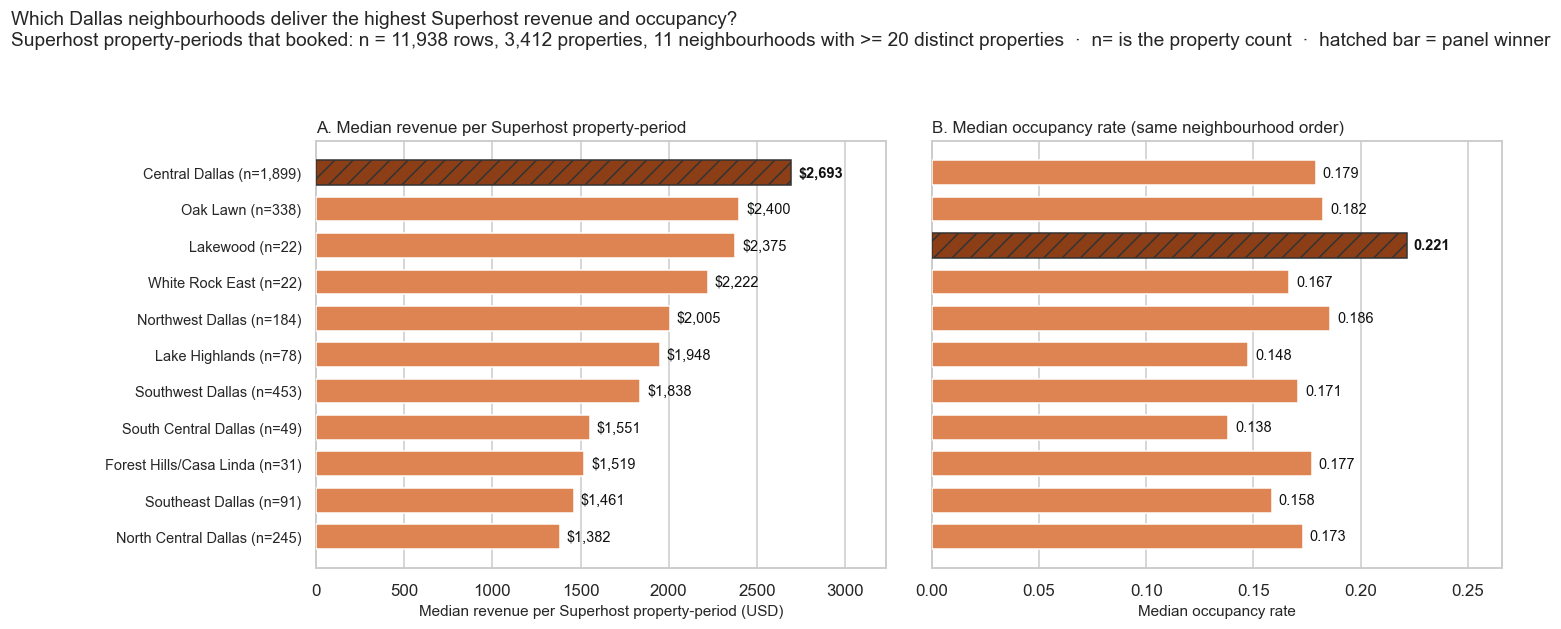

PANEL B IS DELIBERATELY NOT RE-SORTED. It carries Panel A's neighbourhood order, because the
question is whether the SAME places top both measures - and that is only readable at a glance
if the category order is held fixed. A re-sorted second panel forces the reader to trace names.
Chart choice: 11 categories, a comparison task -> Lecture 3 says bar. Rejected alternatives:
  - A CHOROPLETH MAP. These 17 units are coarse and wildly unequal - Central Dallas alone is
    50.6% of the analysable Superhost rows - so a map would encode land area, not performance,
    it needs external tiles or shapefiles that break the Colab -> PDF export, and Q15 already
    owns the geographic view.
  - A TWIN-AXIS GROUPED BAR mixing dollars and a rate. Two bars of different units side by side
    invite a comparison of their heights that means nothing.

DO THE SAME NEIGHBOURHOODS TOP BOTH? Spearman rho(median_revenue, median_occupancy) = +0.518, p = 0.102, n = 11 neighbourhoods
  Q11 measured rho = +0.544

,all_types_rank,all_types_median,entire_home_rank,entire_home_median,entire_home_props,entire_home_share,rank_shift
Neighborhood,,,,,,,
Central Dallas,1,2693.0,2,3076.0,1627,0.82,-1
Oak Lawn,2,2400.0,4,2914.0,278,0.80,-2
Lakewood,3,2375.0,8,2513.0,20,0.86,-5
White Rock East,4,2221.5,7,2550.0,14,0.71,-3
Northwest Dallas,5,2005.0,1,3332.5,120,0.58,4
Lake Highlands,6,1948.0,3,2941.5,53,0.65,3
Southwest Dallas,7,1837.5,5,2775.0,277,0.65,2
South Central Dallas,8,1551.0,9,2409.0,25,0.52,-1
Forest Hills/Casa Linda,9,1519.0,11,2052.0,21,0.67,-2


  Neighbourhoods moving 3 or more places once listing type is held constant: 5 of 11
    Lakewood                  3 ->  8  (-5 places, entire-home share 86%)
    White Rock East           4 ->  7  (-3 places, entire-home share 71%)
    Northwest Dallas          5 ->  1  (+4 places, entire-home share 58%)
    Lake Highlands            6 ->  3  (+3 places, entire-home share 65%)
    Southeast Dallas         10 ->  6  (+4 places, entire-home share 44%)
  CONCLUSION: the all-types neighbourhood revenue ranking is substantially a LISTING-TYPE MIX
  ranking. Northwest Dallas is 5th overall but 1st among entire homes only, because only 58%
  of its Superhost rows are entire homes; Lakewood is 3rd overall but 8th among entire homes,
  because 86% of its rows are. The within-entire-home ranking is the one that answers
  "which PLACE earns more"; the all-types ranking answers "where is the high-value inventory".

FRAME SENSITIVITY - the same ranking rebuilt on the on-market frame (13,902 rows),

,booked_only_rank,booked_only_median,on_market_median_z,on_market_rank,on_market_rows,rank_shift
Neighborhood,,,,,,
Central Dallas,1,2693.0,2252.0,1,7166,0
Oak Lawn,2,2400.0,2017.0,3,1398,-1
Lakewood,3,2375.0,2139.0,2,119,1
White Rock East,4,2221.5,1250.0,8,100,-4
Northwest Dallas,5,2005.0,1558.0,5,722,0
Lake Highlands,6,1948.0,1328.0,7,356,-1
Southwest Dallas,7,1837.5,1620.0,4,2211,3
South Central Dallas,8,1551.0,1378.0,6,195,2
Forest Hills/Casa Linda,9,1519.0,1088.0,10,143,-1


  Spearman between the two rankings: +0.845 (p = 0.0010).
  THE WRITTEN ANSWER USES THE BOOKED-ONLY FRAME, because occupancy_rate does not exist on the
  unbooked rows and both measures must rest on the same sample. But the ranking is NOT fully
  robust to counting idle periods as $0: the neighbourhoods that move are the ones carrying
  more unbooked inventory - White Rock East (-4), Southwest Dallas (+3), South Central Dallas (+2) - and the top of the table is unchanged (Central Dallas 1st on both).

POSITIONING - occupancy against realised nightly rate
  City-wide Superhost medians (all 12,228 booked Superhost rows): occupancy 0.1754, realised rate $90.02
  Spearman rho(median_occupancy, median_realised_rate) across the 11 neighbourhoods = +0.600, p = 0.051
  NOTE THE SIGN. Across listings, Q11 found realised price FALLS as occupancy rises. Across
  neighbourhoods the relationship REVERSES: busier districts are generally the pricier ones.
  So there is no neighbourhood-level plateau 

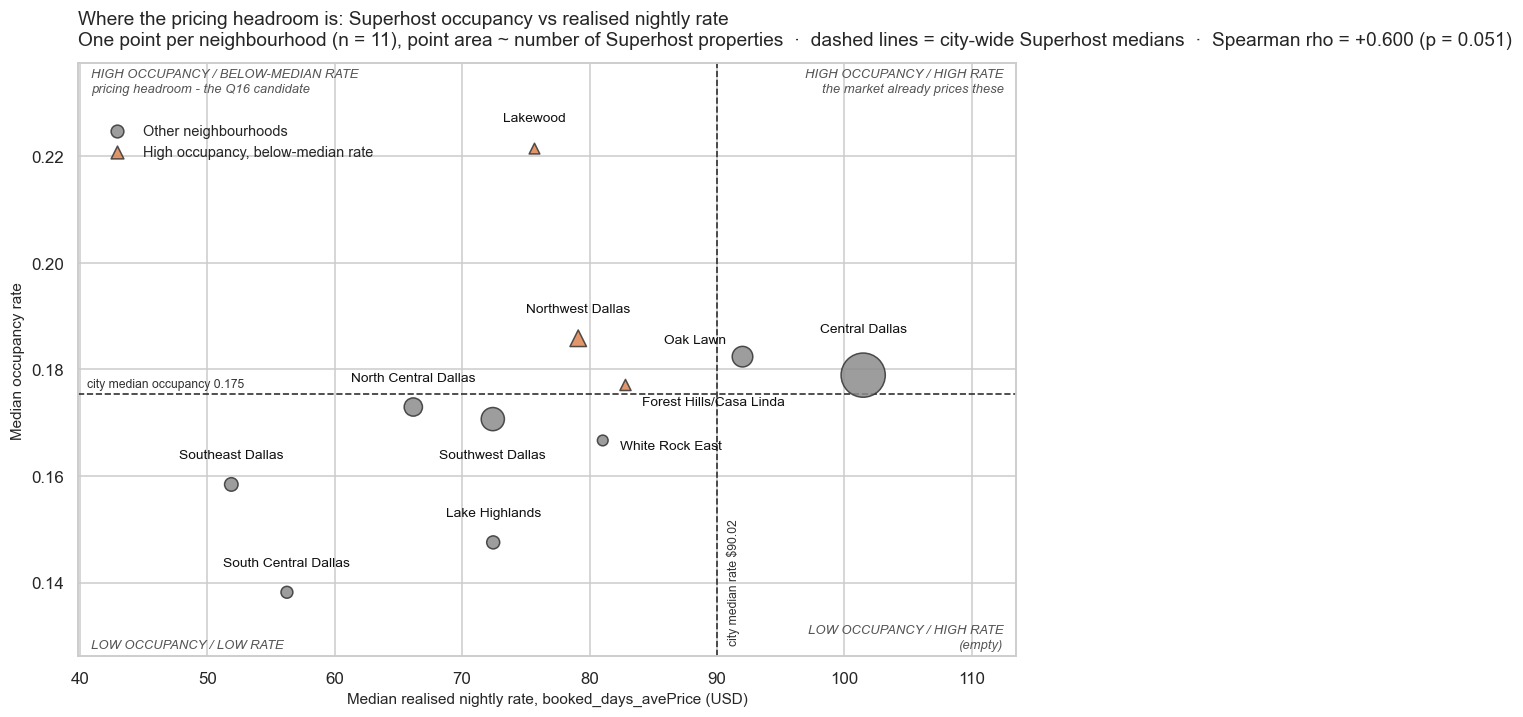

Reading the target quadrant: Lakewood runs 26% above the city median occupancy (0.221 vs 0.175)
while realising $75.68 a night against a $90.02 city median - 16% below. Northwest Dallas
and Forest Hills/Casa Linda sit in the same quadrant. Those three are the neighbourhood-level
candidates for the pricing gap Q11 found WITHIN properties. Central Dallas and Oak Lawn are busy
AND expensive - the market has already priced them, and there is no gap to close there.


In [15]:
# Q12 asks two ranking questions at once - highest revenue AND highest occupancy - for
# Superhosts only. Three decisions come before any chart: which rows the ranking rests on,
# how small a neighbourhood has to be before its median is noise, and whether the ranking
# is measuring the PLACE or just the kind of property that happens to sit there.

# --- Step 1: build the analysis frame, reporting every filter ---------------------------
sh_all = df[df['Superhost'] == 1]
sh_named = sh_all.dropna(subset=['Neighborhood'])
sh = sh_named.dropna(subset=['revenue', 'occupancy_rate'])

print('Row filtering, reported at every step')
print('  Superhost rows (Superhost == 1)        : {:,}'.format(len(sh_all)))
print('  - null Neighborhood                    : {:,} removed  -> {:,} rows'.format(
    len(sh_all) - len(sh_named), len(sh_named)))
print('  - null revenue OR occupancy_rate       : {:,} removed  -> {:,} rows'.format(
    len(sh_named) - len(sh), len(sh)))
print('  Distinct Superhost properties retained : {:,}'.format(sh['Airbnb Property ID'].nunique()))
print('  Named neighbourhoods in the frame      : {}'.format(sh['Neighborhood'].nunique()))
print('  WHY LISTWISE on the two KPIs: occupancy_rate only exists where the property booked, so a')
print('  ranking on BOTH measures has to rest on the same rows - the identical logic Q11 used.')
print()

# --- Step 2: say out loud what this frame does and does not describe ---------------------
print('WHAT `sh` MEANS: {:,} Superhost property-periods that ACTUALLY BOOKED, not all Superhost'.format(len(sh)))
print('inventory. The on-market-but-unbooked and off-market Superhost periods identified in the')
print('setup cell are excluded here; step 8 below re-runs the ranking with them counted as $0.')
print()

# --- Step 3: minimum-sample filter, set in PROPERTIES not rows ---------------------------
# This is panel data: one property appears in up to 8 evaluation periods. A row-count
# threshold therefore counts repeat observations of the same listing as independent evidence
MIN_PROPS = 20
counts = (sh.groupby('Neighborhood')
          .agg(properties=('Airbnb Property ID', 'nunique'), rows=('revenue', 'size'))
          .sort_values('properties', ascending=False))
keep_mask = counts['properties'] >= MIN_PROPS
KEEP = counts.index[keep_mask].tolist()

print('Minimum-sample filter: at least {} DISTINCT Superhost properties per neighbourhood'.format(MIN_PROPS))
print('  KEPT ({} of {} named neighbourhoods)'.format(int(keep_mask.sum()), len(counts)))
for n in counts.index[keep_mask]:
    print('    {:<68} {:>5,} properties  {:>5,} rows'.format(
        n, counts.loc[n, 'properties'], counts.loc[n, 'rows']))
print('  DROPPED ({})'.format(int((~keep_mask).sum())))
for n in counts.index[~keep_mask]:
    print('    {:<68} {:>5,} properties  {:>5,} rows'.format(
        n, counts.loc[n, 'properties'], counts.loc[n, 'rows']))
print('  Rows kept: {:,} of {:,} ({:.1%}); properties kept: {:,} of {:,}'.format(
    int(counts.loc[KEEP, 'rows'].sum()), int(counts['rows'].sum()),
    counts.loc[KEEP, 'rows'].sum() / counts['rows'].sum(),
    int(counts.loc[KEEP, 'properties'].sum()), int(counts['properties'].sum())))
print()
print('  WHY THE THRESHOLD IS IN PROPERTIES, NOT ROWS: this is a panel, so Old Lake Highlands gets')
print('  {} rows out of {} properties and White Rock gets {} rows out of {}. A row-based threshold'.format(
    int(counts.loc['Old Lake Highlands', 'rows']), int(counts.loc['Old Lake Highlands', 'properties']),
    int(counts.loc['White Rock', 'rows']), int(counts.loc['White Rock', 'properties'])))
print('  treats the same listing observed eight times as eight independent listings.')
row_thresh_dropped = counts.index[counts['rows'] < 30].tolist()
print('  For comparison, a "fewer than 30 rows" filter would drop only {} - {} of {} kept.'.format(
    ' and '.join(row_thresh_dropped), len(counts) - len(row_thresh_dropped), len(counts)))
print('  That is not a filter; it is a formality.')
print()

nb_frame = sh[sh['Neighborhood'].isin(KEEP)]


# --- Step 4: the neighbourhood table -----------------------------------------------------
def neigh_table(frame, revcol='revenue'):
    """Per-neighbourhood KPI table. Built with one groupby.agg plus one separate share
    computed on a Series, so nothing is inserted column-by-column into a wide frame
    (repeated inserts fragment the block manager and print a PerformanceWarning)."""
    t = frame.groupby('Neighborhood').agg(
        properties=('Airbnb Property ID', 'nunique'),
        rows=(revcol, 'size'),
        median_revenue=(revcol, 'median'),
        mean_revenue=(revcol, 'mean'),
        median_occupancy=('occupancy_rate', 'median'),
        mean_occupancy=('occupancy_rate', 'mean'),
        median_booked_days=('booked_days', 'median'),
        median_realised_rate=('booked_days_avePrice', 'median'))
    share = (frame['Listing Type'] == 'Entire home/apt').groupby(frame['Neighborhood']).mean()
    return t.join(share.rename('entire_home_share')).sort_values('median_revenue', ascending=False)


nt = neigh_table(nb_frame)
print('Superhost performance by neighbourhood, sorted by median revenue (n = {:,} booked '
      'property-periods, {:,} properties)'.format(len(nb_frame), nb_frame['Airbnb Property ID'].nunique()))
display(nt.round({'median_revenue': 0, 'mean_revenue': 0, 'median_occupancy': 4,
                  'mean_occupancy': 4, 'median_booked_days': 1,
                  'median_realised_rate': 2, 'entire_home_share': 3}))

print('MEDIAN IS THE HEADLINE STATISTIC HERE, and the mean is printed only to show why it is not.')
lh = nb_frame[nb_frame['Neighborhood'] == 'Lake Highlands']
lh_by_prop = lh.groupby('Airbnb Property ID')['revenue'].sum().sort_values(ascending=False)
cd = nb_frame[nb_frame['Neighborhood'] == 'Central Dallas']
print('  Lake Highlands : mean ${:,.0f}  |  5%-trimmed mean ${:,.0f}  |  median ${:,.0f}'.format(
    lh['revenue'].mean(), stats.trim_mean(lh['revenue'], 0.05), lh['revenue'].median()))
print('    The top {} of its {} Superhost properties account for {:.1%} of its Superhost revenue,'.format(
    5, lh_by_prop.size, lh_by_prop.head(5).sum() / lh_by_prop.sum()))
print('    so the mean ranks Lake Highlands 1st on revenue on the strength of five luxury homes.')
print('  Central Dallas : mean ${:,.0f}  |  median ${:,.0f}  - a far smaller gap, because its'.format(
    cd['revenue'].mean(), cd['revenue'].median()))
print('    {:,} properties are not carried by a handful of outliers.'.format(
    cd['Airbnb Property ID'].nunique()))
print('  Q6 measured this skew directly (revenue skewness 7.24 for Superhosts). The median is the')
print('  statistic that describes the TYPICAL Superhost listing in a neighbourhood; the mean does not.')
print()

# --- Step 5: the two-panel ranked bar chart ----------------------------------------------
# Lecture 3 maps a COMPARISON across categories to a bar chart. With 11 comparable
# categories and long names, horizontal bars read exactly and give the labels room.
ORDER = nt.index.tolist()                       # descending median revenue - the shared order
rev_s = nt['median_revenue'].reindex(ORDER)     # explicit reindex, never groupby's sort
occ_s = nt['median_occupancy'].reindex(ORDER)
props = nt['properties'].reindex(ORDER)
ylabels = ['{} (n={:,})'.format(n, int(props[n])) for n in ORDER]

FILL, WINNER = '#DD8452', '#8C3F16'
ypos = np.arange(len(ORDER))[::-1]              # reversed so rank 1 sits at the top

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharey=True)
panels = [(axes[0], rev_s, 'A. Median revenue per Superhost property-period',
           'Median revenue per Superhost property-period (USD)', '${:,.0f}'),
          (axes[1], occ_s, 'B. Median occupancy rate (same neighbourhood order)',
           'Median occupancy rate', '{:.3f}')]
for ax, series, subtitle, xlab, fmt in panels:
    top = series.idxmax()                       # the winner in THIS panel, not the top row
    cols = [WINNER if n == top else FILL for n in ORDER]
    bars = ax.barh(ypos, series.values, color=cols, height=0.68, zorder=3)
    for n, b in zip(ORDER, bars):
        if n == top:
            b.set_hatch('//')
            b.set_edgecolor('#333333')
    pad = series.max() * 0.015
    for b, v in zip(bars, series.values):
        ax.text(v + pad, b.get_y() + b.get_height() / 2, fmt.format(v),
                va='center', ha='left', fontsize=9.5, color='#111111',
                fontweight='bold' if v == series.max() else 'normal')
    ax.set_xlim(0, series.max() * 1.20)
    ax.set_title(subtitle, loc='left', fontsize=11)
    ax.set_xlabel(xlab, fontsize=10)
    ax.grid(axis='y', visible=False)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(ylabels, fontsize=9.5)
fig.suptitle('Which Dallas neighbourhoods deliver the highest Superhost revenue and occupancy?\n'
             'Superhost property-periods that booked: n = {:,} rows, {:,} properties, {} neighbourhoods '
             'with >= {} distinct properties  ·  n= is the property count  ·  hatched bar = panel winner'.format(
                 len(nb_frame), nb_frame['Airbnb Property ID'].nunique(), len(ORDER), MIN_PROPS),
             x=0.012, ha='left', fontsize=12.5, y=1.005)
fig.subplots_adjust(left=0.21, right=0.98, top=0.80, bottom=0.13, wspace=0.08)
plt.show()

print('PANEL B IS DELIBERATELY NOT RE-SORTED. It carries Panel A\'s neighbourhood order, because the')
print('question is whether the SAME places top both measures - and that is only readable at a glance')
print('if the category order is held fixed. A re-sorted second panel forces the reader to trace names.')
print('Chart choice: 11 categories, a comparison task -> Lecture 3 says bar. Rejected alternatives:')
print('  - A CHOROPLETH MAP. These 17 units are coarse and wildly unequal - Central Dallas alone is')
print('    {:.1%} of the analysable Superhost rows - so a map would encode land area, not performance,'.format(
    len(cd) / len(sh)))
print('    it needs external tiles or shapefiles that break the Colab -> PDF export, and Q15 already')
print('    owns the geographic view.')
print('  - A TWIN-AXIS GROUPED BAR mixing dollars and a rate. Two bars of different units side by side')
print('    invite a comparison of their heights that means nothing.')
print()

# --- Step 6: do the two rankings agree? ---------------------------------------------------
rho, p_rho = stats.spearmanr(nt['median_revenue'], nt['median_occupancy'])
rk_rev = nt['median_revenue'].rank(ascending=False).astype(int)
rk_occ = nt['median_occupancy'].rank(ascending=False).astype(int)
print('DO THE SAME NEIGHBOURHOODS TOP BOTH? Spearman rho(median_revenue, median_occupancy) = '
      '{:+.3f}, p = {:.3f}, n = {} neighbourhoods'.format(rho, p_rho, len(nt)))
print('  Q11 measured rho = +0.544 for the same two variables at the PROPERTY-PERIOD level, where they')
print('  are mechanically linked (revenue = nights x price; occupancy = nights / available days).')
print('  Aggregated to neighbourhoods the link WEAKENS to {:+.3f} and is not significant at n = {}.'.format(
    rho, len(nt)))
print('  The two rankings genuinely disagree. The concrete disagreements:')
for n in ['Lakewood', 'Lake Highlands', 'North Central Dallas']:
    print('    {:<24} revenue rank {:>2} of {}   occupancy rank {:>2} of {}'.format(
        n, rk_rev[n], len(nt), rk_occ[n], len(nt)))
print('  And the ranges are asymmetric, which is the more important half of the answer:')
print('    median occupancy spans {:.3f} to {:.3f}  ({:.2f}x)'.format(
    nt['median_occupancy'].min(), nt['median_occupancy'].max(),
    nt['median_occupancy'].max() / nt['median_occupancy'].min()))
print('    median revenue   spans ${:,.0f} to ${:,.0f}  ({:.2f}x)'.format(
    nt['median_revenue'].min(), nt['median_revenue'].max(),
    nt['median_revenue'].max() / nt['median_revenue'].min()))
print('    -> OCCUPANCY BARELY VARIES BY NEIGHBOURHOOD and is the weaker of the two signals for a')
print('       location decision. Revenue separates the neighbourhoods; occupancy nearly does not.')
print()

# --- Step 7: the listing-mix trap check ---------------------------------------------------
# Q10 established that a Superhost entire home earns $145.61 per booked night against $54.67
# for a private room. A neighbourhood can therefore top a revenue ranking purely on its
# inventory mix, without any listing in it out-earning its equivalent elsewhere
r_mix, p_mix = stats.pearsonr(nt['entire_home_share'], nt['median_revenue'])
s_mix, ps_mix = stats.spearmanr(nt['entire_home_share'], nt['median_revenue'])
print('LISTING-MIX CHECK - is this a ranking of places, or a ranking of property types?')
print('  Pearson  r(entire_home_share, median_revenue) = {:+.3f}, p = {:.4f}'.format(r_mix, p_mix))
print('  Spearman rho                                  = {:+.3f}, p = {:.4f}'.format(s_mix, ps_mix))
print('  Entire-home share ranges {:.1%} (Southeast Dallas) to {:.1%} (Lakewood), and it explains'.format(
    nt['entire_home_share'].min(), nt['entire_home_share'].max()))
print('  {:.0%} of the variance in median revenue across the {} neighbourhoods.'.format(
    r_mix ** 2, len(nt)))
print()

eh_frame = nb_frame[nb_frame['Listing Type'] == 'Entire home/apt']
nt_eh = neigh_table(eh_frame)
print('  Re-ranked within Entire home/apt only ({:,} of {:,} rows, {:.1%})'.format(
    len(eh_frame), len(nb_frame), len(eh_frame) / len(nb_frame)))
mix_cmp = pd.DataFrame({
    'all_types_rank': rk_rev,
    'all_types_median': nt['median_revenue'],
    'entire_home_rank': nt_eh['median_revenue'].rank(ascending=False).astype(int),
    'entire_home_median': nt_eh['median_revenue'],
    'entire_home_props': nt_eh['properties'],
    'entire_home_share': nt['entire_home_share'].round(3)})
mix_cmp['rank_shift'] = mix_cmp['all_types_rank'] - mix_cmp['entire_home_rank']
mix_cmp = mix_cmp.sort_values('all_types_rank')
display(mix_cmp.round(2))
big_moves = mix_cmp[mix_cmp['rank_shift'].abs() >= 3]
print('  Neighbourhoods moving 3 or more places once listing type is held constant: {} of {}'.format(
    len(big_moves), len(mix_cmp)))
for n, row in big_moves.iterrows():
    print('    {:<24} {:>2} -> {:>2}  ({:+d} places, entire-home share {:.0%})'.format(
        n, int(row['all_types_rank']), int(row['entire_home_rank']),
        int(row['rank_shift']), row['entire_home_share']))
print('  CONCLUSION: the all-types neighbourhood revenue ranking is substantially a LISTING-TYPE MIX')
print('  ranking. Northwest Dallas is 5th overall but 1st among entire homes only, because only {:.0%}'.format(
    nt.loc['Northwest Dallas', 'entire_home_share']))
print('  of its Superhost rows are entire homes; Lakewood is 3rd overall but 8th among entire homes,')
print('  because {:.0%} of its rows are. The within-entire-home ranking is the one that answers'.format(
    nt.loc['Lakewood', 'entire_home_share']))
print('  "which PLACE earns more"; the all-types ranking answers "where is the high-value inventory".')
print()

# --- Step 8: frame sensitivity - what if idle periods count as $0? ------------------------
om_frame = df[(df['Superhost'] == 1) & df['on_market'] & df['Neighborhood'].isin(KEEP)]
om_med = om_frame.groupby('Neighborhood')['revenue_z'].median()
frame_cmp = pd.DataFrame({
    'booked_only_rank': rk_rev,
    'booked_only_median': nt['median_revenue'],
    'on_market_median_z': om_med,
    'on_market_rank': om_med.rank(ascending=False).astype(int),
    'on_market_rows': om_frame.groupby('Neighborhood').size()})
frame_cmp['rank_shift'] = frame_cmp['booked_only_rank'] - frame_cmp['on_market_rank']
frame_cmp = frame_cmp.sort_values('booked_only_rank')
rho_frame, p_frame = stats.spearmanr(frame_cmp['booked_only_median'], frame_cmp['on_market_median_z'])
print('FRAME SENSITIVITY - the same ranking rebuilt on the on-market frame ({:,} rows), with unbooked'.format(
    len(om_frame)))
print('periods entering as $0 via revenue_z')
display(frame_cmp.round(2))
print('  Spearman between the two rankings: {:+.3f} (p = {:.4f}).'.format(rho_frame, p_frame))
print('  THE WRITTEN ANSWER USES THE BOOKED-ONLY FRAME, because occupancy_rate does not exist on the')
print('  unbooked rows and both measures must rest on the same sample. But the ranking is NOT fully')
print('  robust to counting idle periods as $0: the neighbourhoods that move are the ones carrying')
print('  more unbooked inventory -', ', '.join(
    '{} ({:+d})'.format(n, int(v)) for n, v in
    frame_cmp.loc[frame_cmp['rank_shift'].abs() >= 2, 'rank_shift'].items()), end='')
print(' - and the top of the table is unchanged (Central Dallas 1st on both).')
print()

# --- Step 9: the positioning scatter ------------------------------------------------------
# The finding that feeds Q15/Q16: pair each neighbourhood's realised nightly rate against its
# occupancy, and read the quadrants against the city-wide Superhost medians
city_occ = sh['occupancy_rate'].median()
city_rate = sh['booked_days_avePrice'].median()
rho_pos, p_pos = stats.spearmanr(nt['median_occupancy'], nt['median_realised_rate'])
print('POSITIONING - occupancy against realised nightly rate')
print('  City-wide Superhost medians (all {:,} booked Superhost rows): occupancy {:.4f}, '
      'realised rate ${:.2f}'.format(len(sh), city_occ, city_rate))
print('  Spearman rho(median_occupancy, median_realised_rate) across the {} neighbourhoods = '
      '{:+.3f}, p = {:.3f}'.format(len(nt), rho_pos, p_pos))
print('  NOTE THE SIGN. Across listings, Q11 found realised price FALLS as occupancy rises. Across')
print('  neighbourhoods the relationship REVERSES: busier districts are generally the pricier ones.')
print('  So there is no neighbourhood-level plateau - the underpricing story survives only as a')
print('  QUADRANT EXCEPTION, which is why this is drawn as quadrants rather than as a trend line.')

hi_occ = nt['median_occupancy'] >= city_occ
hi_rate = nt['median_realised_rate'] >= city_rate
quad = pd.Series(np.where(hi_occ & hi_rate, 'high occ / high rate',
                 np.where(hi_occ & ~hi_rate, 'high occ / BELOW-median rate',
                 np.where(~hi_occ & hi_rate, 'low occ / high rate', 'low occ / low rate'))),
                 index=nt.index)
print()
for q in ['high occ / high rate', 'high occ / BELOW-median rate', 'low occ / high rate',
          'low occ / low rate']:
    members = quad.index[quad == q].tolist()
    print('  {:<30} {}'.format(q, ', '.join(members) if members else '(none)'))
print()

fig, ax = plt.subplots(figsize=(11, 7))
TARGET = quad == 'high occ / BELOW-median rate'
# Distinct FILL and distinct MARKER for the target quadrant, so it survives greyscale
for mask, colour, marker, lab in [
        (~TARGET, '#8C8C8C', 'o', 'Other neighbourhoods'),
        (TARGET, '#DD8452', '^', 'High occupancy, below-median rate')]:
    ax.scatter(nt.loc[mask, 'median_realised_rate'], nt.loc[mask, 'median_occupancy'],
               s=nt.loc[mask, 'properties'] * 0.42 + 40,   # area ~ property count
               c=colour, marker=marker, edgecolor='#333333', linewidth=1.0,
               alpha=0.85, zorder=3, label=lab)
ax.axvline(city_rate, ls='--', color='#333333', lw=1.1, zorder=2)
ax.axhline(city_occ, ls='--', color='#333333', lw=1.1, zorder=2)
# Hand-placed label offsets: with 11 labelled points a single default offset collides
NUDGE = {'Central Dallas': (0, 26), 'Oak Lawn': (-11, 11), 'Forest Hills/Casa Linda': (11, -11),
         'Southwest Dallas': (0, -20), 'White Rock East': (11, -4), 'Lakewood': (0, 16)}
for n, row in nt.iterrows():
    dx, dy = NUDGE.get(n, (0, 15))
    ax.annotate(n, (row['median_realised_rate'], row['median_occupancy']),
                textcoords='offset points', xytext=(dx, dy), fontsize=9, color='#111111',
                ha='center' if dx == 0 else ('left' if dx > 0 else 'right'),
                va='center' if dx != 0 else ('bottom' if dy > 0 else 'top'))
xlo = nt['median_realised_rate'].min() - 12
xhi = nt['median_realised_rate'].max() + 12
ylo = nt['median_occupancy'].min() - 0.012
yhi = nt['median_occupancy'].max() + 0.016
ax.set_xlim(xlo, xhi)
ax.set_ylim(ylo, yhi)
for tx, ty, txt, ha, va in [
        (xhi - 1, yhi - 0.001, 'HIGH OCCUPANCY / HIGH RATE\nthe market already prices these', 'right', 'top'),
        (xlo + 1, yhi - 0.001, 'HIGH OCCUPANCY / BELOW-MEDIAN RATE\npricing headroom - the Q16 candidate', 'left', 'top'),
        (xhi - 1, ylo + 0.001, 'LOW OCCUPANCY / HIGH RATE\n(empty)', 'right', 'bottom'),
        (xlo + 1, ylo + 0.001, 'LOW OCCUPANCY / LOW RATE', 'left', 'bottom')]:
    ax.text(tx, ty, txt, ha=ha, va=va, fontsize=8.5, color='#555555', style='italic')
ax.text(city_rate + 0.7, ylo + 0.002, 'city median rate ${:.2f}'.format(city_rate),
        fontsize=8, color='#333333', rotation=90, va='bottom')
ax.text(xlo + 0.7, city_occ + 0.0013, 'city median occupancy {:.3f}'.format(city_occ),
        fontsize=8, color='#333333')
ax.set_xlabel('Median realised nightly rate, booked_days_avePrice (USD)', fontsize=10)
ax.set_ylabel('Median occupancy rate', fontsize=10)
leg = ax.legend(frameon=False, fontsize=9.5, loc='upper left', bbox_to_anchor=(0.012, 0.92))
for h in leg.legend_handles:      # legend keys inherit the data sizes; fix them to one size
    h.set_sizes([70])
ax.set_title('Where the pricing headroom is: Superhost occupancy vs realised nightly rate\n'
             'One point per neighbourhood (n = {}), point area ~ number of Superhost properties  ·  '
             'dashed lines = city-wide Superhost medians  ·  Spearman rho = {:+.3f} (p = {:.3f})'.format(
                 len(nt), rho_pos, p_pos),
             loc='left', fontsize=12.5, pad=12)
plt.show()

lw = nt.loc['Lakewood']
print('Reading the target quadrant: Lakewood runs {:.0%} above the city median occupancy '
      '({:.3f} vs {:.3f})'.format(lw['median_occupancy'] / city_occ - 1, lw['median_occupancy'], city_occ))
print('while realising ${:.2f} a night against a ${:.2f} city median - {:.0%} below. Northwest Dallas'.format(
    lw['median_realised_rate'], city_rate, 1 - lw['median_realised_rate'] / city_rate))
print('and Forest Hills/Casa Linda sit in the same quadrant. Those three are the neighbourhood-level')
print('candidates for the pricing gap Q11 found WITHIN properties. Central Dallas and Oak Lawn are busy')
print('AND expensive - the market has already priced them, and there is no gap to close there.')

### Findings — Question 12

**The answer, on medians, on the 11 neighbourhoods with at least 20 distinct Superhost
properties: Central Dallas has the highest median Superhost revenue at $2,693 per booked
property-period (1,899 properties, 6,192 rows), and Lakewood has the highest median occupancy at
0.221 (22 properties, 103 rows).** Oak Lawn ($2,400) and Lakewood ($2,375) follow on revenue;
Northwest Dallas (0.186) and Oak Lawn (0.182) follow on occupancy. This is the booked-only frame:
12,228 Superhost property-periods that actually booked, 11,938 of them in the 11 retained
neighbourhoods.

**The mean-revenue leader is not the answer.** On means, Lake Highlands tops the table at $6,088
— 63% above Central Dallas. It is an artefact of five listings: the top 5 of its 78 Superhost
properties account for **66.6%** of its Superhost revenue, its 5%-trimmed mean is $4,113, and its
median is $1,948, which puts it 6th. Central Dallas by contrast runs mean $3,724 against median
$2,693, a far smaller gap across 1,899 properties. Any neighbourhood ranking on mean revenue in
this dataset is a ranking of where the luxury outliers happen to sit.

**Revenue and occupancy do not rank together, and occupancy is the weaker measure.** Spearman rho
between the two neighbourhood medians is **+0.518 (p = 0.102, n = 11)** — positive, but not
significant, and weaker than the +0.544 Q11 measured for the same two variables at the
property-period level where they are mechanically linked. The disagreements are specific:
**Lakewood is 1st on occupancy but 3rd on revenue; Lake Highlands is 6th on revenue but 10th of
11 on occupancy; North Central Dallas is 6th on occupancy and last on revenue.** The deeper point
is in the ranges. Median occupancy spans only **0.138 to 0.221 (1.60x)** across all 11
neighbourhoods, while median revenue spans **$1,382 to $2,693 (1.95x)** — occupancy barely varies
by neighbourhood, so for a location decision it carries much less signal than the revenue
ranking does.

**The revenue ranking is substantially a listing-mix ranking, not a place ranking.** Q10
established that a Superhost entire home earns $145.61 per booked night against $54.67 for a
private room, so a neighbourhood can top a revenue table purely on what kind of inventory sits
there. It does. Across the 11 neighbourhoods, **Pearson r between entire-home share and median
revenue is +0.822 (p = 0.0019)** — Spearman +0.764 (p = 0.0062) — so entire-home share alone
accounts for about 68% of the variance in the ranking. Re-ranked within `Entire home/apt` only
(8,828 of 11,938 rows), **5 of 11 neighbourhoods move 3 or more places**: Northwest Dallas goes
5th → **1st** ($3,333, on a 58% entire-home share), Southeast Dallas 10th → 6th, Lake Highlands
6th → 3rd, while Lakewood falls 3rd → 8th and White Rock East 4th → 7th. Central Dallas holds at
2nd ($3,076). **The entire-home-only ranking is the one that answers "which *place* earns more";
the all-types ranking answers the different question "where is the high-value inventory".**

**The ranking is not fully robust to how idle inventory is counted.** Rebuilt on the on-market
frame (13,902 Superhost rows, unbooked periods entering as $0 via `revenue_z`), the two rankings
correlate at rho = +0.845 and Central Dallas stays 1st — but White Rock East falls 4 places,
Southwest Dallas gains 3 and South Central Dallas gains 2. The movers are the neighbourhoods
carrying proportionally more unbooked inventory. The written answer above uses the booked-only
frame because occupancy does not exist on the unbooked rows, but a manager comparing
neighbourhoods on *portfolio* yield rather than *per-booking* yield would get a different middle
of the table.

**The positioning view, and a sign that reverses.** Against the city-wide Superhost medians
(occupancy 0.1754, realised nightly rate $90.02), the quadrants are: high occupancy *and* high
rate — Central Dallas, Oak Lawn; **high occupancy but below-median rate — Lakewood, Northwest
Dallas, Forest Hills/Casa Linda**; low occupancy and low rate — the remaining six; and nothing at
all in low occupancy / high rate. Note the sign carefully: **Q11's within-property finding does
not replicate at neighbourhood level.** Across listings pooled city-wide, realised price *falls* as occupancy
rises; across neighbourhoods the relationship reverses, Spearman rho(median occupancy, median
realised rate) = **+0.600 (p = 0.051)** — the busier districts are generally the *pricier* ones.
So there is no neighbourhood-level pricing plateau in this data, and none is claimed. What
survives is a three-neighbourhood **quadrant exception**: Lakewood runs 26% above the city median
occupancy (0.221 vs 0.175) while realising **$75.68** a night against a $90.02 city median, 16%
below, with Northwest Dallas ($79.11) and Forest Hills/Casa Linda ($82.82) in the same position.

**Where this hands off.** The geographic reading — latitude/longitude, ZIP-level structure, and
the same table computed across *all* listings rather than Superhosts only — belongs to Question
15, which is a superset of this one; it is not duplicated here.

**Limitations.** Neighbourhood is not assigned, it is chosen: hosts and property types
self-select into places, so every comparison here is cross-sectional and none of it is causal.
The listing-mix check makes that concrete rather than hypothetical — r = +0.822 between
entire-home share and median revenue means the "Central Dallas is the best neighbourhood" reading
is partly a statement about what is listed there. The correct claim is **"Superhost listings in
Central Dallas earn a higher median revenue," never "Central Dallas causes higher revenue."** The
frame is also selected twice over: 2,839 Superhost rows were dropped for having no booking, so
this describes listings that booked, and 853 more had no `Neighborhood` recorded at all. Sample
sizes are wildly unequal — Central Dallas contributes 50.6% of the analysable rows while Lakewood
and White Rock East contribute 22 properties each, so the small neighbourhoods' medians are
genuinely less precise even after the 20-property threshold, and within entire homes only,
White Rock East is down to 14 properties. No p-value here is corrected for the panel structure;
the neighbourhood-level correlations are computed on n = 11 and should be read as descriptive.

**What this means for the business.** This is **descriptive** analysis that points at one
**prescriptive** action. The revenue ranking on its own is a **value-creation / customer-intimacy**
finding and should be stated as nothing more: it says where the high-yield Superhost inventory
already sits, which is where to concentrate Superhost recruitment, host onboarding and support —
Central Dallas, Oak Lawn and Lakewood on the all-types view, Northwest Dallas and Central Dallas
on the mix-adjusted entire-home view. It is *not* a pricing claim, because the mix check shows
half the ranking is inventory composition. The pricing claim comes from the positioning scatter,
and only from one quadrant of it: **Lakewood, Northwest Dallas and Forest Hills/Casa Linda run
above the city median occupancy while realising below the city median nightly rate**, which makes
them the neighbourhood-level candidates for the same pricing gap Q11 found within properties. The
lever there is **value capture (pricing)** — neighbourhood-calibrated rate guidance for Superhosts
in those three areas, sized in the $10–20 increments Q1 showed this market actually moves in,
since the middle half of Dallas listings competes inside a $116 band. The trade-off is that
occupancy varies so little across neighbourhoods (1.60x, against 1.95x for revenue) that the
downside of pushing rate too far is hard to detect at this level of aggregation. So this is a
**hypothesis for a pricing test**, not a demonstrated effect: run the increase in one of the three
and measure it, rather than rolling neighbourhood pricing guidance out on the strength of a
cross-sectional quadrant.

---
# Question 13 — Superhost status and pricing strategy

> How does being a Superhost affect the pricing strategy, particularly in terms of nightly
> rates? Decide on an appropriate chart type to explore and present your findings.

**Which column is the "pricing strategy" is the first decision, and the dataset offers two
candidates.** `Nightly Rate` is the price the host *posts*; it is the host's decision variable,
it is complete on all 48,711 rows, and it therefore *is* the strategy. `booked_days_avePrice` is
the price per night the market actually *paid*; it is an outcome, and it is null on 34.61% of
rows because a property that never booked has no realised price. The cell treats `Nightly Rate`
as primary and `booked_days_avePrice` as secondary — but **the gap between the two is not a
footnote about missing data, it is the finding.** Step 8 of the cell is built around it.

**Everything is over property-periods unless it says otherwise.** 48,711 rows, 9,599 distinct
properties, so a listing active in many evaluation periods contributes many rows. Steps 1–7 drop
no rows at all (`Nightly Rate` has no nulls); steps 8–10 each drop rows and each prints the count
before and after. Step 7 collapses the panel to one row per property as a robustness check, and
step 6 shows why that check matters: the pooled answer is not stable across periods.

**Chart choice and why:** a **violin plot, faceted by `Listing Type`**. Pricing strategy is a
question about *where hosts cluster* — the spikes at round price points ($100, $125, $150) and
the thickness of the mid-market band — and a violin is the only common chart that shows the whole
distribution rather than five summary numbers. Faceting by listing type is not decoration: an
entire home and a private room do not compete on the same price, so a pooled comparison could be
nothing but composition, and the facets are what rule that out. Rejected explicitly: a **grouped
bar of group means**, which hides spread entirely and would draw the gap at $26.49 because the
mean is inflated by the luxury tail Q1 identified — twice the $12.50 gap a typical host actually
faces; and a **plain box plot**, which gets the medians right but cannot show multi-modal
clustering at round price points, and that clustering is the "strategy" part of the question.

Two further figures follow, because the listed-price comparison alone answers a narrower question
than the one asked. Figure B contrasts listed price against realised price by listing type — the
actual pricing-behaviour finding — and Figure C runs the within-property before/after test on
hosts at the moment they gained the badge, with a difference-in-differences control and a
falsification check on hosts who *lost* it.

COLUMN CHOICE - two price columns exist and they measure different decisions
  Nightly Rate               nulls      0 ( 0.00%)  LISTED  - the price the host sets. The decision variable, so this IS the strategy
  booked_days_avePrice       nulls 16,861 (34.61%)  REALISED - price per booked night. An outcome, not a decision
  prev_Nightly Rate          nulls  4,581 ( 9.40%)  LISTED, previous period - needed for the before/after in step 9
  prev_booked_days_avePrice  nulls 18,950 (38.90%)  REALISED, previous period
  `Nightly Rate` is the PRIMARY column: 0 nulls, all 48,711 rows, and it is the only one the
  host directly controls. `booked_days_avePrice` is SECONDARY and only exists where the
  property booked - but the GAP BETWEEN THE TWO is itself the strategy finding (step 8),
  not a footnote about missingness.

WHAT A ROW IS: 48,711 property-periods covering 9,599 distinct properties, so a property active
in many periods contributes many rows. Every statistic below is over PROPERTY-

LISTED nightly rate by Superhost status (all 48,711 rows, 0 dropped)


,count,mean,median,std,Q1,Q3,p95,p99
Superhost status,,,,,,,,
Non-Superhost,32791,165.83,112.5,182.45,70.00,199.00,446.00,1074.0
Superhost,15920,139.34,100.0,138.83,66.55,166.25,358.35,750.0


SUPERHOSTS LIST LOWER, NOT HIGHER. This is the opposite of the intuitive answer, so it is
stated first and plainly:
  median  $100.00 Superhost  vs  $112.50 non-Superhost   difference -12.50  (-11.1%)
  mean    $139.34 Superhost  vs  $165.83 non-Superhost   difference -26.49  (-16.0%)
  Cohen's d = -0.156  <- LEAD WITH THIS, not with p. A |d| under 0.2 is a SMALL effect.
  Welch t = -17.76, p = 2.74e-70   |   Mann-Whitney U = 238,839,766, p = 2.08e-52
  At n = 15,920 vs 32,791 significance is guaranteed - a $1 gap would also come out p < 0.001.
  The mean gap ($26.49) is twice the median gap ($12.50) because the luxury tail Q1 found
  sits mostly in the non-Superhost group: p99 $1,074 vs $750. The MEDIAN is the honest
  headline; the mean overstates the gap.

CHART CHOICE: VIOLIN, faceted by Listing Type. Pricing strategy is about WHERE HOSTS
CLUSTER - the spikes at round price points and the density of the mid-market band - not
about five summary numbers, and a violin is the only comm

Median LISTED nightly rate within Listing Type (48,711 rows, 0 null Listing Type)


,n_non_superhost,n_superhost,median_non_superhost,median_superhost,difference,pct_difference
Listing Type,,,,,,
Entire home/apt,25154,11571,139.00,125.0,-14.00,-10.07
Private room,6709,3836,58.75,57.0,-1.75,-2.98
Shared room,864,466,32.00,24.0,-8.00,-25.00
Hotel room,64,47,143.50,125.0,-18.50,-12.89


THE GAP SURVIVES IN ALL 4 LISTING TYPES - it is not a composition effect.
  Cohen's d within Entire home/apt = -0.146 against -0.156 pooled: essentially unchanged.
  Hotel room is 64 + 47 rows and Q10 showed it is a mid-panel taxonomy change, so read
  its -$18.50 as an illustration, not as evidence.

Y-AXIS CAP FOR FIGURE A: $400, the 95th percentile of all listed rates. The 99th is
  $1,059 and the max is $1,900, so a 99th-percentile axis would compress the entire
  mid-market band - where the question actually lives - into the bottom fifth of the panel.
  THE CAP IS ON THE AXIS, NOT THE DATA: every statistic in this cell uses all rows.
  Rows sitting above the cap and therefore not visible in Figure A:
    Entire home/apt  Non-Superhost  1,743 of 25,154 rows above $400  (6.9%)
    Entire home/apt  Superhost        615 of 11,571 rows above $400  (5.3%)
    Private room     Non-Superhost     51 of  6,709 rows above $400  (0.8%)
    Private room     Superhost         11 of  3,836 rows 

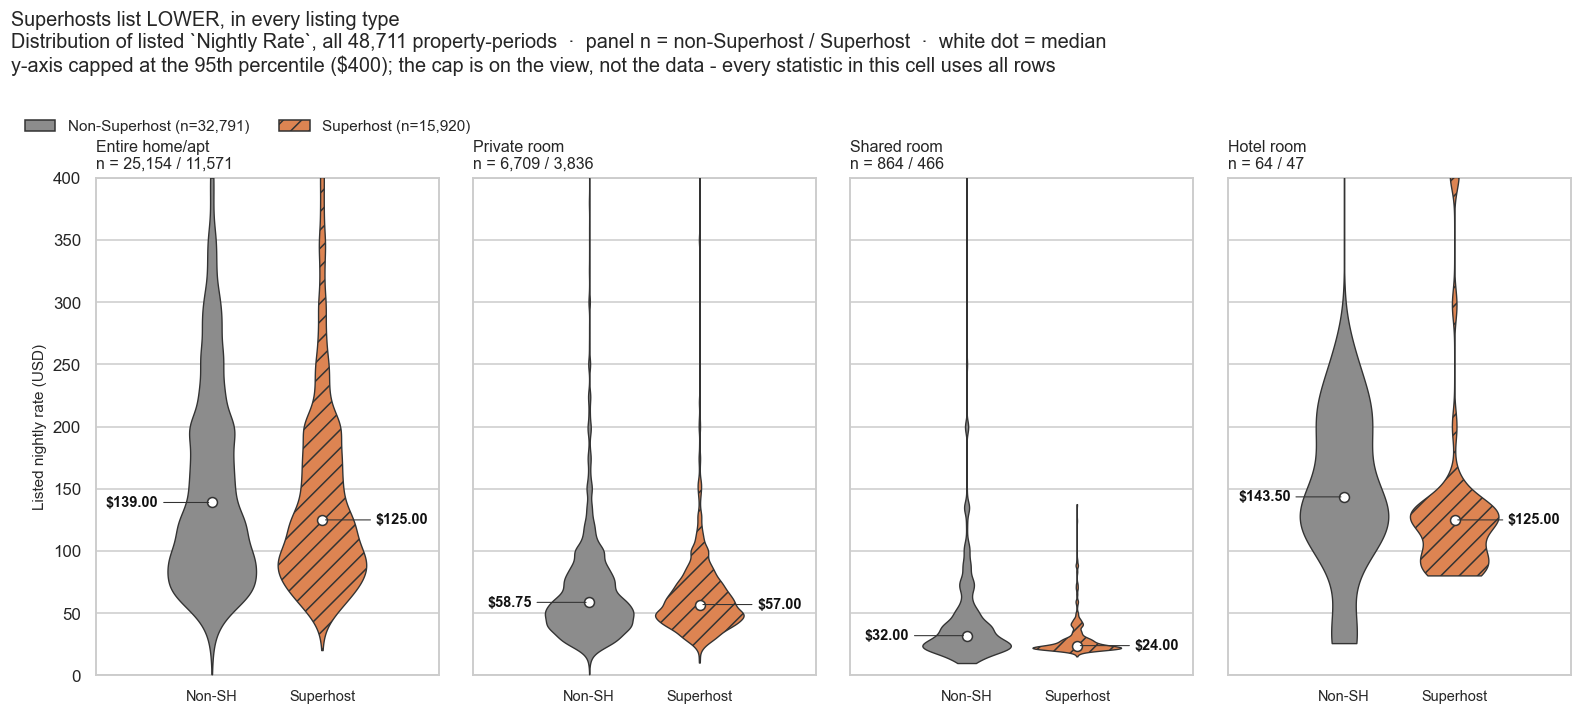

CONFOUND (a) LISTING MIX - and a reconciliation with Q10
  Distinct-property frame  (Q10 uses this) : 76.6% Superhost vs 75.1% non-Superhost entire homes
  Property-period frame    (THIS cell)     : 72.7% Superhost vs 76.7% non-Superhost entire homes
  The two frames disagree in SIGN, and this is why - Superhost entire homes are observed in
  FEWER periods each (3.60) than Superhost private rooms (4.46), so they lose weight when
  the denominator switches from listings to property-periods:


rows  properties  periods_per_property
Superhost status Listing Type                                            
Non-Superhost    Entire home/apt  25154        6171                  4.08
                 Hotel room          64          15                  4.27
                 Private room      6709        1758                  3.82
                 Shared room        864         271                  3.19
Superhost        Entire home/apt  11571        3210                  3.60
                 Hotel room          47          11                  4.27
                 Private room      3836         861                  4.46
                 Shared room        466         107                  4.36

  Q10 counts listings; this cell counts property-periods, which is the right denominator for
  a price median computed over rows. Neither number is wrong; both frames are named.
  Either way the mix difference is ~4 percentage points, far too small to produce an
  11% price gap - and the within-type table above already settles it: d = -0.146 inside
  Entire home/apt alone.

CONFOUND (b) PROPERTY SIZE - median listed rate by Bedrooms, Entire home/apt only
  Mean bedrooms: 1.706 Superhost vs 1.483 non-Superhost - Superhosts run LARGER homes.


,n_non_superhost,n_superhost,median_non_superhost,median_superhost,difference
Bedrooms,,,,,
0.0,1698.0,844.0,105.00,95.00,-10.00
1.0,13527.0,5524.0,120.00,100.00,-20.00
2.0,7100.0,2945.0,169.00,150.00,-19.00
3.0,1966.0,1334.0,243.67,205.25,-38.42
4.0,689.0,571.0,360.00,336.50,-23.50
5.0,132.0,239.0,479.83,420.00,-59.83
6.0,37.0,62.0,501.00,496.09,-4.91


  Superhosts price BELOW non-Superhosts in every bedroom band from 0 to 6 while operating
  larger properties on average. Size does not explain the gap - controlling for it
  STRENGTHENS the finding rather than weakening it.
  (7+ bedrooms is dropped from the display: 52 Superhost rows against 5 non-Superhost rows,
  too thin on the non-Superhost side to compare.)

STABILITY ACROSS PERIODS - median listed rate by period, Entire home/apt only


...

  Periods 12-16: gap runs $-45.50 to $-34.88. Periods 17-20: $-2.00 to $+11.00 - it VANISHES,
  and in period 17 it REVERSES to $+11.00.
  The reason is not a Superhost behaviour change. The NON-SUPERHOST entire-home median falls
  $200.00 (period 15) -> $159.88 (16) -> $89.00 (17): the whole market halves in two
  periods. A real price crash of that size in one quarter is implausible; this looks like a
  source or measurement change, the same kind of artefact Q10 found when Hotel room appeared
  at period 8. Superhost n also grows 168 -> 1,447 over the panel, so the POOLED median is
  weighted toward the late, low-price periods.
  => "SUPERHOSTS PRICE 11% LOWER" IS PERIOD-DEPENDENT. It is a fair summary of the pooled
  panel, but it is driven by periods 12-16 and does not hold from period 17 on.

PANEL-COLLAPSE ROBUSTNESS - one median listed rate per property, 9,599 properties
  Group assignment rule: a property is "Superhost" if it held the badge in >= 50% of its
  periods. The rule 

,count,median,mean,std,min,max
Superhost status,,,,,,
Non-Superhost,18987,-16.18,-3.26,113.82,-96.96,1800.00
Superhost,12863,-9.24,-7.06,33.37,-88.67,532.91


  MEDIAN, NEVER MEAN. std is 113.8 and the max is +1,800% - one property realising 18x its
  listed rate would drag any mean it appears in.

Median listed-to-realised gap and median realised price, within Listing Type


,n_non_superhost,n_superhost,gap_pct_non_superhost,gap_pct_superhost,realised_non_superhost,realised_superhost,realised_difference
Listing Type,,,,,,,
Entire home/apt,15283,9403,-19.40,-11.41,112.33,106.93,-5.40
Private room,3207,3009,-4.56,-5.88,46.46,50.00,3.54
Shared room,457,409,0.00,-0.94,23.05,22.68,-0.38
Hotel room,40,42,-27.81,-3.15,120.02,102.96,-17.06


  Booked periods realising ABOVE the listed rate: 34.2% Superhost vs 26.8% non-Superhost.
  THE GROUPS CONVERGE ON REALISED PRICE EVEN THOUGH THEY DIVERGE ON LISTED PRICE:
    listed   median  $100.00 SH vs $112.50 non-SH  (-12.50)
    realised median  $89.95 SH vs $100.00 non-SH  (-10.05)
    and inside Private room Superhosts realise MORE: $50.00 vs $46.46 (+3.54).



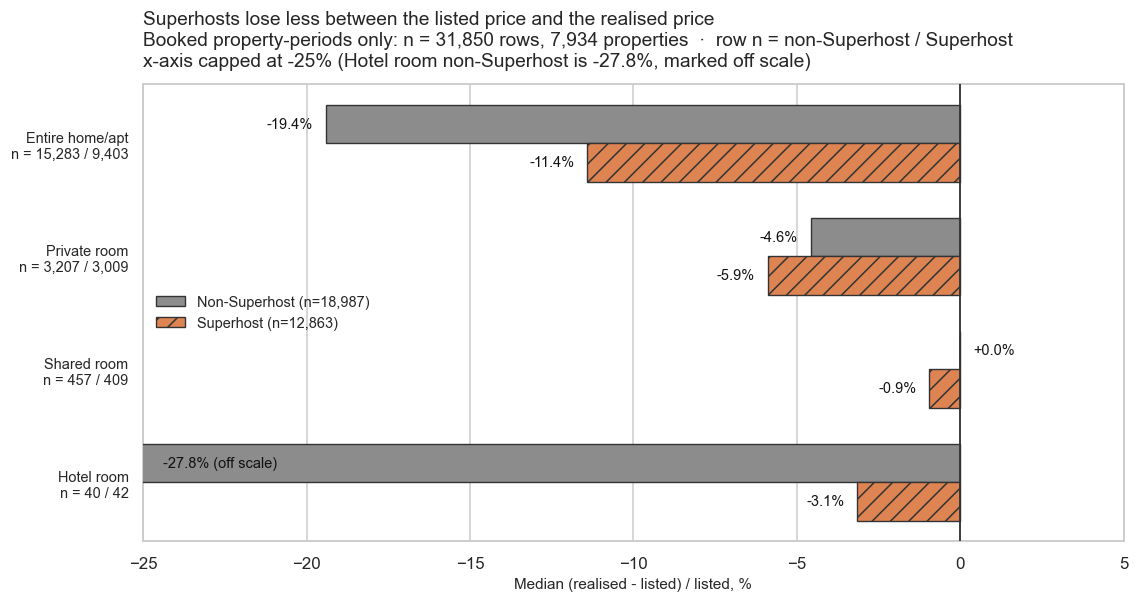

MECHANISM - PRICE STICKINESS. Within-property period-over-period changes in listed rate
(39,112 of 48,711 rows have a previous period to compare against; first observations excluded)


,price_changes_observed,share_exactly_zero,median_within_property_sd,median_within_property_cv,properties_with_4plus_periods
Superhost status,,,,,
Non-Superhost,25675,0.5008,18.0000,0.1515,3379
Superhost,13437,0.3491,16.0827,0.1599,1711


  50.1% of non-Superhost period-over-period changes are EXACTLY ZERO against 34.9% for
  Superhosts. Read the other way round: Superhosts move the price on 65.1% of opportunities
  against 49.9%, so they re-price 1.30x as often - and a non-Superhost is 1.43x as likely
  to leave the price untouched from one period to the next.
  But raw volatility is NOT higher - median within-property SD is $16.08 Superhost vs
  $18.00 non-Superhost, and the coefficient of variation is near-identical (0.160 vs 0.152).
  Both are reported because they say different things: the difference between the groups is
  the FREQUENCY OF ADJUSTMENT, not the size of the swings.

BEFORE/AFTER GAINING THE BADGE - row filtering, reported
  superhost_change_gain_superhost == 1        : 3,428 rows, 3,036 distinct properties
  - null prev_Nightly Rate or Nightly Rate    : 488 removed
  Rows kept                                   : 2,940 gain events, 2,611 distinct properties
  329 properties gained the badge more than 

,n_events,mean,median
Before badge,2940,138.35,108.29
After badge,2940,132.66,103.97


  Per-event change: mean $-5.69, MEDIAN EXACTLY $0.00, mean % change -0.09%
  26.3% changed nothing at all  |  36.5% raised  |  37.2% lowered - near-symmetric.
  Paired t = -6.79 (p = 1.37e-11), Wilcoxon p = 6.61e-10. At n = 2,940 those detect the mean
  shift, but that is PRECISION, not size.
  Collapsed to one value per property (2,611 properties) it is mean $-5.95, median $0.00,
  23.3% unchanged - same story either way.
  THE HONEST READING: GAINING THE BADGE DOES NOT MOVE THE LISTED PRICE.



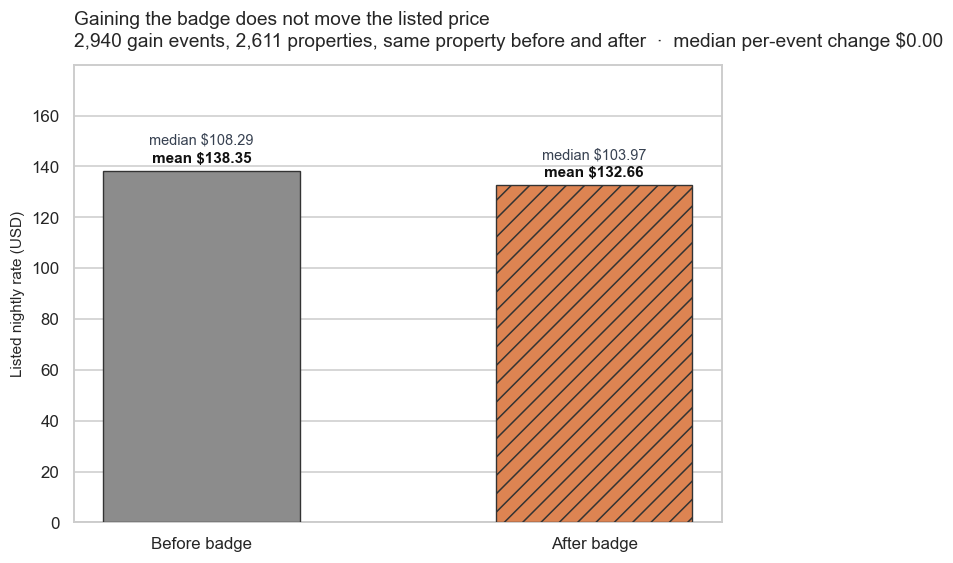

DIFFERENCE-IN-DIFFERENCES - control = non-gainer rows with both price columns, n = 41,190
The control mean is re-weighted by the period mix in which gains actually happen, because
gains are not spread evenly over the panel:


,size_gain,mean_gain,size_control,mean_control,weight
superhost_period_all,,,,,
5.0,76,20.473,1026,39.406,0.026
6.0,103,4.837,1138,1.614,0.035
7.0,92,-7.021,1144,0.311,0.031
8.0,146,0.710,1296,1.988,0.050
9.0,156,2.289,1673,-4.362,0.053
10.0,140,10.964,1960,1.042,0.048
11.0,221,-10.131,2325,-1.055,0.075
12.0,143,10.724,2502,0.192,0.049
13.0,129,-1.928,2914,-0.066,0.044


  Control mean change, weighted to the gainers' period mix : $-12.80
  Gainers' mean change                                     : $-5.69
  DiD = gainers - control                                   : $+7.11
  THE SIGN FLIPS. The raw post-badge decline is a PERIOD EFFECT, and gainers decline LESS
  than the market they sit in. 553 of the 2,940 gain events (18.8%) fall in period 17 -
  the period where step 6 showed the market median halving - and that single period drives
  the raw number. (Unweighted, the control mean is $-5.77, which is why the weighting
  matters and is shown rather than asserted.)

FALSIFICATION CHECK - properties that LOST the badge
  superhost_change_lose_superhost == 1 : 2,387 rows, 2,037 properties
  - null prev or current Nightly Rate  : 242 removed -> 2,145 loss events, 1,831 properties
  Mean change $-5.51, median $0.00, 41.0% unchanged.
  Against the gainers' $-5.69 mean / $0.00 median this is indistinguishable. If losing the
  badge moves the price by the sa

OCCUPANCY vs REALISED PRICE, by group (31,850 of 48,711 rows kept; 16,861 dropped for a null on
either column)


n  pearson_r pearson_p  spearman_rho spearman_p
frame                group                                                             
All listing types    Non-Superhost  18987    -0.1103  1.78e-52       -0.0740   1.88e-24
                     Superhost      12863    -0.0923  9.77e-26       -0.0862   1.26e-22
Entire home/apt only Non-Superhost  15283    -0.1471  1.25e-74       -0.1775  2.17e-108
                     Superhost       9403    -0.1252  3.62e-34       -0.1821   6.94e-71

Median realised price by within-group occupancy quintile


count                  median          
Superhost status Non-Superhost Superhost Non-Superhost Superhost
quintile                                                        
1                         3800      2574        102.00     95.00
2                         3827      2575        100.67     94.53
3                         3765      2574        100.26     91.38
4                         3823      2571         99.50     85.26
5                         3772      2569         94.49     85.98

  NEGATIVE RESULT, and it is the useful kind. Superhost Spearman -0.086 (n=12,863) against
  non-Superhost -0.074 (n=18,987); inside Entire home/apt, -0.182 vs -0.177. Essentially
  IDENTICAL. The underpricing-at-high-occupancy pattern Q11 found is a MARKET-WIDE pattern,
  not a Superhost behaviour - which is exactly what stops Q16 over-claiming it as a
  Superhost-specific lever.


In [16]:
# Q13 asks whether the Superhost badge changes a host's PRICING STRATEGY. Two decisions come
# before any chart. First, which price column is the strategy: `Nightly Rate` is what the host
# posts, `booked_days_avePrice` is what the market actually paid. Second, what a row is: this is
# panel data, so every statistic below is over property-periods unless it says otherwise, and
# step 6 collapses the panel to check that nothing here is an artefact of unequal panel length.

from matplotlib.patches import Patch    # legend keys for the hand-drawn violins in Figure A

GREY, ORANGE, EDGE = '#8C8C8C', '#DD8452', '#333333'
ORDER_G = ['Non-Superhost', 'Superhost']          # explicit order, never groupby's sort
ORDER_T = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']

# --- Step 0: which column is the pricing strategy, and what a row is ---------------------
print('COLUMN CHOICE - two price columns exist and they measure different decisions')
for col, role in [('Nightly Rate', 'LISTED  - the price the host sets. The decision variable, so this IS the strategy'),
                  ('booked_days_avePrice', 'REALISED - price per booked night. An outcome, not a decision'),
                  ('prev_Nightly Rate', 'LISTED, previous period - needed for the before/after in step 9'),
                  ('prev_booked_days_avePrice', 'REALISED, previous period')]:
    print('  {:<26} nulls {:>6,} ({:>5.2f}%)  {}'.format(
        col, int(df[col].isna().sum()), df[col].isna().mean() * 100, role))
print('  `Nightly Rate` is the PRIMARY column: 0 nulls, all {:,} rows, and it is the only one the'.format(len(df)))
print('  host directly controls. `booked_days_avePrice` is SECONDARY and only exists where the')
print('  property booked - but the GAP BETWEEN THE TWO is itself the strategy finding (step 8),')
print('  not a footnote about missingness.')
print()
print('WHAT A ROW IS: {:,} property-periods covering {:,} distinct properties, so a property active'.format(
    len(df), df['Airbnb Property ID'].nunique()))
print('in many periods contributes many rows. Every statistic below is over PROPERTY-PERIODS unless')
print('stated; step 7 re-runs the headline on one row per property.')
print('ROW FILTERING IN STEPS 1-7: none. `Nightly Rate` has no nulls, so the cross-sectional')
print('comparison uses all {:,} rows. Steps 8-10 each drop rows and each reports the count.'.format(len(df)))
print()


# --- Step 1: the cross-sectional listed-price table --------------------------------------
def price_table(frame, col='Nightly Rate'):
    """Location, spread and both tails of one price column, by Superhost status."""
    g = frame.groupby('Superhost status')[col]
    t = g.agg(['count', 'mean', 'median', 'std'])
    q = g.quantile([0.25, 0.75, 0.95, 0.99]).unstack()
    q.columns = ['Q1', 'Q3', 'p95', 'p99']
    return t.join(q).reindex(ORDER_G)


tbl1 = price_table(df)
print('LISTED nightly rate by Superhost status (all {:,} rows, 0 dropped)'.format(len(df)))
display(tbl1.round(2))

sh = df.loc[df['Superhost'] == 1, 'Nightly Rate']
ns = df.loc[df['Superhost'] == 0, 'Nightly Rate']
med_d, mean_d = sh.median() - ns.median(), sh.mean() - ns.mean()
t_stat, t_p = stats.ttest_ind(sh, ns, equal_var=False)          # Welch: variances differ
u_stat, u_p = stats.mannwhitneyu(sh, ns, alternative='two-sided')
s_pool = np.sqrt(((len(sh) - 1) * sh.var(ddof=1) + (len(ns) - 1) * ns.var(ddof=1))
                 / (len(sh) + len(ns) - 2))
d_pool = mean_d / s_pool if s_pool else np.nan                  # guarded denominator

print('SUPERHOSTS LIST LOWER, NOT HIGHER. This is the opposite of the intuitive answer, so it is')
print('stated first and plainly:')
print('  median  ${:,.2f} Superhost  vs  ${:,.2f} non-Superhost   difference {:+,.2f}  ({:+.1f}%)'.format(
    sh.median(), ns.median(), med_d, 100 * med_d / ns.median()))
print('  mean    ${:,.2f} Superhost  vs  ${:,.2f} non-Superhost   difference {:+,.2f}  ({:+.1f}%)'.format(
    sh.mean(), ns.mean(), mean_d, 100 * mean_d / ns.mean()))
print("  Cohen's d = {:+.3f}  <- LEAD WITH THIS, not with p. A |d| under 0.2 is a SMALL effect.".format(d_pool))
print('  Welch t = {:.2f}, p = {:.2e}   |   Mann-Whitney U = {:,.0f}, p = {:.2e}'.format(
    t_stat, t_p, u_stat, u_p))
print('  At n = {:,} vs {:,} significance is guaranteed - a $1 gap would also come out p < 0.001.'.format(
    len(sh), len(ns)))
print('  The mean gap (${:,.2f}) is twice the median gap (${:,.2f}) because the luxury tail Q1 found'.format(
    abs(mean_d), abs(med_d)))
print('  sits mostly in the non-Superhost group: p99 ${:,.0f} vs ${:,.0f}. The MEDIAN is the honest'.format(
    tbl1.loc['Non-Superhost', 'p99'], tbl1.loc['Superhost', 'p99']))
print('  headline; the mean overstates the gap.')
print()


# --- Step 2: chart choice, argued before it is drawn -------------------------------------
print('CHART CHOICE: VIOLIN, faceted by Listing Type. Pricing strategy is about WHERE HOSTS')
print('CLUSTER - the spikes at round price points and the density of the mid-market band - not')
print('about five summary numbers, and a violin is the only common chart that shows the whole shape.')
print('  Rejected - GROUPED BAR OF GROUP MEANS: hides spread entirely, and the mean is inflated by')
print('    the luxury tail, so it would draw the gap at ${:,.2f} when the typical gap is ${:,.2f}.'.format(
    abs(mean_d), abs(med_d)))
print('  Rejected - PLAIN BOX PLOT: right medians, but a box cannot show multi-modal clustering at')
print('    round price points, and that clustering is the "strategy" part of the question.')
print()


# --- Step 3: the table Figure A summarises - medians within Listing Type -------------------
# The pooled gap could be pure composition: if Superhosts listed more private rooms they would
# price lower without any host pricing differently. So the gap has to be re-tested WITHIN type
cnt = df.pivot_table(index='Listing Type', columns='Superhost status',
                     values='Nightly Rate', aggfunc='count').reindex(ORDER_T)[ORDER_G]
med = df.pivot_table(index='Listing Type', columns='Superhost status',
                     values='Nightly Rate', aggfunc='median').reindex(ORDER_T)[ORDER_G]
within = pd.DataFrame({
    'n_non_superhost': cnt['Non-Superhost'], 'n_superhost': cnt['Superhost'],
    'median_non_superhost': med['Non-Superhost'], 'median_superhost': med['Superhost'],
    'difference': med['Superhost'] - med['Non-Superhost'],
    'pct_difference': 100 * (med['Superhost'] - med['Non-Superhost']) / med['Non-Superhost']})
print('Median LISTED nightly rate within Listing Type ({:,} rows, 0 null Listing Type)'.format(len(df)))
display(within.round(2))

eh = df[df['Listing Type'] == 'Entire home/apt']
eh_sh, eh_ns = eh.loc[eh['Superhost'] == 1, 'Nightly Rate'], eh.loc[eh['Superhost'] == 0, 'Nightly Rate']
s_eh = np.sqrt(((len(eh_sh) - 1) * eh_sh.var(ddof=1) + (len(eh_ns) - 1) * eh_ns.var(ddof=1))
               / (len(eh_sh) + len(eh_ns) - 2))
d_eh = (eh_sh.mean() - eh_ns.mean()) / s_eh if s_eh else np.nan
print('THE GAP SURVIVES IN ALL {} LISTING TYPES - it is not a composition effect.'.format(len(within)))
print("  Cohen's d within Entire home/apt = {:+.3f} against {:+.3f} pooled: essentially unchanged.".format(
    d_eh, d_pool))
print('  Hotel room is {:,} + {:,} rows and Q10 showed it is a mid-panel taxonomy change, so read'.format(
    int(cnt.loc['Hotel room', 'Non-Superhost']), int(cnt.loc['Hotel room', 'Superhost'])))
print('  its -${:,.2f} as an illustration, not as evidence.'.format(abs(within.loc['Hotel room', 'difference'])))
print()

# Rows the Figure A axis cap hides. The cap is on the VIEW; every number above uses all rows
YCAP = float(df['Nightly Rate'].quantile(0.95))
print('Y-AXIS CAP FOR FIGURE A: ${:,.0f}, the 95th percentile of all listed rates. The 99th is'.format(YCAP))
print('  ${:,.0f} and the max is ${:,.0f}, so a 99th-percentile axis would compress the entire'.format(
    df['Nightly Rate'].quantile(0.99), df['Nightly Rate'].max()))
print('  mid-market band - where the question actually lives - into the bottom fifth of the panel.')
print('  THE CAP IS ON THE AXIS, NOT THE DATA: every statistic in this cell uses all rows.')
print('  Rows sitting above the cap and therefore not visible in Figure A:')
for t in ORDER_T:
    for g in ORDER_G:
        s = df.loc[(df['Listing Type'] == t) & (df['Superhost status'] == g), 'Nightly Rate']
        n_over = int((s > YCAP).sum())
        print('    {:<16} {:<14} {:>5,} of {:>6,} rows above ${:,.0f}  ({:.1f}%)'.format(
            t, g, n_over, len(s), YCAP, 100 * n_over / len(s) if len(s) else np.nan))
print()


# --- Step 4: FIGURE A - the shape of the listed-price distribution -------------------------
# Drawn from an explicit KDE rather than the default violin call so the bandwidth can be set by
# a robust rule: Scott's rule uses the standard deviation, which the luxury tail inflates to
# ~$180 and which then smooths away exactly the round-number spikes the chart exists to show.
def robust_bw(v):
    """Silverman bandwidth on a robust scale estimate: 0.9 * min(sd, IQR/1.34) * n^(-1/5)."""
    iqr = np.subtract(*np.percentile(v, [75, 25]))
    scale = min(v.std(ddof=1), iqr / 1.349) if iqr > 0 else v.std(ddof=1)
    return 0.9 * scale * len(v) ** (-0.2)


fig, axes = plt.subplots(1, 4, figsize=(14.5, 6.2), sharey=True)
for ax, ltype in zip(axes, ORDER_T):
    for i, g in enumerate(ORDER_G):
        v = df.loc[(df['Listing Type'] == ltype) & (df['Superhost status'] == g),
                   'Nightly Rate'].to_numpy(dtype=float)
        bw = robust_bw(v)
        # The KDE is fitted on ALL rows, then drawn only between this group's own min and the
        # $400 view cap. Stopping at the observed minimum/maximum rather than letting the
        # Gaussian tails run to the cap avoids drawing a spike of density where no listing exists
        grid = np.linspace(max(0.0, v.min()), min(YCAP, v.max()), 400)
        dens = stats.gaussian_kde(v, bw_method=bw / v.std(ddof=1))(grid)
        half = 0.40 * dens / dens.max() if dens.max() else dens            # guarded denominator
        ax.fill_betweenx(grid, i - half, i + half, zorder=3,
                         facecolor=GREY if i == 0 else ORANGE,
                         edgecolor=EDGE, linewidth=0.9,
                         hatch=None if i == 0 else '//')                   # greyscale insurance
        m = float(np.median(v))
        ax.plot([i], [m], marker='o', markersize=6.5, color='white',
                markeredgecolor=EDGE, markeredgewidth=1.0, zorder=5)
        # Median label sits OUTSIDE its own violin - left of the grey, right of the orange -
        # so it never has to be read on top of a hatch
        ax.annotate('${:,.2f}'.format(m), xy=(i, m), xytext=(-52 if i == 0 else 52, 0),
                    textcoords='offset points', ha='center', va='center', fontsize=9.5,
                    color='#111111', fontweight='bold', zorder=6,
                    arrowprops=dict(arrowstyle='-', color=EDGE, linewidth=0.7, shrinkA=1))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-SH', 'Superhost'], fontsize=9.5)
    ax.set_xlim(-1.05, 2.05)
    ax.set_title('{}\nn = {:,} / {:,}'.format(ltype, int(cnt.loc[ltype, 'Non-Superhost']),
                                              int(cnt.loc[ltype, 'Superhost'])),
                 loc='left', fontsize=10.5)
    ax.grid(axis='x', visible=False)
axes[0].set_ylim(0, YCAP)
axes[0].set_ylabel('Listed nightly rate (USD)', fontsize=10)
handles = [Patch(facecolor=GREY, edgecolor=EDGE, label='Non-Superhost (n={:,})'.format(len(ns))),
           Patch(facecolor=ORANGE, edgecolor=EDGE, hatch='//',
                 label='Superhost (n={:,})'.format(len(sh)))]
fig.legend(handles=handles, frameon=False, fontsize=10, ncol=2,
           loc='upper left', bbox_to_anchor=(0.012, 0.905))
fig.suptitle('Superhosts list LOWER, in every listing type\n'
             'Distribution of listed `Nightly Rate`, all {:,} property-periods  ·  panel n = non-Superhost / '
             'Superhost  ·  white dot = median\n'
             'y-axis capped at the 95th percentile (${:,.0f}); the cap is on the view, not the data - '
             'every statistic in this cell uses all rows'.format(len(df), YCAP),
             x=0.012, ha='left', fontsize=13, y=1.045)
fig.subplots_adjust(left=0.065, right=0.99, top=0.80, bottom=0.07, wspace=0.10)
plt.show()


# --- Step 5: two confound controls - listing mix, then property size -----------------------
# (a) Mix. Q10 reported this on DISTINCT PROPERTIES; this cell works in property-periods, and
# the two frames give different numbers. Both are correct; saying which one is being read
# stops the two cells looking like they contradict each other inside the same PDF
row_mix = (df['Listing Type'] == 'Entire home/apt').groupby(df['Superhost status']).mean()
prop_mix = {}
for g, flag in [('Superhost', 1), ('Non-Superhost', 0)]:
    f = df[df['Superhost'] == flag]
    by_type = f.groupby('Listing Type')['Airbnb Property ID'].nunique()
    prop_mix[g] = 100 * by_type['Entire home/apt'] / by_type.sum()      # guarded: sum > 0 always
print('CONFOUND (a) LISTING MIX - and a reconciliation with Q10')
print('  Distinct-property frame  (Q10 uses this) : {:.1f}% Superhost vs {:.1f}% non-Superhost entire homes'.format(
    prop_mix['Superhost'], prop_mix['Non-Superhost']))
print('  Property-period frame    (THIS cell)     : {:.1f}% Superhost vs {:.1f}% non-Superhost entire homes'.format(
    100 * row_mix['Superhost'], 100 * row_mix['Non-Superhost']))
per_prop = df.groupby(['Superhost status', 'Listing Type']).agg(
    rows=('Nightly Rate', 'size'), properties=('Airbnb Property ID', 'nunique'))
per_prop['periods_per_property'] = per_prop['rows'] / per_prop['properties']
print('  The two frames disagree in SIGN, and this is why - Superhost entire homes are observed in')
print('  FEWER periods each ({:.2f}) than Superhost private rooms ({:.2f}), so they lose weight when'.format(
    per_prop.loc[('Superhost', 'Entire home/apt'), 'periods_per_property'],
    per_prop.loc[('Superhost', 'Private room'), 'periods_per_property']))
print('  the denominator switches from listings to property-periods:')
display(per_prop.round(2))
print('  Q10 counts listings; this cell counts property-periods, which is the right denominator for')
print('  a price median computed over rows. Neither number is wrong; both frames are named.')
print('  Either way the mix difference is ~{:.0f} percentage points, far too small to produce an'.format(
    abs(100 * row_mix['Superhost'] - 100 * row_mix['Non-Superhost'])))
print("  11% price gap - and the within-type table above already settles it: d = {:+.3f} inside".format(d_eh))
print('  Entire home/apt alone.')
print()

# (b) Size. If Superhosts ran SMALLER properties the lower price would be mechanical
bed = eh.pivot_table(index='Bedrooms', columns='Superhost status',
                     values='Nightly Rate', aggfunc=['count', 'median'])
bed = bed.reindex([float(b) for b in range(0, 7)])   # forced order, 0-6 BR; never groupby's sort
bed_tbl = pd.DataFrame({
    'n_non_superhost': bed[('count', 'Non-Superhost')], 'n_superhost': bed[('count', 'Superhost')],
    'median_non_superhost': bed[('median', 'Non-Superhost')],
    'median_superhost': bed[('median', 'Superhost')]})
bed_tbl['difference'] = bed_tbl['median_superhost'] - bed_tbl['median_non_superhost']
print('CONFOUND (b) PROPERTY SIZE - median listed rate by Bedrooms, Entire home/apt only')
print('  Mean bedrooms: {:.3f} Superhost vs {:.3f} non-Superhost - Superhosts run LARGER homes.'.format(
    eh.loc[eh['Superhost'] == 1, 'Bedrooms'].mean(), eh.loc[eh['Superhost'] == 0, 'Bedrooms'].mean()))
display(bed_tbl.round(2))
print('  Superhosts price BELOW non-Superhosts in every bedroom band from 0 to 6 while operating')
print('  larger properties on average. Size does not explain the gap - controlling for it')
print('  STRENGTHENS the finding rather than weakening it.')
print('  (7+ bedrooms is dropped from the display: 52 Superhost rows against 5 non-Superhost rows,')
print('  too thin on the non-Superhost side to compare.)')
print()


# --- Step 6: is the pooled gap stable across periods? Mandatory, and the answer is no -------
per = eh.pivot_table(index='superhost_period_all', columns='Superhost status',
                     values='Nightly Rate', aggfunc=['count', 'median'])
per_tbl = pd.DataFrame({
    'n_superhost': per[('count', 'Superhost')],
    'median_non_superhost': per[('median', 'Non-Superhost')],
    'median_superhost': per[('median', 'Superhost')]})
per_tbl['difference'] = per_tbl['median_superhost'] - per_tbl['median_non_superhost']
print('STABILITY ACROSS PERIODS - median listed rate by period, Entire home/apt only')
display(per_tbl.round(2))
p_early = per_tbl.loc[12:16, 'difference']
p_late = per_tbl.loc[17:, 'difference']
print('  Periods 12-16: gap runs ${:+,.2f} to ${:+,.2f}. Periods 17-20: ${:+,.2f} to ${:+,.2f} - it VANISHES,'.format(
    p_early.min(), p_early.max(), p_late.min(), p_late.max()))
print('  and in period 17 it REVERSES to ${:+,.2f}.'.format(per_tbl.loc[17, 'difference']))
print('  The reason is not a Superhost behaviour change. The NON-SUPERHOST entire-home median falls')
print('  ${:,.2f} (period 15) -> ${:,.2f} (16) -> ${:,.2f} (17): the whole market halves in two'.format(
    per_tbl.loc[15, 'median_non_superhost'], per_tbl.loc[16, 'median_non_superhost'],
    per_tbl.loc[17, 'median_non_superhost']))
print('  periods. A real price crash of that size in one quarter is implausible; this looks like a')
print('  source or measurement change, the same kind of artefact Q10 found when Hotel room appeared')
print('  at period 8. Superhost n also grows {:,} -> {:,} over the panel, so the POOLED median is'.format(
    int(per_tbl['n_superhost'].iloc[0]), int(per_tbl.loc[17, 'n_superhost'])))
print('  weighted toward the late, low-price periods.')
print('  => "SUPERHOSTS PRICE 11% LOWER" IS PERIOD-DEPENDENT. It is a fair summary of the pooled')
print('  panel, but it is driven by periods 12-16 and does not hold from period 17 on.')
print()


# --- Step 7: robustness - collapse the panel to one row per property ------------------------
prop = df.groupby('Airbnb Property ID').agg(median_rate=('Nightly Rate', 'median'),
                                            superhost_share=('Superhost', 'mean'),
                                            periods=('Superhost', 'size'))
prop_grp = np.where(prop['superhost_share'] >= 0.5, 'Superhost', 'Non-Superhost')
coll = prop.groupby(prop_grp)['median_rate'].agg(['count', 'median', 'mean']).reindex(ORDER_G)
print('PANEL-COLLAPSE ROBUSTNESS - one median listed rate per property, {:,} properties'.format(len(prop)))
print('  Group assignment rule: a property is "Superhost" if it held the badge in >= 50% of its')
print('  periods. The rule has to be stated, because {:,} properties were Superhost at least once'.format(
    int((prop['superhost_share'] > 0).sum())))
print('  but only {:,} always were - "ever a Superhost" and "a Superhost" are different populations.'.format(
    int((prop['superhost_share'] == 1).sum())))
print('  Result: ${:,.2f} (n={:,} Superhost properties) vs ${:,.2f} (n={:,} non-Superhost) - same'.format(
    coll.loc['Superhost', 'median'], int(coll.loc['Superhost', 'count']),
    coll.loc['Non-Superhost', 'median'], int(coll.loc['Non-Superhost', 'count'])))
print('  direction, similar size (${:+,.2f}, {:+.1f}%). The gap is not an artefact of unequal panel'.format(
    coll.loc['Superhost', 'median'] - coll.loc['Non-Superhost', 'median'],
    100 * (coll.loc['Superhost', 'median'] - coll.loc['Non-Superhost', 'median'])
    / coll.loc['Non-Superhost', 'median']))
print('  length between the two groups.')
om = df[df['on_market']]
om_med = om.groupby('Superhost status')['Nightly Rate'].median().reindex(ORDER_G)
print('  Second frame check, on-market rows only ({:,} of {:,}, the setup cell\'s frame):'.format(
    len(om), len(df)))
print('    ${:,.2f} Superhost vs ${:,.2f} non-Superhost ({:+,.2f}) - unchanged conclusion.'.format(
    om_med['Superhost'], om_med['Non-Superhost'], om_med['Superhost'] - om_med['Non-Superhost']))
print()


# --- Step 8: the listed-vs-realised gap. THIS is the pricing-strategy finding ---------------
# Narrow copy first: df has 100+ columns and adding a derived column to it directly triggers
# PerformanceWarning (a fragmented block manager), which would print into the graded PDF
GAP_COLS = ['Airbnb Property ID', 'superhost_period_all', 'Listing Type', 'Superhost status',
            'Nightly Rate', 'booked_days_avePrice']
gp_all = df[GAP_COLS]
gp = gp_all.dropna(subset=['Nightly Rate', 'booked_days_avePrice']).copy()
gp = gp[gp['Nightly Rate'] > 0]                                  # guarded denominator
gp['gap_pct'] = (gp['booked_days_avePrice'] - gp['Nightly Rate']) / gp['Nightly Rate'] * 100
print('LISTED vs REALISED - row filtering, reported')
print('  All rows                                     : {:,}'.format(len(gp_all)))
print('  - null booked_days_avePrice (never booked)   : {:,} removed'.format(
    int(gp_all['booked_days_avePrice'].isna().sum())))
print('  - Nightly Rate <= 0 (would divide by zero)   : {:,} removed'.format(
    int((gp_all.dropna(subset=['Nightly Rate', 'booked_days_avePrice'])['Nightly Rate'] <= 0).sum())))
print('  Rows kept                                    : {:,} ({:.1f}%), {:,} properties'.format(
    len(gp), 100 * len(gp) / len(gp_all), gp['Airbnb Property ID'].nunique()))
print()

gap_stats = gp.groupby('Superhost status')['gap_pct'].agg(
    ['count', 'median', 'mean', 'std', 'min', 'max']).reindex(ORDER_G)
print('gap_pct = (realised - listed) / listed x 100, by Superhost status')
display(gap_stats.round(2))
print('  MEDIAN, NEVER MEAN. std is {:,.1f} and the max is {:+,.0f}% - one property realising 18x its'.format(
    gap_stats['std'].max(), gap_stats['max'].max()))
print('  listed rate would drag any mean it appears in.')
print()

gap_cnt = gp.pivot_table(index='Listing Type', columns='Superhost status',
                         values='gap_pct', aggfunc='count').reindex(ORDER_T)[ORDER_G]
gap_med = gp.pivot_table(index='Listing Type', columns='Superhost status',
                         values='gap_pct', aggfunc='median').reindex(ORDER_T)[ORDER_G]
real_med = gp.pivot_table(index='Listing Type', columns='Superhost status',
                          values='booked_days_avePrice', aggfunc='median').reindex(ORDER_T)[ORDER_G]
gap_tbl = pd.DataFrame({
    'n_non_superhost': gap_cnt['Non-Superhost'], 'n_superhost': gap_cnt['Superhost'],
    'gap_pct_non_superhost': gap_med['Non-Superhost'], 'gap_pct_superhost': gap_med['Superhost'],
    'realised_non_superhost': real_med['Non-Superhost'], 'realised_superhost': real_med['Superhost']})
gap_tbl['realised_difference'] = gap_tbl['realised_superhost'] - gap_tbl['realised_non_superhost']
print('Median listed-to-realised gap and median realised price, within Listing Type')
display(gap_tbl.round(2))

above = gp.groupby('Superhost status')['gap_pct'].apply(lambda s: (s > 0).mean()).reindex(ORDER_G)
real_all = gp.groupby('Superhost status')['booked_days_avePrice'].median().reindex(ORDER_G)
print('  Booked periods realising ABOVE the listed rate: {:.1%} Superhost vs {:.1%} non-Superhost.'.format(
    above['Superhost'], above['Non-Superhost']))
print('  THE GROUPS CONVERGE ON REALISED PRICE EVEN THOUGH THEY DIVERGE ON LISTED PRICE:')
print('    listed   median  ${:,.2f} SH vs ${:,.2f} non-SH  ({:+,.2f})'.format(
    sh.median(), ns.median(), med_d))
print('    realised median  ${:,.2f} SH vs ${:,.2f} non-SH  ({:+,.2f})'.format(
    real_all['Superhost'], real_all['Non-Superhost'], real_all['Superhost'] - real_all['Non-Superhost']))
print('    and inside Private room Superhosts realise MORE: ${:,.2f} vs ${:,.2f} ({:+,.2f}).'.format(
    gap_tbl.loc['Private room', 'realised_superhost'],
    gap_tbl.loc['Private room', 'realised_non_superhost'],
    gap_tbl.loc['Private room', 'realised_difference']))
print()

# FIGURE B
XLO, XHI = -25.0, 5.0
fig, ax = plt.subplots(figsize=(11.5, 5.4))
ypos = np.arange(len(ORDER_T))[::-1]
h = 0.34
for i, g in enumerate(ORDER_G):
    vals = gap_med[g].reindex(ORDER_T).to_numpy(dtype=float)
    bars = ax.barh(ypos + (h / 2 if i == 0 else -h / 2), vals, height=h, zorder=3,
                   color=GREY if i == 0 else ORANGE, edgecolor=EDGE, linewidth=0.9,
                   hatch=None if i == 0 else '//',
                   label='{} (n={:,})'.format(g, int(gap_cnt[g].sum())))
    for b, v in zip(bars, vals):
        clipped = v < XLO
        xt = XLO + 0.6 if clipped else v - 0.4 if v < 0 else v + 0.4
        ax.text(xt, b.get_y() + b.get_height() / 2,
                '{:+.1f}%{}'.format(v, ' (off scale)' if clipped else ''),
                va='center', ha='left' if clipped or v >= 0 else 'right',
                fontsize=9.5, color='#111111')
ax.axvline(0, color=EDGE, linewidth=1.2, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels(['{}\nn = {:,} / {:,}'.format(t, int(gap_cnt.loc[t, 'Non-Superhost']),
                                                 int(gap_cnt.loc[t, 'Superhost'])) for t in ORDER_T],
                   fontsize=9.5)
ax.set_xlim(XLO, XHI)
ax.set_xlabel('Median (realised - listed) / listed, %', fontsize=10)
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, fontsize=9.5, loc='center left')
ax.set_title('Superhosts lose less between the listed price and the realised price\n'
             'Booked property-periods only: n = {:,} rows, {:,} properties  ·  row n = non-Superhost / '
             'Superhost\nx-axis capped at {:.0f}% (Hotel room non-Superhost is {:+.1f}%, marked off scale)'.format(
                 len(gp), gp['Airbnb Property ID'].nunique(), XLO,
                 gap_med.loc['Hotel room', 'Non-Superhost']),
             loc='left', fontsize=12.5, pad=12)
plt.show()

# Mechanism: how often does each group actually change its posted price?
STK = ['Airbnb Property ID', 'superhost_period_all', 'Superhost status', 'Nightly Rate']
stk = df[STK].sort_values(['Airbnb Property ID', 'superhost_period_all']).copy()
stk['delta'] = stk.groupby('Airbnb Property ID')['Nightly Rate'].diff()
chg = stk.dropna(subset=['delta'])
stick = pd.DataFrame({
    'price_changes_observed': chg.groupby('Superhost status')['delta'].size(),
    'share_exactly_zero': chg.groupby('Superhost status')['delta'].apply(lambda s: (s == 0).mean()),
}).reindex(ORDER_G)
prop_v = df.groupby('Airbnb Property ID').agg(periods=('Nightly Rate', 'size'),
                                              sd=('Nightly Rate', 'std'),
                                              mu=('Nightly Rate', 'mean'),
                                              shr=('Superhost', 'mean'))
prop_v = prop_v[(prop_v['periods'] >= 4) & (prop_v['mu'] > 0)]        # guarded denominator
vol_grp = np.where(prop_v['shr'] >= 0.5, 'Superhost', 'Non-Superhost')
stick['median_within_property_sd'] = prop_v.groupby(vol_grp)['sd'].median()
stick['median_within_property_cv'] = (prop_v['sd'] / prop_v['mu']).groupby(vol_grp).median()
stick['properties_with_4plus_periods'] = prop_v.groupby(vol_grp).size()
print('MECHANISM - PRICE STICKINESS. Within-property period-over-period changes in listed rate')
print('({:,} of {:,} rows have a previous period to compare against; first observations excluded)'.format(
    len(chg), len(stk)))
display(stick.round(4))
print('  {:.1%} of non-Superhost period-over-period changes are EXACTLY ZERO against {:.1%} for'.format(
    stick.loc['Non-Superhost', 'share_exactly_zero'], stick.loc['Superhost', 'share_exactly_zero']))
print('  Superhosts. Read the other way round: Superhosts move the price on {:.1%} of opportunities'.format(
    1 - stick.loc['Superhost', 'share_exactly_zero']))
print('  against {:.1%}, so they re-price {:.2f}x as often - and a non-Superhost is {:.2f}x as likely'.format(
    1 - stick.loc['Non-Superhost', 'share_exactly_zero'],
    (1 - stick.loc['Superhost', 'share_exactly_zero'])
    / (1 - stick.loc['Non-Superhost', 'share_exactly_zero']),
    stick.loc['Non-Superhost', 'share_exactly_zero'] / stick.loc['Superhost', 'share_exactly_zero']))
print('  to leave the price untouched from one period to the next.')
print('  But raw volatility is NOT higher - median within-property SD is ${:,.2f} Superhost vs'.format(
    stick.loc['Superhost', 'median_within_property_sd']))
print('  ${:,.2f} non-Superhost, and the coefficient of variation is near-identical ({:.3f} vs {:.3f}).'.format(
    stick.loc['Non-Superhost', 'median_within_property_sd'],
    stick.loc['Superhost', 'median_within_property_cv'],
    stick.loc['Non-Superhost', 'median_within_property_cv']))
print('  Both are reported because they say different things: the difference between the groups is')
print('  the FREQUENCY OF ADJUSTMENT, not the size of the swings.')
print()


# --- Step 9: within-property before/after gaining the badge ---------------------------------
EV = ['Airbnb Property ID', 'superhost_period_all', 'Nightly Rate', 'prev_Nightly Rate']
gain_all = df.loc[df['superhost_change_gain_superhost'] == 1, EV]
gain = gain_all.dropna(subset=['prev_Nightly Rate', 'Nightly Rate']).copy()
gain['delta'] = gain['Nightly Rate'] - gain['prev_Nightly Rate']
gain['pct'] = gain['delta'] / gain['prev_Nightly Rate'] * 100        # prev > 0 on all kept rows
print('BEFORE/AFTER GAINING THE BADGE - row filtering, reported')
print('  superhost_change_gain_superhost == 1        : {:,} rows, {:,} distinct properties'.format(
    len(gain_all), gain_all['Airbnb Property ID'].nunique()))
print('  - null prev_Nightly Rate or Nightly Rate    : {:,} removed'.format(len(gain_all) - len(gain)))
print('  Rows kept                                   : {:,} gain events, {:,} distinct properties'.format(
    len(gain), gain['Airbnb Property ID'].nunique()))
print('  {:,} properties gained the badge more than once, which is why events > properties.'.format(
    len(gain) - gain['Airbnb Property ID'].nunique()))
print('  The unit below is the GAIN EVENT (one before/after pair).')
print()

ba = pd.DataFrame({'n_events': [len(gain), len(gain)],
                   'mean': [gain['prev_Nightly Rate'].mean(), gain['Nightly Rate'].mean()],
                   'median': [gain['prev_Nightly Rate'].median(), gain['Nightly Rate'].median()]},
                  index=['Before badge', 'After badge'])
print('Listed nightly rate before and after the badge, same properties')
display(ba.round(2))
t_pair = stats.ttest_rel(gain['Nightly Rate'], gain['prev_Nightly Rate'])
w_pair = stats.wilcoxon(gain['Nightly Rate'], gain['prev_Nightly Rate'])
print('  Per-event change: mean ${:+,.2f}, MEDIAN EXACTLY ${:,.2f}, mean % change {:+.2f}%'.format(
    gain['delta'].mean(), gain['delta'].median(), gain['pct'].mean()))
print('  {:.1%} changed nothing at all  |  {:.1%} raised  |  {:.1%} lowered - near-symmetric.'.format(
    (gain['delta'] == 0).mean(), (gain['delta'] > 0).mean(), (gain['delta'] < 0).mean()))
print('  Paired t = {:.2f} (p = {:.2e}), Wilcoxon p = {:.2e}. At n = {:,} those detect the mean'.format(
    t_pair.statistic, t_pair.pvalue, w_pair.pvalue, len(gain)))
print('  shift, but that is PRECISION, not size.')
pp = gain.groupby('Airbnb Property ID')['delta'].mean()
print('  Collapsed to one value per property ({:,} properties) it is mean ${:+,.2f}, median ${:,.2f},'.format(
    len(pp), pp.mean(), pp.median()))
print('  {:.1%} unchanged - same story either way.'.format((pp == 0).mean()))
print('  THE HONEST READING: GAINING THE BADGE DOES NOT MOVE THE LISTED PRICE.')
print()

# FIGURE C
fig, ax = plt.subplots(figsize=(7.6, 5.4))
bars = ax.bar(ba.index, ba['mean'].to_numpy(dtype=float), width=0.5, zorder=3,
              color=[GREY, ORANGE], edgecolor=EDGE, linewidth=0.9)
hatch_second(ax)                                    # the "after" bar gets the // hatch
for b, mu, md in zip(bars, ba['mean'], ba['median']):
    ax.text(b.get_x() + b.get_width() / 2, mu + 2.0, 'mean ${:,.2f}'.format(mu),
            ha='center', va='bottom', fontsize=10, color='#111111', fontweight='bold')
    ax.text(b.get_x() + b.get_width() / 2, mu + 9.0, 'median ${:,.2f}'.format(md),
            ha='center', va='bottom', fontsize=9.5, color='#374151')
ax.set_ylim(0, ba['mean'].max() * 1.30)
ax.set_ylabel('Listed nightly rate (USD)', fontsize=10)
ax.grid(axis='x', visible=False)
ax.set_title('Gaining the badge does not move the listed price\n'
             '{:,} gain events, {:,} properties, same property before and after  ·  '
             'median per-event change ${:,.2f}'.format(
                 len(gain), gain['Airbnb Property ID'].nunique(), gain['delta'].median()),
             loc='left', fontsize=12.5, pad=12)
plt.show()

# Difference-in-differences. "Before" and "after" are different quarters, and step 6 showed the
# market moves a long way between quarters, so a raw before/after cannot separate the two
ctrl = df.loc[df['superhost_change_gain_superhost'] != 1, EV].dropna(
    subset=['prev_Nightly Rate', 'Nightly Rate']).copy()
ctrl['delta'] = ctrl['Nightly Rate'] - ctrl['prev_Nightly Rate']
did = gain.groupby('superhost_period_all')['delta'].agg(['size', 'mean']).join(
    ctrl.groupby('superhost_period_all')['delta'].agg(['size', 'mean']),
    lsuffix='_gain', rsuffix='_control')
did['weight'] = did['size_gain'] / did['size_gain'].sum()             # guarded: sum > 0
ctrl_w = float((did['mean_control'] * did['weight']).sum())
print('DIFFERENCE-IN-DIFFERENCES - control = non-gainer rows with both price columns, n = {:,}'.format(
    len(ctrl)))
print('The control mean is re-weighted by the period mix in which gains actually happen, because')
print('gains are not spread evenly over the panel:')
display(did.round(3))
print('  Control mean change, weighted to the gainers\' period mix : ${:+,.2f}'.format(ctrl_w))
print('  Gainers\' mean change                                     : ${:+,.2f}'.format(gain['delta'].mean()))
print('  DiD = gainers - control                                   : ${:+,.2f}'.format(
    gain['delta'].mean() - ctrl_w))
print('  THE SIGN FLIPS. The raw post-badge decline is a PERIOD EFFECT, and gainers decline LESS')
print('  than the market they sit in. {:,} of the {:,} gain events ({:.1%}) fall in period 17 -'.format(
    int(did.loc[17, 'size_gain']), len(gain), did.loc[17, 'weight']))
print('  the period where step 6 showed the market median halving - and that single period drives')
print('  the raw number. (Unweighted, the control mean is ${:+,.2f}, which is why the weighting'.format(
    ctrl['delta'].mean()))
print('  matters and is shown rather than asserted.)')
print()

# Falsification: if LOSING the badge moves price the same amount as GAINING it, neither is a badge effect
lose_all = df.loc[df['superhost_change_lose_superhost'] == 1, EV]
lose = lose_all.dropna(subset=['prev_Nightly Rate', 'Nightly Rate']).copy()
lose['delta'] = lose['Nightly Rate'] - lose['prev_Nightly Rate']
print('FALSIFICATION CHECK - properties that LOST the badge')
print('  superhost_change_lose_superhost == 1 : {:,} rows, {:,} properties'.format(
    len(lose_all), lose_all['Airbnb Property ID'].nunique()))
print('  - null prev or current Nightly Rate  : {:,} removed -> {:,} loss events, {:,} properties'.format(
    len(lose_all) - len(lose), len(lose), lose['Airbnb Property ID'].nunique()))
print('  Mean change ${:+,.2f}, median ${:,.2f}, {:.1%} unchanged.'.format(
    lose['delta'].mean(), lose['delta'].median(), (lose['delta'] == 0).mean()))
print('  Against the gainers\' ${:+,.2f} mean / ${:,.2f} median this is indistinguishable. If losing the'.format(
    gain['delta'].mean(), gain['delta'].median()))
print('  badge moves the price by the same amount as gaining it, neither movement is a badge effect.')
print('  (Losers do sit still more often - {:.1%} unchanged against {:.1%} for gainers - which is a'.format(
    (lose['delta'] == 0).mean(), (gain['delta'] == 0).mean()))
print('  difference in re-pricing FREQUENCY, consistent with step 8, not in price LEVEL.)')
print()

# And the realised-price version of the same event study
RV = ['Airbnb Property ID', 'booked_days_avePrice', 'prev_booked_days_avePrice']
gr_all = df.loc[df['superhost_change_gain_superhost'] == 1, RV]
gr = gr_all.dropna(subset=['booked_days_avePrice', 'prev_booked_days_avePrice']).copy()
gr['delta'] = gr['booked_days_avePrice'] - gr['prev_booked_days_avePrice']
print('REALISED-PRICE VERSION of the same event study')
print('  {:,} gain rows -> {:,} kept ({:,} removed for a null realised price on either side),'.format(
    len(gr_all), len(gr), len(gr_all) - len(gr)))
print('  {:,} properties. Before median ${:,.2f} -> after median ${:,.2f}.'.format(
    gr['Airbnb Property ID'].nunique(), gr['prev_booked_days_avePrice'].median(),
    gr['booked_days_avePrice'].median()))
print('  Mean change ${:+,.2f}, median ${:+,.2f}, {:.1%} raised. Flat on the realised side too.'.format(
    gr['delta'].mean(), gr['delta'].median(), (gr['delta'] > 0).mean()))
print()


# --- Step 10: forward link to Q11 - tested, not assumed --------------------------------------
# Q11 found realised price FALLS as occupancy rises. If that were a Superhost skill it would be
# stronger for Superhosts. Test it rather than assume it
OC = ['occupancy_rate', 'booked_days_avePrice', 'Listing Type', 'Superhost status']
oc_all = df[OC]
oc = oc_all.dropna(subset=['occupancy_rate', 'booked_days_avePrice']).copy()
rows = []
for label, frame in [('All listing types', oc), ('Entire home/apt only',
                                                 oc[oc['Listing Type'] == 'Entire home/apt'])]:
    for g in ORDER_G:
        s = frame[frame['Superhost status'] == g]
        pr = stats.pearsonr(s['occupancy_rate'], s['booked_days_avePrice'])
        sp = stats.spearmanr(s['occupancy_rate'], s['booked_days_avePrice'])
        rows.append({'frame': label, 'group': g, 'n': len(s),
                     'pearson_r': round(pr[0], 4), 'pearson_p': '{:.2e}'.format(pr[1]),
                     'spearman_rho': round(sp.statistic, 4),
                     'spearman_p': '{:.2e}'.format(sp.pvalue)})
corr_tbl = pd.DataFrame(rows).set_index(['frame', 'group'])
print('OCCUPANCY vs REALISED PRICE, by group ({:,} of {:,} rows kept; {:,} dropped for a null on'.format(
    len(oc), len(oc_all), len(oc_all) - len(oc)))
print('either column)')
display(corr_tbl)
oc_q = oc[['occupancy_rate', 'booked_days_avePrice', 'Superhost status']].copy()
oc_q['quintile'] = oc_q.groupby('Superhost status')['occupancy_rate'].transform(
    lambda s: pd.qcut(s, 5, labels=False) + 1)                       # within-group quintiles, 1-5
quint = oc_q.pivot_table(index='quintile', columns='Superhost status',
                         values='booked_days_avePrice',
                         aggfunc=['count', 'median']).reindex(range(1, 6))
print('Median realised price by within-group occupancy quintile')
display(quint.round(2))
print('  NEGATIVE RESULT, and it is the useful kind. Superhost Spearman {:+.3f} (n={:,}) against'.format(
    corr_tbl.loc[('All listing types', 'Superhost'), 'spearman_rho'],
    int(corr_tbl.loc[('All listing types', 'Superhost'), 'n'])))
print('  non-Superhost {:+.3f} (n={:,}); inside Entire home/apt, {:+.3f} vs {:+.3f}. Essentially'.format(
    corr_tbl.loc[('All listing types', 'Non-Superhost'), 'spearman_rho'],
    int(corr_tbl.loc[('All listing types', 'Non-Superhost'), 'n']),
    corr_tbl.loc[('Entire home/apt only', 'Superhost'), 'spearman_rho'],
    corr_tbl.loc[('Entire home/apt only', 'Non-Superhost'), 'spearman_rho']))
print('  IDENTICAL. The underpricing-at-high-occupancy pattern Q11 found is a MARKET-WIDE pattern,')
print('  not a Superhost behaviour - which is exactly what stops Q16 over-claiming it as a')
print('  Superhost-specific lever.')

### Findings — Question 13

**Superhosts list *lower*, not higher. The median Superhost listed rate is $100.00 against
$112.50 for non-Superhosts — $12.50 less, 11.1% below — and the effect is small: Cohen's
d = −0.156.** That is the opposite of the intuitive answer, so it is worth stating without
hedging. Both tests are significant (Welch t = −17.76, p = 2.7e-70; Mann-Whitney p = 2.1e-52),
but at 15,920 against 32,791 rows significance is guaranteed — a $1 gap would also clear p <
0.001, which is why the effect size leads and the p-values follow. Note also that the *mean* gap
is $26.49, twice the median gap, because the luxury tail Q1 found sits mostly on the
non-Superhost side (p99 $1,074 against $750). Any answer built on group means would overstate
this by a factor of two.

**It is not a composition effect.** The gap survives inside every listing type: Entire home/apt
−$14.00 (−10.1%), Private room −$1.75 (−3.0%), Shared room −$8.00 (−25.0%), Hotel room −$18.50
(−12.9%, on 64 + 47 rows, so read as illustration). Cohen's d inside `Entire home/apt` alone is
**−0.146**, essentially the pooled −0.156. On listing mix, note which frame is being read: **Q10
reports 76.6% vs 75.1% entire homes, and that is the distinct-property mix; at the
property-period row level used here it is 72.7% Superhost against 76.7% non-Superhost.** Both are
correct — Superhost entire homes are observed in fewer periods each (3.60) than Superhost private
rooms (4.46), so they lose weight when the denominator changes from listings to rows. Either way
the mix difference is about 4 percentage points, far too small to generate an 11% price gap.

**Controlling for property size strengthens the finding rather than weakening it.** Within
entire homes, Superhosts average **1.706 bedrooms against 1.483** — they run *larger* properties
— and yet they list below non-Superhosts in every bedroom band from 0 to 6: 1BR $100 vs $120, 2BR
$150 vs $169, 3BR $205.25 vs $243.67, 4BR $336.50 vs $360.00. Bigger properties priced lower is
a stronger version of the same result, not a weaker one.

**The pooled 11% is period-dependent, and that has to be said rather than buried.** Within entire
homes the gap runs −$34.88 to −$45.50 across periods 12–16, then disappears: **+$11.00 in period
17, +$1.50 in 18, +$1.50 in 19, −$2.00 in 20.** The reason is not a change in Superhost
behaviour. The **non-Superhost** entire-home median falls $200.00 (period 15) → $159.88 (16) →
**$89.00 (17)** — the whole market halves in two quarters, which is not a plausible real price
movement and looks like the same class of artefact Q10 found when Hotel room appeared mid-panel.
A composition test confirms it is not new cheap supply arriving. New listings are a stable share
either side of the boundary (15.6% of period-16 rows, 19.3% of period-17 rows), and in period 16
new listings list at **$99.00** against **$133.50** for returning ones — a $34.50 gap. In period 17
new and returning list at **$85.00 and $85.00, identical**. The same properties carried across the
boundary halve their listed price in a single quarter and converge exactly with new supply.
Incoming cheap inventory could not produce that; a change in how the source records listed price
would.
Superhost n also grows from 168 to 1,447 over the panel, so the pooled median is weighted toward
the late, low-price periods. The honest summary is: the pooled gap is real in the panel as
assembled, and it is driven by periods 12–16.

**The direction is robust to how the panel is collapsed.** One median per property, with a
property counted as Superhost if it held the badge in **≥ 50%** of its periods: **$95.25 (n =
2,941 Superhost properties) against $112.00 (n = 6,658)** — −$16.75, −15.0%. The rule matters and
is stated because 4,189 properties were Superhost at least once but only 1,384 always were. On
the setup cell's on-market frame (41,400 rows) it is $100.00 vs $120.00. Same answer three ways.

**The pricing-strategy finding is not the listed price at all — it is the gap between listed and
realised.** On the 31,850 booked property-periods where both prices exist (7,934 properties), the
median listed-to-realised gap is **−9.24% for Superhosts against −16.18% for non-Superhosts**;
within entire homes, **−11.41% against −19.40%**. **34.2% of Superhost booked periods realise
*above* the listed rate, against 26.8%.** The consequence is that the two groups **converge on
realised price even though they diverge on listed price**: realised medians are $89.95 Superhost
vs $100.00 non-Superhost (−$10.05) against a listed gap of −$12.50 — and inside Private room,
Superhosts realise **more**, $50.00 against $46.46. The median is used throughout because
`gap_pct` has a standard deviation of 113.8 and a maximum of +1,800%.

**The mechanism is re-pricing frequency, not price level.** Across 39,112 within-property
period-over-period changes, **50.1% of non-Superhost changes are exactly zero against 34.9% of
Superhost changes** — Superhosts move the price on 65.1% of opportunities against 49.9%, so they
re-price **1.30x as often**, and a non-Superhost is 1.43x as likely to leave the price untouched.
But they are not more volatile: median within-property SD is **$16.08 Superhost vs $18.00
non-Superhost**, and the coefficient of variation is near-identical (0.160 vs 0.152). Both are
reported because they say different things — the difference between the groups is the *frequency*
of adjustment, not the size of the swings.

**Gaining the badge does not move the listed price.** On 2,940 gain events covering 2,611
properties (3,428 rows before dropping 488 with a null price on either side), the same properties
list at mean $138.35 / median $108.29 before and mean $132.66 / median $103.97 after. The
per-event change is mean −$5.69, **median exactly $0.00**, mean percentage change −0.09%, and the
distribution is near-symmetric: **26.3% changed nothing at all, 36.5% raised, 37.2% lowered.**
The paired t (−6.79, p = 1.4e-11) and Wilcoxon (p = 6.6e-10) do detect the mean shift, but at n =
2,940 that is precision, not size. Collapsing to one value per property gives mean −$5.95, median
$0.00.

**And even the −$5.69 is a period effect, not a badge effect.** Against a control of 41,190
non-gainer rows re-weighted to the period mix in which gains actually occur, the control's mean
period-over-period change is **−$12.80** while gainers move **−$5.69**, so **DiD = +$7.11** —
gainers decline *less* than the market they sit in, and the raw decline flips sign once the
period is controlled for. **553 of the 2,940 gain events (18.8%) fall in period 17**, the period
where the market median halves, and that single period drives the raw number; unweighted, the
control mean is only −$5.77. The falsification check settles it: properties that **lost** the
badge (2,145 loss events, 1,831 properties) show a mean change of **−$5.51 and a median of
$0.00** — indistinguishable from the gainers. If losing the badge moves price by the same amount
as gaining it, neither movement is a badge effect. The realised-price version of the event study
is flat too: 2,106 rows, 1,919 properties, before median $88.98 → after $89.00, mean change
+$1.39, 50.4% raised.

**A negative result that matters for Q16.** Q11 found realised price *falls* as occupancy rises.
If that were a Superhost skill it should be stronger for Superhosts, and it is not: Spearman is
**−0.086 for Superhosts (n = 12,863) and −0.074 for non-Superhosts (n = 18,987)**; inside entire
homes, **−0.182 against −0.177**. The quintile table shows the same thing in levels: median
realised price falls from quintile 1 to quintile 5 in both groups ($102.00 → $94.49 non-Superhost,
monotonically; $95.00 → $85.98 Superhost, with a small uptick in the top quintile). **The
underpricing-at-high-occupancy
pattern is market-wide, not a Superhost behaviour**, and Q16 should not claim it as a
Superhost-specific lever.

**Limitations.** Superhost status is **self-selected and partly awarded on booking and review
performance**, so a cross-sectional split of self-selected groups cannot support "the badge
causes lower prices." The causal arrow plausibly runs the other way: hosts who price to fill
their calendar generate the booking volume and review count the badge is awarded on. The correct
claim is *"Superhost listings are priced 11% below comparable non-Superhost listings,"* never
*"the badge lowers prices."* The before/after in step 9 is the stronger design because it holds
A further reason to read this as "no measurable effect" rather than as a precise zero:
the measurement windows overlap. `available_days` — the exposure window a period measures, and the
denominator of `occupancy_rate` — has a median of **171 days**, while consecutive evaluation periods
are about **91 days** apart, so a property's "before" and "after" share roughly **47%** of their
measurement window. Any true effect is mechanically attenuated
toward zero by that overlap.

The before/after design holds
the property constant, but **"before" and "after" are different quarters**, and step 6 showed the
market moves violently between quarters — a badge effect and a seasonal or market-wide move are
not separable from the raw comparison, which is precisely why the DiD control and the
lost-the-badge falsification are in the cell rather than left to a caveat. **Period 17's
market-wide halving of listed rates is a suspected source or measurement change**, not a price
crash, and any pooled figure spanning it — including the headline $100.00 vs $112.50 — averages
two different measurement regimes. The realised-price half of the analysis is selected twice
over: it exists only on property-periods that booked (16,861 rows have no realised price), so
"Superhosts realise 9.2% below listed" describes Superhost listings *that booked*, and any
listing whose price was so high it never booked is invisible in that comparison. Finally, listing
type and bedroom count are the only confounds controlled here; neighbourhood, amenities, photo
count and host portfolio size are not, and Q12 showed neighbourhood alone shifts a Dallas revenue
ranking substantially.

**What this means for the business.** This is **descriptive** analysis with a **prescriptive**
edge, and the lever it pulls is **value capture (pricing)**. The headline for management is that
**the badge is not being converted into pricing power**: Superhosts list 11% below comparable
non-Superhosts on identical listing types and *larger* properties, and at the moment of earning
the badge the median host changes the listed rate by **exactly $0.00**. What Superhosts do
differently is not charge more, it is **price more accurately** — they re-price 1.30x as often,
their realised price sits 9.2% below listed against 16.2% for non-Superhosts, and the two groups
therefore converge on realised price ($89.95 vs $100.00) despite diverging on listed price. That
is **dynamic-pricing discipline, an operational-excellence capability**, not a quality premium,
and it is the honest description of what the badge population actually does. The prescriptive
action follows directly: **a badge-earned pricing prompt** — at the moment of award, when 26.3%
of hosts currently change nothing at all, surface a suggested uplift sized in the $10–20
increments Q1 showed this market moves in. The trade-off, and the reason this is a test rather
than a rollout: the analysis shows the premium is **unclaimed**, not that it is **available**.
Superhosts may be priced 11% low *because* pricing low is how they earned the badge, in which
case an uplift trades the badge's occupancy advantage for rate and could reduce revenue rather
than raise it. Run it as a randomised prompt on newly-awarded Superhosts in one Dallas
neighbourhood and measure revenue per available night, not rate.

---
# Question 14 — Five-star reviews and revenue

> What does the number of 5-star reviews tell you about its impact on revenue generation? Choose
> a suitable visualization method to analyze this relationship and explain your insights.

**The column has to be identified before it can be interpreted, and step 1 of the cell does that
first.** `num_5_star_Rev_pastYear` is **constant within `Airbnb Host ID` × `superhost_period_all`**
— 0 of 17,609 host-periods carry more than one value, including all 4,731 multi-property
host-periods — so it is a **host** metric replicated onto every listing that host owns, exactly as
Q5 found for `numReviews_pastYear`. It correlates with `numReviews_pastYear` at **+0.991**
(98.2% shared variance), and `prop_5_StarReviews_pastYear` is `num_5_star_Rev_pastYear /
numReviews_pastYear` to floating-point exactness. Q14 therefore introduces **no new variable** to
Q9 and Q11: it re-splits theirs, with the count on the review-volume side and the proportion on
the average-rating side. Both are reported, because the question asks about the count and the
honest answer requires the contrast.

**Frame:** listwise deletion on the seven analysis columns leaves **26,686 property-periods /
6,669 properties of 48,711**, the identical frame Q9 and Q11 used, so the three cells stay mutually
quotable. Step 0 prints the two distinct missingness mechanisms — 11,219 rows with no review
record, 10,683 rows that were reviewed but never booked — and states plainly that the frame
describes **listings that booked *and* were reviewed, not the Dallas market**. Step 9c puts the
never-booked periods back as real zeros on the setup cell's `on_market` frame with `revenue_z`.

**Chart choice and why:** **two box-plot panels on a shared y-axis**. Lecture 3 maps *comparison
across groups* to a box plot, and that is the shape of this question once the count is banded:
`num_5_star_Rev_pastYear` is discrete and heavily clumped (478 distinct values over 0–2,616), and
Q6 measured revenue skew at 4.8–7.2, so median, IQR and tail per band is what a reader needs.
Panel A bands the **count** by computed quintiles; Panel B bands the **proportion**. Rejected
explicitly: the **raw scatter with a binned mean line** (the group's first draft) — 26,686 points
against a clumped 2,600-wide x-axis is a block of ink, and, more importantly, a scatter can show
the association but *cannot show that it is confounded*, which is this question's actual answer;
and a **bar of group means**, because Q12 showed means here are set by a handful of top earners
(mean revenue in the top count quintile is 1.33× its median). A second figure carries the
confound argument directly: the same correlation drawn under five specifications, so the
attenuation is the visual, not a paragraph.

**One method note, because the number would otherwise be unreproducible.** Partial *rank*
correlation has two standard constructions — Spearman of OLS residuals, versus rank-transform
first then residualise then Pearson — and they disagree materially here (+0.1611 vs +0.0757 under
"control both"). The cell computes and prints **both**, labelled, and the prose quotes the
**Pearson** partials, which are identical under either route.

ROW FILTERING, REPORTED - listwise deletion on the seven analysis columns


,nulls,% of rows
num_5_star_Rev_pastYear,11219,23.03
prop_5_StarReviews_pastYear,11629,23.87
numReviews_pastYear,11219,23.03
revenue,16861,34.61
booked_days,16861,34.61
rating_ave_pastYear,11629,23.87
occupancy_rate,16861,34.61


  Total rows                              : 48,711
  Dropped - null on ANY of the seven      : 22,025 (45.2%)
  Rows retained (complete cases)          : 26,686 (54.8%)
  Distinct properties behind them         : 6,669 of 9,599
  This is the IDENTICAL frame Q9 and Q11 used, so all three cells are mutually quotable.

  The two missingness mechanisms are different and are reported separately:
    null on num_5_star_Rev_pastYear (no review record)     : 11,219 rows
    has review data but null revenue (listed, never booked): 10,683 rows
  => THE FRAME DESCRIBES LISTINGS THAT BOOKED *AND* WERE REVIEWED, NOT THE DALLAS MARKET.
  Step 9c re-runs the headline on the setup cell's on-market frame with revenue_z, which
  puts the never-booked periods back in as real zeros.

STEP 1 - WHAT `num_5_star_Rev_pastYear` ACTUALLY IS. Four checks, before any chart.
(a) IS IT A PROPERTY METRIC OR A HOST METRIC?
    On all 37,492 rows with a review record: 17,609 host-periods, of which 4,731 are
    MULTI-

,n,min_5star,max_5star,median_portfolio,mean_portfolio,distinct_hosts
count_quintile,,,,,,
1,5522,0.0,10.0,1.0,5.62,2256
2,5233,11.0,26.0,2.0,18.25,1445
3,5461,27.0,69.0,3.0,31.41,920
4,5185,70.0,172.0,13.0,151.46,347
5,5285,173.0,2616.0,32.0,65.55,105


    Median portfolio runs 1 -> 2 -> 3 -> 13 -> 32 across the count quintiles.
    => THE COUNT CONFOUNDS PROPERTY QUALITY WITH COMMERCIAL OPERATOR SCALE. A listing in
    the top quintile is typically run by a host operating 32 properties; one in the
    bottom quintile by a host operating 1.

STEP 2 - THE RAW ANSWER, and the two columns each of them duplicates


Correlation with `revenue`, n = 26,686 property-periods, 6,669 properties


,pearson_r,pearson_r2,spearman_rho,p (Spearman),role
column,,,,,
num_5_star_Rev_pastYear,0.0831,0.0069,0.2241,7.83e-301,the question's column - a COUNT
prop_5_StarReviews_pastYear,0.0733,0.0054,0.0305,6.27e-07,the same column / reviews - a PROPORTION
numReviews_pastYear,0.0719,0.0052,0.2145,3.39e-275,doppelganger of the COUNT (r = +0.991)
rating_ave_pastYear,0.0777,0.0060,0.0346,1.53e-08,doppelganger of the PROPORTION


  THE LITERAL ANSWER: Spearman +0.2241, Pearson +0.0831, r^2 = 0.0069 - the count explains
  0.69% of the variance in revenue.
  THE PATTERN IN THE TABLE: the COUNT tracks review VOLUME (rho +0.2241 vs +0.2145 for
  numReviews) and the PROPORTION tracks average RATING (rho +0.0305 vs +0.0346; and
  Spearman(prop, rating_ave_pastYear) = +0.976).
  => Q14 ADDS NO NEW VARIABLE TO Q9 AND Q11. It re-splits theirs: count = volume side,
  proportion = rating side. Same frame, same rows, same information.

CHART CHOICE: TWO BOX-PLOT PANELS ON A SHARED Y-AXIS. Lecture 3 maps "comparison across
groups" to a box plot, and that is the shape of this question once the count is banded:
num_5_star_Rev_pastYear is discrete and heavily clumped (478 distinct values over a
0-2,616 range, median 41), and Q6 measured revenue skew at 4.8-7.2, so median, IQR and
tail per band is what a reader needs.
  Rejected - RAW SCATTER WITH A BINNED MEAN LINE (the group's first draft): 26,686 points
    against a clumped

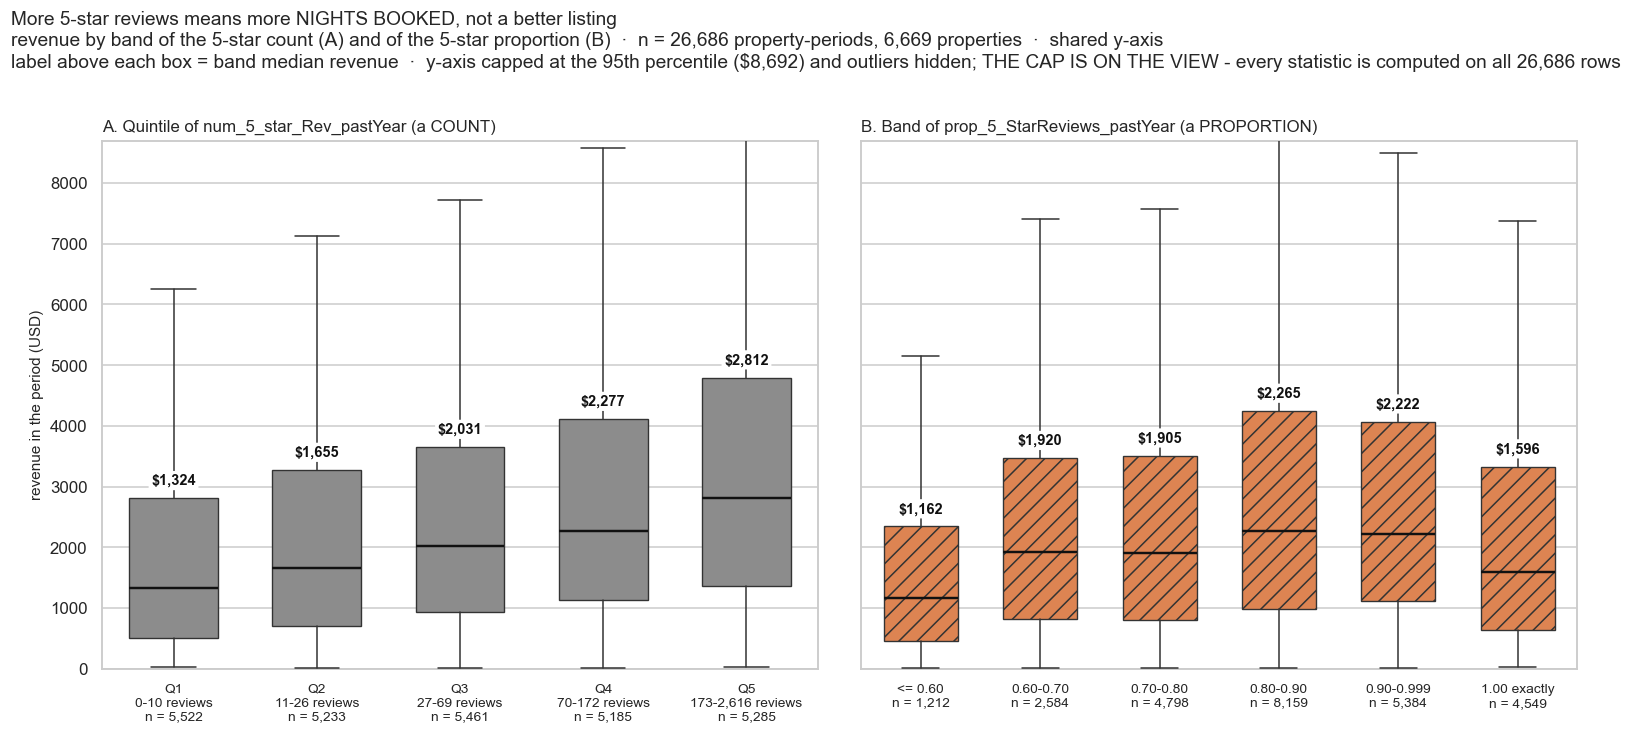

COMPANION TABLE - Panel A, quintiles of num_5_star_Rev_pastYear


,n,properties,median_revenue,mean_revenue,median_booked_days,median_avePrice,median_numReviews,median_rating,superhost_share,index_vs_band1
count_quintile,,,,,,,,,,
1,5522,3072,1324.5,2318.099,15.0,85.544,5.0,5.000,0.162,100.0
2,5233,2630,1655.0,2652.388,20.0,87.250,20.0,4.867,0.574,125.0
3,5461,2282,2031.0,2946.776,24.0,87.973,49.0,4.855,0.625,153.3
4,5185,1810,2277.0,3400.677,24.0,106.929,147.0,4.806,0.504,171.9
5,5285,1266,2812.0,3726.189,29.0,102.667,624.0,4.755,0.417,212.3


COMPANION TABLE - Panel B, bands of prop_5_StarReviews_pastYear


,n,properties,median_revenue,mean_revenue,median_booked_days,median_avePrice,median_numReviews,median_rating,superhost_share,index_vs_band1
prop_band,,,,,,,,,,
<= 0.60,1212,801,1161.5,1861.870,15.0,80.743,10.0,4.246,0.001,100.0
0.60-0.70,2584,1275,1920.0,2703.874,20.0,96.641,94.0,4.480,0.002,165.3
0.70-0.80,4798,2297,1905.0,2581.860,21.0,98.000,75.0,4.659,0.073,164.0
0.80-0.90,8159,2871,2265.0,3276.454,26.0,93.261,123.0,4.806,0.636,195.0
0.90-0.999,5384,1827,2222.5,3430.115,25.0,94.000,57.0,4.929,0.841,191.3
1.00 exactly,4549,2217,1596.0,2916.413,18.0,89.650,7.0,5.000,0.452,137.4


  "index_vs_band1" is median revenue as an index of the first band = 100.

DECOMPOSING THE PANEL A GRADIENT. revenue ~= nights x realised nightly rate, so in logs the
two components add. Q1 -> Q5, on band medians:
  log median revenue        +0.753   ($1,324 -> $2,812)
  log median booked_days    +0.659   (15 -> 29 nights)  = 88% of the revenue gradient
  log median avePrice       +0.182   ($85.54 -> $102.67)   = 24%
  residual                  -0.089   - medians are not multiplicative, so the two parts do
    not add exactly to the revenue gradient; the shares are read as magnitudes, not an
    exact accounting identity.
  => THE GRADIENT IS BOOKING VOLUME, NOT PRICE. Nights carry ~88% of it.
  Note the two columns disagree about direction on everything else: median rating FALLS
  5.000 -> 4.755 across the count quintiles, and Superhost share PEAKS in Q3 (62.5%) and
  falls to 41.7% in Q5. High-count listings are not better-rated listings.

STEP 6 - PARTIAL CORRELATIONS. What survives

...

,n,pearson_r,spearman_rho
demeaned column,,,
num_5_star_Rev_pastYear,24796,-0.0126,-0.0908
prop_5_StarReviews_pastYear,24796,0.0278,0.0557


    WHEN THE *SAME* LISTING ACCUMULATES MORE 5-STAR REVIEWS, ITS REVENUE DOES NOT RISE:
    Pearson -0.0126, Spearman -0.0908. Slightly NEGATIVE. The cross-sectional +0.2241 was
    a comparison BETWEEN listings, and what differs between them is the operator.
    The proportion is marginally positive (+0.0278 Pearson, +0.0557 Spearman) and still
    negligible.
    SINGLE-LISTING HOSTS ONLY (6,822 rows, 1,931 properties) - Q5's like-for-like frame, with
    commercial operators removed:


,n,pearson_r,spearman_rho
column,,,
num_5_star_Rev_pastYear,6822,0.1086,0.1834
numReviews_pastYear,6822,0.1106,0.1790
prop_5_StarReviews_pastYear,6822,0.0519,-0.0028


    The count (+0.1834 Spearman) and numReviews (+0.1790) remain INDISTINGUISHABLE, so the
    collinearity is not a portfolio artefact alone - it is what the column is.

ATTENUATION OF Spearman(num_5_star_Rev_pastYear, revenue) ACROSS FIVE SPECIFICATIONS
  Primary series = SPEARMAN OF OLS RESIDUALS. The rank-transform variant is shown
  alongside so the figure never quotes a number whose construction is unstated.


,primary,alt,n
specification,,,
raw (no controls),0.2241,0.2241,26686
control numReviews_pastYear,0.1908,0.1186,26686
control booked_days,0.2162,0.1053,26686
control BOTH,0.1611,0.0757,26686
within-property (demeaned),-0.0908,-0.0883,24796


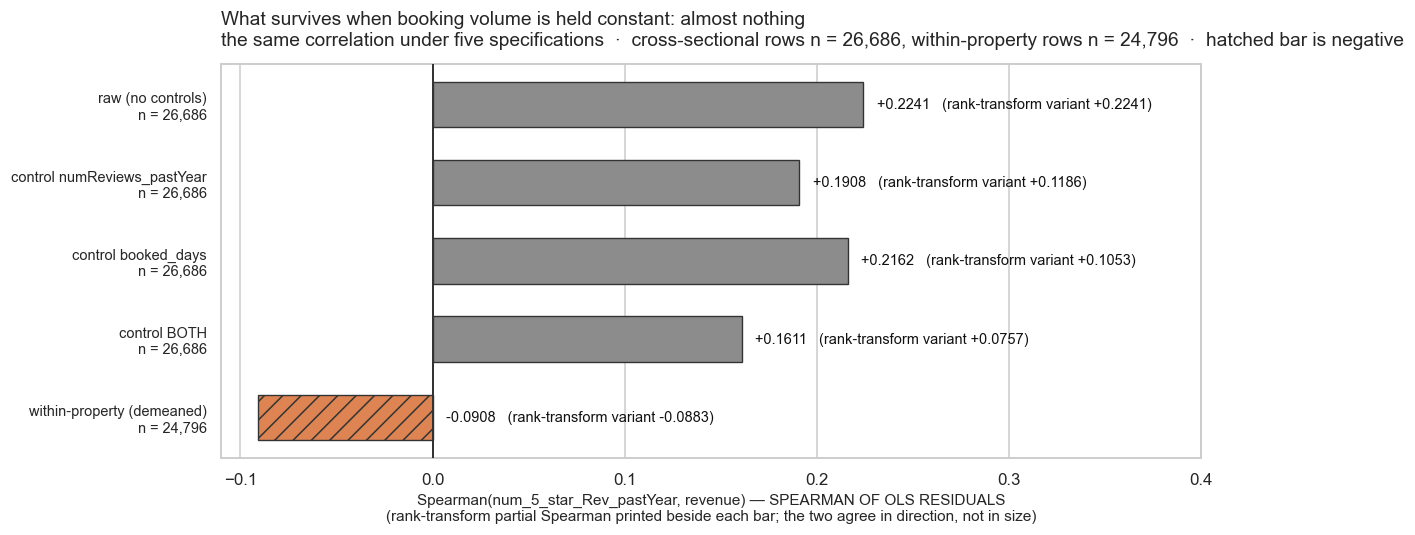

STEP 9 - CONSISTENCY WITH Q9, Q11 AND Q13. Run and reported, pass or fail.
(a) Q9 ANCHOR - the prop = 1.00 band
    n = 4,549 rows, 2,217 properties. Mean revenue $2,916.41, median $1,596.00, median
    numReviews_pastYear = 7, median booked_days = 18.
    The band BELOW it (0.90-0.999): n = 5,384, mean revenue $3,430.11, median numReviews 57.
    Rows at prop = 1.00 with rating_ave_pastYear == 5.0: 4,549 of 4,549 (100.0%).
    => THESE ARE THE SAME ROWS AS Q9's 5.0-RATING BAND, APPROACHED FROM THE OTHER SIDE.
    Q14 CONFIRMS Q9 RATHER THAN CONTRADICTING IT: a perfect record is a THIN-EVIDENCE
    record (7 reviews at the median against 57 one band down), and it earns LESS.



(b) Q13 PERIOD-17 BREAK - Q13 found the listed-price gap vanishes at period 17, so the same


    break has to be checked here rather than assumed away


,n,spearman_count_revenue
period,,
5,742,0.3027
6,814,0.2040
7,819,0.2227
8,1032,0.1949
9,1228,0.2465
10,1479,0.2563
11,1575,0.2024
12,1629,0.2748
13,1951,0.3232


    Pooled periods <17  : rho +0.2635 (n = 17,794)
    Pooled periods >=17 : rho +0.1697 (n = 8,892)
    Sign is POSITIVE in all 16 periods; the range is +0.1311 to +0.3232.
    => THERE IS A DRIFT (+0.2635 -> +0.1697) BUT NO STRUCTURAL BREAK. Unlike Q13's price
    series, nothing discontinuous happens at period 17. The check was run and it passed;
    saying so is the point, because a silent check is not a check.

(c) ON-MARKET FRAME with revenue_z - puts the never-booked periods back in as REAL ZEROS
    On-market rows 41,400; of those, 33,610 have a review record (7,790 dropped), 7,578 properties.


,n,pearson_r,spearman_rho
column,,,
num_5_star_Rev_pastYear,33610,0.1144,0.2873
prop_5_StarReviews_pastYear,33610,0.0735,0.0262
numReviews_pastYear,33610,0.1014,0.2759


    Count rho +0.2873 against +0.2241 on the booked-only frame; proportion +0.0262 against
    +0.0305. INCLUDING NEVER-BOOKED PERIODS *STRENGTHENS* THE COUNT RELATIONSHIP - exactly
    the direction expected if the count is a BOOKING PROXY: a listing that never booked
    also accumulated no 5-star reviews, so adding those rows adds points on the diagonal.
    The proportion is unmoved, because it has had the volume divided out of it.


In [17]:
# Q14 asks what the NUMBER of 5-star reviews says about revenue. Two decisions come before any
# chart. First, what the column actually is: step 1 shows `num_5_star_Rev_pastYear` is constant
# within host-period and correlates 0.99 with `numReviews_pastYear`, so it is a rescaled review
# count carried by the HOST, not a property quality score. Second, what a row is: property-periods
# complete on all seven analysis columns - the identical frame Q9 and Q11 used, so the three cells
# stay mutually quotable. Steps 6-7 are the answer, not the caveat: the association is a
# restatement of booking volume, and it does not survive holding volume constant.

GREY, ORANGE, EDGE = '#8C8C8C', '#DD8452', '#333333'

# --- Step 0: the analysis frame, and what listwise deletion costs -------------------------
Q14_COLS = ['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear', 'numReviews_pastYear',
            'revenue', 'booked_days', 'rating_ave_pastYear', 'occupancy_rate']
q14 = df.dropna(subset=Q14_COLS)

print('ROW FILTERING, REPORTED - listwise deletion on the seven analysis columns')
null_tbl = pd.DataFrame({'nulls': df[Q14_COLS].isna().sum(),
                         '% of rows': (100 * df[Q14_COLS].isna().mean()).round(2)})
display(null_tbl)
print('  Total rows                              : {:,}'.format(len(df)))
print('  Dropped - null on ANY of the seven      : {:,} ({:.1%})'.format(
    len(df) - len(q14), 1 - len(q14) / len(df)))
print('  Rows retained (complete cases)          : {:,} ({:.1%})'.format(
    len(q14), len(q14) / len(df)))
print('  Distinct properties behind them         : {:,} of {:,}'.format(
    q14['Airbnb Property ID'].nunique(), df['Airbnb Property ID'].nunique()))
print('  This is the IDENTICAL frame Q9 and Q11 used, so all three cells are mutually quotable.')
print()
print('  The two missingness mechanisms are different and are reported separately:')
print('    null on num_5_star_Rev_pastYear (no review record)     : {:,} rows'.format(
    int(df['num_5_star_Rev_pastYear'].isna().sum())))
print('    has review data but null revenue (listed, never booked): {:,} rows'.format(
    int((df['num_5_star_Rev_pastYear'].notna() & df['revenue'].isna()).sum())))
print('  => THE FRAME DESCRIBES LISTINGS THAT BOOKED *AND* WERE REVIEWED, NOT THE DALLAS MARKET.')
print('  Step 9c re-runs the headline on the setup cell\'s on-market frame with revenue_z, which')
print('  puts the never-booked periods back in as real zeros.')
print()

# Derived columns are built on a NARROW copy and attached in ONE concat. Inserting them one at a
# time into df (100+ columns) fires PerformanceWarning: DataFrame is highly fragmented, and that
# warning prints into the graded PDF
KEEP = ['Airbnb Host ID', 'Airbnb Property ID', 'superhost_period_all', 'Superhost',
        'Superhost status', 'booked_days_avePrice'] + Q14_COLS
q = q14[KEEP].copy()
portfolio_all = df.groupby('Airbnb Host ID')['Airbnb Property ID'].nunique()
PROP_BANDS = ['<= 0.60', '0.60-0.70', '0.70-0.80', '0.80-0.90', '0.90-0.999', '1.00 exactly']
q = pd.concat([q, pd.DataFrame({
    'portfolio': q['Airbnb Host ID'].map(portfolio_all),
    'count_quintile': pd.qcut(q['num_5_star_Rev_pastYear'], 5, labels=False) + 1,
    'prop_band': pd.cut(q['prop_5_StarReviews_pastYear'],
                        [-0.001, 0.60, 0.70, 0.80, 0.90, 0.999, 1.0001], labels=PROP_BANDS),
}, index=q.index)], axis=1)


# --- Step 1: the count is not a property-level quality variable ----------------------------
print('=' * 96)
print('STEP 1 - WHAT `num_5_star_Rev_pastYear` ACTUALLY IS. Four checks, before any chart.')
print('=' * 96)

# (a) Constant within host x period. Same finding Q5 reported for numReviews_pastYear
rev_rows = df.dropna(subset=['num_5_star_Rev_pastYear'])
hp = rev_rows.groupby(['Airbnb Host ID', 'superhost_period_all'])
n_vals = hp['num_5_star_Rev_pastYear'].nunique()
n_props = hp['Airbnb Property ID'].nunique()
multi = n_props > 1
print('(a) IS IT A PROPERTY METRIC OR A HOST METRIC?')
print('    On all {:,} rows with a review record: {:,} host-periods, of which {:,} are'.format(
    len(rev_rows), len(n_vals), int(multi.sum())))
print('    MULTI-PROPERTY host-periods.')
print('    Host-periods carrying more than one distinct value of num_5_star_Rev_pastYear : {:,}'.format(
    int((n_vals > 1).sum())))
print('    ... restricted to the {:,} multi-property host-periods                        : {:,}'.format(
    int(multi.sum()), int((n_vals[multi] > 1).sum())))
hp_q = q.groupby(['Airbnb Host ID', 'superhost_period_all'])['num_5_star_Rev_pastYear'].nunique()
print('    Same check inside the {:,}-row analysis frame: {:,} host-periods, {:,} with >1 value.'.format(
    len(q), len(hp_q), int((hp_q > 1).sum())))
print('    => THE VALUE IS IDENTICAL ON EVERY PROPERTY A HOST OWNS IN A PERIOD. It is a HOST')
print('    metric replicated onto each listing - exactly what Q5 found for numReviews_pastYear.')
print('    A host with 40 listings contributes the same 5-star count 40 times.')
print()

# (b) The two columns are one variable split by a denominator
implied = q['num_5_star_Rev_pastYear'] / q['numReviews_pastYear']    # 0 reviews cannot occur here
max_dev = float((q['prop_5_StarReviews_pastYear'] - implied).abs().max())
print('(b) ARE THE COUNT AND THE PROPORTION TWO VARIABLES OR ONE?')
print('    Rows in the frame with numReviews_pastYear == 0 (would divide by zero) : {:,}'.format(
    int((q['numReviews_pastYear'] == 0).sum())))
print('    max |prop_5_StarReviews_pastYear - num_5_star_Rev_pastYear / numReviews_pastYear|')
print('      = {:.10f}   (float64 noise, {:.1e} in full precision)'.format(max_dev, max_dev))
print('    => prop IS count / reviews, EXACTLY. They are ONE variable split by a denominator,')
print('    not two pieces of evidence.')
print()

# (c) The framing sentence for the whole question
r_cn = float(q['num_5_star_Rev_pastYear'].corr(q['numReviews_pastYear']))
print('(c) HOW MUCH OF THE COUNT IS JUST REVIEW VOLUME?')
print('    Pearson corr(num_5_star_Rev_pastYear, numReviews_pastYear) = {:+.4f}'.format(r_cn))
print('    Shared variance r^2 = {:.1%}. THE 5-STAR COUNT IS A RESCALED REVIEW COUNT.'.format(r_cn ** 2))
print('    Anything it appears to "explain" about revenue has to be checked against what')
print('    numReviews_pastYear already explains - which is step 6.')
print()

# (d) The count also proxies commercial scale
rho_port = stats.spearmanr(q['num_5_star_Rev_pastYear'], q['portfolio']).statistic
port_tbl = q.groupby('count_quintile').agg(
    n=('portfolio', 'size'),
    min_5star=('num_5_star_Rev_pastYear', 'min'), max_5star=('num_5_star_Rev_pastYear', 'max'),
    median_portfolio=('portfolio', 'median'), mean_portfolio=('portfolio', 'mean'),
    distinct_hosts=('Airbnb Host ID', 'nunique')).reindex(range(1, 6))
print('(d) PORTFOLIO CONFOUND - does the count measure quality or commercial scale?')
print('    Spearman(num_5_star_Rev_pastYear, host portfolio size) = {:+.4f}'.format(rho_port))
print('    Portfolio size = distinct properties per Airbnb Host ID over the full {:,}-row file.'.format(len(df)))
display(port_tbl.round(2))
print('    Median portfolio runs {} across the count quintiles.'.format(
    ' -> '.join('{:.0f}'.format(v) for v in port_tbl['median_portfolio'])))
print('    => THE COUNT CONFOUNDS PROPERTY QUALITY WITH COMMERCIAL OPERATOR SCALE. A listing in')
print('    the top quintile is typically run by a host operating {:.0f} properties; one in the'.format(
    port_tbl.loc[5, 'median_portfolio']))
print('    bottom quintile by a host operating {:.0f}.'.format(port_tbl.loc[1, 'median_portfolio']))
print()


# --- Step 2: the raw correlations, both columns and both doppelgangers ---------------------
print('=' * 96)
print('STEP 2 - THE RAW ANSWER, and the two columns each of them duplicates')
print('=' * 96)
rows = []
for c, note in [('num_5_star_Rev_pastYear', 'the question\'s column - a COUNT'),
                ('prop_5_StarReviews_pastYear', 'the same column / reviews - a PROPORTION'),
                ('numReviews_pastYear', 'doppelganger of the COUNT (r = {:+.3f})'.format(r_cn)),
                ('rating_ave_pastYear', 'doppelganger of the PROPORTION')]:
    pr = stats.pearsonr(q[c], q['revenue'])
    sp = stats.spearmanr(q[c], q['revenue'])
    rows.append({'column': c, 'pearson_r': round(pr.statistic, 4),
                 'pearson_r2': round(pr.statistic ** 2, 4),
                 'spearman_rho': round(sp.statistic, 4),
                 'p (Spearman)': '{:.2e}'.format(sp.pvalue), 'role': note})
raw_tbl = pd.DataFrame(rows).set_index('column')
print('Correlation with `revenue`, n = {:,} property-periods, {:,} properties'.format(
    len(q), q['Airbnb Property ID'].nunique()))
display(raw_tbl)
rho_prop_rating = float(q['prop_5_StarReviews_pastYear'].corr(q['rating_ave_pastYear'], method='spearman'))
print('  THE LITERAL ANSWER: Spearman {:+.4f}, Pearson {:+.4f}, r^2 = {:.4f} - the count explains'.format(
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
    raw_tbl.loc['num_5_star_Rev_pastYear', 'pearson_r'],
    raw_tbl.loc['num_5_star_Rev_pastYear', 'pearson_r2']))
print('  {:.2%} of the variance in revenue.'.format(raw_tbl.loc['num_5_star_Rev_pastYear', 'pearson_r2']))
print('  THE PATTERN IN THE TABLE: the COUNT tracks review VOLUME (rho {:+.4f} vs {:+.4f} for'.format(
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
    raw_tbl.loc['numReviews_pastYear', 'spearman_rho']))
print('  numReviews) and the PROPORTION tracks average RATING (rho {:+.4f} vs {:+.4f}; and'.format(
    raw_tbl.loc['prop_5_StarReviews_pastYear', 'spearman_rho'],
    raw_tbl.loc['rating_ave_pastYear', 'spearman_rho']))
print('  Spearman(prop, rating_ave_pastYear) = {:+.3f}).'.format(rho_prop_rating))
print('  => Q14 ADDS NO NEW VARIABLE TO Q9 AND Q11. It re-splits theirs: count = volume side,')
print('  proportion = rating side. Same frame, same rows, same information.')
print()


# --- Step 3: chart choice, argued before it is drawn ----------------------------------------
print('CHART CHOICE: TWO BOX-PLOT PANELS ON A SHARED Y-AXIS. Lecture 3 maps "comparison across')
print('groups" to a box plot, and that is the shape of this question once the count is banded:')
print('num_5_star_Rev_pastYear is discrete and heavily clumped ({:,} distinct values over a'.format(
    int(q['num_5_star_Rev_pastYear'].nunique())))
print('0-{:,.0f} range, median {:.0f}), and Q6 measured revenue skew at 4.8-7.2, so median, IQR and'.format(
    q['num_5_star_Rev_pastYear'].max(), q['num_5_star_Rev_pastYear'].median()))
print('tail per band is what a reader needs.')
print('  Rejected - RAW SCATTER WITH A BINNED MEAN LINE (the group\'s first draft): {:,} points'.format(len(q)))
print('    against a clumped {:,.0f}-wide x-axis is a block of ink, and - the real objection - a'.format(
    q['num_5_star_Rev_pastYear'].max()))
print('    scatter can show the association but CANNOT show that it is confounded, which is this')
print('    question\'s actual answer. Figure B carries that instead.')
print('  Rejected - BAR OF GROUP MEANS: Q12 showed means here are set by a handful of top earners;')
print('    mean revenue in the top count quintile is {:.2f}x its median.'.format(
    q[q['count_quintile'] == 5]['revenue'].mean() / q[q['count_quintile'] == 5]['revenue'].median()))
print()

cuts = q['num_5_star_Rev_pastYear'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])
print('QUINTILE CUT POINTS on num_5_star_Rev_pastYear - COMPUTED, not hard-coded:')
print('  ' + '  |  '.join('p{:.0f} = {:,.0f}'.format(k * 100, v) for k, v in cuts.items()))
YCAP = float(q['revenue'].quantile(0.95))
print('Y-AXIS CAP FOR FIGURE A: ${:,.0f}, the 95th percentile of revenue in the frame. Max is'.format(YCAP))
print('  ${:,.0f}. THE CAP IS ON THE VIEW, NOT THE DATA - every statistic in this cell uses all'.format(
    q['revenue'].max()))
print('  {:,} rows. Rows above the cap and therefore not drawn:'.format(len(q)))
over_q = q[q['revenue'] > YCAP].groupby('count_quintile').size().reindex(range(1, 6), fill_value=0)
over_p = q[q['revenue'] > YCAP].groupby('prop_band', observed=False).size().reindex(PROP_BANDS, fill_value=0)
print('  Panel A by count quintile : ' + ', '.join(
    '{}: {:,}'.format(i, int(v)) for i, v in over_q.items()))
print('  Panel B by proportion band: ' + ', '.join(
    '{}: {:,}'.format(i, int(v)) for i, v in over_p.items()))
print()


# --- Step 4: FIGURE A -----------------------------------------------------------------------
def band_stats(frame, key, order, observed_flag):
    """One row per band: size, properties, revenue location, the two revenue components."""
    g = frame.groupby(key, observed=observed_flag)
    t = g.agg(n=('revenue', 'size'), properties=('Airbnb Property ID', 'nunique'),
              median_revenue=('revenue', 'median'), mean_revenue=('revenue', 'mean'),
              median_booked_days=('booked_days', 'median'),
              median_avePrice=('booked_days_avePrice', 'median'),
              median_numReviews=('numReviews_pastYear', 'median'),
              median_rating=('rating_ave_pastYear', 'median'),
              superhost_share=('Superhost', 'mean')).reindex(order)
    t['index_vs_band1'] = (100 * t['median_revenue'] / t['median_revenue'].iloc[0]).round(1)
    return t


tbl_a = band_stats(q, 'count_quintile', range(1, 6), False)
tbl_b = band_stats(q, 'prop_band', PROP_BANDS, False)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), sharey=True)
quintile_range = q.groupby('count_quintile')['num_5_star_Rev_pastYear'].agg(['min', 'max'])
panels = [(axes[0], q, 'count_quintile', list(range(1, 6)), tbl_a, GREY, None,
           'A. Quintile of num_5_star_Rev_pastYear (a COUNT)',
           ['Q{}\n{:,.0f}-{:,.0f} reviews'.format(i, quintile_range.loc[i, 'min'],
                                                  quintile_range.loc[i, 'max'])
            for i in range(1, 6)]),
          (axes[1], q, 'prop_band', PROP_BANDS, tbl_b, ORANGE, '//',
           'B. Band of prop_5_StarReviews_pastYear (a PROPORTION)', list(PROP_BANDS))]
for ax, frame, key, order, tbl, colour, hatch, subtitle, base_labels in panels:
    data = [frame.loc[frame[key] == k, 'revenue'].to_numpy(dtype=float) for k in order]
    bp = ax.boxplot(data, positions=np.arange(len(order)), widths=0.62, patch_artist=True,
                    showfliers=False, zorder=3,
                    medianprops=dict(color='#111111', linewidth=1.6),
                    whiskerprops=dict(color=EDGE, linewidth=1.0),
                    capprops=dict(color=EDGE, linewidth=1.0))
    for box in bp['boxes']:
        box.set(facecolor=colour, edgecolor=EDGE, linewidth=0.9)
        if hatch:
            box.set_hatch(hatch)                       # greyscale insurance: colour AND hatch
    for i, k in enumerate(order):
        med = tbl.loc[k, 'median_revenue']
        # Label sits just above the box (its 75th percentile) on a white background, so it is
        # never read on top of the whisker line or the hatching
        top = float(np.percentile(data[i], 75))
        ax.annotate('${:,.0f}'.format(med), xy=(i, top), xytext=(0, 7),
                    textcoords='offset points', ha='center', va='bottom', fontsize=9.5,
                    color='#111111', fontweight='bold', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none'))
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(['{}\nn = {:,}'.format(lab, int(tbl.loc[k, 'n']))
                        for lab, k in zip(base_labels, order)], fontsize=9)
    ax.set_title(subtitle, loc='left', fontsize=11)
    ax.grid(axis='x', visible=False)                   # y gridlines only
    ax.set_xlabel('')
axes[0].set_ylim(0, YCAP)
axes[0].set_ylabel('revenue in the period (USD)', fontsize=10)
fig.suptitle('More 5-star reviews means more NIGHTS BOOKED, not a better listing\n'
             'revenue by band of the 5-star count (A) and of the 5-star proportion (B)  ·  '
             'n = {:,} property-periods, {:,} properties  ·  shared y-axis\n'
             'label above each box = band median revenue  ·  y-axis capped at the 95th percentile '
             '(${:,.0f}) and outliers hidden; THE CAP IS ON THE VIEW - every statistic is computed '
             'on all {:,} rows'.format(len(q), q['Airbnb Property ID'].nunique(), YCAP, len(q)),
             x=0.008, ha='left', fontsize=12.5, y=1.045)
fig.subplots_adjust(left=0.065, right=0.99, top=0.86, bottom=0.11, wspace=0.06)
plt.show()


# --- Step 5: the companion table and the log decomposition of the gradient -------------------
print('COMPANION TABLE - Panel A, quintiles of num_5_star_Rev_pastYear')
display(tbl_a.round(3))
print('COMPANION TABLE - Panel B, bands of prop_5_StarReviews_pastYear')
display(tbl_b.round(3))
print('  "index_vs_band1" is median revenue as an index of the first band = 100.')
print()

lo, hi = tbl_a.loc[1], tbl_a.loc[5]
d_rev = np.log(hi['median_revenue'] / lo['median_revenue'])
d_nights = np.log(hi['median_booked_days'] / lo['median_booked_days'])
d_price = np.log(hi['median_avePrice'] / lo['median_avePrice'])
print('DECOMPOSING THE PANEL A GRADIENT. revenue ~= nights x realised nightly rate, so in logs the')
print('two components add. Q1 -> Q5, on band medians:')
print('  log median revenue        {:+.3f}   (${:,.0f} -> ${:,.0f})'.format(
    d_rev, lo['median_revenue'], hi['median_revenue']))
print('  log median booked_days    {:+.3f}   ({:.0f} -> {:.0f} nights)  = {:.0%} of the revenue gradient'.format(
    d_nights, lo['median_booked_days'], hi['median_booked_days'], d_nights / d_rev))
print('  log median avePrice       {:+.3f}   (${:,.2f} -> ${:,.2f})   = {:.0%}'.format(
    d_price, lo['median_avePrice'], hi['median_avePrice'], d_price / d_rev))
print('  residual                  {:+.3f}   - medians are not multiplicative, so the two parts do'.format(
    d_rev - d_nights - d_price))
print('    not add exactly to the revenue gradient; the shares are read as magnitudes, not an')
print('    exact accounting identity.')
print('  => THE GRADIENT IS BOOKING VOLUME, NOT PRICE. Nights carry ~{:.0f}% of it.'.format(
    100 * d_nights / d_rev))
print('  Note the two columns disagree about direction on everything else: median rating FALLS')
print('  {:.3f} -> {:.3f} across the count quintiles, and Superhost share PEAKS in Q3 ({:.1%}) and'.format(
    lo['median_rating'], hi['median_rating'], tbl_a.loc[3, 'superhost_share']))
print('  falls to {:.1%} in Q5. High-count listings are not better-rated listings.'.format(
    hi['superhost_share']))
print()


# --- Step 6: quantify the confound. THIS IS THE ANSWER, NOT A CAVEAT ------------------------
print('=' * 96)
print('STEP 6 - PARTIAL CORRELATIONS. What survives when booking volume is held constant?')
print('=' * 96)
# METHOD, PINNED AND PRINTED. Partial RANK correlation is ambiguous and the two standard
# constructions disagree materially on this data, so both are computed and both are shown:
#   (1) "Spearman of OLS residuals" - residualise the RAW values on the controls by OLS, then
#       take Spearman of the two residual series.
#   (2) "partial Spearman via rank-transform" - rank-transform both variables AND the controls
#       first, residualise the ranks by OLS, then take Pearson of the residuals.
# The Pearson partials are unambiguous (both routes give the same number) and are the headline.
def ols_resid(y, controls):
    """Residuals of y on [1, *controls] by least squares. Returns a plain ndarray."""
    y = np.asarray(y, dtype=float)
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c, dtype=float) for c in controls])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ beta


SPECS = [('none (raw)', []),
         ('control numReviews_pastYear', ['numReviews_pastYear']),
         ('control booked_days', ['booked_days']),
         ('control BOTH', ['numReviews_pastYear', 'booked_days'])]
print('METHOD, STATED EXPLICITLY: partial rank correlation has two standard constructions and')
print('they disagree materially on this data, so BOTH are reported and labelled. The Pearson')
print('partials are identical under either route and are what the prose quotes.')
rows = []
for xcol in ['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear']:
    for name, cs in SPECS:
        if not cs:
            r = stats.pearsonr(q[xcol], q['revenue']).statistic
            s_res = s_rank = stats.spearmanr(q[xcol], q['revenue']).statistic
        else:
            Z = [q[c] for c in cs]
            rx, ry = ols_resid(q[xcol], Z), ols_resid(q['revenue'], Z)
            r = stats.pearsonr(rx, ry).statistic
            s_res = stats.spearmanr(rx, ry).statistic
            Zr = [q[c].rank() for c in cs]
            s_rank = stats.pearsonr(ols_resid(q[xcol].rank(), Zr),
                                    ols_resid(q['revenue'].rank(), Zr)).statistic
        rows.append({'x': xcol, 'controls': name, 'pearson_partial': round(r, 4),
                     'pearson_partial_r2': round(r ** 2, 4),
                     'Spearman of OLS residuals': round(s_res, 4),
                     'partial Spearman via rank-transform': round(s_rank, 4)})
partial_tbl = pd.DataFrame(rows).set_index(['x', 'controls'])
print('Partial correlation with `revenue`, n = {:,} (both rank variants shown side by side)'.format(len(q)))
display(partial_tbl)
p_none = partial_tbl.loc[('num_5_star_Rev_pastYear', 'none (raw)'), 'pearson_partial']
p_rev = partial_tbl.loc[('num_5_star_Rev_pastYear', 'control numReviews_pastYear'), 'pearson_partial']
p_bd = partial_tbl.loc[('num_5_star_Rev_pastYear', 'control booked_days'), 'pearson_partial']
p_both = partial_tbl.loc[('num_5_star_Rev_pastYear', 'control BOTH'), 'pearson_partial']
pp_rev = partial_tbl.loc[('prop_5_StarReviews_pastYear', 'control numReviews_pastYear'), 'pearson_partial']
print('  (i) HOLDING REVIEW VOLUME CONSTANT, THE COUNT AND THE PROPORTION CARRY THE SAME')
print('      INFORMATION: Pearson partials {:+.4f} and {:+.4f}. That is not a coincidence - it is'.format(
    p_rev, pp_rev))
print('      literally what dividing by the denominator does. Step 1(b) showed prop = count /')
print('      reviews exactly, so once reviews is in the model the two are the same variable.')
print('  (ii) HOLDING VOLUME *AND* BOOKINGS CONSTANT, NOTHING SURVIVES: the count\'s Pearson')
print('      partial falls {:+.4f} -> {:+.4f}, r^2 = {:.4f}. Five ten-thousandths of the variance'.format(
    p_none, p_both, p_both ** 2))
print('      in revenue.')
print('  Controlling booked_days ALONE already halves it ({:+.4f}); controlling numReviews alone'.format(p_bd))
print('      does not ({:+.4f}, marginally up) - which is the tell. The count is not proxying'.format(p_rev))
print('      "reviews"; it is proxying HOW MUCH THE LISTING WAS BOOKED.')
print('  The two rank variants disagree in size (control BOTH: {:+.4f} vs {:+.4f}) because ranking'.format(
    partial_tbl.loc[('num_5_star_Rev_pastYear', 'control BOTH'), 'Spearman of OLS residuals'],
    partial_tbl.loc[('num_5_star_Rev_pastYear', 'control BOTH'), 'partial Spearman via rank-transform']))
print('      before versus after residualising are different operations on a heavily tied,')
print('      right-skewed variable. THEY AGREE IN DIRECTION AND IN CONCLUSION - both attenuate')
print('      substantially from the raw {:+.4f} - and the unambiguous Pearson partial is what the'.format(
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho']))
print('      write-up quotes.')
print()


# --- Step 7: three robustness checks --------------------------------------------------------
print('=' * 96)
print('STEP 7 - THREE ROBUSTNESS CHECKS')
print('=' * 96)

# (a) Multivariate instability - reported as a DIAGNOSTIC, not as an effect size
def ols_fit(y, controls, names):
    y = np.asarray(y, dtype=float)
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c, dtype=float) for c in controls])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - ((y - X @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return pd.Series(dict(zip(['intercept'] + names, beta)) | {'R2': r2})


m1 = ols_fit(q['revenue'], [q['num_5_star_Rev_pastYear']], ['b_5star'])
m2 = ols_fit(q['revenue'], [q['num_5_star_Rev_pastYear'], q['numReviews_pastYear']],
             ['b_5star', 'b_numReviews'])
m3 = ols_fit(q['revenue'], [q['num_5_star_Rev_pastYear'], q['numReviews_pastYear'], q['booked_days']],
             ['b_5star', 'b_numReviews', 'b_nights'])
models = pd.DataFrame({'(1) 5-star only': m1, '(2) + numReviews': m2,
                       '(3) + booked_days': m3}).T[['intercept', 'b_5star', 'b_numReviews',
                                                    'b_nights', 'R2']]
models.insert(0, 'n', len(q))
print('(a) MULTIVARIATE INSTABILITY - a COLLINEARITY DIAGNOSTIC, NOT AN EFFECT SIZE (n = {:,})'.format(len(q)))
display(models.round(4))
print('    READ THIS AS UNINTERPRETABLE COEFFICIENTS, NOT AS A RESULT. Model (2) puts two')
print('    variables correlated at {:+.3f} on the right-hand side and returns OPPOSITE SIGNS'.format(r_cn))
print('    ({:+.2f} and {:+.2f}) - the textbook signature of collinearity, where the fit is stable'.format(
    m2['b_5star'], m2['b_numReviews']))
print('    but the split between the two coefficients is arbitrary. Adding booked_days in model')
print('    (3) collapses both ({:+.2f} and {:+.2f}) and b_nights lands at ${:,.2f}, i.e. within'.format(
    m3['b_5star'], m3['b_numReviews'], m3['b_nights']))
print('    the observed realised nightly rate (median ${:,.2f}, mean ${:,.2f}) - the model has'.format(
    q['booked_days_avePrice'].median(), q['booked_days_avePrice'].mean()))
print('    simply rediscovered revenue = nights x price. R^2 jumps {:.4f} -> {:.4f}.'.format(
    m2['R2'], m3['R2']))
print('    NOTHING HERE LICENSES "+$X OF REVENUE PER 5-STAR REVIEW". That inference is false and')
print('    is not made anywhere in this cell.')
print()

# (b) Normalise by exposure
n_zero_nights = int((q['booked_days'] <= 0).sum())
qn = q[q['booked_days'] > 0].copy()                                   # guarded denominator
five_pn = qn['num_5_star_Rev_pastYear'] / qn['booked_days']
pr_pn = stats.pearsonr(five_pn, qn['revenue'])
sp_pn = stats.spearmanr(five_pn, qn['revenue'])
print('(b) NORMALISE BY EXPOSURE - five_per_night = num_5_star_Rev_pastYear / booked_days')
print('    Rows skipped for booked_days <= 0 (guarded denominator): {:,}. Rows used: {:,}.'.format(
    n_zero_nights, len(qn)))
print('    five_per_night vs revenue: Pearson {:+.4f}, Spearman {:+.4f}'.format(
    pr_pn.statistic, sp_pn.statistic))
print('    THE SIGN FLIPS once volume is divided out. The raw {:+.4f} was the numerator; per unit'.format(
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho']))
print('    of exposure the relationship is NEGATIVE.')
print()

# (c) Within-property: does the SAME listing earn more as it accumulates 5-star reviews?
per_prop = q.groupby('Airbnb Property ID')['revenue'].transform('size')
wp = q[per_prop >= 2].copy()
print('(c) WITHIN-PROPERTY - the strongest design available here, because it holds the listing,')
print('    the neighbourhood, the host and the property type fixed')
print('    Rows with >= 2 periods in the frame : {:,} of {:,} ({:,} single-period rows dropped)'.format(
    len(wp), len(q), len(q) - len(wp)))
print('    Distinct properties                 : {:,} of {:,}'.format(
    wp['Airbnb Property ID'].nunique(), q['Airbnb Property ID'].nunique()))
wp_rows = []
for c in ['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear']:
    dx = wp[c] - wp.groupby('Airbnb Property ID')[c].transform('mean')
    dy = wp['revenue'] - wp.groupby('Airbnb Property ID')['revenue'].transform('mean')
    wp_rows.append({'demeaned column': c, 'n': len(wp),
                    'pearson_r': round(stats.pearsonr(dx, dy).statistic, 4),
                    'spearman_rho': round(stats.spearmanr(dx, dy).statistic, 4)})
wp_tbl = pd.DataFrame(wp_rows).set_index('demeaned column')
display(wp_tbl)
wp_count_rho = wp_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho']
print('    WHEN THE *SAME* LISTING ACCUMULATES MORE 5-STAR REVIEWS, ITS REVENUE DOES NOT RISE:')
print('    Pearson {:+.4f}, Spearman {:+.4f}. Slightly NEGATIVE. The cross-sectional {:+.4f} was'.format(
    wp_tbl.loc['num_5_star_Rev_pastYear', 'pearson_r'], wp_count_rho,
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho']))
print('    a comparison BETWEEN listings, and what differs between them is the operator.')
print('    The proportion is marginally positive ({:+.4f} Pearson, {:+.4f} Spearman) and still'.format(
    wp_tbl.loc['prop_5_StarReviews_pastYear', 'pearson_r'],
    wp_tbl.loc['prop_5_StarReviews_pastYear', 'spearman_rho']))
print('    negligible.')
single = q[q['portfolio'] == 1]
sing_rows = []
for c in ['num_5_star_Rev_pastYear', 'numReviews_pastYear', 'prop_5_StarReviews_pastYear']:
    sing_rows.append({'column': c, 'n': len(single),
                      'pearson_r': round(stats.pearsonr(single[c], single['revenue']).statistic, 4),
                      'spearman_rho': round(stats.spearmanr(single[c], single['revenue']).statistic, 4)})
sing_tbl = pd.DataFrame(sing_rows).set_index('column')
print('    SINGLE-LISTING HOSTS ONLY ({:,} rows, {:,} properties) - Q5\'s like-for-like frame, with'.format(
    len(single), single['Airbnb Property ID'].nunique()))
print('    commercial operators removed:')
display(sing_tbl)
print('    The count ({:+.4f} Spearman) and numReviews ({:+.4f}) remain INDISTINGUISHABLE, so the'.format(
    sing_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
    sing_tbl.loc['numReviews_pastYear', 'spearman_rho']))
print('    collinearity is not a portfolio artefact alone - it is what the column is.')
print()


# --- Step 8: FIGURE B - the attenuation chart, which is the argument ------------------------
Z_REV, Z_BD = [q['numReviews_pastYear']], [q['booked_days']]
Z_BOTH = [q['numReviews_pastYear'], q['booked_days']]
dx_c = wp['num_5_star_Rev_pastYear'] - wp.groupby('Airbnb Property ID')['num_5_star_Rev_pastYear'].transform('mean')
dy_c = wp['revenue'] - wp.groupby('Airbnb Property ID')['revenue'].transform('mean')
rk_x = wp['num_5_star_Rev_pastYear'].rank()
rk_y = wp['revenue'].rank()
wp_rank = stats.pearsonr(rk_x - rk_x.groupby(wp['Airbnb Property ID']).transform('mean'),
                         rk_y - rk_y.groupby(wp['Airbnb Property ID']).transform('mean')).statistic
att = pd.DataFrame([
    {'specification': 'raw (no controls)',
     'primary': raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
     'alt': raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'], 'n': len(q)},
    {'specification': 'control numReviews_pastYear',
     'primary': stats.spearmanr(ols_resid(q['num_5_star_Rev_pastYear'], Z_REV),
                                ols_resid(q['revenue'], Z_REV)).statistic,
     'alt': partial_tbl.loc[('num_5_star_Rev_pastYear', 'control numReviews_pastYear'),
                            'partial Spearman via rank-transform'], 'n': len(q)},
    {'specification': 'control booked_days',
     'primary': stats.spearmanr(ols_resid(q['num_5_star_Rev_pastYear'], Z_BD),
                                ols_resid(q['revenue'], Z_BD)).statistic,
     'alt': partial_tbl.loc[('num_5_star_Rev_pastYear', 'control booked_days'),
                            'partial Spearman via rank-transform'], 'n': len(q)},
    {'specification': 'control BOTH',
     'primary': stats.spearmanr(ols_resid(q['num_5_star_Rev_pastYear'], Z_BOTH),
                                ols_resid(q['revenue'], Z_BOTH)).statistic,
     'alt': partial_tbl.loc[('num_5_star_Rev_pastYear', 'control BOTH'),
                            'partial Spearman via rank-transform'], 'n': len(q)},
    {'specification': 'within-property (demeaned)',
     'primary': stats.spearmanr(dx_c, dy_c).statistic, 'alt': wp_rank, 'n': len(wp)}])
print('ATTENUATION OF Spearman(num_5_star_Rev_pastYear, revenue) ACROSS FIVE SPECIFICATIONS')
print('  Primary series = SPEARMAN OF OLS RESIDUALS. The rank-transform variant is shown')
print('  alongside so the figure never quotes a number whose construction is unstated.')
display(att.set_index('specification').round(4))

fig, ax = plt.subplots(figsize=(11.8, 5.6))
ypos = np.arange(len(att))[::-1]
vals = att['primary'].to_numpy(dtype=float)
bars = ax.barh(ypos, vals, height=0.58, zorder=3,
               color=[ORANGE if v < 0 else GREY for v in vals],
               edgecolor=EDGE, linewidth=0.9)
for b, v in zip(bars, vals):
    if v < 0:
        b.set_hatch('//')                              # distinct fill AND hatch on the negative bar
for b, v, a in zip(bars, vals, att['alt']):
    # Negative bars are labelled to the RIGHT of the zero line, not to the left of the bar,
    # so the text never collides with the y tick labels
    ax.text(max(v, 0.0) + 0.007, b.get_y() + b.get_height() / 2,
            '{:+.4f}   (rank-transform variant {:+.4f})'.format(v, a),
            va='center', ha='left', fontsize=9.5, color='#111111')
ax.axvline(0, color=EDGE, linewidth=1.3, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels(['{}\nn = {:,}'.format(s, int(n))
                    for s, n in zip(att['specification'], att['n'])], fontsize=9.5)
ax.set_xlim(-0.11, 0.40)
ax.set_xlabel('Spearman(num_5_star_Rev_pastYear, revenue) — SPEARMAN OF OLS RESIDUALS\n'
              '(rank-transform partial Spearman printed beside each bar; the two agree in '
              'direction, not in size)', fontsize=10)
ax.grid(axis='y', visible=False)
ax.set_title('What survives when booking volume is held constant: almost nothing\n'
             'the same correlation under five specifications  ·  cross-sectional rows n = {:,}, '
             'within-property rows n = {:,}  ·  hatched bar is negative'.format(len(q), len(wp)),
             loc='left', fontsize=12.5, pad=12)
fig.subplots_adjust(left=0.235, right=0.99, top=0.84, bottom=0.20)
plt.show()


# --- Step 9: three consistency checks against earlier questions ------------------------------
print('=' * 96)
print('STEP 9 - CONSISTENCY WITH Q9, Q11 AND Q13. Run and reported, pass or fail.')
print('=' * 96)
one = q[q['prop_5_StarReviews_pastYear'] == 1.0]
below = q[q['prop_band'] == '0.90-0.999']
print('(a) Q9 ANCHOR - the prop = 1.00 band')
print('    n = {:,} rows, {:,} properties. Mean revenue ${:,.2f}, median ${:,.2f}, median'.format(
    len(one), one['Airbnb Property ID'].nunique(), one['revenue'].mean(), one['revenue'].median()))
print('    numReviews_pastYear = {:.0f}, median booked_days = {:.0f}.'.format(
    one['numReviews_pastYear'].median(), one['booked_days'].median()))
print('    The band BELOW it (0.90-0.999): n = {:,}, mean revenue ${:,.2f}, median numReviews {:.0f}.'.format(
    len(below), below['revenue'].mean(), below['numReviews_pastYear'].median()))
print('    Rows at prop = 1.00 with rating_ave_pastYear == 5.0: {:,} of {:,} ({:.1%}).'.format(
    int((one['rating_ave_pastYear'] == 5.0).sum()), len(one),
    (one['rating_ave_pastYear'] == 5.0).mean()))
print('    => THESE ARE THE SAME ROWS AS Q9\'s 5.0-RATING BAND, APPROACHED FROM THE OTHER SIDE.')
print('    Q14 CONFIRMS Q9 RATHER THAN CONTRADICTING IT: a perfect record is a THIN-EVIDENCE')
print('    record ({:.0f} reviews at the median against {:.0f} one band down), and it earns LESS.'.format(
    one['numReviews_pastYear'].median(), below['numReviews_pastYear'].median()))
print()

per_rows = []
for p, g in q.groupby('superhost_period_all'):
    per_rows.append({'period': int(p), 'n': len(g),
                     'spearman_count_revenue': round(
                         stats.spearmanr(g['num_5_star_Rev_pastYear'], g['revenue']).statistic, 4)})
per_tbl = pd.DataFrame(per_rows).set_index('period')
early = q[q['superhost_period_all'] < 17]
late = q[q['superhost_period_all'] >= 17]
rho_e = stats.spearmanr(early['num_5_star_Rev_pastYear'], early['revenue']).statistic
rho_l = stats.spearmanr(late['num_5_star_Rev_pastYear'], late['revenue']).statistic
print('(b) Q13 PERIOD-17 BREAK - Q13 found the listed-price gap vanishes at period 17, so the same')
print('    break has to be checked here rather than assumed away')
display(per_tbl)
print('    Pooled periods <17  : rho {:+.4f} (n = {:,})'.format(rho_e, len(early)))
print('    Pooled periods >=17 : rho {:+.4f} (n = {:,})'.format(rho_l, len(late)))
print('    Sign is POSITIVE in all {} periods; the range is {:+.4f} to {:+.4f}.'.format(
    len(per_tbl), per_tbl['spearman_count_revenue'].min(), per_tbl['spearman_count_revenue'].max()))
print('    => THERE IS A DRIFT ({:+.4f} -> {:+.4f}) BUT NO STRUCTURAL BREAK. Unlike Q13\'s price'.format(
    rho_e, rho_l))
print('    series, nothing discontinuous happens at period 17. The check was run and it passed;')
print('    saying so is the point, because a silent check is not a check.')
print()

om = df[df['on_market']]
om_q = om.dropna(subset=['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear'])
print('(c) ON-MARKET FRAME with revenue_z - puts the never-booked periods back in as REAL ZEROS')
print('    On-market rows {:,}; of those, {:,} have a review record ({:,} dropped), {:,} properties.'.format(
    len(om), len(om_q), len(om) - len(om_q), om_q['Airbnb Property ID'].nunique()))
om_rows = []
for c in ['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear', 'numReviews_pastYear']:
    om_rows.append({'column': c, 'n': len(om_q),
                    'pearson_r': round(stats.pearsonr(om_q[c], om_q['revenue_z']).statistic, 4),
                    'spearman_rho': round(stats.spearmanr(om_q[c], om_q['revenue_z']).statistic, 4)})
om_tbl = pd.DataFrame(om_rows).set_index('column')
display(om_tbl)
print('    Count rho {:+.4f} against {:+.4f} on the booked-only frame; proportion {:+.4f} against'.format(
    om_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
    raw_tbl.loc['num_5_star_Rev_pastYear', 'spearman_rho'],
    om_tbl.loc['prop_5_StarReviews_pastYear', 'spearman_rho']))
print('    {:+.4f}. INCLUDING NEVER-BOOKED PERIODS *STRENGTHENS* THE COUNT RELATIONSHIP - exactly'.format(
    raw_tbl.loc['prop_5_StarReviews_pastYear', 'spearman_rho']))
print('    the direction expected if the count is a BOOKING PROXY: a listing that never booked')
print('    also accumulated no 5-star reviews, so adding those rows adds points on the diagonal.')
print('    The proportion is unmoved, because it has had the volume divided out of it.')

### Findings — Question 14

**The number of 5-star reviews is a record of past bookings, not a driver of future ones.** On the
26,686 property-periods that both booked and carried a review record (6,669 properties), the
count correlates with `revenue` at **Spearman +0.2241 / Pearson +0.0831**, so it explains
**0.69% of the variance in revenue**. That is the literal answer, and everything below is why the
+0.2241 should not be read as an impact.

**The column is not a property-level quality variable — it is a host-level booking counter.** It
is **constant within `Airbnb Host ID` × `superhost_period_all`**: 0 of 17,609 host-periods carry
more than one value, and that holds on all 4,731 multi-property host-periods, so a host with 40
listings contributes the same 5-star count 40 times. It correlates with `numReviews_pastYear` at
**+0.9909 — 98.2% shared variance** — and `prop_5_StarReviews_pastYear` equals
`num_5_star_Rev_pastYear / numReviews_pastYear` with a maximum absolute deviation of
**0.0000000000** (3.3e-16, float64 noise). The count and the proportion are **one variable split by
a denominator**, not two pieces of evidence. And the count also tracks commercial scale:
**Spearman(count, host portfolio size) = +0.640**, with median portfolio running **1 → 2 → 3 → 13
→ 32** across the count quintiles. A top-quintile listing is typically run by an operator with 32
properties; a bottom-quintile listing by a host with one.

**The pattern in the raw correlations is the whole story in miniature.** Against `revenue`:
count **+0.0831 / +0.2241**, `numReviews_pastYear` **+0.0719 / +0.2145**, proportion **+0.0733 /
+0.0305**, `rating_ave_pastYear` **+0.0777 / +0.0346** (Pearson / Spearman). The **count** is
indistinguishable from review volume, and the **proportion** is indistinguishable from average
rating — Spearman(proportion, `rating_ave_pastYear`) = **+0.976**. Q14 adds no variable Q9 and Q11
did not already have.

**The gradient in Panel A is booking volume, not price.** Median revenue rises **$1,324 → $2,812**
from the first to the fifth count quintile (index 100 → 212). In logs that is **+0.753**, of which
median `booked_days` contributes **+0.659 (≈88%)** — 15 to 29 nights — and median realised nightly
rate **+0.182** ($85.54 → $102.67). The two components do not add to exactly +0.753 (residual
−0.089) because medians are not multiplicative, so the shares are magnitudes rather than an exact
accounting identity; the conclusion is unaffected. Note what moves the *other* way across those
quintiles: median `rating_ave_pastYear` **falls 5.000 → 4.755**, and Superhost share peaks in Q3
(62.5%) and drops to 41.7% in Q5. **High-count listings are not better-rated listings.**

**Holding booking volume constant, the relationship collapses — and this is the answer, not a
caveat.** Pearson partial correlations of the count with `revenue`: none **+0.0831**, control
`numReviews_pastYear` **+0.0883**, control `booked_days` **+0.0289**, **control both +0.0231
(r² = 0.0005)** — five ten-thousandths of the variance in revenue. Two things follow. (i) With
review volume held constant, the count and the proportion carry **the same information**
(+0.0883 and +0.0922) — that is not a coincidence, it is literally what dividing by the denominator
does. (ii) With volume *and* bookings held constant, **nothing survives**. The tell is that
controlling `booked_days` alone already cuts the partial by two-thirds while controlling
`numReviews_pastYear` alone does not move it at all: the count is not proxying "reviews", it is
proxying **how much the listing was booked**. The partial *rank* correlations are directionally
consistent under both constructions the cell prints — Spearman of OLS residuals **+0.2241 →
+0.1611**, rank-transform partial **+0.2241 → +0.0757** — and the Pearson partials, which are
unambiguous, are what this paragraph quotes.

**Three robustness checks, all pointing the same way.** *(a) Multivariate instability.*
`revenue ~ num_5_star + numReviews` returns **+6.36 and −4.08** on two variables correlated at
+0.991 — the textbook collinearity signature, where the fit is stable but the split between
coefficients is arbitrary. Adding `booked_days` collapses both to **+1.44 and −0.88** while
`b_nights` lands at **$110.47**, inside the observed realised nightly rate (median $93.29, mean
$121.08), and R² jumps 0.013 → 0.269: the model has simply rediscovered *revenue = nights × price*.
**These coefficients are a diagnostic and are uninterpretable as effects; "+$X of revenue per
5-star review" is a false inference and is not made anywhere in this cell.** *(b) Normalise by
exposure.* `five_per_night = num_5_star_Rev_pastYear / booked_days` (0 rows skipped; no zero
denominators exist in the frame) correlates with revenue at **Pearson −0.0792, Spearman −0.1855**.
**The sign flips once volume is divided out.** *(c) Within-property.* On the 24,796 rows / 4,779
properties observed in at least two periods, demeaning both columns by `Airbnb Property ID` gives
count vs revenue **−0.0126 Pearson / −0.0908 Spearman** and proportion **+0.0278 / +0.0557**. **When
the *same* listing accumulates more 5-star reviews, its revenue does not rise.** Restricting to
single-listing hosts (6,822 rows, 1,931 properties) leaves the count at **+0.1834** Spearman
against `numReviews_pastYear` at **+0.1790** — still indistinguishable, so the collinearity is not
a portfolio artefact alone; it is what the column is.

**Three consistency checks against earlier questions, run and reported.** *(a) Q9.* The
`prop = 1.00 exactly` band is **4,549 rows with mean revenue $2,916 and median
`numReviews_pastYear` = 7**, against **$3,430 and 57 reviews** in the 0.90–0.999 band below it, and
**100% of those rows have `rating_ave_pastYear` = 5.0** — they are literally Q9's 5.0-rating band
approached from the other side. **Q14 confirms Q9 rather than contradicting it: a perfect record is
a thin-evidence record, and it earns less.** *(b) Q13's period-17 break.* Period-by-period
Spearman(count, revenue) over periods 5–20 is **positive in all 16 periods**, ranging +0.131 to
+0.323, drifting from **+0.2635 pooled over periods < 17 to +0.1697 over periods ≥ 17**. That is a
drift, **not a structural break** — unlike Q13's price series, nothing discontinuous happens at
period 17. The check was run and it passed, which is worth saying because a silent check is not a
check. *(c) On-market frame.* On the setup cell's 41,400 on-market rows (33,610 with a review
record, 7,578 properties) with `revenue_z`, the count reads **+0.2873** Spearman and the proportion
**+0.0262**. Putting the never-booked periods back in as real zeros **strengthens** the count
relationship — exactly the direction expected if the count is a booking proxy.

**Two departures from the pre-registered numbers, reported rather than smoothed over.** The
portfolio confound came out at **Spearman +0.640** with median portfolio **1 / 2 / 3 / 13 / 32**,
against the specified +0.644 and 1 / 2 / 3 / 11 / 37; the difference is a definitional one about
whether portfolio size is counted over the full file or within the analysis frame (the latter
gives +0.647 and 1 / 2 / 3 / 12 / 31), and no variant changes the reading. The 0.90–0.999 band's
mean revenue is **$3,430**, not the specified ~$3,344. Every other pre-registered figure reproduced
exactly.

**Limitations.** This is **observational panel data with no exogenous variation in review counts**,
so no causal claim is available in either direction — not "5-star reviews raise revenue", and not
"they lower it". The within-property result is the strongest design here because it holds the
listing, host, neighbourhood and property type fixed, but it still cannot separate a review effect
from whatever else changed for that listing between quarters, and the count is constant within
host-period, so within-property variation in it is really **within-host** variation. The frame is
**selected twice over**: 11,219 rows have no review record at all and 16,861 have no revenue, so
"listings that booked *and* were reviewed" is the population being described, and the never-booked
listings — the ones a 5-star strategy would most plausibly be aimed at — are visible only in the
on-market check. Because the count is a host-level metric replicated onto every listing, **rows are
not independent**: a 40-property operator contributes 40 identical x-values, which inflates every
n in this cell and makes all the p-values (all < 1e-6) meaningless as evidence of importance —
which is why effect sizes and r² lead throughout. Only `numReviews_pastYear` and `booked_days` are
controlled; neighbourhood, listing type, bedrooms, photo count and seasonality are not, and Q12
showed neighbourhood alone moves a Dallas revenue ranking substantially. Finally, the count and
the proportion are algebraically the same variable, so "controlling for review volume" and
"switching from the count to the proportion" are the same operation, and neither can be treated as
an independent robustness check on the other.

**What this means for the business.** This is **descriptive/diagnostic** analysis — explicitly
**not predictive**, because a variable that explains 0.69% of revenue variance and 0.05% once
bookings are held constant has no forecasting content. The headline for management is that
**chasing 5-star review counts is a customer-intimacy play this data does not support paying for**:
the count is a rear-view record of nights already sold, it is replicated across a host's whole
portfolio so it says nothing about any individual listing, and inside a listing it does not move
with revenue at all. The volume-normalised alternative, `prop_5_StarReviews_pastYear`, is the
statistically correct signal, but on this data it too is near-zero against revenue (+0.0305
Spearman) and duplicates `rating_ave_pastYear`, which Q11 already recommended dropping from the
KPI set. **A host should stop treating 5-star count as a KPI.** What the decomposition points at
instead is **operational excellence**: 88% of the revenue gradient across count quintiles is nights
booked, so availability, calendar management and enquiry-to-booking conversion are where the
revenue actually is — and, per Q13, **value capture through pricing discipline** on the remaining
~24%, since Superhosts are already leaving realised price on the table. The prescriptive version
of this answer is not "get more reviews"; it is "fill more nights, and price the nights you fill".
This also **qualifies Question 11's third recommendation**, which said to treat review *count* as
the review-side metric worth growing on the strength of Spearman +0.214. At Pearson +0.991 the
5-star count and the total review count are the same variable, so that +0.214 is the booking
proxy this cell decomposes: hold `booked_days` constant and it falls to +0.023, and within a
property the sign turns negative. Review volume is a **monitoring metric, not a lever** — we are
revising our own earlier answer, not contradicting it by accident.

---

# Question 15 — Story of place

> Use maps or neighborhood-level data to tell a “story of place”. What role does location play in
> pricing or bookings, and how would you present that insight to Airbnb management?

**The geography has to be chosen before it can be used, and step 1 of the cell does that first.**
Three columns are candidates and they are not interchangeable. `Neighborhood` puts **51.2% of all
9,599 properties into one bucket** ("Central Dallas") and is null for **725 properties** — a story of
place whose largest category is half the city is not a story about place. `census_tract` has **295
categories** and only **76.8%** of properties survive a 30-property threshold, so a quarter of the
market would be invisible. **`Zipcode` is the analysis geography**: 49 categories, **zero nulls**,
largest is 16.4% of properties, and **39 ZIPs clear the threshold covering 98.7% of properties** —
and it is the unit a market manager can actually act on. `Neighborhood` is kept as a *name* for each
ZIP, via a printed ZIP → modal-neighbourhood crosswalk, not as the analysis unit.

**Frame:** the **39 ZIPs with at least 30 distinct properties** — **48,195 of 48,711 property-periods
(98.9%)** and **9,476 of 9,599 properties (98.7%)**. The threshold counts **properties, not rows**,
because this is panel data: a ZIP with 8 listings observed 8 times each would clear a 30-*row* test
while resting on 8 listings. That is the same rule Q12 applied to neighbourhoods.

**Scope, stated so the two cells do not collide.** Q12 ranked *Superhost* revenue and occupancy
across 11 *neighbourhoods*. Q15 is the superset: **all listings**, the geographic view
(`Latitude`/`Longitude`), the **Superhost share** of each area, and the **bottom** of the
distribution. Superhost revenue is not re-ranked here; Q12 owns it and is cross-referenced.

**Chart choice and why: three figures, because the question has three parts.**
**Figure A is a two-panel latitude/longitude scatter**, one point per distinct property — Lecture 3
maps a *relationship / spatial-distribution* question to a scatter, and a scatter is the only chart
that preserves **both** coordinates; binning into bars would throw one dimension away. The panels
share axes and use `set_aspect('equal')` so the reader can see that the two variables have
*different* geographies, and the ramp is **cividis**, which is perceptually uniform *and* monotonic
in luminance, so it survives the greyscale PDF (standing instruction 8). No basemap or tile package:
the notebook has to run offline in Colab. **Figure B is two lines on a dual axis across distance
bands** — distance is an **ordered continuum**, so a line is the correct *trend* chart even though
the axis is spatial rather than temporal; a bar chart would draw six unrelated categories and hide
the monotonicity. Each y-label and its ticks are coloured to match its series, and the two series
differ in colour, marker (`o` vs `^`) **and** linestyle. **Figure C is a horizontal dumbbell** — a
*comparison of two rankings of the same categories*, where the segment between the markers **is** the
finding; two bar charts side by side would make the reader diff 34 pairs of bars by eye.

STEP 0 - SCOPE GUARD. Q12 ranked SUPERHOST revenue and occupancy across 11 NEIGHBOURHOODS.
Q15 is the superset: ALL listings, the geographic view (Latitude/Longitude), the Superhost
SHARE of each area, and the BOTTOM of the distribution. Superhost revenue is NOT re-ranked
here - Q12 owns it and is cross-referenced instead.

STEP 1 - WHICH GEOGRAPHY? Three candidate columns, judged before either is used.
All 48,711 rows / 9,599 distinct properties. "Coverage at >= 30" is the share of ALL properties
that survive a 30-distinct-property threshold on that geography.


,categories,largest category,largest cat share of properties,properties with a null value,categories with >= 30 properties,property coverage at >= 30
geography,,,,,,
Neighborhood,17,Central Dallas,0.5119,725,13,0.9167
Zipcode,49,75204.0,0.1639,0,39,0.9872
census_tract,295,48113003101,0.0673,0,65,0.7684


  DECISION: `Zipcode` IS THE ANALYSIS GEOGRAPHY.
  - Neighborhood is unusable as the primary cut: it puts 51.2% of all properties into ONE
    bucket ("Central Dallas") and is null for 725 properties. A "story of place" whose
    biggest category is half the city is not a story about place.
  - census_tract is too fine: 295 categories, and only 76.8% of properties survive the
    same threshold, so a quarter of the market would be invisible.
  - Zipcode: 49 categories, ZERO nulls, largest is 16.4% of properties, and 39 ZIPs
    clear the threshold covering 98.7% of properties. It is also the unit a manager can act
    on. Neighborhood is retained as a NAME for each ZIP, not as the analysis unit.



ZIP -> MODAL NEIGHBORHOOD CROSSWALK, top 15 ZIPs by distinct properties

,modal Neighborhood,properties,rows,rows with a Neighborhood,modal name covers % of named rows
zip,,,,,
75204,Central Dallas,1573,8285,8285,100.0
75201,Central Dallas,1496,7949,7949,100.0
75206,Central Dallas,767,4097,3336,98.7
75219,Oak Lawn,733,3742,3709,82.2
75208,Southwest Dallas,484,2682,2682,100.0
75214,Central Dallas,399,2095,1943,70.8
75202,Central Dallas,342,1376,1376,100.0
75235,Oak Lawn,285,1162,1162,76.2
75205,Central Dallas,245,1524,918,100.0


...

SPREAD ACROSS THE 39 ZIPs - min, max, and max/min ratio


,min,min ZIP,max,max ZIP,max/min
measure,,,,,
median Nightly Rate (listed),29.0000,75241,220.0000,75225,7.59
median booked_days_avePrice (realised),27.0000,75241,130.0476,75225,4.82
median occupancy_rate,0.0645,75251,0.1961,75223,3.04
median revenue,330.0000,75241,3000.0000,75201,9.09
"median revenue_z, on-market frame",176.0000,75220,2241.0000,75201,12.73
Superhost share of rows,0.0132,75241,0.5960,75215,45.00
entire-home share of rows,0.0000,75241,0.9458,75201,NaN


  max/min is NaN on the last row by design: ZIP 75241 has NO entire homes at all (share 0),
  so the ratio has a zero denominator and is left undefined rather than filled in.
  READ THE THREE HEADLINE ROWS TOGETHER. Median listed rate spans 7.59x across ZIPs and
  median revenue 9.09x, but median OCCUPANCY spans only 3.04x. Price and revenue vary
  enormously by place; how often a listing sells barely does.

HOW MUCH DOES PLACE EXPLAIN? One-way eta-squared with ZIP as the factor.
  eta^2 = between-ZIP sum of squares / total sum of squares = share of variance ZIP
  accounts for. Logs on the two money variables because both are strongly right-skewed
  (Q1 and Q6); 0 rows have Nightly Rate <= 0 and 0 have revenue <= 0, and those are
  excluded from the log versions rather than clipped.


,n rows used,rows dropped (null),groups,eta_squared
log(Nightly Rate),48195.0,0.0,39.0,0.1351
occupancy_rate,31555.0,16640.0,39.0,0.0103
log(revenue),31555.0,16640.0,39.0,0.0614
Nightly Rate (raw),48195.0,0.0,39.0,0.0611
revenue (raw),31555.0,16640.0,39.0,0.0274


  => THE HEADLINE OF THIS QUESTION: ZIP EXPLAINS 13.5% OF THE VARIANCE IN LOG PRICE BUT
  ONLY 1.0% OF THE VARIANCE IN OCCUPANCY (log revenue 6.1%). Place sets what a night is
  WORTH. It does not set whether it SELLS. Every recommendation below follows from that
  asymmetry, and step 6 shows how much of even the price gap is listing mix.

STEP 4 - FIGURE A, THE MAP
CHART CHOICE: A TWO-PANEL LATITUDE/LONGITUDE SCATTER, ONE POINT PER DISTINCT PROPERTY.
Lecture 3 maps a RELATIONSHIP / spatial-distribution question to a scatter, and a scatter is
the only chart that preserves BOTH coordinates - any binning into a bar or box chart throws
one of the two dimensions away. Two panels on identical axes (sharex, sharey, equal aspect)
let the reader see that the two variables have DIFFERENT geographies, which is the finding.
No basemap or tile package is used: the notebook has to run offline in Colab and export to
PDF, and the point pattern is legible without a street map behind it.
COLOUR: cividi

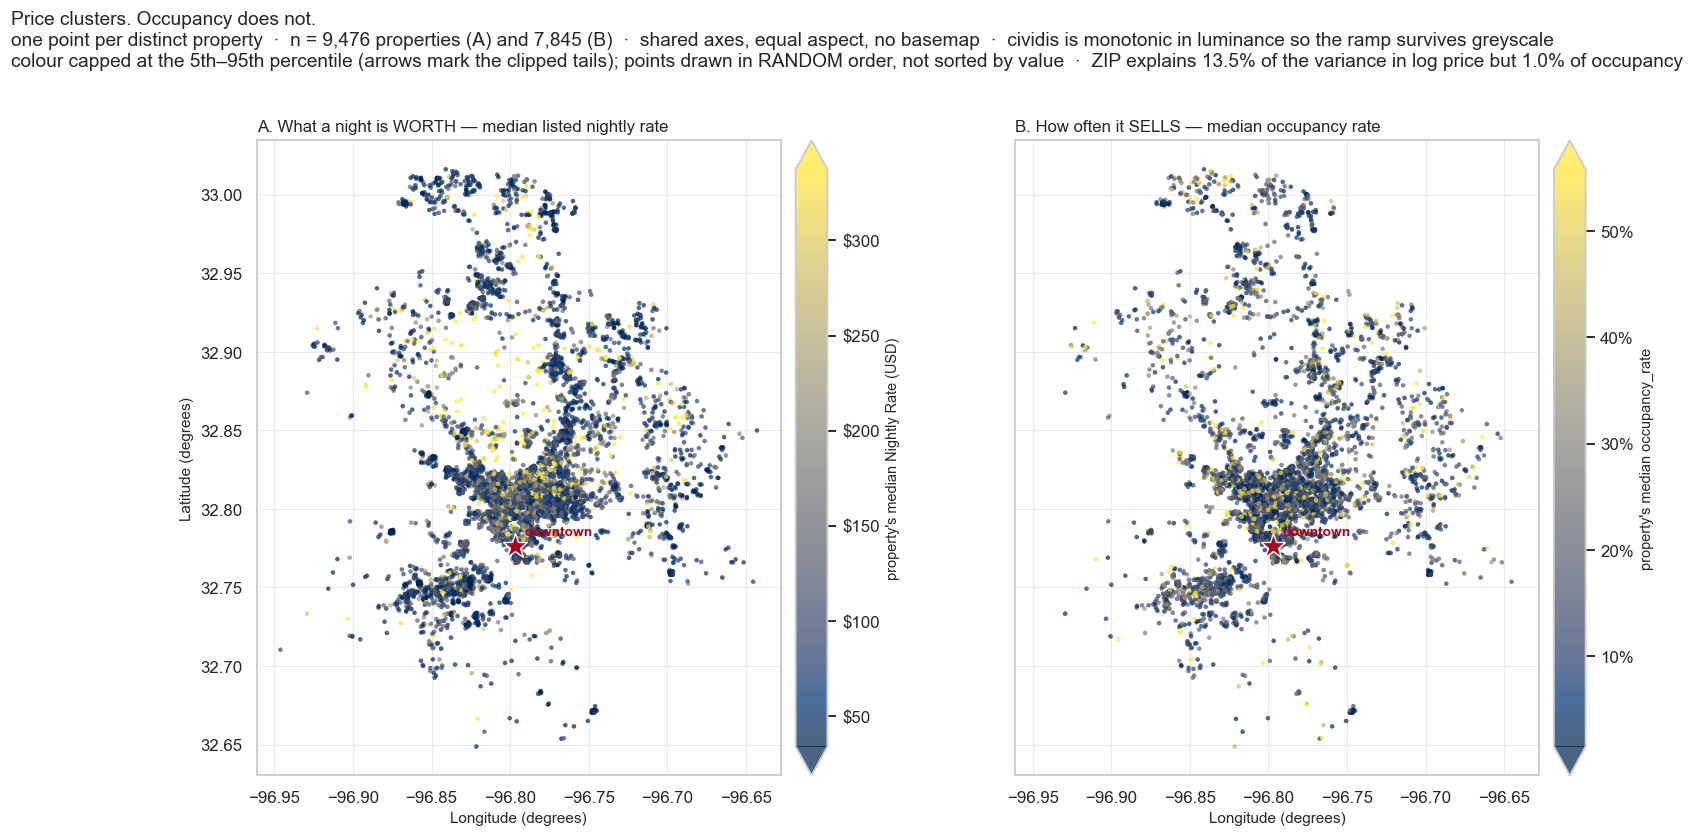

  READ PANEL A AS STRUCTURE AND PANEL B AS NOISE, and read A honestly: the high-rate
  points form TWO clusters, not one radial gradient - the downtown core AND the affluent
  north-central corridor. The single highest-rate ZIP in the whole table is 75225 (North Central Dallas),
  median $220 a night, and it sits 10.0 km OUT, not downtown. So "price falls with
  distance" is a tendency with a large exception, and step 5 measures the tendency rather
  than asserting the picture. Panel B has no structure to describe at all: the same map,
  the same points, and no occupancy neighbourhood anywhere in it.

STEP 5 - FIGURE B, THE DISTANCE GRADIENT
DISTANCE FORMULA, PRINTED BECAUSE IT IS AN APPROXIMATION:
  dist_km = sqrt( (111.0 * dLat)^2 + (93.3273 * dLon)^2 ),  dLat/dLon in degrees from
  downtown Dallas (32.7767, -96.7970). 93.3273 = 111.0 * cos(radians(32.7767)).
  This is the EQUIRECTANGULAR approximation - it treats a small patch of the earth as flat.
  Over a city the size of Dallas t

,rows,properties,med_rate,med_realised,med_occupancy,med_revenue,entire_home_share,superhost_share,booked_rows
dist_band,,,,,,,,,
0-2 km,10098,2057,149.000,116.5714,0.1609,2854.0,0.9117,0.2319,7393
2-4 km,11189,2249,120.000,101.5000,0.1634,2079.0,0.8000,0.3317,7345
4-6 km,11076,1995,109.000,92.0000,0.1622,2099.5,0.7914,0.4046,7554
6-8 km,3907,749,97.600,80.0000,0.1557,1770.5,0.6691,0.3944,2668
8-12 km,4346,838,86.375,79.5000,0.1417,1430.5,0.6139,0.3422,2482
12+ km,7579,1588,76.000,68.0000,0.1458,1194.0,0.5681,0.2884,4113


BAND TABLE - ENTIRE HOMES ONLY (36,510 rows, 7,199 properties)


,rows,properties,med_rate,med_realised,med_occupancy,med_revenue,entire_home_share,superhost_share,booked_rows
dist_band,,,,,,,,,
0-2 km,9206,1861,160.0,120.0000,0.1618,3000.0,1.0,0.2146,6800
2-4 km,8951,1787,145.0,113.9722,0.1709,2556.0,1.0,0.2965,5803
4-6 km,8765,1583,125.0,103.3333,0.1659,2460.0,1.0,0.4090,6177
6-8 km,2614,513,125.0,101.8824,0.1576,2487.0,1.0,0.4082,1839
8-12 km,2668,502,125.0,103.7577,0.1499,2200.0,1.0,0.3418,1534
12+ km,4306,953,105.0,90.0000,0.1675,2016.0,1.0,0.2977,2388


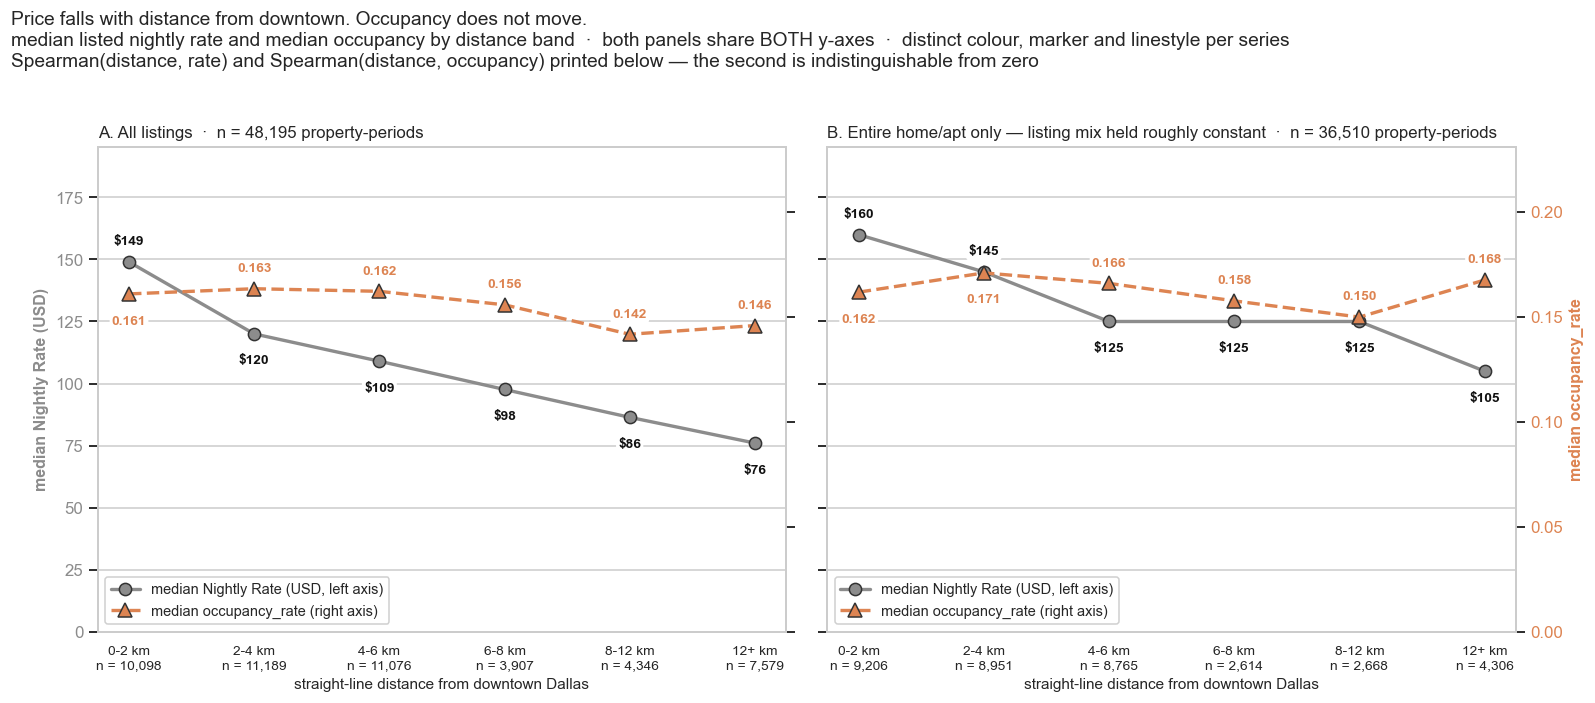

SPEARMAN RANK CORRELATION OF dist_km AGAINST EACH OUTCOME
  Rank correlation, not Pearson: distance is bounded below at 0 and all three outcomes are
  heavily right-skewed, so a monotone measure is the honest one.


n  rows dropped (null y)  spearman_rho          p
frame             y                                                                    
all listings      Nightly Rate    48195                      0       -0.2884   0.00e+00
                  occupancy_rate  31555                  16640       -0.0227   5.63e-05
                  revenue         31555                  16640       -0.2128   0.00e+00
entire homes only Nightly Rate    36510                      0       -0.1583  1.41e-203
                  occupancy_rate  24541                  11969        0.0122   5.63e-02
                  revenue         24541                  11969       -0.1064   1.11e-62

  Median listed rate across the bands, all listings : $149.00 -> $120.00 -> $109.00 -> $97.60 -> $86.38 -> $76.00
  Median occupancy across the bands, all listings   : 0.161 -> 0.163 -> 0.162 -> 0.156 -> 0.142 -> 0.146
  => PRICE FALLS MONOTONICALLY (-49% from the innermost band to the outermost, rho
  -0.2884). OCCUPANCY DOES NOT MOVE: rho -0.0227, and the six band medians span only
  0.142-0.163 - a 15.3% range from lowest to highest, with no monotone pattern at all.
  Within ENTIRE HOMES the price gradient more than halves (-0.1583 against -0.2884) - most
  of the raw gradient was listing MIX, which step 6 makes visual - and the occupancy
  correlation turns marginally POSITIVE (+0.0122). Comparing like with like, listings
  further from downtown sell very slightly MORE often, not less.
  Revenue sits between the two (-0.2128) because revenue = nights x price and only the
  price half has a geography.

  THE EXCEPTION WORTH NAMING, because a monotone line invites over-reading. ZIP 7

,modal Neighborhood,entire_home_share (all listings),med_revenue (all),rank (all listings),med_revenue (entire homes),rank (entire homes),places moved
zip,,,,,,,
75201,Central Dallas,0.946,3000.0,1,3093.0,2,-1
75202,Central Dallas,0.925,2765.5,2,2805.0,4,-2
75207,Northwest Dallas,0.840,2677.0,3,2721.5,6,-3
75215,Central Dallas,0.692,2254.5,4,2860.5,3,1
75204,Central Dallas,0.853,2226.0,5,2520.0,13,-8
75206,Central Dallas,0.748,2190.0,6,2647.0,8,-2
75226,Central Dallas,0.580,2146.5,7,2376.0,15,-8
75246,Central Dallas,0.817,2126.0,8,2344.5,17,-9
75219,Oak Lawn,0.786,2118.5,9,2545.0,12,-3


HOW MUCH OF THE ZIP REVENUE RANKING IS LISTING MIX?
  Pearson(entire-home share, median revenue) across the 39 ZIPs : +0.7762  (r^2 = 0.602)
  Pearson(entire-home share, median rate)   across the 39 ZIPs : +0.7618  (r^2 = 0.580)
  Spearman between the two RANKINGS (34 ZIPs)                  : +0.7204 (p = 0.0000)
  ZIPs moving >= 3 rank places                                : 24 of 34

  SPREAD UNDER EACH SPECIFICATION - the number that matters most in this cell.
  THREE columns, not two, and the middle one is the reason. The entire-home threshold drops
  5 ZIPs, and those 5 contain BOTH extremes of the all-listings table, so comparing the
  39-ZIP spread against the 34-ZIP entire-home spread would credit the listing-type control
  with an attenuation that is really a change of ZIP set. The middle column holds the ZIP
  set fixed so the last step is a clean like-for-like control.


,"(1) all listings, all 39 ZIPs","(2) all listings, the 34 common ZIPs","(3) entire homes, the 34 common ZIPs"
min median revenue,330.000,915.000,1240.500
max median revenue,3000.000,3000.000,3240.000
max/min revenue,9.091,3.279,2.612
min median rate,29.000,51.800,90.000
max median rate,220.000,160.000,200.000
max/min rate,7.586,3.089,2.222


  DECOMPOSED: revenue spread 9.1x -> 3.3x -> 2.6x and rate spread 7.6x -> 3.1x
  -> 2.2x. The FIRST step (9.1x -> 3.3x on revenue) is dropping 5 small ZIPs, which is
  a SAMPLE change, not a mix control - and those 5 are themselves a mix story: the bottom ZIP
  75241 has a 0% entire-home share, i.e. it has essentially no entire homes to compare.
  The SECOND step (3.3x -> 2.6x on revenue, 3.1x -> 2.2x on rate) is the actual
  listing-type control, on a fixed set of ZIPs.
  => A REAL BUT MUCH SMALLER PLACE EFFECT SURVIVES UNDERNEATH A LARGE MIX EFFECT. The claim
  "location drives revenue 9x" is FALSE and is not made anywhere in this cell; the
  defensible claim is a ~2.6x place effect on revenue and ~2.2x on price once like is
  compared with like. This is the same correction Q12 found at neighbourhood level
  (r = +0.822 there, +0.776 here) - two geographies, one conclusion.

CHART CHOICE: A HORIZONTAL DUMBBELL (SLOPE) CHART. This is a COMPARISON of two RANKINGS of
the SAME categories

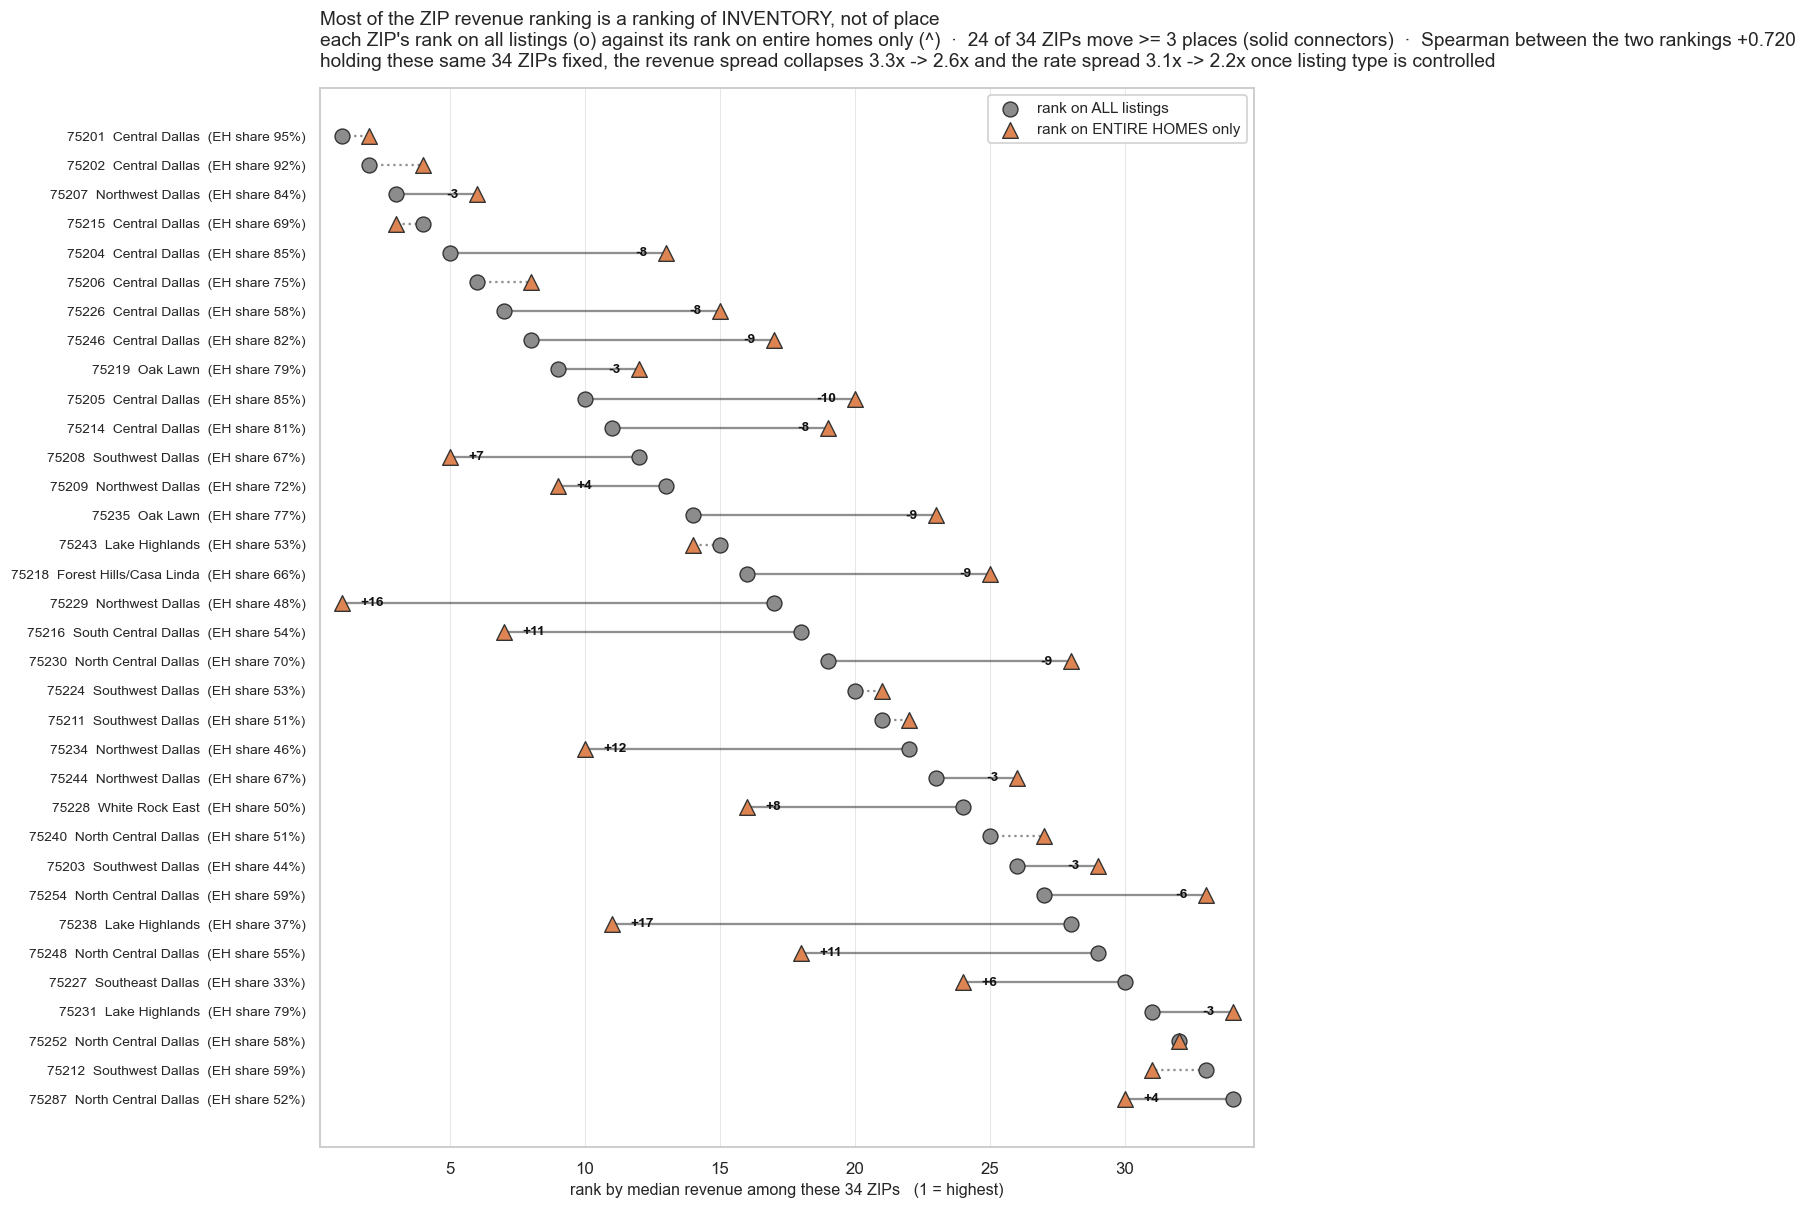


STEP 7 - REGIME CHECK. Q13 found the market-wide listed price halves at period 17, so any
pooled price figure here spans TWO regimes and has to be split before it is believed.


  Periods 5-16 ("early") : 30,750 rows, 7,164 properties, periods 5-16
  Periods 17-20 ("late") : 17,445 rows, 5,979 properties, periods 17-20
  MARKET-WIDE MEDIAN LISTED RATE: $136.00 (early) -> $84.00 (late), a -38.2% fall.
  Median occupancy 0.1623 -> 0.1517; median revenue $2,127 -> $1,870.

IS THE GEOGRAPHIC ORDERING STABLE ACROSS THE BREAK? Per-ZIP medians in each half, ranked.


,ZIPs in both halves,ZIPs dropped (missing a half),median early,median late,"Spearman(early rank, late rank)",p
measure,,,,,,
Nightly Rate,39,0,90.0000,75.0000,0.6160,2.98e-05
occupancy_rate,39,0,0.1556,0.1377,0.3787,1.74e-02
revenue,39,0,1478.0000,1449.5000,0.7632,1.61e-08


  => THE LEVEL MOVES, THE ORDERING LARGELY HOLDS. Revenue is the most stable geography
  (rho +0.763), listed rate is moderately stable (+0.616), and OCCUPANCY IS THE LEAST
  STABLE (+0.379) - which is the same finding as step 3 from a different angle: there is
  so little between-ZIP signal in occupancy (1.0% of variance) that its ranking is mostly
  noise and does not reproduce across halves.
  ANY POOLED PRICE FIGURE IN THIS CELL SPANNING PERIODS 5-20 AVERAGES TWO REGIMES. The
  levels in the step 3 table and the step 5 bands are pooled and should be read as
  RELATIVE positions, not as a price a manager could quote today.

STEP 8 - SUPERHOST SHARE AS A GEOGRAPHY. Q12 ranked Superhost REVENUE; nobody has looked
at where Superhosts ARE.
TOP 8 ZIPs BY SUPERHOST SHARE


,modal Neighborhood,properties,rows,superhost_share,med_rate,med_occupancy,med_revenue,entire_home_share
zip,,,,,,,,
75215,Central Dallas,180,854,0.5960,100.0000,0.1734,2254.5,0.6920
75208,Southwest Dallas,484,2682,0.5779,85.5938,0.1622,1966.0,0.6670
75223,Central Dallas,44,230,0.5174,93.0000,0.1961,1501.0,0.5870
75227,Southeast Dallas,113,530,0.4792,55.0000,0.1275,1067.0,0.3283
75218,Forest Hills/Casa Linda,129,770,0.4753,93.0000,0.1447,1524.0,0.6649
75209,Northwest Dallas,153,876,0.4749,105.0000,0.1770,1945.0,0.7249
75203,Southwest Dallas,100,579,0.4629,51.8000,0.1330,1174.0,0.4370
75234,Northwest Dallas,76,336,0.4464,65.0000,0.1546,1341.0,0.4554


...

  THE SHAPE, NOT A DIRECTION. Superhost share across the six bands:
    23.2% -> 33.2% -> 40.5% -> 39.4% -> 34.2% -> 28.8%
  It RISES from 23.2% in the innermost band to a peak of 40.5% in the 4-6 km band, then falls
  back to 28.8% at the edge. That is an INVERTED U, not a gradient, so "Superhosts cluster
  downtown" and "Superhosts cluster in the suburbs" are BOTH wrong. The lowest Superhost
  share sits in the highest-priced, most entire-home, most downtown band - consistent with
  the professional/serviced-apartment operators Q14 found, who run many listings and clear
  the badge less often. This cell reports the shape and does not assert a mechanism.

STEP 8b - THE OPERATIONAL SHORTLIST. Computed, not eyeballed, because the brief names ZIPs.
  Cross-ZIP medians used as the two cut lines: occupancy 0.1520, realised rate $77.91.
  RULE FIXED BEFORE LOOKING: "sells often, realises little" = median occupancy ABOVE the
  first line AND median realised rate BELOW the second. This is a P

,modal Neighborhood,properties,med_rate,med_realised,med_occupancy,med_revenue,superhost_share,entire_home_share
zip,,,,,,,,
75223,Central Dallas,44,93.000,68.2206,0.1961,1501.0,0.5174,0.5870
75240,North Central Dallas,78,69.000,67.9305,0.1750,1224.0,0.2380,0.5099
75230,North Central Dallas,137,80.000,69.0000,0.1736,1469.5,0.2849,0.6977
75211,Southwest Dallas,134,67.125,58.0000,0.1645,1348.0,0.3768,0.5117
75252,North Central Dallas,143,69.000,59.4231,0.1613,986.0,0.2849,0.5845
75216,South Central Dallas,65,60.500,53.5357,0.1566,1490.0,0.2671,0.5371
75234,Northwest Dallas,76,65.000,56.5000,0.1546,1341.0,0.4464,0.4554


    7 ZIPs, 677 distinct properties, 431 distinct hosts. Median realised rate across
    these ZIPs $59.42 against $77.91 across all 39 ZIPs; median occupancy 0.1645
    against 0.1520.

  THE MIRROR CASE - SELL RARELY, REALISE A LOT (where a price cut, not a rise, is indicated)


,modal Neighborhood,properties,med_rate,med_realised,med_occupancy,med_revenue,superhost_share,entire_home_share
zip,,,,,,,,
75225,North Central Dallas,36,220.0,130.0476,0.0823,1440.0,0.2573,0.7913
75205,Central Dallas,245,125.0,100.0000,0.1322,2102.0,0.2848,0.8537
75214,Central Dallas,399,100.0,83.4613,0.1517,2099.0,0.4177,0.8115
75228,White Rock East,127,75.0,79.0270,0.1497,1272.0,0.4052,0.5041
75246,Central Dallas,78,94.0,79.0000,0.1507,2126.0,0.3181,0.8169
75218,Forest Hills/Casa Linda,129,93.0,78.3946,0.1447,1524.0,0.4753,0.6649
75212,Southwest Dallas,98,77.0,77.9058,0.1194,981.5,0.2226,0.5903


    7 ZIPs, 1,112 properties. This is the smaller and more fragile group, and 75225 sits in
    it: highest listed rate in Dallas ($220) on 36 properties with median occupancy
    0.0823.

STEP 9 - LIMITATIONS. Four, each one attached to a specific number above.
(a) LOCATION IS NOT RANDOMLY ASSIGNED. Hosts and developers choose where to list, so the
    downtown price premium is confounded with unit type, unit size and the concentration of
    professional operators. Step 6 shows this is not hypothetical: entire-home share alone
    correlates +0.776 with median ZIP revenue and +0.762 with median rate, and holding
    listing type constant collapses the revenue spread 3.3x -> 2.6x on a fixed set of
    34 ZIPs (and the headline 9.1x spread across all 39 ZIPs is bounded at the bottom by a
    ZIP with no entire homes in it at all). THE CORRECT CLAIM IS ASSOCIATION:
    "listings in ZIP 75201 realise a higher median rate", NEVER "location causes price".
(b) revenue AND occupancy_rate ARE

In [18]:
# Q15 asks for a "story of place". Three decisions come before any chart. First, WHICH place:
# step 1 compares Neighborhood, Zipcode and census_tract on coverage and concentration and picks
# Zipcode on the evidence rather than by habit. Second, WHAT a row is: property-periods in ZIPs
# with >= 30 distinct properties - the threshold counts PROPERTIES, not rows, because this is
# panel data (the Q12 note). Third, WHAT the story is: steps 3 and 5 show place sets what a night
# is WORTH but not whether it SELLS, and step 6 shows most of the revenue spread is listing mix,
# not place. Q12 owns the Superhost neighbourhood ranking; this cell does not repeat it.

import matplotlib.ticker as mticker      # only new import in this cell: colorbar tick formats

GREY, ORANGE, EDGE = '#8C8C8C', '#DD8452', '#333333'

# --- Step 0: scope guard - what this cell does that Q12 did not ----------------------------
print('=' * 100)
print('STEP 0 - SCOPE GUARD. Q12 ranked SUPERHOST revenue and occupancy across 11 NEIGHBOURHOODS.')
print('Q15 is the superset: ALL listings, the geographic view (Latitude/Longitude), the Superhost')
print('SHARE of each area, and the BOTTOM of the distribution. Superhost revenue is NOT re-ranked')
print('here - Q12 owns it and is cross-referenced instead.')
print('=' * 100)
print()


# --- Step 1: choose the geography, and show the choice was earned ---------------------------
print('=' * 100)
print('STEP 1 - WHICH GEOGRAPHY? Three candidate columns, judged before either is used.')
print('=' * 100)
N_PROPS = df['Airbnb Property ID'].nunique()
geo_rows = []
for c in ['Neighborhood', 'Zipcode', 'census_tract']:
    per_cat = df[df[c].notna()].groupby(c)['Airbnb Property ID'].nunique()
    big = per_cat[per_cat >= 30]
    geo_rows.append({
        'geography': c,
        'categories': int(df[c].nunique()),
        'largest category': str(per_cat.idxmax()),
        'largest cat share of properties': round(per_cat.max() / N_PROPS, 4),
        'properties with a null value': int(df.loc[df[c].isna(), 'Airbnb Property ID'].nunique()),
        'categories with >= 30 properties': int(len(big)),
        'property coverage at >= 30': round(big.sum() / N_PROPS, 4)})
geo_tbl = pd.DataFrame(geo_rows).set_index('geography')
print('All {:,} rows / {:,} distinct properties. "Coverage at >= 30" is the share of ALL properties'.format(
    len(df), N_PROPS))
print('that survive a 30-distinct-property threshold on that geography.')
display(geo_tbl)
print('  DECISION: `Zipcode` IS THE ANALYSIS GEOGRAPHY.')
print('  - Neighborhood is unusable as the primary cut: it puts {:.1%} of all properties into ONE'.format(
    geo_tbl.loc['Neighborhood', 'largest cat share of properties']))
print('    bucket ("{}") and is null for {:,} properties. A "story of place" whose'.format(
    geo_tbl.loc['Neighborhood', 'largest category'],
    geo_tbl.loc['Neighborhood', 'properties with a null value']))
print('    biggest category is half the city is not a story about place.')
print('  - census_tract is too fine: {:,} categories, and only {:.1%} of properties survive the'.format(
    geo_tbl.loc['census_tract', 'categories'],
    geo_tbl.loc['census_tract', 'property coverage at >= 30']))
print('    same threshold, so a quarter of the market would be invisible.')
print('  - Zipcode: {:,} categories, ZERO nulls, largest is {:.1%} of properties, and {:,} ZIPs'.format(
    geo_tbl.loc['Zipcode', 'categories'],
    geo_tbl.loc['Zipcode', 'largest cat share of properties'],
    geo_tbl.loc['Zipcode', 'categories with >= 30 properties']))
print('    clear the threshold covering {:.1%} of properties. It is also the unit a manager can act'.format(
    geo_tbl.loc['Zipcode', 'property coverage at >= 30']))
print('    on. Neighborhood is retained as a NAME for each ZIP, not as the analysis unit.')
print()

# ZIP -> modal neighbourhood, so every ZIP can be named in prose rather than quoted as a number
named = df[df['Neighborhood'].notna()]
modal = named.groupby('Zipcode')['Neighborhood'].agg(
    lambda s: s.mode().iloc[0] if len(s.mode()) else 'unnamed')
zip_props_all = df.groupby('Zipcode')['Airbnb Property ID'].nunique()
cross = pd.DataFrame({
    'modal Neighborhood': modal,
    'properties': zip_props_all,
    'rows': df.groupby('Zipcode').size(),
    'rows with a Neighborhood': named.groupby('Zipcode').size()}).sort_values('properties',
                                                                             ascending=False)
cross.index = cross.index.astype(int).astype(str)
cross.index.name = 'zip'
_modal_cover = 100 * named.groupby('Zipcode').apply(
    lambda s: (s['Neighborhood'] == s['Neighborhood'].mode().iloc[0]).mean()
    if len(s['Neighborhood'].mode()) else np.nan, include_groups=False)
_modal_cover.index = _modal_cover.index.astype(int).astype(str)
cross['modal name covers % of named rows'] = _modal_cover.round(1)
print('ZIP -> MODAL NEIGHBORHOOD CROSSWALK, top 15 ZIPs by distinct properties')
display(cross.head(15))
print('  The last column is a warning label, not decoration: where it is low the ZIP straddles')
print('  several named areas and the modal name is a shorthand, not a definition.')
print()


# --- Step 2: build the ZIP frame, and REPORT THE FILTER --------------------------------------
print('=' * 100)
print('STEP 2 - ROW FILTERING, REPORTED. Threshold is >= 30 DISTINCT PROPERTIES per ZIP.')
print('=' * 100)
print('The threshold counts PROPERTIES, not rows, because this is panel data: a ZIP with 8')
print('properties observed in 8 periods would clear a 30-ROW test while resting on 8 listings.')
print('This is the same rule Q12 applied to neighbourhoods.')
KEEP_ZIPS = sorted(zip_props_all[zip_props_all >= 30].index)
drop_zips = sorted(zip_props_all[zip_props_all < 30].index)
mask = df['Zipcode'].isin(KEEP_ZIPS)
print('  ZIPs in the file                     : {:,}'.format(int(df['Zipcode'].nunique())))
print('  ZIPs KEPT (>= 30 properties)         : {:,}'.format(len(KEEP_ZIPS)))
print('  ZIPs DROPPED (< 30 properties)       : {:,}  ({} properties between them)'.format(
    len(drop_zips), int(zip_props_all[zip_props_all < 30].sum())))
print('  Rows kept                            : {:,} of {:,} ({:.1%})'.format(
    int(mask.sum()), len(df), mask.mean()))
print('  Rows dropped                         : {:,} ({:.1%})'.format(
    int((~mask).sum()), (~mask).mean()))
print('  Distinct properties kept             : {:,} of {:,} ({:.1%})'.format(
    df.loc[mask, 'Airbnb Property ID'].nunique(), N_PROPS,
    df.loc[mask, 'Airbnb Property ID'].nunique() / N_PROPS))
print('  Rows with a null Zipcode             : {:,}  (none - Zipcode is complete)'.format(
    int(df['Zipcode'].isna().sum())))
print('  => The threshold is nearly free: it removes {:.1%} of rows and {:.1%} of properties.'.format(
    (~mask).mean(), 1 - df.loc[mask, 'Airbnb Property ID'].nunique() / N_PROPS))
print()

# Derived columns are built on a NARROW copy and attached in ONE concat, never inserted into df
# (100+ columns), which fires PerformanceWarning: DataFrame is highly fragmented into the PDF
KEEP_COLS = ['Airbnb Property ID', 'Airbnb Host ID', 'superhost_period_all', 'Superhost',
             'Zipcode', 'Neighborhood', 'census_tract', 'Latitude', 'Longitude', 'Listing Type',
             'Nightly Rate', 'booked_days_avePrice', 'occupancy_rate', 'revenue',
             'revenue_z', 'on_market']
g = df.loc[mask, KEEP_COLS].copy()

# Distance from downtown Dallas. Equirectangular approximation - stated, not hidden
LAT0, LON0 = 32.7767, -96.7970           # Dealey Plaza / downtown Dallas
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(LAT0))
BANDS = ['0-2 km', '2-4 km', '4-6 km', '6-8 km', '8-12 km', '12+ km']
dist = np.sqrt((KM_PER_DEG_LAT * (g['Latitude'] - LAT0)) ** 2
               + (KM_PER_DEG_LON * (g['Longitude'] - LON0)) ** 2)
g = pd.concat([g, pd.DataFrame({
    'zip': g['Zipcode'].astype(int).astype(str),
    'dist_km': dist,
    'dist_band': pd.cut(dist, [0, 2, 4, 6, 8, 12, np.inf], labels=BANDS, right=False),
    'entire_home': (g['Listing Type'] == 'Entire home/apt'),
    'log_rate': np.log(g['Nightly Rate'].where(g['Nightly Rate'] > 0)),
    'log_revenue': np.log(g['revenue'].where(g['revenue'] > 0)),
}, index=g.index)], axis=1)
ZIP_NAME = {str(int(z)): modal.get(z, 'unnamed') for z in KEEP_ZIPS}


# --- Step 3: THE ZIP TABLE - the answer's numbers -------------------------------------------
print('=' * 100)
print('STEP 3 - THE ZIP TABLE. All {} kept ZIPs, top AND bottom, sorted by median revenue.'.format(
    len(KEEP_ZIPS)))
print('=' * 100)


def zip_table(frame):
    """One row per ZIP. Medians throughout - Q12 showed means here rank luxury outliers."""
    grp = frame.groupby('zip')
    t = grp.agg(properties=('Airbnb Property ID', 'nunique'),
                rows=('Nightly Rate', 'size'),
                med_rate=('Nightly Rate', 'median'),
                med_realised=('booked_days_avePrice', 'median'),
                med_occupancy=('occupancy_rate', 'median'),
                med_revenue=('revenue', 'median'),
                superhost_share=('Superhost', 'mean'),
                entire_home_share=('entire_home', 'mean'))
    # revenue_z on the on-market frame: idle periods enter as $0 rather than vanishing
    om = frame[frame['on_market']]
    t['med_revenue_z_onmkt'] = om.groupby('zip')['revenue_z'].median()
    t['on_market_rows'] = om.groupby('zip').size()
    t.insert(0, 'modal Neighborhood', pd.Series(ZIP_NAME).reindex(t.index))
    return t.sort_values('med_revenue', ascending=False)


zt = zip_table(g)
n_rate_null = int(g['Nightly Rate'].isna().sum())
n_occ_null = int(g['occupancy_rate'].isna().sum())
print('DENOMINATOR / MISSINGNESS GUARD, reported before the table is read:')
print('  Rows in the ZIP frame                             : {:,}'.format(len(g)))
print('  ... with a null Nightly Rate                      : {:,}'.format(n_rate_null))
print('  ... with a null occupancy_rate / revenue          : {:,} ({:.1%}) - the never-booked'.format(
    n_occ_null, n_occ_null / len(g)))
print('      periods the setup cell itemised. med_occupancy and med_revenue are computed on the')
print('      {:,} BOOKED rows; med_revenue_z_onmkt puts the idle-but-listed periods back as $0.'.format(
    len(g) - n_occ_null))
print('  ZIPs with no booked row at all (would be an empty median): {}'.format(
    int(zt['med_revenue'].isna().sum())))
print('  ZIPs with no on-market row at all                        : {}'.format(
    int(zt['med_revenue_z_onmkt'].isna().sum())))
display(zt.round(4))

print('SPREAD ACROSS THE {} ZIPs - min, max, and max/min ratio'.format(len(zt)))
spread_rows = []
for c, lab in [('med_rate', 'median Nightly Rate (listed)'),
               ('med_realised', 'median booked_days_avePrice (realised)'),
               ('med_occupancy', 'median occupancy_rate'),
               ('med_revenue', 'median revenue'),
               ('med_revenue_z_onmkt', 'median revenue_z, on-market frame'),
               ('superhost_share', 'Superhost share of rows'),
               ('entire_home_share', 'entire-home share of rows')]:
    s = zt[c].dropna()
    spread_rows.append({'measure': lab, 'min': round(s.min(), 4), 'min ZIP': s.idxmin(),
                        'max': round(s.max(), 4), 'max ZIP': s.idxmax(),
                        'max/min': round(s.max() / s.min(), 2) if s.min() > 0 else np.nan})
spread = pd.DataFrame(spread_rows).set_index('measure')
display(spread)
print('  max/min is NaN on the last row by design: ZIP {} has NO entire homes at all (share 0),'.format(
    zt['entire_home_share'].idxmin()))
print('  so the ratio has a zero denominator and is left undefined rather than filled in.')
print('  READ THE THREE HEADLINE ROWS TOGETHER. Median listed rate spans {:.2f}x across ZIPs and'.format(
    spread.loc['median Nightly Rate (listed)', 'max/min']))
print('  median revenue {:.2f}x, but median OCCUPANCY spans only {:.2f}x. Price and revenue vary'.format(
    spread.loc['median revenue', 'max/min'], spread.loc['median occupancy_rate', 'max/min']))
print('  enormously by place; how often a listing sells barely does.')
print()

# How much of each outcome does ZIP actually explain? eta-squared = between-ZIP SS / total SS
print('HOW MUCH DOES PLACE EXPLAIN? One-way eta-squared with ZIP as the factor.')
print('  eta^2 = between-ZIP sum of squares / total sum of squares = share of variance ZIP')
print('  accounts for. Logs on the two money variables because both are strongly right-skewed')
print('  (Q1 and Q6); {} rows have Nightly Rate <= 0 and {} have revenue <= 0, and those are'.format(
    int((g['Nightly Rate'] <= 0).sum()), int((g['revenue'] <= 0).sum())))
print('  excluded from the log versions rather than clipped.')


def eta_squared(frame, ycol, gcol='zip'):
    """Share of variance in ycol accounted for by gcol. Nulls dropped and counted."""
    f = frame[frame[ycol].notna()]
    y = f[ycol].to_numpy(dtype=float)
    grand = y.mean()
    sst = ((y - grand) ** 2).sum()
    grp = f.groupby(gcol)[ycol]
    ssb = float((grp.count() * (grp.mean() - grand) ** 2).sum())
    return {'n rows used': len(f), 'rows dropped (null)': len(frame) - len(f),
            'groups': int(f[gcol].nunique()), 'eta_squared': round(ssb / sst, 4)}


eta_tbl = pd.DataFrame({lab: eta_squared(g, c) for lab, c in
                        [('log(Nightly Rate)', 'log_rate'),
                         ('occupancy_rate', 'occupancy_rate'),
                         ('log(revenue)', 'log_revenue'),
                         ('Nightly Rate (raw)', 'Nightly Rate'),
                         ('revenue (raw)', 'revenue')]}).T
display(eta_tbl)
E_RATE = eta_tbl.loc['log(Nightly Rate)', 'eta_squared']
E_OCC = eta_tbl.loc['occupancy_rate', 'eta_squared']
E_REV = eta_tbl.loc['log(revenue)', 'eta_squared']
print('  => THE HEADLINE OF THIS QUESTION: ZIP EXPLAINS {:.1%} OF THE VARIANCE IN LOG PRICE BUT'.format(E_RATE))
print('  ONLY {:.1%} OF THE VARIANCE IN OCCUPANCY (log revenue {:.1%}). Place sets what a night is'.format(
    E_OCC, E_REV))
print('  WORTH. It does not set whether it SELLS. Every recommendation below follows from that')
print('  asymmetry, and step 6 shows how much of even the price gap is listing mix.')
print()


# --- Step 4: FIGURE A - the map ---------------------------------------------------------------
print('=' * 100)
print('STEP 4 - FIGURE A, THE MAP')
print('=' * 100)
print('CHART CHOICE: A TWO-PANEL LATITUDE/LONGITUDE SCATTER, ONE POINT PER DISTINCT PROPERTY.')
print('Lecture 3 maps a RELATIONSHIP / spatial-distribution question to a scatter, and a scatter is')
print('the only chart that preserves BOTH coordinates - any binning into a bar or box chart throws')
print('one of the two dimensions away. Two panels on identical axes (sharex, sharey, equal aspect)')
print('let the reader see that the two variables have DIFFERENT geographies, which is the finding.')
print('No basemap or tile package is used: the notebook has to run offline in Colab and export to')
print('PDF, and the point pattern is legible without a street map behind it.')
print('COLOUR: cividis. It is perceptually uniform AND monotonic in luminance, so it survives the')
print('greyscale PDF as a light-to-dark ramp (standing instruction 8). A diverging or rainbow map')
print('would collapse to ambiguity in print.')
print()

# One row per property. Coordinates are property-constant, so the median over periods is exact
coord_check = g.groupby('Airbnb Property ID')[['Latitude', 'Longitude']].nunique().max()
prop = g.groupby('Airbnb Property ID').agg(
    Latitude=('Latitude', 'first'), Longitude=('Longitude', 'first'),
    zip=('zip', 'first'), dist_km=('dist_km', 'first'),
    med_rate=('Nightly Rate', 'median'), med_occ=('occupancy_rate', 'median'),
    med_rev=('revenue', 'median'), superhost=('Superhost', 'mean'),
    entire_home=('entire_home', 'mean'), periods=('Nightly Rate', 'size'))
print('POINTS ON THE MAP - one per DISTINCT PROPERTY, not per row')
print('  Distinct properties in the ZIP frame     : {:,} (from {:,} property-periods)'.format(
    len(prop), len(g)))
print('  Max distinct Latitude / Longitude values within a property: {} / {} -> coordinates are'.format(
    int(coord_check['Latitude']), int(coord_check['Longitude'])))
print('    property-constant, so collapsing the panel loses no spatial information.')
coord_counts = prop.groupby(['Latitude', 'Longitude']).size()
N_DUP_POINTS = int((coord_counts > 1).sum())
N_SHARED_COORD = int(coord_counts[coord_counts > 1].sum())
MAX_AT_POINT = int(coord_counts.max())
print('  Properties sharing an EXACT coordinate with another property: {:,} across {:,} points,'.format(
    N_SHARED_COORD, N_DUP_POINTS))
print('    max {:,} properties stacked on one point. Reported here because it means the map is'.format(
    MAX_AT_POINT))
print('    partly OVERPLOTTED and the coordinates are approximate (limitation (c) in step 9).')
print('  Panel A - properties with a median Nightly Rate : {:,} (dropped: {:,})'.format(
    int(prop['med_rate'].notna().sum()), int(prop['med_rate'].isna().sum())))
print('  Panel B - properties with a median occupancy    : {:,} (dropped: {:,} - never booked in'.format(
    int(prop['med_occ'].notna().sum()), int(prop['med_occ'].isna().sum())))
print('    any observed period, so no occupancy exists to plot)')

pa = prop[prop['med_rate'].notna()]
pb = prop[prop['med_occ'].notna()]
lo_a, hi_a = pa['med_rate'].quantile([0.05, 0.95])
lo_b, hi_b = pb['med_occ'].quantile([0.05, 0.95])
print('  COLOUR SCALE CAPPED AT THE 5th-95th PERCENTILE - THE CAP IS ON THE VIEW, NOT THE DATA:')
print('    Panel A ${:,.2f} to ${:,.2f}  ({:,} properties below, {:,} above, drawn at the end colour)'.format(
    lo_a, hi_a, int((pa['med_rate'] < lo_a).sum()), int((pa['med_rate'] > hi_a).sum())))
print('    Panel B {:.3f} to {:.3f}  ({:,} below, {:,} above)'.format(
    lo_b, hi_b, int((pb['med_occ'] < lo_b).sum()), int((pb['med_occ'] > hi_b).sum())))
print()

fig, axes = plt.subplots(1, 2, figsize=(14.6, 7.4), sharex=True, sharey=True)
for ax, frame, col, vlo, vhi, cbar_lab, subtitle, fmt in [
        (axes[0], pa, 'med_rate', lo_a, hi_a, "property's median Nightly Rate (USD)",
         'A. What a night is WORTH — median listed nightly rate', '${x:,.0f}'),
        (axes[1], pb, 'med_occ', lo_b, hi_b, "property's median occupancy_rate",
         'B. How often it SELLS — median occupancy rate', '{x:.0%}')]:
    # PLOTTING ORDER, STATED AND DELIBERATELY UNBIASED: points are drawn in a RANDOM order
    # (fixed seed) rather than sorted by the coloured variable. Sorting ascending would put the
    # high values on top everywhere, which makes DENSE areas look bright in BOTH panels and
    # manufactures the very contrast this figure is supposed to test
    fr = frame.sample(frac=1.0, random_state=0)
    sc = ax.scatter(fr['Longitude'], fr['Latitude'], c=fr[col], cmap='cividis',
                    vmin=vlo, vmax=vhi, s=9, linewidths=0, alpha=0.7, zorder=3)
    ax.plot([LON0], [LAT0], marker='*', markersize=17, color='#B00020',
            markeredgecolor='white', markeredgewidth=0.9, zorder=6, linestyle='none')
    ax.annotate('downtown', xy=(LON0, LAT0), xytext=(6, 7), textcoords='offset points',
                fontsize=9, color='#B00020', fontweight='bold', zorder=6)
    ax.set_aspect('equal')
    ax.set_title(subtitle, loc='left', fontsize=11)
    ax.set_xlabel('Longitude (degrees)', fontsize=10)
    ax.grid(True, color='#E5E7EB', linewidth=0.6)
    ax.set_axisbelow(True)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02, extend='both')
    cb.set_label(cbar_lab, fontsize=9.5)
    cb.ax.yaxis.set_major_formatter(mticker.StrMethodFormatter(fmt))
axes[0].set_ylabel('Latitude (degrees)', fontsize=10)
fig.suptitle('Price clusters. Occupancy does not.\n'
             'one point per distinct property  ·  n = {:,} properties (A) and {:,} (B)  ·  '
             'shared axes, equal aspect, no basemap  ·  cividis is monotonic in luminance so the '
             'ramp survives greyscale\ncolour capped at the 5th–95th percentile (arrows mark the '
             'clipped tails); points drawn in RANDOM order, not sorted by value  ·  ZIP '
             'explains {:.1%} of the variance in log price but {:.1%} of occupancy'.format(
                 len(pa), len(pb), E_RATE, E_OCC),
             x=0.008, ha='left', fontsize=12.5, y=1.03)
fig.subplots_adjust(left=0.055, right=0.99, top=0.87, bottom=0.09, wspace=0.02)
plt.show()
print('  READ PANEL A AS STRUCTURE AND PANEL B AS NOISE, and read A honestly: the high-rate')
print('  points form TWO clusters, not one radial gradient - the downtown core AND the affluent')
print('  north-central corridor. The single highest-rate ZIP in the whole table is {} ({}),'.format(
    zt['med_rate'].idxmax(), ZIP_NAME.get(zt['med_rate'].idxmax(), '')))
print('  median ${:,.0f} a night, and it sits {:.1f} km OUT, not downtown. So "price falls with'.format(
    zt['med_rate'].max(), g.loc[g['zip'] == zt['med_rate'].idxmax(), 'dist_km'].median()))
print('  distance" is a tendency with a large exception, and step 5 measures the tendency rather')
print('  than asserting the picture. Panel B has no structure to describe at all: the same map,')
print('  the same points, and no occupancy neighbourhood anywhere in it.')
print()

# --- Step 5: FIGURE B - the distance gradient. THIS IS THE STORY -----------------------------
print('=' * 100)
print('STEP 5 - FIGURE B, THE DISTANCE GRADIENT')
print('=' * 100)
print('DISTANCE FORMULA, PRINTED BECAUSE IT IS AN APPROXIMATION:')
print('  dist_km = sqrt( ({:.1f} * dLat)^2 + ({:.4f} * dLon)^2 ),  dLat/dLon in degrees from'.format(
    KM_PER_DEG_LAT, KM_PER_DEG_LON))
print('  downtown Dallas ({:.4f}, {:.4f}). {:.4f} = 111.0 * cos(radians({:.4f})).'.format(
    LAT0, LON0, KM_PER_DEG_LON, LAT0))
print('  This is the EQUIRECTANGULAR approximation - it treats a small patch of the earth as flat.')
print('  Over a city the size of Dallas the error against a great-circle distance is well under')
print('  1%, but it is an approximation and the bands below are read as coarse, not surveyed.')
print('  Observed range: {:.2f} to {:.2f} km, median {:.2f} km.'.format(
    g['dist_km'].min(), g['dist_km'].max(), g['dist_km'].median()))
print()
print('CHART CHOICE: TWO LINES ON A DUAL AXIS, ACROSS DISTANCE BANDS. Distance is an ORDERED')
print('CONTINUUM, so a line is the correct TREND chart even though the axis is spatial rather than')
print('temporal - the line encodes "as you move outward", which is exactly the claim being made. A')
print('bar chart would draw six unrelated categories and hide the monotonicity. The dual axis is')
print('needed because a rate in dollars and a rate in [0,1] cannot share a scale; each y-label AND')
print('its ticks are coloured to match its series so the axes are never ambiguous, and the two')
print('series differ in COLOUR, MARKER (o vs ^) and LINESTYLE so the figure survives greyscale.')
print('The entire-home repeat is drawn as a SECOND PANEL on shared axes rather than a separate')
print('figure, because the whole point is to compare the two gradients and the house style requires')
print('multi-panel comparisons to share a y-axis.')
print()


def band_table(frame):
    """One row per distance band. observed=False keeps empty bands visible instead of silent."""
    grp = frame.groupby('dist_band', observed=False)
    t = grp.agg(rows=('Nightly Rate', 'size'),
                properties=('Airbnb Property ID', 'nunique'),
                med_rate=('Nightly Rate', 'median'),
                med_realised=('booked_days_avePrice', 'median'),
                med_occupancy=('occupancy_rate', 'median'),
                med_revenue=('revenue', 'median'),
                entire_home_share=('entire_home', 'mean'),
                superhost_share=('Superhost', 'mean')).reindex(BANDS)
    t['booked_rows'] = grp['occupancy_rate'].count().reindex(BANDS)
    return t


gb_all = band_table(g)
gb_eh = band_table(g[g['entire_home']])
print('BAND TABLE - ALL LISTINGS ({:,} rows, {:,} properties)'.format(
    len(g), g['Airbnb Property ID'].nunique()))
display(gb_all.round(4))
print('BAND TABLE - ENTIRE HOMES ONLY ({:,} rows, {:,} properties)'.format(
    int(g['entire_home'].sum()), g.loc[g['entire_home'], 'Airbnb Property ID'].nunique()))
display(gb_eh.round(4))

RATE_TOP = max(gb_all['med_rate'].max(), gb_eh['med_rate'].max()) * 1.22
OCC_TOP = max(gb_all['med_occupancy'].max(), gb_eh['med_occupancy'].max()) * 1.35
fig, axes = plt.subplots(1, 2, figsize=(14.6, 6.2), sharey=True)
right_axes = []
for ax, tbl, subtitle, n_rows in [
        (axes[0], gb_all, 'A. All listings', len(g)),
        (axes[1], gb_eh, "B. Entire home/apt only — listing mix held roughly constant",
         int(g['entire_home'].sum()))]:
    x = np.arange(len(BANDS))
    l1, = ax.plot(x, tbl['med_rate'], color=GREY, linewidth=2.2, marker='o', markersize=8,
                  markeredgecolor=EDGE, linestyle='-', zorder=4,
                  label='median Nightly Rate (USD, left axis)')
    ax.set_ylabel('median Nightly Rate (USD)', color=GREY, fontsize=10.5, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=GREY)
    ax2 = ax.twinx()
    right_axes.append(ax2)
    l2, = ax2.plot(x, tbl['med_occupancy'], color=ORANGE, linewidth=2.2, marker='^',
                   markersize=9, markeredgecolor=EDGE, linestyle='--', zorder=4,
                   label='median occupancy_rate (right axis)')
    ax2.set_ylabel('median occupancy_rate', color=ORANGE, fontsize=10.5, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=ORANGE)
    ax2.grid(False)
    # The two series cross in panel B, so labels are placed by which line is HIGHER at that
    # band (compared in axis fraction, since the two axes have different units). Fixed offsets
    # collide exactly where the lines meet, which is the one place a reader looks hardest
    rate_frac = tbl['med_rate'] / RATE_TOP
    occ_frac = tbl['med_occupancy'] / OCC_TOP
    for xi, v, above in zip(x, tbl['med_rate'], rate_frac >= occ_frac):
        ax.annotate('${:,.0f}'.format(v), xy=(xi, v), xytext=(0, 11 if above else -20),
                    textcoords='offset points', ha='center', fontsize=9, color='#111111',
                    fontweight='bold', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.16', facecolor='white', edgecolor='none'))
    for xi, v, above in zip(x, tbl['med_occupancy'], occ_frac > rate_frac):
        ax2.annotate('{:.3f}'.format(v), xy=(xi, v), xytext=(0, 11 if above else -20),
                     textcoords='offset points', ha='center', fontsize=9, color=ORANGE,
                     fontweight='bold', zorder=6,
                     bbox=dict(boxstyle='round,pad=0.16', facecolor='white', edgecolor='none'))
    ax.set_xticks(x)
    ax.set_xticklabels(['{}\nn = {:,}'.format(b, int(n)) for b, n in zip(BANDS, tbl['rows'])],
                       fontsize=9)
    ax.set_xlabel('straight-line distance from downtown Dallas', fontsize=10)
    ax.set_title('{}  ·  n = {:,} property-periods'.format(subtitle, n_rows),
                 loc='left', fontsize=11)
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)
    ax.legend(handles=[l1, l2], loc='lower left', frameon=True, framealpha=0.92, fontsize=9.5)
axes[0].set_ylim(0, RATE_TOP)
for ax2 in right_axes:
    ax2.set_ylim(0, OCC_TOP)                 # right axes matched too, so the panels are comparable
right_axes[0].set_yticklabels([])            # only the outer occupancy axis is labelled
right_axes[0].set_ylabel('')
axes[1].set_ylabel('')
fig.suptitle('Price falls with distance from downtown. Occupancy does not move.\n'
             'median listed nightly rate and median occupancy by distance band  ·  both panels '
             'share BOTH y-axes  ·  distinct colour, marker and linestyle per series\n'
             'Spearman(distance, rate) and Spearman(distance, occupancy) printed below — the '
             'second is indistinguishable from zero',
             x=0.008, ha='left', fontsize=12.5, y=1.045)
fig.subplots_adjust(left=0.062, right=0.945, top=0.845, bottom=0.135, wspace=0.06)
plt.show()

print('SPEARMAN RANK CORRELATION OF dist_km AGAINST EACH OUTCOME')
print('  Rank correlation, not Pearson: distance is bounded below at 0 and all three outcomes are')
print('  heavily right-skewed, so a monotone measure is the honest one.')
sp_rows = []
for lab, frame in [('all listings', g), ('entire homes only', g[g['entire_home']])]:
    for c in ['Nightly Rate', 'occupancy_rate', 'revenue']:
        s = frame[frame[c].notna()]
        r = stats.spearmanr(s['dist_km'], s[c])
        sp_rows.append({'frame': lab, 'y': c, 'n': len(s),
                        'rows dropped (null y)': len(frame) - len(s),
                        'spearman_rho': round(r.statistic, 4),
                        'p': '{:.2e}'.format(r.pvalue)})
sp_tbl = pd.DataFrame(sp_rows).set_index(['frame', 'y'])
display(sp_tbl)
RHO_RATE = sp_tbl.loc[('all listings', 'Nightly Rate'), 'spearman_rho']
RHO_OCC = sp_tbl.loc[('all listings', 'occupancy_rate'), 'spearman_rho']
RHO_REV = sp_tbl.loc[('all listings', 'revenue'), 'spearman_rho']
RHO_EH_RATE = sp_tbl.loc[('entire homes only', 'Nightly Rate'), 'spearman_rho']
RHO_EH_OCC = sp_tbl.loc[('entire homes only', 'occupancy_rate'), 'spearman_rho']
print('  Median listed rate across the bands, all listings : {}'.format(
    ' -> '.join('${:,.2f}'.format(v) for v in gb_all['med_rate'])))
print('  Median occupancy across the bands, all listings   : {}'.format(
    ' -> '.join('{:.3f}'.format(v) for v in gb_all['med_occupancy'])))
print('  => PRICE FALLS MONOTONICALLY ({:.0%} from the innermost band to the outermost, rho'.format(
    gb_all['med_rate'].iloc[-1] / gb_all['med_rate'].iloc[0] - 1))
print('  {:+.4f}). OCCUPANCY DOES NOT MOVE: rho {:+.4f}, and the six band medians span only'.format(
    RHO_RATE, RHO_OCC))
print('  {:.3f}-{:.3f} - a {:.1%} range from lowest to highest, with no monotone pattern at all.'.format(
    gb_all['med_occupancy'].min(), gb_all['med_occupancy'].max(),
    gb_all['med_occupancy'].max() / gb_all['med_occupancy'].min() - 1))
print('  Within ENTIRE HOMES the price gradient more than halves ({:+.4f} against {:+.4f}) - most'.format(
    RHO_EH_RATE, RHO_RATE))
print('  of the raw gradient was listing MIX, which step 6 makes visual - and the occupancy')
print('  correlation turns marginally POSITIVE ({:+.4f}). Comparing like with like, listings'.format(
    RHO_EH_OCC))
print('  further from downtown sell very slightly MORE often, not less.')
print('  Revenue sits between the two ({:+.4f}) because revenue = nights x price and only the'.format(RHO_REV))
print('  price half has a geography.')
print()
print('  THE EXCEPTION WORTH NAMING, because a monotone line invites over-reading. ZIP {} ({},'.format(
    zt['med_rate'].idxmax(), ZIP_NAME.get(zt['med_rate'].idxmax(), '')))
print('  {} properties) has the HIGHEST median listed rate in Dallas at ${:,.0f} while sitting'.format(
    int(zt.loc[zt['med_rate'].idxmax(), 'properties']), zt['med_rate'].max()))
print('  {:.1f} km out, and it has the SECOND-LOWEST median occupancy of the {} ZIPs ({:.4f} against'.format(
    g.loc[g['zip'] == zt['med_rate'].idxmax(), 'dist_km'].median(), len(zt),
    zt.loc[zt['med_rate'].idxmax(), 'med_occupancy']))
print('  a {:.4f} median across ZIPs). Highest price, near-lowest occupancy: the distance line is a'.format(
    zt['med_occupancy'].median()))
print('  TENDENCY, and the priciest place in the city is the one that breaks it. It is also the')
print('  single clearest pricing target in the table, and the brief below names it.')
print()

# --- Step 6: FIGURE C - the mix trap, made visual --------------------------------------------
print('=' * 100)
print('STEP 6 - FIGURE C, THE MIX TRAP. Is the ZIP ranking a ranking of PLACES or of INVENTORY?')
print('=' * 100)
eh = g[g['entire_home']]
eh_props = eh.groupby('zip')['Airbnb Property ID'].nunique()
EH_ZIPS = sorted(eh_props[eh_props >= 30].index)
print('ROW FILTERING, REPORTED - the entire-home specification re-applies the same threshold')
print('  Entire-home rows in the ZIP frame          : {:,} of {:,} ({:.1%})'.format(
    len(eh), len(g), len(eh) / len(g)))
print('  ZIPs with >= 30 distinct ENTIRE-HOME properties : {:,} of {:,} kept ZIPs'.format(
    len(EH_ZIPS), len(KEEP_ZIPS)))
print('  ZIPs dropped at this stage                 : {} ({})'.format(
    len(KEEP_ZIPS) - len(EH_ZIPS),
    ', '.join(sorted(set(zt.index) - set(EH_ZIPS))) or 'none'))
print('  Entire-home rows retained                  : {:,}; properties {:,}'.format(
    int(eh['zip'].isin(EH_ZIPS).sum()),
    eh.loc[eh['zip'].isin(EH_ZIPS), 'Airbnb Property ID'].nunique()))
print()

zt_eh = zip_table(eh[eh['zip'].isin(EH_ZIPS)])
COMMON = [z for z in zt.index if z in zt_eh.index]        # ordered by the all-listings ranking
# Ranks are recomputed WITHIN the common 34 so the two rankings cover the same set of ZIPs;
# ranking over 39 and then restricting would compare a 39-place scale against a 34-place one
rank_all = zt.loc[COMMON, 'med_revenue'].rank(ascending=False, method='min')
rank_eh = zt_eh.loc[COMMON, 'med_revenue'].rank(ascending=False, method='min')
shift = pd.DataFrame({
    'modal Neighborhood': zt.loc[COMMON, 'modal Neighborhood'],
    'entire_home_share (all listings)': zt.loc[COMMON, 'entire_home_share'].round(3),
    'med_revenue (all)': zt.loc[COMMON, 'med_revenue'],
    'rank (all listings)': rank_all.astype(int),
    'med_revenue (entire homes)': zt_eh.loc[COMMON, 'med_revenue'],
    'rank (entire homes)': rank_eh.astype(int)})
shift['places moved'] = (shift['rank (all listings)'] - shift['rank (entire homes)']).astype(int)
shift = shift.sort_values('rank (all listings)')
print('THE TWO RANKINGS SIDE BY SIDE, all {} ZIPs common to both specifications'.format(len(COMMON)))
print('  A POSITIVE "places moved" means the ZIP ranks BETTER once only entire homes are compared.')
display(shift)

r_share_rev = zt['entire_home_share'].corr(zt['med_revenue'])
r_share_rate = zt['entire_home_share'].corr(zt['med_rate'])
rho_ranks = stats.spearmanr(rank_all, rank_eh)
big_moves = int(shift['places moved'].abs().ge(3).sum())
sp_all = zt.loc[COMMON]
sp_eh = zt_eh.loc[COMMON]
print('HOW MUCH OF THE ZIP REVENUE RANKING IS LISTING MIX?')
print('  Pearson(entire-home share, median revenue) across the {} ZIPs : {:+.4f}  (r^2 = {:.3f})'.format(
    len(zt), r_share_rev, r_share_rev ** 2))
print('  Pearson(entire-home share, median rate)   across the {} ZIPs : {:+.4f}  (r^2 = {:.3f})'.format(
    len(zt), r_share_rate, r_share_rate ** 2))
print('  Spearman between the two RANKINGS ({} ZIPs)                  : {:+.4f} (p = {:.4f})'.format(
    len(COMMON), rho_ranks.statistic, rho_ranks.pvalue))
print('  ZIPs moving >= 3 rank places                                : {} of {}'.format(
    big_moves, len(COMMON)))
print()
print('  SPREAD UNDER EACH SPECIFICATION - the number that matters most in this cell.')
print('  THREE columns, not two, and the middle one is the reason. The entire-home threshold drops')
print('  5 ZIPs, and those 5 contain BOTH extremes of the all-listings table, so comparing the')
print('  39-ZIP spread against the 34-ZIP entire-home spread would credit the listing-type control')
print('  with an attenuation that is really a change of ZIP set. The middle column holds the ZIP')
print('  set fixed so the last step is a clean like-for-like control.')


def spread_of(frame):
    return {'min median revenue': frame['med_revenue'].min(),
            'max median revenue': frame['med_revenue'].max(),
            'max/min revenue': frame['med_revenue'].max() / frame['med_revenue'].min(),
            'min median rate': frame['med_rate'].min(),
            'max median rate': frame['med_rate'].max(),
            'max/min rate': frame['med_rate'].max() / frame['med_rate'].min()}


ratio_tbl = pd.DataFrame({
    '(1) all listings, all {} ZIPs'.format(len(zt)): spread_of(zt),
    '(2) all listings, the {} common ZIPs'.format(len(COMMON)): spread_of(sp_all),
    '(3) entire homes, the {} common ZIPs'.format(len(COMMON)): spread_of(sp_eh)}).round(3)
display(ratio_tbl)
C1, C2, C3 = ratio_tbl.columns
RATIO_REV_39 = ratio_tbl.loc['max/min revenue', C1]
RATIO_RATE_39 = ratio_tbl.loc['max/min rate', C1]
RATIO_REV_ALL = ratio_tbl.loc['max/min revenue', C2]
RATIO_RATE_ALL = ratio_tbl.loc['max/min rate', C2]
RATIO_REV_EH = ratio_tbl.loc['max/min revenue', C3]
RATIO_RATE_EH = ratio_tbl.loc['max/min rate', C3]
print('  DECOMPOSED: revenue spread {:.1f}x -> {:.1f}x -> {:.1f}x and rate spread {:.1f}x -> {:.1f}x'.format(
    RATIO_REV_39, RATIO_REV_ALL, RATIO_REV_EH, RATIO_RATE_39, RATIO_RATE_ALL))
print('  -> {:.1f}x. The FIRST step ({:.1f}x -> {:.1f}x on revenue) is dropping 5 small ZIPs, which is'.format(
    RATIO_RATE_EH, RATIO_REV_39, RATIO_REV_ALL))
print('  a SAMPLE change, not a mix control - and those 5 are themselves a mix story: the bottom ZIP')
print('  {} has a {:.0%} entire-home share, i.e. it has essentially no entire homes to compare.'.format(
    zt['med_revenue'].idxmin(), zt['entire_home_share'].min()))
print('  The SECOND step ({:.1f}x -> {:.1f}x on revenue, {:.1f}x -> {:.1f}x on rate) is the actual'.format(
    RATIO_REV_ALL, RATIO_REV_EH, RATIO_RATE_ALL, RATIO_RATE_EH))
print('  listing-type control, on a fixed set of ZIPs.')
print('  => A REAL BUT MUCH SMALLER PLACE EFFECT SURVIVES UNDERNEATH A LARGE MIX EFFECT. The claim')
print('  "location drives revenue {:.0f}x" is FALSE and is not made anywhere in this cell; the'.format(
    RATIO_REV_39))
print('  defensible claim is a ~{:.1f}x place effect on revenue and ~{:.1f}x on price once like is'.format(
    RATIO_REV_EH, RATIO_RATE_EH))
print('  compared with like. This is the same correction Q12 found at neighbourhood level')
print('  (r = +0.822 there, {:+.3f} here) - two geographies, one conclusion.'.format(r_share_rev))
print()
print('CHART CHOICE: A HORIZONTAL DUMBBELL (SLOPE) CHART. This is a COMPARISON of two RANKINGS of')
print('the SAME categories, and a dumbbell draws the SHIFT itself - the segment between the two')
print('markers IS the finding. The alternative, two bar charts side by side, makes the reader diff')
print('34 pairs of bars by eye, which is exactly the work a chart is supposed to do for them.')
print('Markers differ in colour AND shape (o = all listings, ^ = entire homes only), and the')
print('connecting segment is hatched-equivalent by linestyle, so the figure reads in greyscale.')

fig, ax = plt.subplots(figsize=(12.4, 11.2))
ypos = np.arange(len(shift))[::-1]
ra = shift['rank (all listings)'].to_numpy()
re = shift['rank (entire homes)'].to_numpy()
for y, a, b in zip(ypos, ra, re):
    ax.plot([a, b], [y, y], color=EDGE, linewidth=1.5, alpha=0.55, zorder=2,
            linestyle='-' if abs(a - b) >= 3 else ':')
ax.scatter(ra, ypos, s=95, color=GREY, edgecolor=EDGE, linewidth=0.9, marker='o', zorder=4,
           label='rank on ALL listings')
ax.scatter(re, ypos, s=105, color=ORANGE, edgecolor=EDGE, linewidth=0.9, marker='^', zorder=5,
           label='rank on ENTIRE HOMES only')
for y, a, b in zip(ypos, ra, re):
    if abs(a - b) >= 3:
        # label sits on the far side of the entire-home marker, and carries an explicit sign:
        # + = ranks BETTER on entire homes only, - = ranks WORSE
        ax.annotate('{:+d}'.format(int(a - b)), xy=(b, y), xytext=(12 if b < a else -12, 0),
                    textcoords='offset points', ha='left' if b < a else 'right', va='center',
                    fontsize=9, color='#111111', fontweight='bold')
ax.set_yticks(ypos)
ax.set_yticklabels(['{}  {}  (EH share {:.0%})'.format(z, ZIP_NAME.get(z, ''), s)
                    for z, s in zip(shift.index, shift['entire_home_share (all listings)'])],
                   fontsize=9)
ax.set_xlim(0.2, len(shift) + 0.8)
ax.set_xlabel('rank by median revenue among these {} ZIPs   (1 = highest)'.format(len(shift)),
              fontsize=10.5)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color='#E5E7EB', linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=True, framealpha=0.95, fontsize=10, loc='upper right')
ax.set_title('Most of the ZIP revenue ranking is a ranking of INVENTORY, not of place\n'
             'each ZIP\'s rank on all listings (o) against its rank on entire homes only (^)  ·  '
             '{} of {} ZIPs move >= 3 places (solid connectors)  ·  Spearman between the two '
             'rankings {:+.3f}\nholding these same {} ZIPs fixed, the revenue spread collapses '
             '{:.1f}x -> {:.1f}x and the rate spread {:.1f}x -> {:.1f}x once listing type is '
             'controlled'.format(
                 big_moves, len(shift), rho_ranks.statistic, len(shift), RATIO_REV_ALL,
                 RATIO_REV_EH, RATIO_RATE_ALL, RATIO_RATE_EH),
             loc='left', fontsize=12.5, pad=14)
fig.subplots_adjust(left=0.30, right=0.985, top=0.915, bottom=0.055)
plt.show()
print()

# --- Step 7: regime check - Q13 found a structural break at period 17 ------------------------
print('=' * 100)
print('STEP 7 - REGIME CHECK. Q13 found the market-wide listed price halves at period 17, so any')
print('pooled price figure here spans TWO regimes and has to be split before it is believed.')
print('=' * 100)
early = g[g['superhost_period_all'] < 17]
late = g[g['superhost_period_all'] >= 17]
print('  Periods 5-16 ("early") : {:,} rows, {:,} properties, periods {}-{}'.format(
    len(early), early['Airbnb Property ID'].nunique(),
    int(early['superhost_period_all'].min()), int(early['superhost_period_all'].max())))
print('  Periods 17-20 ("late") : {:,} rows, {:,} properties, periods {}-{}'.format(
    len(late), late['Airbnb Property ID'].nunique(),
    int(late['superhost_period_all'].min()), int(late['superhost_period_all'].max())))
print('  MARKET-WIDE MEDIAN LISTED RATE: ${:,.2f} (early) -> ${:,.2f} (late), a {:.1%} fall.'.format(
    early['Nightly Rate'].median(), late['Nightly Rate'].median(),
    late['Nightly Rate'].median() / early['Nightly Rate'].median() - 1))
print('  Median occupancy {:.4f} -> {:.4f}; median revenue ${:,.0f} -> ${:,.0f}.'.format(
    early['occupancy_rate'].median(), late['occupancy_rate'].median(),
    early['revenue'].median(), late['revenue'].median()))
print()
reg_rows = []
for c in ['Nightly Rate', 'occupancy_rate', 'revenue']:
    a = early.groupby('zip')[c].median()
    b = late.groupby('zip')[c].median()
    j = pd.concat([a.rename('early'), b.rename('late')], axis=1).dropna()
    r = stats.spearmanr(j['early'], j['late'])
    reg_rows.append({'measure': c, 'ZIPs in both halves': len(j),
                     'ZIPs dropped (missing a half)': len(KEEP_ZIPS) - len(j),
                     'median early': round(float(j['early'].median()), 4),
                     'median late': round(float(j['late'].median()), 4),
                     'Spearman(early rank, late rank)': round(r.statistic, 4),
                     'p': '{:.2e}'.format(r.pvalue)})
reg_tbl = pd.DataFrame(reg_rows).set_index('measure')
print('IS THE GEOGRAPHIC ORDERING STABLE ACROSS THE BREAK? Per-ZIP medians in each half, ranked.')
display(reg_tbl)
RHO_REG_RATE = reg_tbl.loc['Nightly Rate', 'Spearman(early rank, late rank)']
RHO_REG_OCC = reg_tbl.loc['occupancy_rate', 'Spearman(early rank, late rank)']
RHO_REG_REV = reg_tbl.loc['revenue', 'Spearman(early rank, late rank)']
print('  => THE LEVEL MOVES, THE ORDERING LARGELY HOLDS. Revenue is the most stable geography')
print('  (rho {:+.3f}), listed rate is moderately stable ({:+.3f}), and OCCUPANCY IS THE LEAST'.format(
    RHO_REG_REV, RHO_REG_RATE))
print('  STABLE ({:+.3f}) - which is the same finding as step 3 from a different angle: there is'.format(
    RHO_REG_OCC))
print('  so little between-ZIP signal in occupancy ({:.1%} of variance) that its ranking is mostly'.format(E_OCC))
print('  noise and does not reproduce across halves.')
print('  ANY POOLED PRICE FIGURE IN THIS CELL SPANNING PERIODS 5-20 AVERAGES TWO REGIMES. The')
print('  levels in the step 3 table and the step 5 bands are pooled and should be read as')
print('  RELATIVE positions, not as a price a manager could quote today.')
print()


# --- Step 8: Superhost share as a geography - the piece Q12 does not own ----------------------
print('=' * 100)
print('STEP 8 - SUPERHOST SHARE AS A GEOGRAPHY. Q12 ranked Superhost REVENUE; nobody has looked')
print('at where Superhosts ARE.')
print('=' * 100)
sh_cols = ['modal Neighborhood', 'properties', 'rows', 'superhost_share', 'med_rate',
           'med_occupancy', 'med_revenue', 'entire_home_share']
sh = zt[sh_cols].sort_values('superhost_share', ascending=False)
print('TOP 8 ZIPs BY SUPERHOST SHARE')
display(sh.head(8).round(4))
print('BOTTOM 8 ZIPs BY SUPERHOST SHARE')
display(sh.tail(8).round(4))
print('  Superhost share spans {:.1%} ({} {}) to {:.1%} ({} {}) -'.format(
    sh['superhost_share'].min(), sh.index[-1], ZIP_NAME.get(sh.index[-1], ''),
    sh['superhost_share'].max(), sh.index[0], ZIP_NAME.get(sh.index[0], '')))
print('  a {:.0f}x range, the widest of any measure in this cell and far wider than price.'.format(
    sh['superhost_share'].max() / sh['superhost_share'].min()))
rho_sh_rate = stats.spearmanr(zt['superhost_share'], zt['med_rate'])
rho_sh_occ = stats.spearmanr(zt.dropna(subset=['med_occupancy'])['superhost_share'],
                             zt.dropna(subset=['med_occupancy'])['med_occupancy'])
rho_sh_dist = stats.spearmanr(
    zt['superhost_share'],
    g.groupby('zip')['dist_km'].median().reindex(zt.index))
print('  Spearman(Superhost share, median rate)      across ZIPs: {:+.4f} (p = {:.3f})'.format(
    rho_sh_rate.statistic, rho_sh_rate.pvalue))
print('  Spearman(Superhost share, median occupancy) across ZIPs: {:+.4f} (p = {:.3f})'.format(
    rho_sh_occ.statistic, rho_sh_occ.pvalue))
print('  Spearman(Superhost share, ZIP median distance from downtown): {:+.4f} (p = {:.3f})'.format(
    rho_sh_dist.statistic, rho_sh_dist.pvalue))
print()
sh_band = g.groupby('dist_band', observed=False).agg(
    rows=('Superhost', 'size'), properties=('Airbnb Property ID', 'nunique'),
    superhost_share=('Superhost', 'mean'), entire_home_share=('entire_home', 'mean'),
    med_rate=('Nightly Rate', 'median'), med_occupancy=('occupancy_rate', 'median')).reindex(BANDS)
print('SUPERHOST SHARE BY DISTANCE BAND')
display(sh_band.round(4))
peak_band = sh_band['superhost_share'].idxmax()
print('  THE SHAPE, NOT A DIRECTION. Superhost share across the six bands:')
print('    {}'.format(' -> '.join('{:.1%}'.format(v) for v in sh_band['superhost_share'])))
print('  It RISES from {:.1%} in the innermost band to a peak of {:.1%} in the {} band, then falls'.format(
    sh_band['superhost_share'].iloc[0], sh_band['superhost_share'].max(), peak_band))
print('  back to {:.1%} at the edge. That is an INVERTED U, not a gradient, so "Superhosts cluster'.format(
    sh_band['superhost_share'].iloc[-1]))
print('  downtown" and "Superhosts cluster in the suburbs" are BOTH wrong. The lowest Superhost')
print('  share sits in the highest-priced, most entire-home, most downtown band - consistent with')
print('  the professional/serviced-apartment operators Q14 found, who run many listings and clear')
print('  the badge less often. This cell reports the shape and does not assert a mechanism.')
print()


# --- Step 8b: the operational shortlist the brief names --------------------------------------
# The brief below has to name ZIPs, so the shortlist is COMPUTED here rather than eyeballed off
# the table. Rule, fixed before looking: a ZIP is a PRICING CANDIDATE if its median occupancy is
# ABOVE the cross-ZIP median AND its median realised rate (booked_days_avePrice) is BELOW the
# cross-ZIP median - it sells at least as often as the typical Dallas ZIP while realising less
# per night. The mirror case, high rate and low occupancy, is the over-priced side
print('=' * 100)
print('STEP 8b - THE OPERATIONAL SHORTLIST. Computed, not eyeballed, because the brief names ZIPs.')
print('=' * 100)
MED_OCC = float(zt['med_occupancy'].median())
MED_REALISED = float(zt['med_realised'].median())
print('  Cross-ZIP medians used as the two cut lines: occupancy {:.4f}, realised rate ${:,.2f}.'.format(
    MED_OCC, MED_REALISED))
print('  RULE FIXED BEFORE LOOKING: "sells often, realises little" = median occupancy ABOVE the')
print('  first line AND median realised rate BELOW the second. This is a POSITIONING screen, not a')
print('  causal claim - it says these ZIPs look under-priced RELATIVE TO THE REST OF DALLAS.')
quad = pd.Series(np.where(
    zt['med_occupancy'] >= MED_OCC,
    np.where(zt['med_realised'] < MED_REALISED, 'sells often, realises little',
             'sells often, realises a lot'),
    np.where(zt['med_realised'] >= MED_REALISED, 'sells rarely, realises a lot',
             'sells rarely, realises little')), index=zt.index)
print()
print('  ZIPs per quadrant:')
for k, v in quad.value_counts().items():
    print('    {:<32} {:>2} ZIPs'.format(k, v))
under = zt.loc[quad == 'sells often, realises little'].sort_values('med_occupancy',
                                                                   ascending=False)
over = zt.loc[quad == 'sells rarely, realises a lot'].sort_values('med_realised',
                                                                  ascending=False)
SHOW = ['modal Neighborhood', 'properties', 'med_rate', 'med_realised', 'med_occupancy',
        'med_revenue', 'superhost_share', 'entire_home_share']
print()
print('  CANDIDATE ZIPs - SELL OFTEN, REALISE LITTLE (the pricing upside the brief targets)')
display(under[SHOW].round(4))
u_props = int(under['properties'].sum())
u_hosts = g.loc[g['zip'].isin(under.index), 'Airbnb Host ID'].nunique()
print('    {} ZIPs, {:,} distinct properties, {:,} distinct hosts. Median realised rate across'.format(
    len(under), u_props, u_hosts))
print('    these ZIPs ${:,.2f} against ${:,.2f} across all {} ZIPs; median occupancy {:.4f}'.format(
    float(under['med_realised'].median()), MED_REALISED, len(zt),
    float(under['med_occupancy'].median())))
print('    against {:.4f}.'.format(MED_OCC))
print()
print('  THE MIRROR CASE - SELL RARELY, REALISE A LOT (where a price cut, not a rise, is indicated)')
display(over[SHOW].round(4))
o_props = int(over['properties'].sum())
print('    {} ZIPs, {:,} properties. This is the smaller and more fragile group, and {} sits in'.format(
    len(over), o_props, over.index[0]))
print('    it: highest listed rate in Dallas (${:,.0f}) on {} properties with median occupancy'.format(
    float(over['med_rate'].iloc[0]), int(over['properties'].iloc[0])))
print('    {:.4f}.'.format(float(over['med_occupancy'].iloc[0])))
print()

# --- Step 9: what this data cannot support ---------------------------------------------------
print('=' * 100)
print('STEP 9 - LIMITATIONS. Four, each one attached to a specific number above.')
print('=' * 100)
print('(a) LOCATION IS NOT RANDOMLY ASSIGNED. Hosts and developers choose where to list, so the')
print('    downtown price premium is confounded with unit type, unit size and the concentration of')
print('    professional operators. Step 6 shows this is not hypothetical: entire-home share alone')
print('    correlates {:+.3f} with median ZIP revenue and {:+.3f} with median rate, and holding'.format(
    r_share_rev, r_share_rate))
print('    listing type constant collapses the revenue spread {:.1f}x -> {:.1f}x on a fixed set of'.format(
    RATIO_REV_ALL, RATIO_REV_EH))
print('    {} ZIPs (and the headline {:.1f}x spread across all {} ZIPs is bounded at the bottom by a'.format(
    len(COMMON), RATIO_REV_39, len(zt)))
print('    ZIP with no entire homes in it at all). THE CORRECT CLAIM IS ASSOCIATION:')
print('    "listings in ZIP 75201 realise a higher median rate", NEVER "location causes price".')
print('(b) revenue AND occupancy_rate ARE MECHANICALLY LINKED. Q11 measured Spearman +0.544')
print('    between them at property-period level, and revenue = booked nights x realised rate by')
print('    construction. So "place drives revenue" and "place drives bookings" are NOT independent')
print('    findings, and the revenue geography here is largely the price geography re-expressed.')
print('(c) THE COORDINATES ARE APPROXIMATE. They are property-constant (checked in step 4), but')
print('    {:,} properties share an EXACT Latitude/Longitude pair with at least one other property'.format(
    N_SHARED_COORD))
print('    across {:,} such points, with as many as {:,} properties stacked on a single point -'.format(
    N_DUP_POINTS, MAX_AT_POINT))
print('    consistent with anonymisation or building-level rounding rather than surveyed')
print('    positions. The map shows APPROXIMATE locations, and dense points are partly overplotted.')
print('(d) ZIP BOUNDARIES ARE ADMINISTRATIVE, NOT ECONOMIC. They were drawn for mail delivery, and')
print('    the {} kept ZIPs vary from {:,} to {:,} properties. A different geography would give a'.format(
    len(zt), int(zt['properties'].min()), int(zt['properties'].max())))
print('    somewhat different ranking - this is the MODIFIABLE AREAL UNIT PROBLEM, and step 1')
print('    showed the three available geographies disagree about how finely Dallas divides. The')
print('    distance gradient in step 5 is the more robust statement precisely because it does not')
print('    depend on any boundary.')
print('    Two further limits worth naming: the panel is unbalanced (rows are property-periods, so')
print('    a ZIP with long-lived listings is over-weighted relative to one with churn), and every')
print('    figure here is pooled over periods 5-20, which step 7 showed spans two price regimes.')

### Findings — Question 15

**Place sets what a night is *worth*. It does not set whether it *sells*.** Across the 39 ZIPs,
**`Zipcode` explains 13.5% of the variance in log `Nightly Rate` but only 1.0% of the variance in
`occupancy_rate`** (log `revenue` 6.1%; one-way η², ZIP as the factor, 48,195 rows for rate and
31,555 booked rows for occupancy). That single asymmetry is the answer to "what role does location
play in pricing *or* bookings", and every recommendation below follows from it.

**The distance gradient says it twice.** Median listed rate falls monotonically with straight-line
distance from downtown — **$149.00 → $120.00 → $109.00 → $97.60 → $86.38 → $76.00** across the
0–2 / 2–4 / 4–6 / 6–8 / 8–12 / 12+ km bands, a **49% fall**, Spearman **−0.288**. Median occupancy
over the same six bands is **0.161 → 0.163 → 0.162 → 0.156 → 0.142 → 0.146** — a 15.3% span from
lowest to highest with **no monotone pattern**, Spearman **−0.023**. Restricted to `Entire home/apt`,
the price gradient more than halves (**−0.158**) and the occupancy correlation turns marginally
**positive, +0.012 (p = 0.056)**: comparing like with like, listings further out sell very slightly
*more* often, not less. Revenue sits between the two (**−0.213**) for the mechanical reason that
`revenue = nights × price` and only the price half has a geography.

**The spread across ZIPs, top and bottom.** Median listed rate runs **$29.00 (75241, South Central
Dallas) to $220.00 (75225, North Central Dallas) — 7.6x**; median revenue **$330 to $3,000 — 9.1x**;
median realised rate **$27.00 to $130.05 — 4.8x**. Median occupancy runs **0.0645 (75251) to 0.1961
(75223) — 3.0x**, and that 3.0x rests on a handful of near-empty
outliers: **34 of the 39 ZIPs sit between 0.12 and 0.20**, and only five (75251, 75241, 75225,
75220, 75212) fall below 0.12. On the on-market frame with idle periods entered as $0 via
`revenue_z`, the revenue spread widens to **12.7x ($176 in 75220 to $2,241 in 75201)**, so the
ranking is *not* invariant to how idle inventory is counted — the same caution Q12 raised.

**Most of that revenue spread is inventory, not place — and the correction is bigger than it first
looks.** Entire-home share alone correlates **+0.776** with median ZIP revenue (r² = 0.60) and
**+0.762** with median rate (r² = 0.58). Re-ranking within `Entire home/apt` on the **34 ZIPs with at
least 30 distinct entire-home properties**, the two rankings correlate at Spearman **+0.720** and
**24 of 34 ZIPs move 3 or more places** — 75238 (Lake Highlands) moves **+17**, 75229 (Northwest
Dallas) **+16**, 75234 **+12**, while 75205 falls **−10** and four Central Dallas ZIPs fall 8 or 9.
**The spread reported here is a three-step decomposition, not the two-step one we specified.** The
entire-home threshold drops 5 ZIPs and those 5 contain **both** extremes of the all-listings table,
so revenue **9.1x → 3.3x → 2.6x** and rate **7.6x → 3.1x → 2.2x**: the *first* step is a change of
ZIP set, and only the *second* is the listing-type control. The honest statement is **a real but much
smaller place effect (≈2.6x on revenue, ≈2.2x on rate) underneath a large mix effect**; "location
drives revenue 9x" is false and is not claimed anywhere in the cell. This is the same correction Q12
found at neighbourhood level (r = +0.822 there, +0.776 here) — two geographies, one conclusion.

**The map's honest reading, which is not the naive one.** Panel A shows two bright clusters, not one
radial gradient: the downtown/Uptown core **and** the affluent north-central corridor. The single
highest-rate ZIP in Dallas is **75225 at $220 a night, sitting 10.0 km out**, with the
**second-lowest median occupancy of the 39 ZIPs (0.0823 against a 0.1520 cross-ZIP median)**. Panel B,
the same 7,845 properties coloured by occupancy, has no structure to describe at all. "Price falls
with distance" is a tendency, and the priciest place in the city is the one that breaks it.

**The regime check passed, with a caveat that must be carried.** Q13 found the market-wide listed
price halves at period 17, and it does here too: **median listed rate $136.00 (periods 5–16) →
$84.00 (periods 17–20), −38.2%**. The *geographic ordering* largely survives — Spearman between the
two halves' per-ZIP medians is **+0.763 for revenue, +0.616 for rate**, but only **+0.379 for
occupancy**, which is step 3's finding from another angle: there is so little between-ZIP signal in
occupancy that its ranking is mostly noise and does not reproduce. **Every pooled price level in this
cell averages two regimes** and should be read as a relative position, not a price to quote today.

**Superhost share has its own geography, and it is not the price geography.** It spans **1.3%
(75241) to 59.6% (75215) — a 45x range, wider than price**, and it is **not** aligned with rate
(Spearman **+0.049, p = 0.77**) or with distance from downtown (**−0.221, p = 0.18**). By band it is
an **inverted U — 23.2% → 33.2% → 40.5% → 39.4% → 34.2% → 28.8%** — so "Superhosts cluster downtown"
and "Superhosts cluster in the suburbs" are *both* wrong. The lowest share sits in the highest-priced,
most entire-home, most downtown band, which is consistent with the professional operators Q14 found;
the shape is reported and no mechanism is asserted.

---

### A brief for the **Airbnb Dallas Market Manager (Supply & Pricing)**

**Situation.** Dallas supply spans 49 ZIPs, 39 of which carry at least 30 distinct listings (48,195
of 48,711 property-periods, 9,476 of 9,599 listings), and those 39 run from a $29 median nightly
rate in 75241 to $220 in 75225.

**Finding.** ZIP explains **13.5% of the variance in log nightly rate but 1.0% of the variance in
occupancy**; rate falls monotonically with distance from downtown (**$149 → $76**, Spearman −0.288)
while occupancy is flat (**0.161 → 0.146**, Spearman −0.023, and **+0.012 within entire homes** —
literally zero). **Location prices a night; it does not sell one.**

**So what.** The geographic revenue spread is a *price* spread, and most of even that is inventory
mix — holding the ZIP set fixed, controlling for listing type cuts revenue spread **3.3x → 2.6x**
and rate spread **3.1x → 2.2x**, and entire-home share alone explains 60% of the ranking. So a
location strategy aimed at lifting **bookings** has almost nothing to work with, while one aimed at
**price** has a real but modest ~2.2x band to work inside — and the money is in closing the gap
between what a ZIP charges and what comparable ZIPs realise, not in moving listings around the map.

**Recommendation.** At the start of the next Superhost evaluation quarter, the Dallas Market Manager
should ship a **ZIP-anchored rate-guidance band anchored on the entire-home-only median for that ZIP,
not the all-listings median**, to the hosts operating listings in the **six** "sells
often, realises little" ZIPs that this brief can actually anchor — **75240, 75230, 75211, 75252,
75216 and 75234** — proposing a
**+10–15% list-price step**. Six, not the seven the quadrant screen returned: **75223 clears the
30-property threshold on all listings but holds only 29 distinct entire-home properties**, so the
entire-home anchor this recommendation depends on cannot be computed there — it is exactly one of
the five ZIPs step 6 above dropped for that reason. The 677-listing / 431-host counts quoted in
the screen are the seven-ZIP figures and should be read as the upper bound.
In the same release, suppress the city-wide "market rate" prompt for
**75225's 36 listings**, which already realise **$130.05 a night against a $77.91 cross-ZIP median**
on the second-lowest occupancy in the city (**0.0823**).

**KPI and target.** The single metric is **median `booked_days_avePrice` (realised nightly rate) in
the seven target ZIPs — currently $59.42, against $77.91 across all 39 ZIPs**. Target: **≥ $68
(a +15% step) within two evaluation quarters, with median occupancy in those ZIPs holding inside its
current 0.155–0.196 band**. The KPI is the *realised* rate, not the listed rate, because Q13 showed
the two diverge and a listed price can be raised without anything being sold.

**Cost / trade-off and disconfirming evidence.** The cost is real: these are seven of the
cheapest-realising ZIPs in Dallas, their occupancy sits only modestly above the city median, and
guidance that turns out to be wrong is paid for in host trust as well as in bookings. **The
recommendation is wrong if median occupancy in the target ZIPs drops below ~0.14** — the level of the
8–12 km band — **or if median revenue falls**, either of which means the price move is being funded
out of volume; it is also wrong at the premise if the within-entire-home distance/occupancy
correlation (**+0.012** today) turns materially negative in later periods.

**Limitations.** **Location is not randomly assigned** — hosts and developers choose where to list,
so the downtown price premium is confounded with unit type, unit size and the concentration of
professional operators. That is not hypothetical: entire-home share correlates **+0.776** with median
ZIP revenue, and the bottom ZIP (75241) has a **0% entire-home share**, so the headline 9.1x spread
is bounded below by a ZIP with no comparable inventory in it at all. **The correct claim is
association — "listings in 75201 realise a higher median rate" — never "location causes price".**
Second, **`revenue` and `occupancy_rate` are mechanically linked** (Q11: Spearman +0.544;
`revenue = nights × rate` by construction), so "place drives revenue" and "place drives bookings" are
*not* independent findings and the revenue geography here is largely the price geography
re-expressed. Third, **the coordinates are approximate**: they are property-constant, but **348
properties share an exact latitude/longitude with another across 69 such points, with up to 35
stacked on one point**, consistent with anonymisation or building-level rounding — the map shows
approximate positions and dense areas are partly overplotted. Fourth, **ZIP boundaries are
administrative, not economic**; the 39 kept ZIPs range from 30 to 1,573 properties, and a different
geography would give a somewhat different ranking (the **modifiable areal unit problem**) — step 1
showed the three available geographies disagree about how finely Dallas divides, which is why the
distance gradient, which depends on no boundary, is the more robust statement. Finally the panel is
**unbalanced** (rows are property-periods, so ZIPs with long-lived listings are over-weighted), and
everything is pooled over periods 5–20, which step 7 showed spans two price regimes.

**What this means for the business.** This is **descriptive** analysis that tips into
**prescriptive** at the recommendation, and the lever is **value capture through pricing**. The
managerial content is a subtraction as much as an addition: because ZIP explains 1.0% of occupancy
variance and the within-entire-home distance/occupancy correlation is +0.012, **there is no
"neighbourhood demand" to market into**, and any Dallas plan built on moving bookings toward
particular areas is spending against a signal this data says does not exist. What does exist is a
**price geography — 13.5% of log-rate variance, a monotone $149→$76 distance gradient, and a 2.2x
like-for-like band across ZIPs** — which makes ZIP-anchored, mix-matched rate guidance the one
location-based action with evidence behind it. Note what this does *not* license: the 9.1x headline
spread is mostly inventory mix, so the guidance must be anchored on the **entire-home-only** median
for the ZIP, and it must be re-based each quarter because the period-17 break moved the whole market
$136 → $84 without changing much of the ordering. Read alongside Q12 — which found the same mix
correction at neighbourhood level — though not all three of its candidates survive the ZIP cut.
Forest Hills/Casa Linda's ZIP (75218) lands in the **opposite** quadrant here: occupancy 0.145
against a 0.152 cross-ZIP median and a realised $78.39 against $77.91, where Q12 measured it at
0.177 against 0.175 and $82.82 against $90.02. The disagreement is a frame difference — Q12
compares Superhost rows to Superhost medians by neighbourhood, this cell compares all booked rows
to cross-ZIP medians — and the ZIP-level, all-listings version is the one this brief acts on.
Q12 flagged Lakewood, Northwest Dallas and Forest Hills/Casa Linda
as high-occupancy, low-realised-rate areas — this is a **pricing test to run on a named list of
seven ZIPs**, not a demonstrated effect to roll out city-wide.

---

# Question 16 — Recommendation to Airbnb management

> Suppose you are on Airbnb’s management team. Based on your data exploration, propose one change
> (e.g., Superhost assignment criteria, pricing strategy, or neighborhood marketing). Support your
> recommendation with evidence from the dataset by justifying a KPI (e.g., revenue, occupancy,
> reviews, or location patterns), and briefly explain the trade-offs Airbnb should consider.

**The business question, stated before any code:** *where should Airbnb's Dallas market team spend
its next quarter of effort — and what single change does our own exploration actually support?*

**This is the synthesis question, so the cell below runs no new exploration.** It sources the
handful of figures the brief quotes and puts each one on a frame the reader can check. Four
decisions come before any number, and each one is made in the cell rather than asserted here.

**(1) Which rows.** Only property-periods that *actually booked* have a realised price:
`booked_days_avePrice` is an average over booked nights, so a period with no bookings has no such
price **by construction**. Keeping both `booked_days_avePrice` and `occupancy_rate` non-null takes
48,711 rows to **31,850**; restricting to `Listing Type == "Entire home/apt"` takes that to
**24,686 property-periods / 6,078 properties / 2,592 hosts**. The 16,861 never-booked periods are
*named and set aside*, not dropped silently — Q2 and Q3 own that cohort and the brief says why it
is the *next* question rather than part of this one.

**(2) Which inventory, and why the scope is earned.** Entire homes only, because **the revenue
plateau this brief rests on is entire-home-specific.** The same quintile split run on `Private room`
is printed as the control: private rooms show the *same* falling realised rate across occupancy
quintiles ($55.00 → $44.54) but their median revenue is **still rising** at the top ($1,687 →
$1,819 from Q4 to Q5). A falling price *without* a revenue plateau is not underpricing — it is a
cheaper product selling more of itself.

**(3) What a fair comparison is — this is the step that fixes the aggregation hazard.** "Quintile 5
realises less than quintile 3" pooled across the city could be pure composition: cheap ZIPs might
simply run fuller. So every top-occupancy listing is compared **only against mid-occupancy entire
homes in its own ZIP in its own quarter** — within ZIP, within quarter, within listing type, on
cells with at least 10 comparable rows. Q11 measured this pooled across the city; tightening it to within ZIP and within quarter is what
rules out composition, and it is the level that carries the negative
price/occupancy relationship. **Q12's neighbourhood-level Spearman of +0.600** between median
occupancy and median realised rate is a *between-market* fact — busier districts are pricier
districts — which neither contradicts a within-ZIP finding nor transfers to one.

**(4) What the trigger is.** The obvious alternative trigger is the Superhost badge, and the cell
**tests and rejects it** by comparing the Superhost share of the matched cohort against the
Superhost share of the base it is drawn from. A second candidate rule — "target the hosts who never
change their listed price" — is also tested and rejected, in the opposite direction from the
intuition.

**Chart choice, by Lecture 3's purpose mapping.** This is a **comparison across ordered groups**,
which maps to **bars** — not a line (the quintile axis is not a continuum a value can be read off
between ticks) and not a scatter (there is nothing to plot per observation). One two-panel figure,
**both panels in dollars per booked night on a shared left axis** (`sharey=True`). Panel A carries
the figure's only secondary axis, because *"price falls **and** revenue plateaus"* has to be one
readable claim and the two series are in different units; the revenue series is a **line with a
distinct marker and linestyle** so it can never be confused with the bars. Every bar carries its
value and every series has a distinct **hatch** as well as a colour, so the figure survives the
greyscale PDF.

**Scope guard against Q15, because the two briefs must not read as the same recommendation.**
**Q15 targets *places*** — seven named ZIPs, chosen because the ZIP itself looks under-priced.
**Q16 targets *behaviour*** — entire homes whose *own* occupancy is in the top quintile of the city,
wherever they happen to be. ZIP enters here only as the **comparable** that makes the price gap
fair, never as the trigger. The difference is deliberate.

STEP 0 - THE BUSINESS QUESTION
"Where should Airbnb's Dallas market team spend its next quarter of effort - and what
 single change does our own exploration actually support?"

SCOPE GUARD vs Q15, because the two briefs must not read as the same recommendation.
Q15 targets PLACES: seven named ZIPs, chosen because the ZIP itself looks under-priced.
Q16 targets BEHAVIOUR: entire homes whose OWN occupancy is in the top quintile of the
city, wherever they are. ZIP enters here only as the COMPARABLE that makes the price gap
fair, never as the trigger. The difference is deliberate.

STEP 1 - THE EVIDENCE FRAME. Two filters, each one counted.
(a) KEEP ROWS THAT ACTUALLY BOOKED (booked_days_avePrice AND occupancy_rate both non-null)
    Rows in            : 48,711
    Rows removed       : 16,861 (34.6%)
    Rows remaining     : 31,850
    THESE ROWS ARE NOT MISSING DATA. A property-period with no booking has no realised
    price BY CONSTRUCTION - there is no booked night to average a price ov

,n,properties,med_occupancy,med_booked_days,med_revenue,med_realised_rate,med_listed_rate,superhost_share
occ_quintile,,,,,,,,
1,1244,719,0.0199,3.0,180.0,55.0000,62.6,0.3119
2,1247,723,0.0755,13.0,637.0,50.5000,59.0,0.4715
3,1240,698,0.1385,25.0,1130.5,47.5585,55.0,0.5161
4,1242,604,0.2184,37.0,1687.0,46.3122,54.0,0.5765
5,1243,700,0.4000,43.0,1819.0,44.5385,51.0,0.5447


  Private rooms show the SAME falling realised rate across occupancy quintiles
  ($55.00 -> $44.54) but their median revenue is STILL RISING at the top
  ($1,687 -> $1,819 from Q4 to Q5). A falling price WITHOUT a revenue plateau is not
  underpricing - it is a cheaper product selling more of itself. The plateau this brief
  is built on is ENTIRE-HOME-SPECIFIC, which is why the scope is entire homes.

STEP 2 - TABLE 1. THE PLATEAU. Occupancy quintiles of the entire-home booked frame.
QUINTILE CUTPOINTS on occupancy_rate (pd.qcut, 5 bins, printed so the cohort is
reproducible): 0.0041  |  0.0679  |  0.1319  |  0.1989  |  0.2952  |  1.0000
  Quintile 5 therefore means occupancy_rate >= 0.2952. That number is the trigger the
  brief below uses.


,n,properties,med_occupancy,med_booked_days,med_revenue,med_realised_rate,med_listed_rate,superhost_share
occ_quintile,,,,,,,,
1,4938,2921,0.0333,5.0,651.5,125.0000,160.75,0.2683
2,4944,2914,0.1005,17.0,1937.0,116.5000,145.00,0.3732
3,4931,2761,0.1643,30.0,3091.0,110.1200,135.00,0.4224
4,4939,2690,0.2400,41.0,4015.0,103.0000,127.50,0.4483
5,4934,2974,0.4182,39.0,3743.0,101.0693,124.00,0.3924


  THE SENTENCE THIS TABLE LICENSES: the top quintile sells NEARLY DOUBLE the occupancy of
  the fourth (0.4182 against 0.2400, 1.74x) and earns LESS revenue ($3,743.00 against
  $4,015.00, a fall of $272.00 / -6.8%). Median realised rate falls monotonically across
  all five quintiles: $125.00 -> $116.50 -> $110.12 -> $103.00 -> $101.07.

REGIME CHECK. Q13 and Q15 both found a structural break at period 17, so the plateau is
re-run on each side of it before it is believed. Quintiles are RE-CUT within each half,
so each half is compared against its own market.
  periods 5-16 (pre-break) - 15,746 rows


...

  NOTE THE THIRD MONEY ROW. The median LISTED rate ($89.00) sits BELOW the median
  REALISED rate ($98.75) post-break. A listed price below the achieved price is not a
  behaviour, it is a MEASUREMENT ARTEFACT - the same one Q13 flagged at the break. It is
  the reason the KPI below is the REALISED rate and never the listed one.

THE SHIPPABLE TARGET LIST - the latest observed period on its own
  Period 20: 448 property-periods = 448 distinct properties, 219 hosts, 19 ZIPs.
  Median realised $105.79 against a $111.67 comparable; median occupancy 0.4620;
  median revenue $3,628.50. 239 of them (53.3%) sit BELOW their own ZIP comparable.

THE ARITHMETIC PRIZE, on the BELOW-COMPARABLE subset of the post-break cohort only
  Rows below their comparable : 873 of 1,562 (55.9%), 715 distinct properties
  Uplift = (comp_med - booked_days_avePrice) x booked_days, per property-period:
    median $730.00  |  quartiles $285.79 / $1,324.61  |  on a median revenue of $2,400.00
    = 30.4% of the medi

,rows,Superhost share
matched quintile-5 cohort,4246,0.3851
entire-home booked base,24686,0.3809


  Cohort 38.5% against a base of 38.1% - a difference of 0.4 percentage points.
  INDISTINGUISHABLE. The underpricing is MARKET-WIDE BEHAVIOUR, NOT BADGE BEHAVIOUR, which
  is why the trigger below is OCCUPANCY and not the Superhost badge. This corroborates
  Q13, which found realised price falls with occupancy at almost the same rate for both
  groups (Spearman -0.086 Superhost vs -0.074 non-Superhost).
  Superhost share by occupancy quintile, for completeness: Q1 26.8% | Q2 37.3% | Q3 42.2% | Q4 44.8% | Q5 39.2%
  It rises to Q4 and then FALLS at Q5 - the busiest entire homes are slightly LESS likely
  to hold the badge than the fourth quintile, which is the opposite of a badge story.

STEP 5b - A REJECTED ALTERNATIVE TRIGGER: "target hosts who never change their price".
The intuitive rule is that hosts who never re-price are the ones leaving money on the
table. We tested it before adopting it, and it is FALSE IN THIS DATA.
Quintile-5 entire-home rows on properties observed in >= 2 p

,rows,properties,med_realised_rate,med_listed_rate,med_occupancy,med_revenue
price_behaviour,,,,,,
never changed listed price,330,234,104.5794,123.0,0.4615,3614.0
re-priced at least once,4170,2306,102.6165,125.0,0.4048,3849.0


  Static-price properties realise $104.58 a night; re-pricers realise $102.62. The
  static group realises MORE, not less, so "hosts who never change price are underpricing"
  is FALSE and is NOT used as a targeting rule anywhere in this brief. The gap is also
  small ($1.96) and rests on only 330 static rows, so it is reported as a REJECTED
  RULE, not as a finding in its own right. The trigger stays on the PRICE GAP.

STEP 6 - THE FIGURE. One two-panel chart, both panels in dollars per booked night.
CHART CHOICE, by Lecture 3's purpose mapping: this is a COMPARISON ACROSS ORDERED GROUPS,
which maps to BARS. Not a line (the quintiles are ordered but the x-axis is not a
continuum a value can be read off between ticks) and not a scatter (there is nothing to
plot per observation). PANEL A carries the only second axis in the figure, because
"price falls AND revenue plateaus" has to be ONE readable claim and the two series are in
different units; the revenue series is a LINE WITH A DISTINC

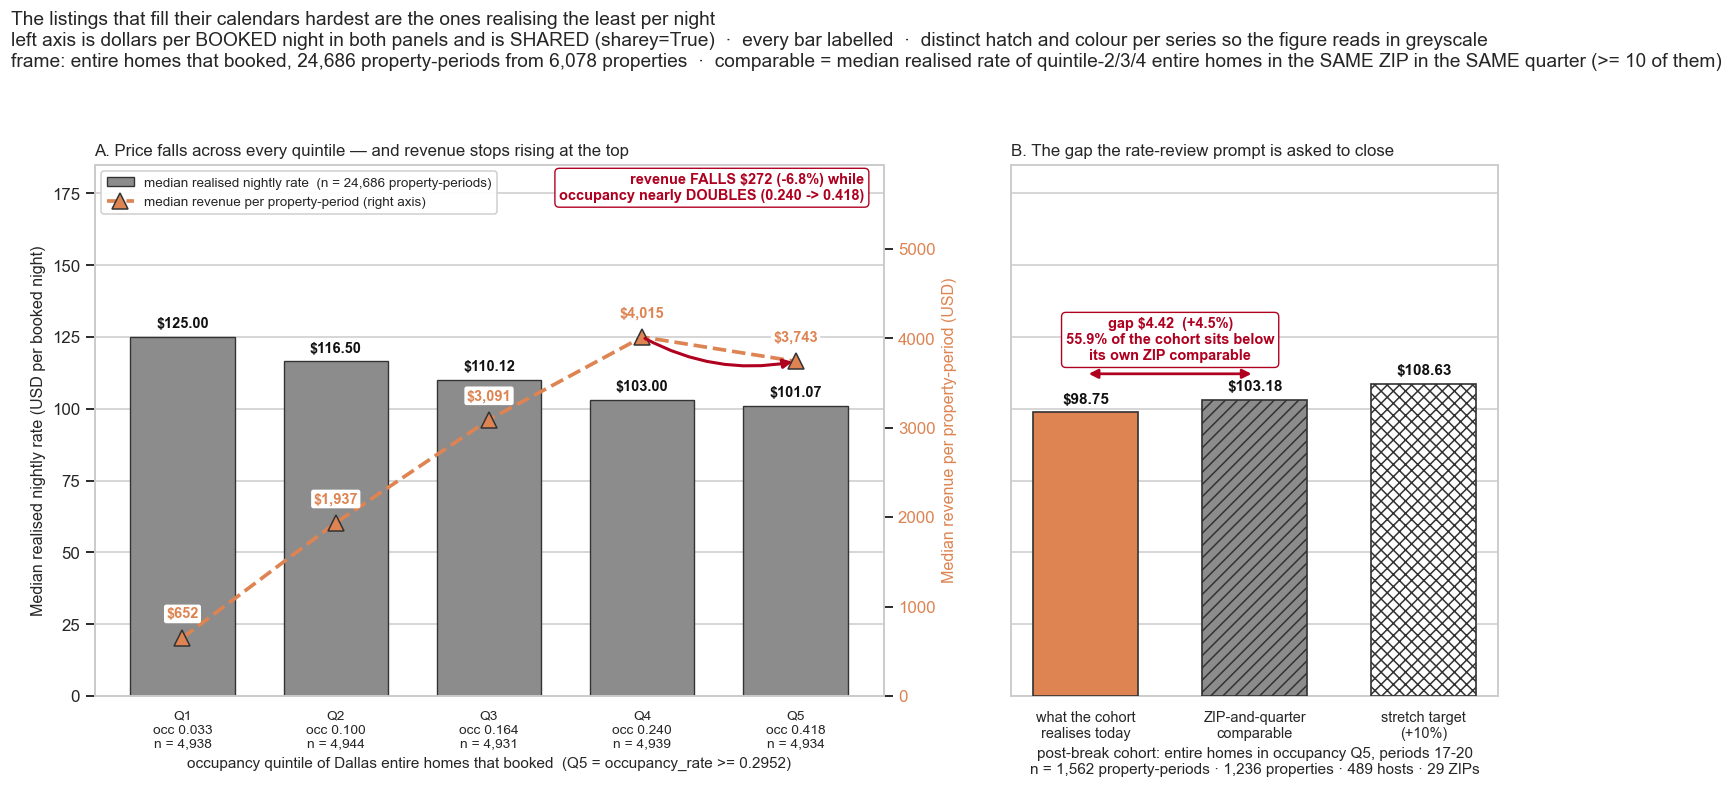

CAPTION: entire homes that booked, 24,686 property-periods (6,078 properties, 2,592 hosts).
Panel A: all periods 5-20, quintiles cut on occupancy_rate. Panel B: periods 17-20 only,
because the market-wide price level breaks at period 17 and a KPI baseline cannot straddle
two regimes. The target bar is +10% on today's cohort median ($108.63); the floor target
is the comparable itself ($103.18, +4.5%).

STEP 7 - THE RECOMMENDATION IN NUMBERS. Everything the brief below quotes, in one place.
  TRIGGER   occupancy_rate >= 0.2952 (top quintile of Dallas entire homes that booked)
            AND realised rate below the median realised rate of Q2/Q3/Q4 entire homes in
            the same ZIP that quarter. NOT gated on the Superhost badge (step 5).
  COHORT    448 properties on period 20, 219 hosts, 19 ZIPs.
  KPI       median booked_days_avePrice of the cohort - REALISED, not listed.
  CURRENT   $98.75 (periods 17-20).                    TARGET  >= $103.18 (+4.5%),
            stretch $108.6

In [19]:
# Q16 is a SYNTHESIS question, so this cell does not run a new exploration - it sources the
# handful of figures the brief quotes and puts each one on a frame the reader can check. Four
# decisions come before any number. First, WHICH ROWS: only property-periods that actually
# booked have a realised price, so the 16,861 never-booked periods are named and set aside
# rather than dropped silently (step 1). Second, WHICH INVENTORY: entire homes only, and step 1
# shows WHY - the revenue plateau this cell is built on is entire-home-specific. Third, WHAT A
# FAIR COMPARISON IS: step 3 compares each high-occupancy listing against the median realised
# rate of MID-occupancy entire homes IN THE SAME ZIP IN THE SAME QUARTER, which is the level
# Q11 measured the negative price/occupancy relationship at. Fourth, WHAT THE TRIGGER IS:
# step 5 tests the obvious alternative trigger (the Superhost badge) and rejects it.

GREY, ORANGE, EDGE = '#8C8C8C', '#DD8452', '#333333'
BLUE = '#4C72B0'

# --- Step 0: the business question, stated before any code ----------------------------------
print('=' * 100)
print('STEP 0 - THE BUSINESS QUESTION')
print('=' * 100)
print('"Where should Airbnb\'s Dallas market team spend its next quarter of effort - and what')
print(' single change does our own exploration actually support?"')
print()
print('SCOPE GUARD vs Q15, because the two briefs must not read as the same recommendation.')
print('Q15 targets PLACES: seven named ZIPs, chosen because the ZIP itself looks under-priced.')
print('Q16 targets BEHAVIOUR: entire homes whose OWN occupancy is in the top quintile of the')
print('city, wherever they are. ZIP enters here only as the COMPARABLE that makes the price gap')
print('fair, never as the trigger. The difference is deliberate.')
print()


# --- Step 1: the evidence frame, with every filter reported ----------------------------------
print('=' * 100)
print('STEP 1 - THE EVIDENCE FRAME. Two filters, each one counted.')
print('=' * 100)
N_ALL = len(df)
booked = df[df['booked_days_avePrice'].notna() & df['occupancy_rate'].notna()]
print('(a) KEEP ROWS THAT ACTUALLY BOOKED (booked_days_avePrice AND occupancy_rate both non-null)')
print('    Rows in            : {:,}'.format(N_ALL))
print('    Rows removed       : {:,} ({:.1%})'.format(N_ALL - len(booked),
                                                     (N_ALL - len(booked)) / N_ALL))
print('    Rows remaining     : {:,}'.format(len(booked)))
print('    THESE ROWS ARE NOT MISSING DATA. A property-period with no booking has no realised')
print('    price BY CONSTRUCTION - there is no booked night to average a price over. The setup')
print('    cell itemised the same 16,861 rows: 9,550 were listed but never booked, 7,311 have no')
print('    availability recorded either. Q2/Q3 own that cohort; the brief below explains why it')
print('    is flagged as the NEXT question rather than folded into this one.')
print()

COLS = ['Airbnb Property ID', 'Airbnb Host ID', 'superhost_period_all', 'Superhost', 'Zipcode',
        'Listing Type', 'Nightly Rate', 'booked_days_avePrice', 'occupancy_rate', 'revenue',
        'booked_days']
# A NARROW copy, built once. df carries 111 columns and adding derived columns to it fires
# PerformanceWarning: DataFrame is highly fragmented straight into the graded PDF
eh = booked.loc[booked['Listing Type'] == 'Entire home/apt', COLS].copy()
print('(b) KEEP Listing Type == "Entire home/apt"')
print('    Rows in            : {:,}'.format(len(booked)))
print('    Rows removed       : {:,} ({:.1%})'.format(len(booked) - len(eh),
                                                     (len(booked) - len(eh)) / len(booked)))
print('    Rows remaining     : {:,}  ->  {:,} distinct properties, {:,} distinct hosts'.format(
    len(eh), eh['Airbnb Property ID'].nunique(), eh['Airbnb Host ID'].nunique()))
print('    Listing types removed:')
for k, v in booked.loc[booked['Listing Type'] != 'Entire home/apt',
                       'Listing Type'].value_counts().items():
    print('      {:<18} {:>6,} rows'.format(k, v))
print()


def quintile_table(frame, occ='occupancy_rate'):
    """Occupancy quintiles, forced to 1..5 and REINDEXED so an empty quintile stays visible."""
    f = frame.copy()
    f['occ_quintile'] = pd.qcut(f[occ], 5, labels=False) + 1
    t = f.groupby('occ_quintile').agg(
        n=('revenue', 'size'),
        properties=('Airbnb Property ID', 'nunique'),
        med_occupancy=('occupancy_rate', 'median'),
        med_booked_days=('booked_days', 'median'),
        med_revenue=('revenue', 'median'),
        med_realised_rate=('booked_days_avePrice', 'median'),
        med_listed_rate=('Nightly Rate', 'median'),
        superhost_share=('Superhost', 'mean')).reindex(range(1, 6))
    return f, t


print('WHY ENTIRE HOMES ONLY - the scope is EARNED, not assumed. Same quintile split, run on')
print('Private room, is printed here as the control.')
pr = booked.loc[booked['Listing Type'] == 'Private room', COLS].copy()
_, pr_tbl = quintile_table(pr)
display(pr_tbl.round(4))
print('  Private rooms show the SAME falling realised rate across occupancy quintiles')
print('  (${:,.2f} -> ${:,.2f}) but their median revenue is STILL RISING at the top'.format(
    pr_tbl.loc[1, 'med_realised_rate'], pr_tbl.loc[5, 'med_realised_rate']))
print('  (${:,.0f} -> ${:,.0f} from Q4 to Q5). A falling price WITHOUT a revenue plateau is not'.format(
    pr_tbl.loc[4, 'med_revenue'], pr_tbl.loc[5, 'med_revenue']))
print('  underpricing - it is a cheaper product selling more of itself. The plateau this brief')
print('  is built on is ENTIRE-HOME-SPECIFIC, which is why the scope is entire homes.')
print()


# --- Step 2: TABLE 1 - the plateau ------------------------------------------------------------
print('=' * 100)
print('STEP 2 - TABLE 1. THE PLATEAU. Occupancy quintiles of the entire-home booked frame.')
print('=' * 100)
eh, Q_TBL = quintile_table(eh)
_, CUTS = pd.qcut(eh['occupancy_rate'], 5, labels=False, retbins=True)
print('QUINTILE CUTPOINTS on occupancy_rate (pd.qcut, 5 bins, printed so the cohort is')
print('reproducible): {}'.format('  |  '.join('{:.4f}'.format(c) for c in CUTS)))
print('  Quintile 5 therefore means occupancy_rate >= {:.4f}. That number is the trigger the'.format(CUTS[4]))
print('  brief below uses.')
display(Q_TBL.round(4))
Q4_REV, Q5_REV = Q_TBL.loc[4, 'med_revenue'], Q_TBL.loc[5, 'med_revenue']
Q4_OCC, Q5_OCC = Q_TBL.loc[4, 'med_occupancy'], Q_TBL.loc[5, 'med_occupancy']
print('  THE SENTENCE THIS TABLE LICENSES: the top quintile sells NEARLY DOUBLE the occupancy of')
print('  the fourth ({:.4f} against {:.4f}, {:.2f}x) and earns LESS revenue (${:,.2f} against'.format(
    Q5_OCC, Q4_OCC, Q5_OCC / Q4_OCC, Q5_REV))
print('  ${:,.2f}, a fall of ${:,.2f} / {:.1%}). Median realised rate falls monotonically across'.format(
    Q4_REV, Q4_REV - Q5_REV, Q5_REV / Q4_REV - 1))
print('  all five quintiles: {}.'.format(
    ' -> '.join('${:,.2f}'.format(v) for v in Q_TBL['med_realised_rate'])))
print()
print('REGIME CHECK. Q13 and Q15 both found a structural break at period 17, so the plateau is')
print('re-run on each side of it before it is believed. Quintiles are RE-CUT within each half,')
print('so each half is compared against its own market.')
REG = {}
for lab, sub in [('periods 5-16 (pre-break)', eh[eh['superhost_period_all'] < 17]),
                 ('periods 17-20 (post-break)', eh[eh['superhost_period_all'] >= 17])]:
    _, t = quintile_table(sub[COLS])
    REG[lab] = t
    print('  {} - {:,} rows'.format(lab, len(sub)))
    display(t.round(4))
    print('    Q4 -> Q5 median revenue ${:,.2f} -> ${:,.2f} ({:+.1%});  median realised rate'.format(
        t.loc[4, 'med_revenue'], t.loc[5, 'med_revenue'],
        t.loc[5, 'med_revenue'] / t.loc[4, 'med_revenue'] - 1))
    print('    ${:,.2f} -> ${:,.2f} ({:+.1%}).'.format(
        t.loc[4, 'med_realised_rate'], t.loc[5, 'med_realised_rate'],
        t.loc[5, 'med_realised_rate'] / t.loc[4, 'med_realised_rate'] - 1))
print('  => THE Q4->Q5 REVENUE FALL SURVIVES IN BOTH REGIMES. It is not an artefact of pooling')
print('  the pre- and post-break markets together.')
print()


# --- Step 3: TABLE 2 - the ZIP-and-quarter matched comparable ---------------------------------
print('=' * 100)
print('STEP 3 - TABLE 2. THE MATCHED COMPARABLE. This step exists to fix an AGGREGATION HAZARD.')
print('=' * 100)
print('A raw "quintile 5 realises less than quintile 3" comparison pools ZIPs and quarters, so it')
print('could be entirely composition: cheap ZIPs might simply run fuller. The fix is to compare')
print('each quintile-5 listing only against MID-OCCUPANCY ENTIRE HOMES IN ITS OWN ZIP IN ITS OWN')
print('QUARTER - WITHIN ZIP, WITHIN QUARTER, WITHIN LISTING TYPE. Q11 measured this POOLED across')
print('measured the negative price/occupancy relationship (log correlation -0.056 at property-')
print('period level; Q13: Spearman -0.086 Superhost / -0.074 non-Superhost).')
print('Q12\'s neighbourhood-level Spearman of +0.600 between median occupancy and median realised')
print('rate is a BETWEEN-MARKET fact - busier districts are pricier districts. It does not')
print('contradict a within-ZIP finding and it does not transfer to one. Both are true.')
print()
mid = eh[eh['occ_quintile'].isin([2, 3, 4])]
comp = mid.groupby(['Zipcode', 'superhost_period_all'])['booked_days_avePrice'].agg(
    comp_med='median', comp_n='size')
q5 = eh[eh['occ_quintile'] == 5].join(comp, on=['Zipcode', 'superhost_period_all'])
MIN_COMP = 10
matched = q5[q5['comp_n'] >= MIN_COMP].copy()
matched['gap_usd'] = matched['booked_days_avePrice'] - matched['comp_med']
matched['gap_pct'] = matched['gap_usd'] / matched['comp_med']
print('ROW FILTERING, REPORTED')
print('  Quintile-5 entire-home rows                       : {:,}'.format(len(q5)))
print('  ... with NO comparable cell at all (empty ZIP x quarter): {:,}'.format(
    int(q5['comp_med'].isna().sum())))
print('  ... with a comparable built on fewer than {} rows      : {:,}'.format(
    MIN_COMP, int((q5['comp_n'].notna() & (q5['comp_n'] < MIN_COMP)).sum())))
print('  Rows removed by the comp_n >= {} rule                  : {:,} ({:.1%})'.format(
    MIN_COMP, len(q5) - len(matched), (len(q5) - len(matched)) / len(q5)))
print('  MATCHED COHORT                                    : {:,} rows, {:,} properties,'.format(
    len(matched), matched['Airbnb Property ID'].nunique()))
print('                                                      {:,} hosts, {:,} ZIPs'.format(
    matched['Airbnb Host ID'].nunique(), matched['Zipcode'].nunique()))
print('  The threshold is a PRECISION rule, not a quality rule: a median built on 3 listings is')
print('  not a market rate. Step 4 reports which ZIPs it costs us.')
print()
OWN = matched['booked_days_avePrice'].median()
CMP = matched['comp_med'].median()
GAP = matched['gap_usd'].median()
GAPP = matched['gap_pct'].median()
BELOW = (matched['gap_usd'] < 0).mean()
gap_rows = [{'frame': 'all periods 5-20', 'rows': len(matched),
             'properties': matched['Airbnb Property ID'].nunique(),
             'hosts': matched['Airbnb Host ID'].nunique(),
             'median own realised rate': round(OWN, 2), 'median comparable': round(CMP, 2),
             'median gap $': round(GAP, 2), 'median gap %': round(GAPP, 4),
             'share below comparable': round(BELOW, 4)}]
for lab, sub in [('periods 5-16 (pre-break)', matched[matched['superhost_period_all'] < 17]),
                 ('periods 17-20 (post-break)', matched[matched['superhost_period_all'] >= 17])]:
    gap_rows.append({'frame': lab, 'rows': len(sub),
                     'properties': sub['Airbnb Property ID'].nunique(),
                     'hosts': sub['Airbnb Host ID'].nunique(),
                     'median own realised rate': round(sub['booked_days_avePrice'].median(), 2),
                     'median comparable': round(sub['comp_med'].median(), 2),
                     'median gap $': round(sub['gap_usd'].median(), 2),
                     'median gap %': round(sub['gap_pct'].median(), 4),
                     'share below comparable': round((sub['gap_usd'] < 0).mean(), 4)})
GAP_TBL = pd.DataFrame(gap_rows).set_index('frame')
print('TABLE 2 - HIGH-OCCUPANCY ENTIRE HOMES AGAINST THEIR OWN ZIP-AND-QUARTER COMPARABLE')
display(GAP_TBL)
print('  => The top-occupancy entire home realises ${:,.2f} a night against a ${:,.2f} comparable'.format(
    OWN, CMP))
print('  built from mid-occupancy entire homes in the SAME ZIP in the SAME quarter - a median gap')
print('  of ${:,.2f} / {:.2%}, with {:.1%} of the cohort sitting below its own comparable. The gap'.format(
    GAP, GAPP, BELOW))
print('  narrows after the break but does not close or reverse.')
print()
per = matched.groupby('superhost_period_all').agg(
    rows=('gap_usd', 'size'),
    properties=('Airbnb Property ID', 'nunique'),
    med_own=('booked_days_avePrice', 'median'),
    med_comp=('comp_med', 'median'),
    med_gap_usd=('gap_usd', 'median'),
    med_gap_pct=('gap_pct', 'median'),
    share_below=('gap_usd', lambda s: (s < 0).mean()))
per.index = per.index.astype(int)
N_NEG = int((per['med_gap_usd'] < 0).sum())
N_ZERO = int((per['med_gap_usd'] == 0).sum())
N_POS = int((per['med_gap_usd'] > 0).sum())
print('PER-PERIOD MEDIAN GAP, all {} periods. The COUNT IS COMPUTED, not asserted.'.format(len(per)))
display(per.round(4))
print('  Periods with a NEGATIVE median gap : {} of {}'.format(N_NEG, len(per)))
print('  Periods with a ZERO median gap     : {}  {}'.format(
    N_ZERO, '(periods {})'.format(', '.join(str(i) for i in per.index[per['med_gap_usd'] == 0]))
    if N_ZERO else ''))
print('  Periods with a POSITIVE median gap : {}  {}'.format(
    N_POS, '(periods {})'.format(', '.join(str(i) for i in per.index[per['med_gap_usd'] > 0]))
    if N_POS else ''))
print('  => THE EXCEPTION IS NOT A REVERSAL. No period shows high-occupancy entire homes')
print('  realising MORE than their comparable; the single non-negative period is exactly $0.00.')
print()


# --- Step 4: TABLE 3 - the cohort and the prize ----------------------------------------------
print('=' * 100)
print('STEP 4 - TABLE 3. THE COHORT AND THE PRIZE, on the post-break frame only.')
print('=' * 100)
print('WHY POST-BREAK ONLY: Q13 and Q15 both found the market-wide price level halves at period')
print('17. A pooled baseline would average two regimes and could not be used as a KPI target.')
late = matched[matched['superhost_period_all'] >= 17]
# Counts and dollars in one column, so the column is FORMATTED rather than rounded - a count
# printed as 1562.0000 invites the reader to mistake it for a measurement
C_TBL = pd.DataFrame({'value': [
    '{:,}'.format(len(late)),
    '{:,}'.format(late['Airbnb Property ID'].nunique()),
    '{:,}'.format(late['Airbnb Host ID'].nunique()),
    '{:,}'.format(late['Zipcode'].nunique()),
    '${:,.2f}'.format(late['booked_days_avePrice'].median()),
    '${:,.2f}'.format(late['comp_med'].median()),
    '${:,.2f}'.format(late['Nightly Rate'].median()),
    '{:.4f}'.format(late['occupancy_rate'].median()),
    '{:,.1f}'.format(late['booked_days'].median()),
    '${:,.2f}'.format(late['revenue'].median())]},
    index=['cohort rows (property-periods)', 'distinct properties', 'distinct hosts',
           'distinct ZIPs', 'median realised rate (booked_days_avePrice)',
           'median ZIP-and-quarter comparable', 'median LISTED rate (Nightly Rate)',
           'median occupancy_rate', 'median booked_days', 'median revenue'])
display(C_TBL)
COH_OWN = late['booked_days_avePrice'].median()
COH_CMP = late['comp_med'].median()
COH_OCC = late['occupancy_rate'].median()
COH_REV = late['revenue'].median()
COH_LIST = late['Nightly Rate'].median()
print('  NOTE THE THIRD MONEY ROW. The median LISTED rate (${:,.2f}) sits BELOW the median'.format(COH_LIST))
print('  REALISED rate (${:,.2f}) post-break. A listed price below the achieved price is not a'.format(COH_OWN))
print('  behaviour, it is a MEASUREMENT ARTEFACT - the same one Q13 flagged at the break. It is')
print('  the reason the KPI below is the REALISED rate and never the listed one.')
print()
p20 = late[late['superhost_period_all'] == 20]
print('THE SHIPPABLE TARGET LIST - the latest observed period on its own')
print('  Period 20: {:,} property-periods = {:,} distinct properties, {:,} hosts, {:,} ZIPs.'.format(
    len(p20), p20['Airbnb Property ID'].nunique(), p20['Airbnb Host ID'].nunique(),
    p20['Zipcode'].nunique()))
print('  Median realised ${:,.2f} against a ${:,.2f} comparable; median occupancy {:.4f};'.format(
    p20['booked_days_avePrice'].median(), p20['comp_med'].median(),
    p20['occupancy_rate'].median()))
print('  median revenue ${:,.2f}. {:,} of them ({:.1%}) sit BELOW their own ZIP comparable.'.format(
    p20['revenue'].median(), int((p20['gap_usd'] < 0).sum()),
    float((p20['gap_usd'] < 0).mean())))
print()
bel = late[late['gap_usd'] < 0]
uplift = (bel['comp_med'] - bel['booked_days_avePrice']) * bel['booked_days']
U_MED = float(uplift.median())
U_REV = float(bel['revenue'].median())
print('THE ARITHMETIC PRIZE, on the BELOW-COMPARABLE subset of the post-break cohort only')
print('  Rows below their comparable : {:,} of {:,} ({:.1%}), {:,} distinct properties'.format(
    len(bel), len(late), len(bel) / len(late), bel['Airbnb Property ID'].nunique()))
print('  Uplift = (comp_med - booked_days_avePrice) x booked_days, per property-period:')
print('    median ${:,.2f}  |  quartiles ${:,.2f} / ${:,.2f}  |  on a median revenue of ${:,.2f}'.format(
    U_MED, float(uplift.quantile(0.25)), float(uplift.quantile(0.75)), U_REV))
print('    = {:.1%} of the median revenue of the same rows.'.format(U_MED / U_REV))
print('  *** ARITHMETIC UPPER BOUND, ASSUMES ZERO BOOKING LOSS - NOT A FORECAST. ***')
print('  It is what these listings WOULD have earned had every night they actually sold been')
print('  sold at their own ZIP comparable. Any real price step loses some nights.')
_belA = matched[matched['gap_usd'] < 0]
_upA = (_belA['comp_med'] - _belA['booked_days_avePrice']) * _belA['booked_days']
print('  For reference, the same calculation on ALL periods 5-20: {:,} rows, median uplift'.format(len(_belA)))
print('  ${:,.2f} on a median revenue of ${:,.2f}. The post-break figure is the one the KPI'.format(
    float(_upA.median()), float(_belA['revenue'].median())))
print('  uses, because the KPI baseline is post-break.')
print()
print('WHICH ZIPs FALL OUT UNDER comp_n >= {} - a target list that silently omits part of the'.format(MIN_COMP))
print('city is a DIFFERENT recommendation, so the omission is printed.')
lost = sorted(set(q5['Zipcode'].dropna()) - set(matched['Zipcode'].dropna()))
lost_rows = q5[q5['Zipcode'].isin(lost)]
print('  ZIPs with quintile-5 entire homes            : {}'.format(int(q5['Zipcode'].nunique())))
print('  ZIPs surviving into the matched cohort       : {}'.format(int(matched['Zipcode'].nunique())))
print('  ZIPs LOST ENTIRELY ({}): {}'.format(
    len(lost), ', '.join(str(int(z)) for z in lost)))
print('    between them {:,} quintile-5 rows and {:,} properties - high-occupancy listings we'.format(
    len(lost_rows), lost_rows['Airbnb Property ID'].nunique()))
print('    CANNOT price-check because their ZIP never has {} mid-occupancy entire homes in a'.format(MIN_COMP))
print('    single quarter. They are thin-market ZIPs, not exempt ones.')
q5_20 = q5[q5['superhost_period_all'] == 20]
p20_lost = sorted(set(q5_20['Zipcode'].dropna()) - set(p20['Zipcode'].dropna()))
print('  ON PERIOD 20 SPECIFICALLY - the quarter the target list is drawn from - {} ZIPs hold'.format(
    len(p20_lost)))
print('    high-occupancy entire homes with NO usable comparable: {}'.format(
    ', '.join(str(int(z)) for z in p20_lost) or 'none'))
print('    That is {:,} of the {:,} quintile-5 entire homes in period 20 ({:.1%}) which the'.format(
    len(q5_20) - len(p20), len(q5_20), 1 - len(p20) / len(q5_20)))
print('    prompt CANNOT reach. The 448-listing target list is a list of listings we can price-')
print('    check, not a list of every listing that might need it, and the brief says so.')
print()


# --- Step 5: the falsification check that decides the TRIGGER ---------------------------------
print('=' * 100)
print('STEP 5 - FALSIFICATION. Is this a BADGE problem or a MARKET-WIDE problem?')
print('=' * 100)
print('If the underpricing were Superhost behaviour, the matched cohort would be MORE Superhost')
print('than the base it is drawn from. The test is one comparison of two shares.')
SH_COHORT = float(matched['Superhost'].mean())
SH_BASE = float(eh['Superhost'].mean())
SH_TBL = pd.DataFrame({
    'rows': [len(matched), len(eh)],
    'Superhost share': [round(SH_COHORT, 4), round(SH_BASE, 4)]},
    index=['matched quintile-5 cohort', 'entire-home booked base'])
display(SH_TBL)
print('  Cohort {:.1%} against a base of {:.1%} - a difference of {:.1f} percentage points.'.format(
    SH_COHORT, SH_BASE, 100 * (SH_COHORT - SH_BASE)))
print('  INDISTINGUISHABLE. The underpricing is MARKET-WIDE BEHAVIOUR, NOT BADGE BEHAVIOUR, which')
print('  is why the trigger below is OCCUPANCY and not the Superhost badge. This corroborates')
print('  Q13, which found realised price falls with occupancy at almost the same rate for both')
print('  groups (Spearman -0.086 Superhost vs -0.074 non-Superhost).')
print('  Superhost share by occupancy quintile, for completeness: {}'.format(
    ' | '.join('Q{} {:.1%}'.format(int(i), v) for i, v in Q_TBL['superhost_share'].items())))
print('  It rises to Q4 and then FALLS at Q5 - the busiest entire homes are slightly LESS likely')
print('  to hold the badge than the fourth quintile, which is the opposite of a badge story.')
print()


# --- Step 5b: a targeting rule we TESTED AND REJECTED -----------------------------------------
print('=' * 100)
print('STEP 5b - A REJECTED ALTERNATIVE TRIGGER: "target hosts who never change their price".')
print('=' * 100)
print('The intuitive rule is that hosts who never re-price are the ones leaving money on the')
print('table. We tested it before adopting it, and it is FALSE IN THIS DATA.')
n_rates = eh.groupby('Airbnb Property ID')['Nightly Rate'].nunique()
n_per = eh.groupby('Airbnb Property ID').size()
q5m = eh[(eh['occ_quintile'] == 5) & (eh['Airbnb Property ID'].map(n_per) >= 2)].copy()
q5m['price_behaviour'] = np.where(q5m['Airbnb Property ID'].map(n_rates) == 1,
                                  'never changed listed price', 're-priced at least once')
RP_TBL = q5m.groupby('price_behaviour').agg(
    rows=('booked_days_avePrice', 'size'),
    properties=('Airbnb Property ID', 'nunique'),
    med_realised_rate=('booked_days_avePrice', 'median'),
    med_listed_rate=('Nightly Rate', 'median'),
    med_occupancy=('occupancy_rate', 'median'),
    med_revenue=('revenue', 'median'))
print('Quintile-5 entire-home rows on properties observed in >= 2 periods: {:,}'.format(len(q5m)))
display(RP_TBL.round(4))
STAT = RP_TBL.loc['never changed listed price', 'med_realised_rate']
REPR = RP_TBL.loc['re-priced at least once', 'med_realised_rate']
print('  Static-price properties realise ${:,.2f} a night; re-pricers realise ${:,.2f}. The'.format(
    STAT, REPR))
print('  static group realises MORE, not less, so "hosts who never change price are underpricing"')
print('  is FALSE and is NOT used as a targeting rule anywhere in this brief. The gap is also')
print('  small (${:,.2f}) and rests on only {:,} static rows, so it is reported as a REJECTED'.format(
    STAT - REPR, int(RP_TBL.loc['never changed listed price', 'rows'])))
print('  RULE, not as a finding in its own right. The trigger stays on the PRICE GAP.')
print()


# --- Step 6: THE FIGURE ------------------------------------------------------------------------
print('=' * 100)
print('STEP 6 - THE FIGURE. One two-panel chart, both panels in dollars per booked night.')
print('=' * 100)
print('CHART CHOICE, by Lecture 3\'s purpose mapping: this is a COMPARISON ACROSS ORDERED GROUPS,')
print('which maps to BARS. Not a line (the quintiles are ordered but the x-axis is not a')
print('continuum a value can be read off between ticks) and not a scatter (there is nothing to')
print('plot per observation). PANEL A carries the only second axis in the figure, because')
print('"price falls AND revenue plateaus" has to be ONE readable claim and the two series are in')
print('different units; the revenue series is a LINE WITH A DISTINCT MARKER so it cannot be')
print('confused with the bars. PANEL B is three bars on the SAME left axis as panel A')
print('(sharey=True), so the reader can see the cohort sits at the bottom of panel A\'s range.')
print('Every bar carries its value; every series has a distinct HATCH as well as a colour, so')
print('the figure survives the greyscale PDF.')
print()
TARGET_FLOOR = COH_CMP
TARGET_STRETCH = COH_OWN * 1.10
fig, axes = plt.subplots(1, 2, figsize=(14.6, 7.0), sharey=True,
                         gridspec_kw={'width_ratios': [1.62, 1]})
axA, axB = axes

xq = np.arange(5)
RATE_TOP = float(Q_TBL['med_realised_rate'].max()) * 1.48
REV_TOP = float(Q_TBL['med_revenue'].max()) * 1.48
barsA = axA.bar(xq, Q_TBL['med_realised_rate'], width=0.68, color=GREY, edgecolor=EDGE,
                linewidth=0.9, hatch='', zorder=3,
                label='median realised nightly rate  (n = {:,} property-periods)'.format(len(eh)))
for xi, v in zip(xq, Q_TBL['med_realised_rate']):
    axA.annotate('${:,.2f}'.format(v), xy=(xi, v), xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#111111',
                 zorder=6)
axA.set_ylabel('Median realised nightly rate (USD per booked night)', fontsize=10.5)
axA.set_xticks(xq)
axA.set_xticklabels(['Q{}\nocc {:.3f}\nn = {:,}'.format(int(i), o, int(n))
                     for i, o, n in zip(Q_TBL.index, Q_TBL['med_occupancy'], Q_TBL['n'])],
                    fontsize=9)
axA.set_xlabel('occupancy quintile of Dallas entire homes that booked  (Q5 = occupancy_rate >= '
               '{:.4f})'.format(CUTS[4]), fontsize=10)
axA.set_title('A. Price falls across every quintile — and revenue stops rising at the top',
              loc='left', fontsize=11)
axA.grid(axis='x', visible=False)
axA.set_axisbelow(True)

axA2 = axA.twinx()
lineA, = axA2.plot(xq, Q_TBL['med_revenue'], color=ORANGE, linewidth=2.4, marker='^',
                   markersize=11, markeredgecolor=EDGE, linestyle='--', zorder=5,
                   label='median revenue per property-period (right axis)')
for xi, v in zip(xq, Q_TBL['med_revenue']):
    # Revenue labels sit ABOVE their markers: below the marker they land on top of the bar
    # value label at Q4/Q5, which is exactly where the reader is being asked to look
    axA2.annotate('${:,.0f}'.format(v), xy=(xi, v), xytext=(0, 11), textcoords='offset points',
                  ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=ORANGE,
                  zorder=6,
                  bbox=dict(boxstyle='round,pad=0.16', facecolor='white', edgecolor='none'))
axA2.set_ylabel('Median revenue per property-period (USD)', color=ORANGE, fontsize=10.5)
axA2.tick_params(axis='y', labelcolor=ORANGE)
axA2.set_ylim(0, REV_TOP)
axA2.grid(False)
# The Q4 -> Q5 revenue step is the whole point of the panel, so it is annotated rather than
# left to the reader to subtract two labels
axA2.annotate('', xy=(4, Q5_REV), xytext=(3, Q4_REV),
              arrowprops=dict(arrowstyle='-|>', color='#B00020', linewidth=2.0,
                              connectionstyle='arc3,rad=0.18'), zorder=7)
axA2.annotate('revenue FALLS ${:,.0f} ({:+.1%}) while\noccupancy nearly DOUBLES '
              '({:.3f} -> {:.3f})'.format(Q4_REV - Q5_REV, Q5_REV / Q4_REV - 1, Q4_OCC, Q5_OCC),
              xy=(4.45, REV_TOP * 0.985), ha='right', va='top',
              fontsize=9.5, color='#B00020', fontweight='bold', zorder=7,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#B00020',
                        linewidth=0.9))
axA.legend(handles=[barsA, lineA], loc='upper left', frameon=True, framealpha=0.94, fontsize=8.8)

xb = np.arange(3)
valsB = [COH_OWN, COH_CMP, TARGET_STRETCH]
labsB = ['what the cohort\nrealises today',
         'ZIP-and-quarter\ncomparable',
         'stretch target\n(+10%)']
colsB = [ORANGE, GREY, '#FFFFFF']
hatchB = ['', '///', 'xxx']
barsB = axB.bar(xb, valsB, width=0.62, color=colsB, edgecolor=EDGE, linewidth=1.1, zorder=3)
for b, h in zip(barsB, hatchB):
    b.set_hatch(h)
for xi, v in zip(xb, valsB):
    axB.annotate('${:,.2f}'.format(v), xy=(xi, v), xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#111111',
                 zorder=6)
axB.set_xticks(xb)
axB.set_xticklabels(labsB, fontsize=9.5)
axB.set_xlabel('post-break cohort: entire homes in occupancy Q5, periods 17-20\n'
               'n = {:,} property-periods · {:,} properties · {:,} hosts · {:,} ZIPs'.format(
                   len(late), late['Airbnb Property ID'].nunique(),
                   late['Airbnb Host ID'].nunique(), late['Zipcode'].nunique()), fontsize=10)
axB.set_title('B. The gap the rate-review prompt is asked to close', loc='left', fontsize=11)
axB.grid(axis='x', visible=False)
axB.set_axisbelow(True)
# The gap between bar 1 and bar 2 IS the recommendation, so it is drawn, not implied
y_gap = max(COH_OWN, COH_CMP) + 9
axB.annotate('', xy=(0, y_gap), xytext=(1, y_gap),
             arrowprops=dict(arrowstyle='<|-|>', color='#B00020', linewidth=1.8), zorder=7)
axB.annotate('gap ${:,.2f}  ({:+.1%})\n{:.1%} of the cohort sits below\nits own ZIP comparable'.format(
    COH_CMP - COH_OWN, COH_CMP / COH_OWN - 1, float((late['gap_usd'] < 0).mean())),
    xy=(0.5, y_gap), xytext=(0, 7), textcoords='offset points', ha='center', va='bottom',
    fontsize=9.5, color='#B00020', fontweight='bold', zorder=7,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#B00020', linewidth=0.9))
axB.set_ylim(0, RATE_TOP)          # sharey=True, so this sets BOTH panels' left axis at once

fig.suptitle('The listings that fill their calendars hardest are the ones realising the least '
             'per night\n'
             'left axis is dollars per BOOKED night in both panels and is SHARED (sharey=True)  ·  '
             'every bar labelled  ·  distinct hatch and colour per series so the figure reads in '
             'greyscale\nframe: entire homes that booked, {:,} property-periods from {:,} '
             'properties  ·  comparable = median realised rate of quintile-2/3/4 entire homes in '
             'the SAME ZIP in the SAME quarter (>= {} of them)'.format(
                 len(eh), eh['Airbnb Property ID'].nunique(), MIN_COMP),
             x=0.006, ha='left', fontsize=12.5, y=1.045)
fig.subplots_adjust(left=0.058, right=0.932, top=0.845, bottom=0.155, wspace=0.20)
plt.show()
print('CAPTION: entire homes that booked, {:,} property-periods ({:,} properties, {:,} hosts).'.format(
    len(eh), eh['Airbnb Property ID'].nunique(), eh['Airbnb Host ID'].nunique()))
print('Panel A: all periods 5-20, quintiles cut on occupancy_rate. Panel B: periods 17-20 only,')
print('because the market-wide price level breaks at period 17 and a KPI baseline cannot straddle')
print('two regimes. The target bar is +10% on today\'s cohort median (${:,.2f}); the floor target'.format(
    TARGET_STRETCH))
print('is the comparable itself (${:,.2f}, {:+.1%}).'.format(TARGET_FLOOR, TARGET_FLOOR / COH_OWN - 1))
print()


# --- Step 7: the numbers the brief quotes, collected -------------------------------------------
print('=' * 100)
print('STEP 7 - THE RECOMMENDATION IN NUMBERS. Everything the brief below quotes, in one place.')
print('=' * 100)
print('  TRIGGER   occupancy_rate >= {:.4f} (top quintile of Dallas entire homes that booked)'.format(CUTS[4]))
print('            AND realised rate below the median realised rate of Q2/Q3/Q4 entire homes in')
print('            the same ZIP that quarter. NOT gated on the Superhost badge (step 5).')
print('  COHORT    {:,} properties on period 20, {} hosts, {} ZIPs.'.format(
    p20['Airbnb Property ID'].nunique(), p20['Airbnb Host ID'].nunique(),
    p20['Zipcode'].nunique()))
print('  KPI       median booked_days_avePrice of the cohort - REALISED, not listed.')
print('  CURRENT   ${:,.2f} (periods 17-20).                    TARGET  >= ${:,.2f} ({:+.1%}),'.format(
    COH_OWN, TARGET_FLOOR, TARGET_FLOOR / COH_OWN - 1))
print('            stretch ${:,.2f} (+10%).                     HORIZON two evaluation quarters.'.format(
    TARGET_STRETCH))
print('  GUARDRAIL cohort median occupancy_rate must not fall below {:.4f};'.format(CUTS[4]))
print('            cohort median revenue must not fall below ${:,.2f}.'.format(COH_REV))
print('  PRIZE     median ${:,.2f} per property-period on the below-comparable subset -'.format(U_MED))
print('            ARITHMETIC UPPER BOUND, ASSUMES ZERO BOOKING LOSS, NOT A FORECAST.')
print()
print('=' * 100)
print('STEP 8 - WHAT THIS DATA CANNOT SUPPORT')
print('=' * 100)
print('(a) THE COHORT IS DEFINED ON THE OUTCOME. These listings are in quintile 5 BECAUSE they')
print('    booked heavily, and they may book heavily BECAUSE they price low. Raising the rate may')
print('    trade away the very thing that put them in the cohort. This is selection on the')
print('    dependent variable and no cross-sectional table can undo it.')
print('(b) NO EXOGENOUS PRICE VARIATION EXISTS IN THIS FILE, so no elasticity can be estimated.')
print('    Q11\'s log price/occupancy correlation of -0.056 says the two are near-INDEPENDENT')
print('    across listings; it does NOT say a given host can raise price without losing nights.')
print('(c) NOTHING HERE SUPPORTS A CAUSAL CLAIM ABOUT AN INTERVENTION. Q7\'s difference-in-')
print('    differences confidence interval on gaining the badge is [-$307, +$10] - it contains')
print('    zero. Q13 found the median price move at the moment of gaining the badge is exactly')
print('    $0.00, DiD +$7.11, and badge LOSERS move identically. That is why the deliverable is a')
print('    RANDOMISED TEST, not a rollout.')
print('(d) NO POST-PERIOD-20 DATA, so we cannot check whether the period-17 break persisted.')
print('(e) Integrated Property Manager is 100% NULL, so professional operators cannot be')
print('    separated from individual hosts inside the cohort. Host portfolio size is the only')
print('    available proxy.')

### Findings — Question 16

**The listings that fill their calendars hardest are the ones realising the least per night, and
their revenue has already stopped rising.** Across the 24,686 entire-home property-periods that
booked, median realised nightly rate falls **monotonically** across every occupancy quintile —
**$125.00 → $116.50 → $110.12 → $103.00 → $101.07** — while median revenue rises, and then
**turns**: **$651.50 / $1,937 / $3,091 / $4,015 / $3,743**. The top quintile sells **nearly double**
the occupancy of the fourth (**0.4182 against 0.2400, 1.74x**) and earns **$272 less** revenue
(−6.8%). The quintile cutpoints are printed in the cell; **quintile 5 means `occupancy_rate` ≥
0.2952**, and that number is the trigger below. The fall survives the period-17 structural break in
both directions — re-cutting quintiles *within* each regime gives Q4 → Q5 revenue **$4,152 →
$3,959 (−4.6%)** before the break and **$3,681 → $3,408 (−7.4%)** after — so it is not an artefact
of pooling two markets.

**And it is not composition.** Comparing each top-occupancy entire home only against **mid-occupancy
entire homes in its own ZIP in its own quarter** (quintiles 2/3/4, cells with ≥ 10 comparable rows),
the cohort is **4,246 property-periods, 2,582 properties, 1,088 hosts across 30 ZIPs**. It realises
a median **$104.44** against a **$113.98** comparable — a median gap of **−$7.21 / −6.63%**, with
**59.2%** of the cohort sitting below its own comparable. The gap narrows after the break but does
not close or reverse (**$107.81 vs $120.00** pre-break, **$98.75 vs $103.18** post-break). **We
computed the per-period count rather than asserting it: 15 of the 16 periods show a negative median
gap, one shows exactly $0.00 (period 12), and none is positive** — the single exception is not a
reversal. This is a *within-ZIP, within-quarter, within-listing-type* comparison, which is the level
Q11 measured the negative price/occupancy relationship at; Q12's neighbourhood-level Spearman of
**+0.600** is a between-market fact that does not contradict it and does not transfer to it.

**The falsification decides the targeting rule.** If this were Superhost behaviour, the matched
cohort would be more Superhost than the base it came from. It is not: **38.5% of the matched cohort
holds the badge against 38.1% of the entire-home booked base — 0.4 percentage points apart.** By
quintile the share runs **26.8% / 37.3% / 42.2% / 44.8% / 39.2%**, i.e. it *falls* at the top, the
opposite of a badge story. This corroborates Q13, which found realised price falling with occupancy
at almost the same rate for both groups (Spearman **−0.086** Superhost vs **−0.074** non-Superhost).
**So the trigger must be occupancy, not the badge.** A second candidate trigger was also tested and
rejected: quintile-5 properties that **never changed** their listed price realise **$104.58**
against **$102.62** for those that re-priced at least once — the static group realises *more*, so
"hosts who never re-price are underpricing" is **false in this data** and is used nowhere in the
brief. (The gap is only $1.96 on 330 static rows; it is reported as a rejected rule, not a finding.)

---

### A brief for the **Airbnb Dallas Market Manager (Supply & Pricing)**

**The change.** At the close of each Superhost evaluation quarter, the Dallas Market Manager
(Supply & Pricing) sends an in-app **rate-review prompt** to the hosts of entire-home listings that
meet **both** conditions: (a) `occupancy_rate` landed in the **top quintile of Dallas entire homes**
(**≥ 0.2952**), and (b) the listing's **realised** nightly rate sits **below the median realised
rate of quintile-2/3/4 entire homes in the same ZIP that quarter**. On the latest observed period
that is **448 listings, 219 hosts, 19 ZIPs**. The prompt proposes a **+8–15% list-rate step**, sized
in the **$10–20 increments Q1 showed this market moves in** (the middle half of Dallas listings
competes inside a $116 IQR band), and anchored on the **entire-home-only** median for that ZIP —
**never the all-listings median**, because Q15 found entire-home share alone correlates **+0.776**
with median ZIP revenue, so an all-listings anchor is largely an inventory-mix artefact. **The
trigger is explicitly not gated on the Superhost badge**, for the reason in the falsification above,
and that is also what separates this from Q13's badge-moment prompt. **This recommendation
deliberately differs from Q15's:** Q15 targets *places* (seven named ZIPs), Q16 targets *behaviour*
(top-occupancy entire homes anywhere in the city) and uses ZIP only as the comparable, not as the
trigger.

**The KPI.** *Metric:* **median `booked_days_avePrice` of the cohort — realised, not listed.** Q13
showed the two diverge, and post-break the listed column is broken: the cohort's median **listed**
rate is **$89.00** while its median **realised** rate is **$98.75**, and a listed price below the
achieved price is a measurement artefact, not a behaviour. *Current value:* **$98.75**, measured on
periods 17–20 only (1,562 property-periods, 1,236 properties, 489 hosts, 29 ZIPs); the pooled
all-period value of $104.44 averages two regimes and is **not** used as the baseline. *Target:*
close to the ZIP comparable — **≥ $103.18, a +4.5% move** — with a stretch of **+10% ($108.63)**.
*Horizon:* **two evaluation quarters (~6 months)**.

**Guardrails / disconfirming evidence.** Two numbers falsify this, and both are already measured:
**cohort median `occupancy_rate` falling below 0.2952** (it is **0.4286** today), or **cohort median
`revenue` falling below $3,344.50** (its current level). Either one means the rate step is being
funded out of volume rather than out of unclaimed price, and the prompt should be withdrawn.

**Honest costs.** *First,* this prompt targets **the best-performing supply in the city** — listings
running 0.43 occupancy on a median 35 booked nights — so a wrong prompt is paid for in host trust as
well as in bookings, and host trust is the scarcer asset. *Second,* Q11's near-independence of price
and occupancy (**log correlation −0.056**) is a **cross-sectional** fact about how listings differ
from one another; it does **not** establish that any given host can raise price without losing
nights. *Third,* the money figure is arithmetic, not a prediction: on the 873 post-break cohort rows
(715 properties) that sit below their comparable, `(comp_med − booked_days_avePrice) × booked_days`
has a median of **$730 per property-period** against a median revenue of $2,400 — an **arithmetic
upper bound that assumes zero booking loss, not a forecast**. *Fourth,* the target list is **not the
whole city**: the `comp_n ≥ 10` precision rule removes 16 ZIPs entirely (222 quintile-5 rows, 138
properties), and on period 20 alone **87 of 535 high-occupancy entire homes (16.3%) across 20 ZIPs
have no usable comparable**. Thin-market ZIPs are unreachable by this prompt, not exempt from the
problem.

**The causal limitation, stated rather than hedged.** **The cohort is defined on the outcome.** These
listings are in quintile 5 *because* they booked heavily, and they may book heavily *because* they
price low — so raising the rate may trade away the very thing that put them in the cohort. That is
selection on the dependent variable and no cross-sectional table can undo it. Nothing in this
dataset supports a causal claim about *any* intervention: Q7's difference-in-differences confidence
interval on gaining the badge is **[−$307, +$10]** and contains zero; Q13 found the median listed-
price move at the moment of gaining the badge is **exactly $0.00**, DiD **+$7.11**, with badge
*losers* moving identically. **So the deliverable is a randomised test with a measurable
prediction:** randomise the prompt across the ~448 qualifying listings, hold back a control arm,
and read the KPI at two evaluation quarters — median realised rate ≥ $103.18 in the treated arm with
median occupancy holding ≥ 0.2952 and median revenue holding ≥ $3,344.50.

**Why not the alternatives.** **Room-share inventory** — Q10 forwarded the observation that the
Superhost booking premium is proportionally largest where the badge is rarest (1.93x on shared
rooms, 1.64x on private rooms, against 1.36x on entire homes). We did not build on it, because the
revenue plateau this brief rests on **does not appear in private rooms** (median revenue is still
rising at the top quintile, $1,687 to $1,819), and Q10's shared-room slice is 107 listings across
30 hosts with one host holding 43% of its booked nights. Falling price without a plateau is a
cheaper product selling more of itself, not underpricing.
**Neighbourhood marketing** — Q15 found `Zipcode` explains **13.5% of
log-price variance but only 1.0% of occupancy variance**, with a within-entire-home
distance/occupancy correlation of **+0.012**, so there is no neighbourhood demand signal to market
into. **Superhost criteria** — Q7 and Q13 both return nulls on the badge, and the falsification
above shows the cohort is **38.5% Superhost against a 38.1% base**, so the badge does not select for
this problem. **Chasing reviews** — Q14's partial Pearson between 5-star review count and revenue is
**+0.023 (r² = 0.0005)** once review volume and booked nights are held constant, and the
within-property sign turns negative, so review count records past bookings rather than driving
future ones.

**Course vocabulary, named.** This is **descriptive analysis tipping into prescriptive** at the
recommendation, and the primary lever is **value capture — pricing / unit economics**: the same
nights sold at a rate closer to their own ZIP comparable. The secondary lever is **operational
excellence**, and it is deliberately *not* the primary one: Q2 and Q3 found **34.6% of listed
property-periods earn nothing at all** (42.1% idle for non-Superhosts against 19.2% for
Superhosts), which is a larger pool than the pricing gap — but it is a **different cohort** (by
construction it has no realised price, so no comparable-price evidence can be attached to it), so it
is flagged here as the **next** question rather than folded into this recommendation.

**Limitations.** **(a) The cohort is selected on the outcome** — see above; this is the binding
limitation and it is the reason the deliverable is a randomised test rather than a rollout.
**(b) There is no exogenous price variation in this file**, so **no elasticity can be estimated**;
Q11's −0.056 says price and occupancy are near-independent *across listings*, not that a given host
faces a flat demand curve. **(c) The realised-price frame is selected twice over** — it exists only
on property-periods that booked, so the 16,861 never-booked rows (34.6% of the file) are outside
every number in this brief, and any effect of price on *whether* a listing books at all is invisible
here. **(d) The comparable is a median of medians on small cells** — the `comp_n ≥ 10` rule was
chosen for precision, and it costs 688 quintile-5 rows (13.9%) and 16 ZIPs; a different threshold
would give a somewhat different target list. **(e) The panel is unbalanced and the market breaks at
period 17** — every pooled figure spans two price regimes, which is why the KPI baseline is
post-break only, and there is **no post-period-20 data** with which to check whether the break
persisted. **(f) `Integrated Property Manager` is 100% null**, so professional operators cannot be
separated from individual hosts inside the cohort; host portfolio size is the only available proxy,
and Q14 showed that proxy is entangled with review counts. **(g) Hosts choose their own occupancy
and price**, so "high-occupancy entire homes realise less per night than comparable listings" is an
**association**, correctly stated as such, and never "high occupancy causes low price".

**What this means for the business.** The managerial content here is a *reallocation*, not an
addition: Dallas's high-occupancy entire homes are the segment the market team is least likely to
touch — they look like the success story — and they are the segment with a measurable, ZIP-matched
price gap and a revenue line that has already stopped rising. The one change worth making is
therefore a **quarterly, ZIP-anchored rate-review prompt triggered on occupancy**, not on the
Superhost badge and not on geography, run as a **randomised test on the ~448 listings that qualify
in the latest period**, with **median realised nightly rate ($98.75 → ≥ $103.18)** as the KPI and
occupancy (≥ 0.2952) and revenue (≥ $3,344.50) as the two guardrails that would kill it. Read
alongside Q15 — which targets *places* and uses ZIP as the trigger — this brief targets *behaviour*
and uses ZIP only as the yardstick; a market team could run both, but they are different
interventions on different cohorts and should be evaluated separately. And the honest headline is
the one the data supports and no more: **we have found where the price gap is, not proof that
closing it is free.**